In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import importlib
from sklearn.preprocessing import LabelEncoder
from Data_Functions import Get_Data, Extract_Initial_Data, Clean_and_dropna, Get_Regions
from Visualization_Functions import plot_corrs, get_ecdfplots, get_violinplots, plot_hists_by_Cryo_and_Transported
from Visualization_Functions import plot_ratios_by_Cryo_and_Transported, plot_CryoTrans_Counts
import string
%run Models.ipynb

In [2]:
filename = 'Data/train.csv'
df = Get_Data(filename)
df_test = Get_Data('data/test.csv')

df, df_test = Extract_Initial_Data(df, df_test)

In [3]:
df_clean, df_test_clean = Clean_and_dropna(df, df_test)

Number of null rows before cleaning:  3083
skewed_features:  ['RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck', 'GroupSize', 'FamilySize', 'GroupFamilySize', 'CabinFamilySize', 'CabinGroupSize', 'CabinSize']
drop remaining 1371 null rows in training data
drop remaining 685 null rows in test data


# Closer look at the luxury features and Age

In [4]:
Features = ['CryoSleep', 'Spa', 'RoomService', 'VRDeck', 'FoodCourt', 'ShoppingMall', 'Age', 'Transported']
Luxury_Features = ['Spa', 'RoomService', 'VRDeck', 'FoodCourt', 'ShoppingMall']
Non_Essential_Lux_Features = ['RoomService', 'Spa', 'VRDeck']
Essential_Lux_Features = ['FoodCourt', 'ShoppingMall']
df0 = df_clean[Features].copy(deep = True)
df0['Transported'] = df0['Transported'].astype(int)
df0['Lux_non_Essential'] = df0[Non_Essential_Lux_Features].mean(axis = 1)
df0['Lux_Essential'] = df0[Essential_Lux_Features].mean(axis = 1)

In [5]:
bins = 10
bin_labels = range(1, bins + 1)
df0['Age_Bin'], Bin_ranges = pd.qcut(df0.Age, q = bins, labels = bin_labels, retbins = True)
Bin_ranges

array([ 0., 12., 18., 21., 24., 27., 30., 35., 41., 49., 79.])

### First, let's look at the correlations

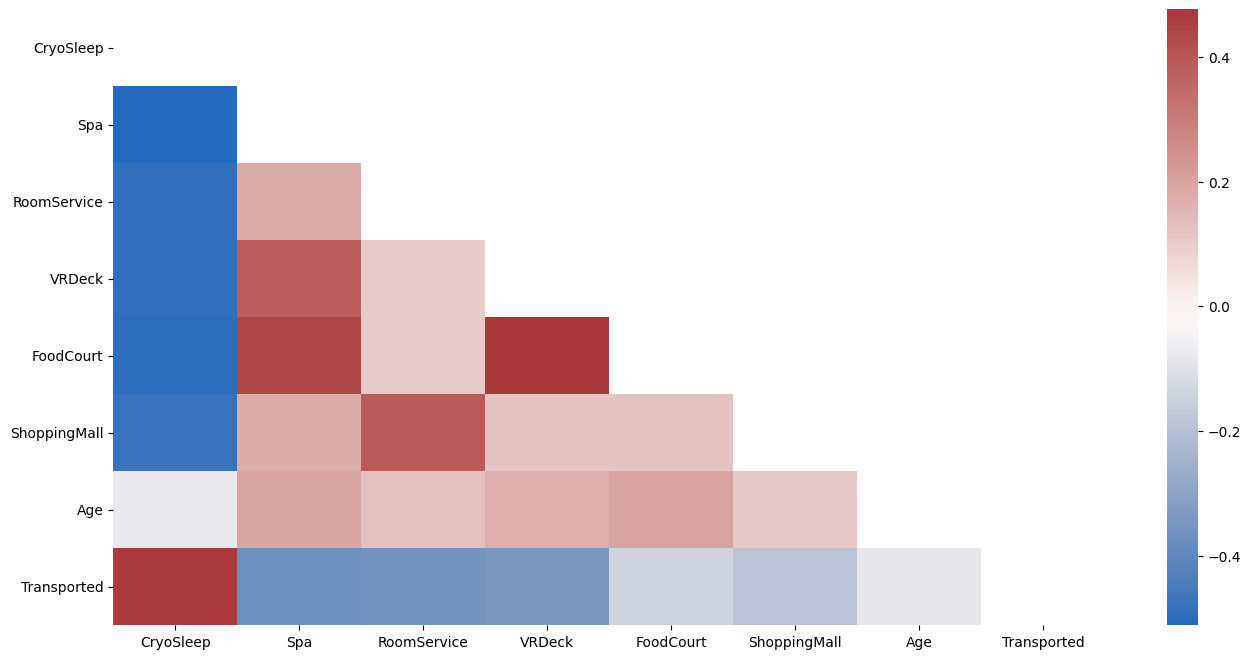

In [6]:
plot_corrs(df0[Features], cmap = 'vlag')

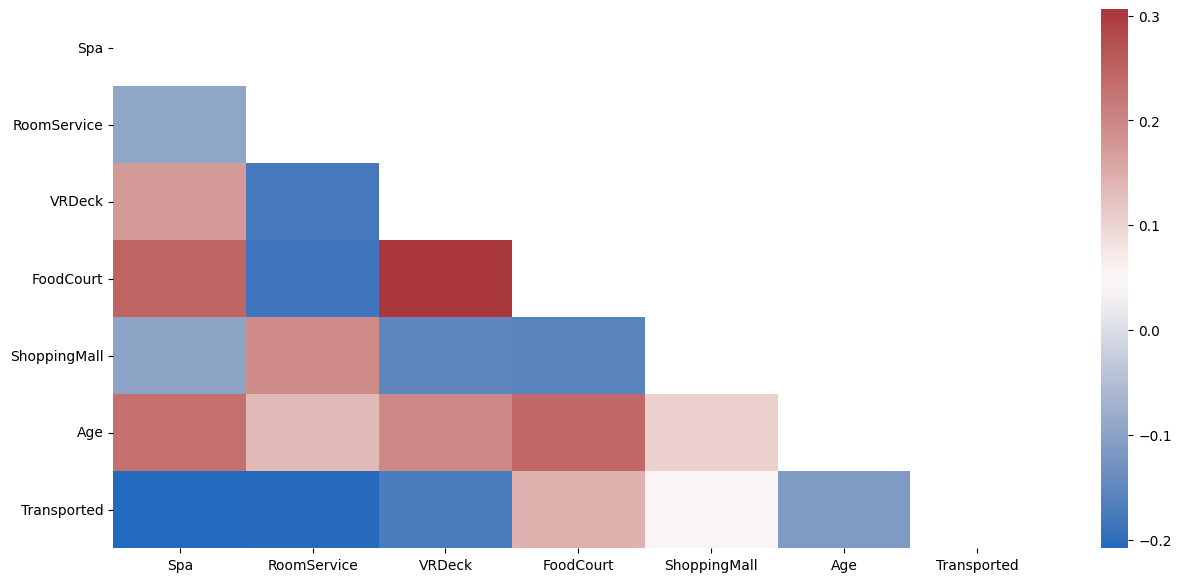

In [7]:
plot_corrs(df0[df0.CryoSleep == False][Luxury_Features + ['Age', 'Transported']], cmap = 'vlag')

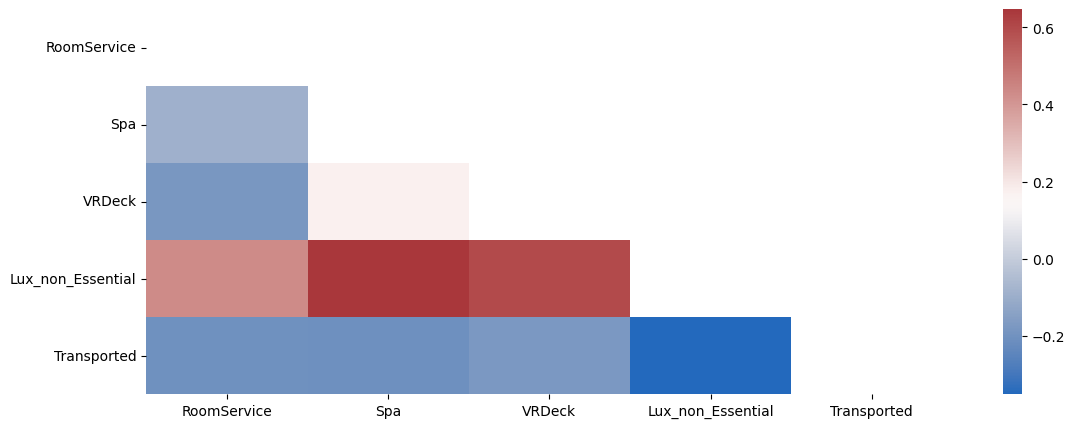

In [8]:
plot_corrs(df0[df0.CryoSleep == False][Non_Essential_Lux_Features + ['Lux_non_Essential', 'Transported']], cmap = 'vlag')

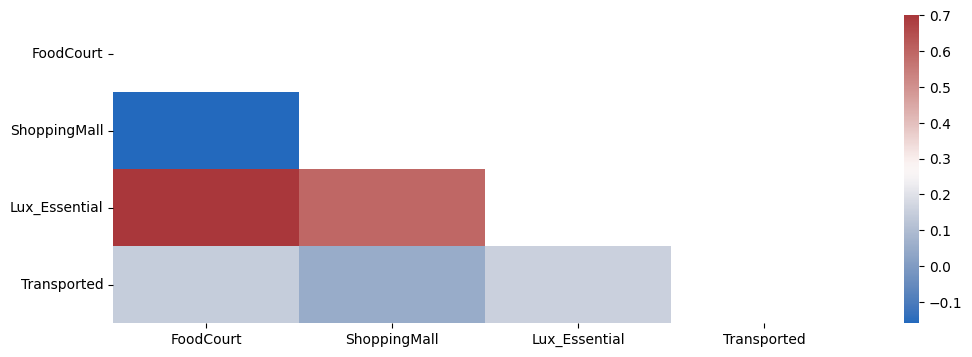

In [9]:
plot_corrs(df0[df0.CryoSleep == False][Essential_Lux_Features + ['Lux_Essential', 'Transported']], cmap = 'vlag')

### Examine distributions, ratios, and histograms

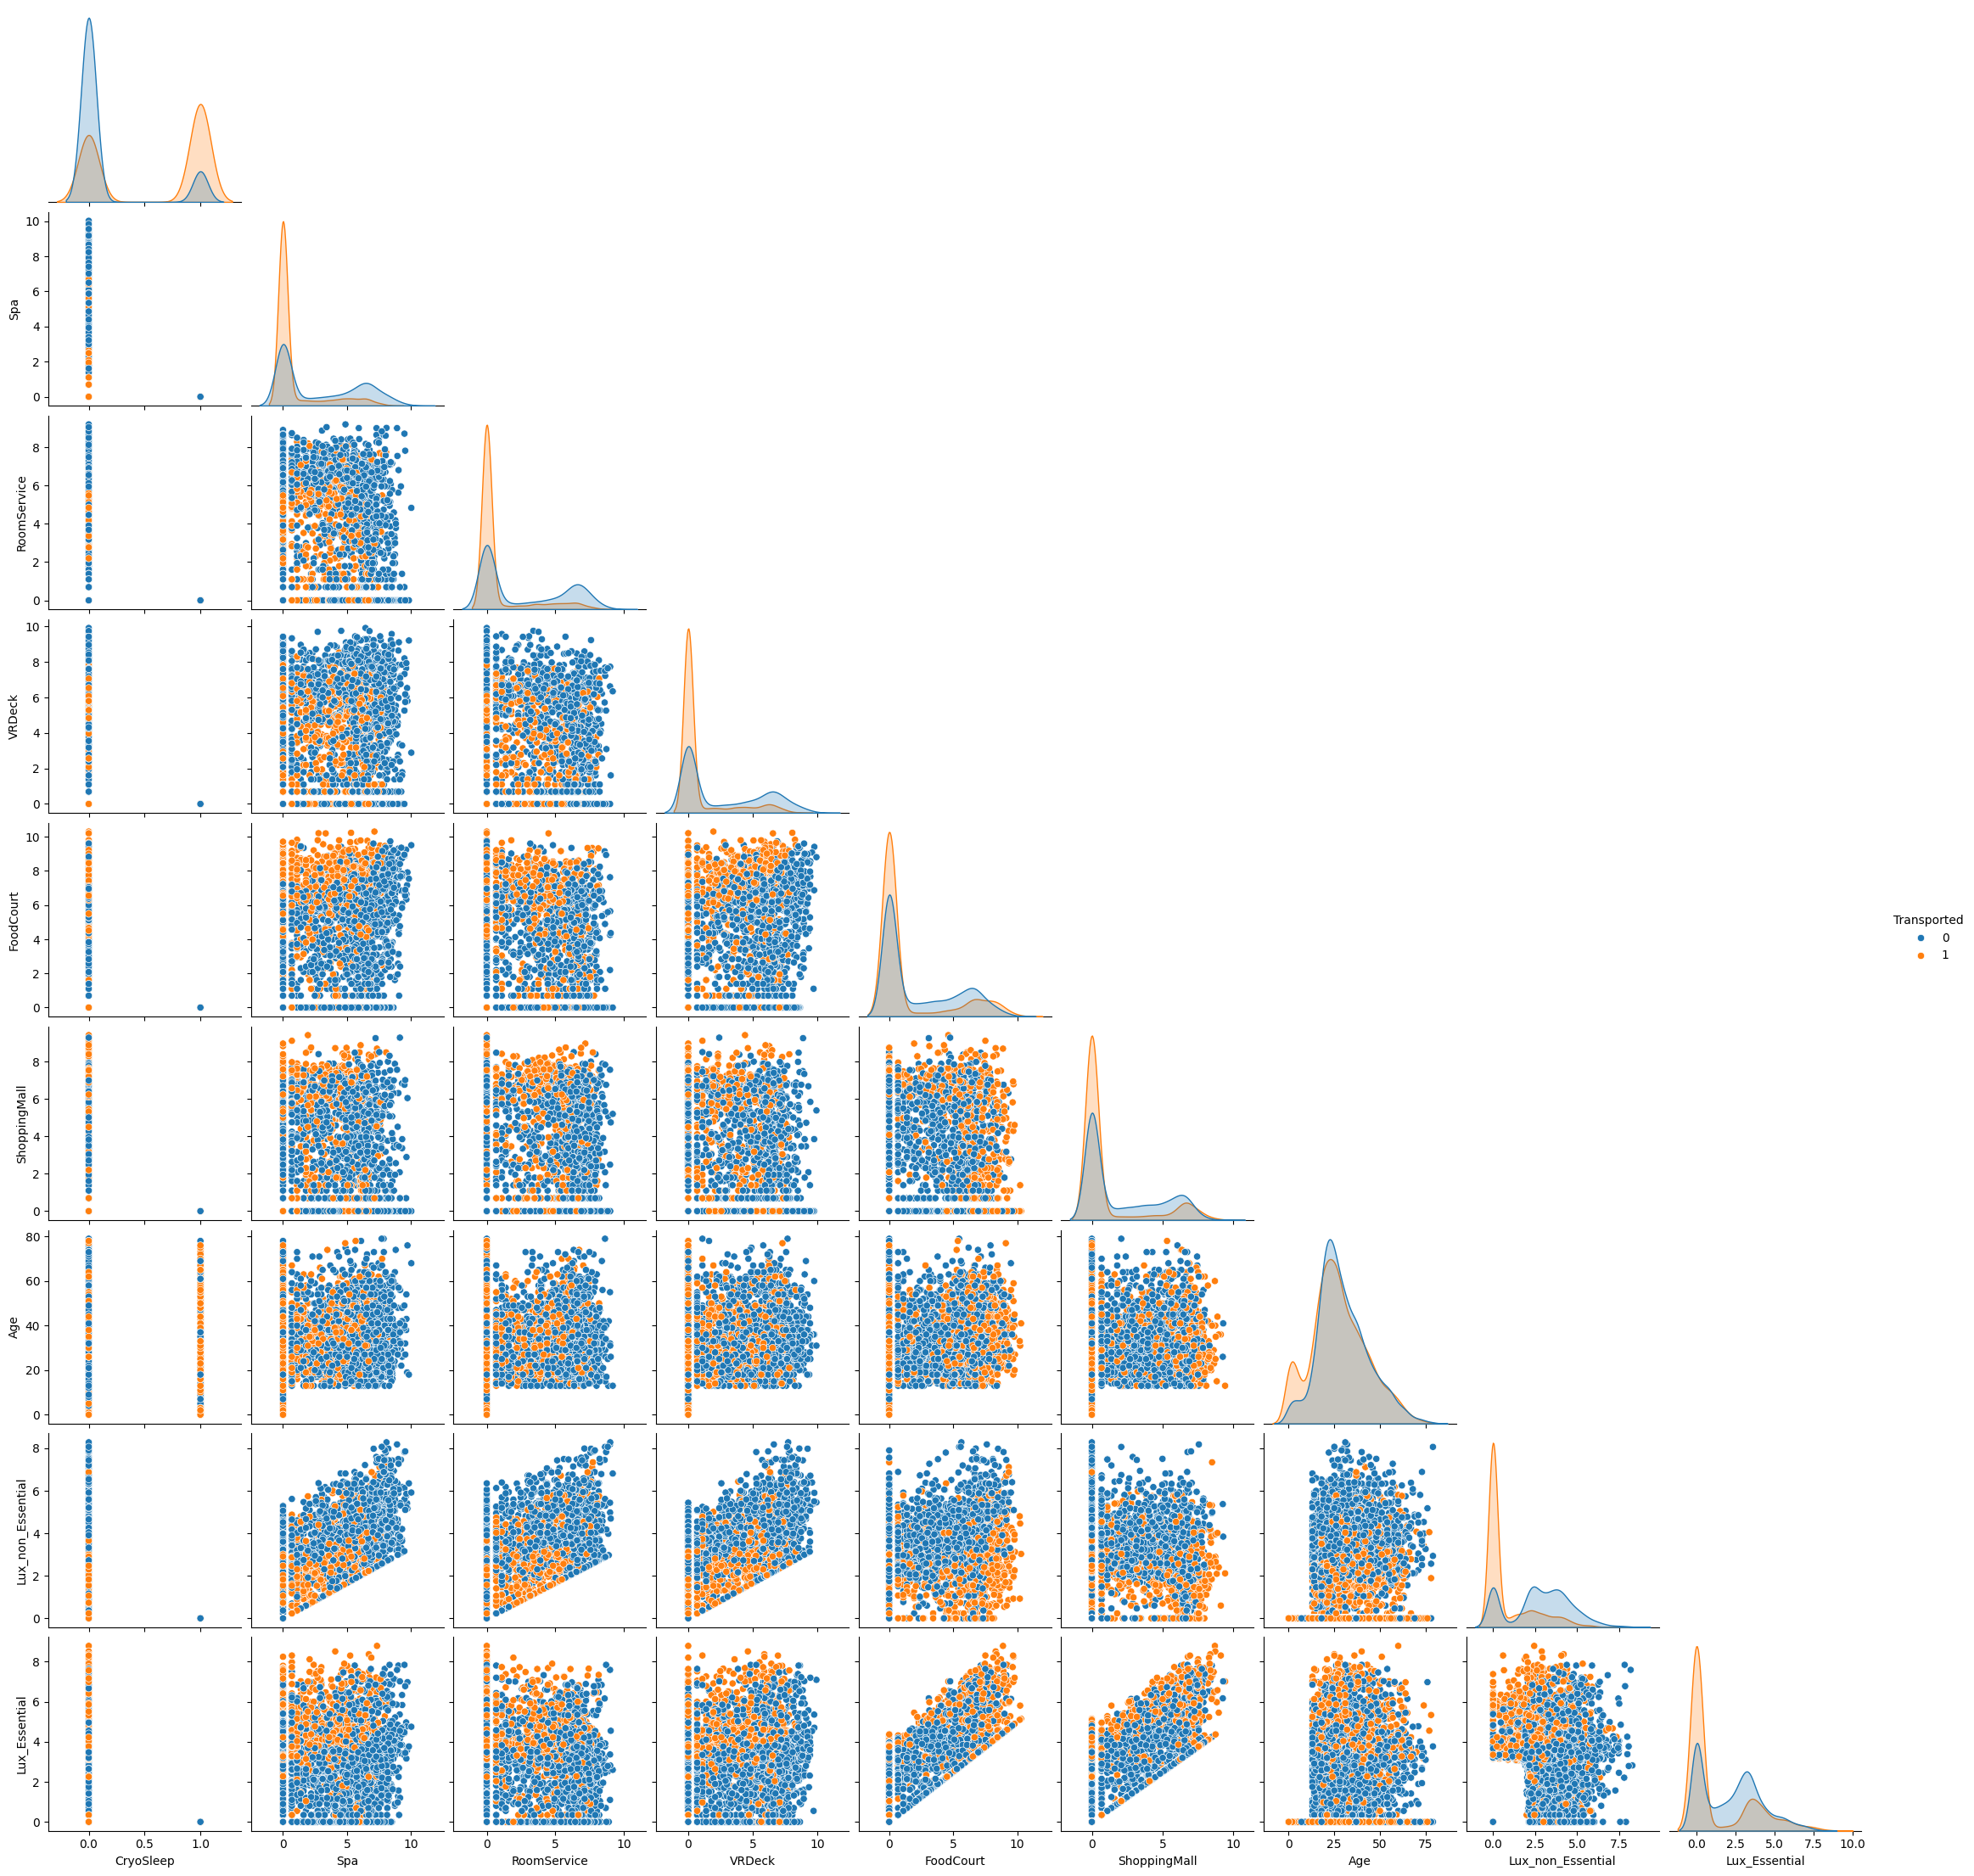

In [10]:
sns.pairplot(data = df0, hue = 'Transported', corner = True)

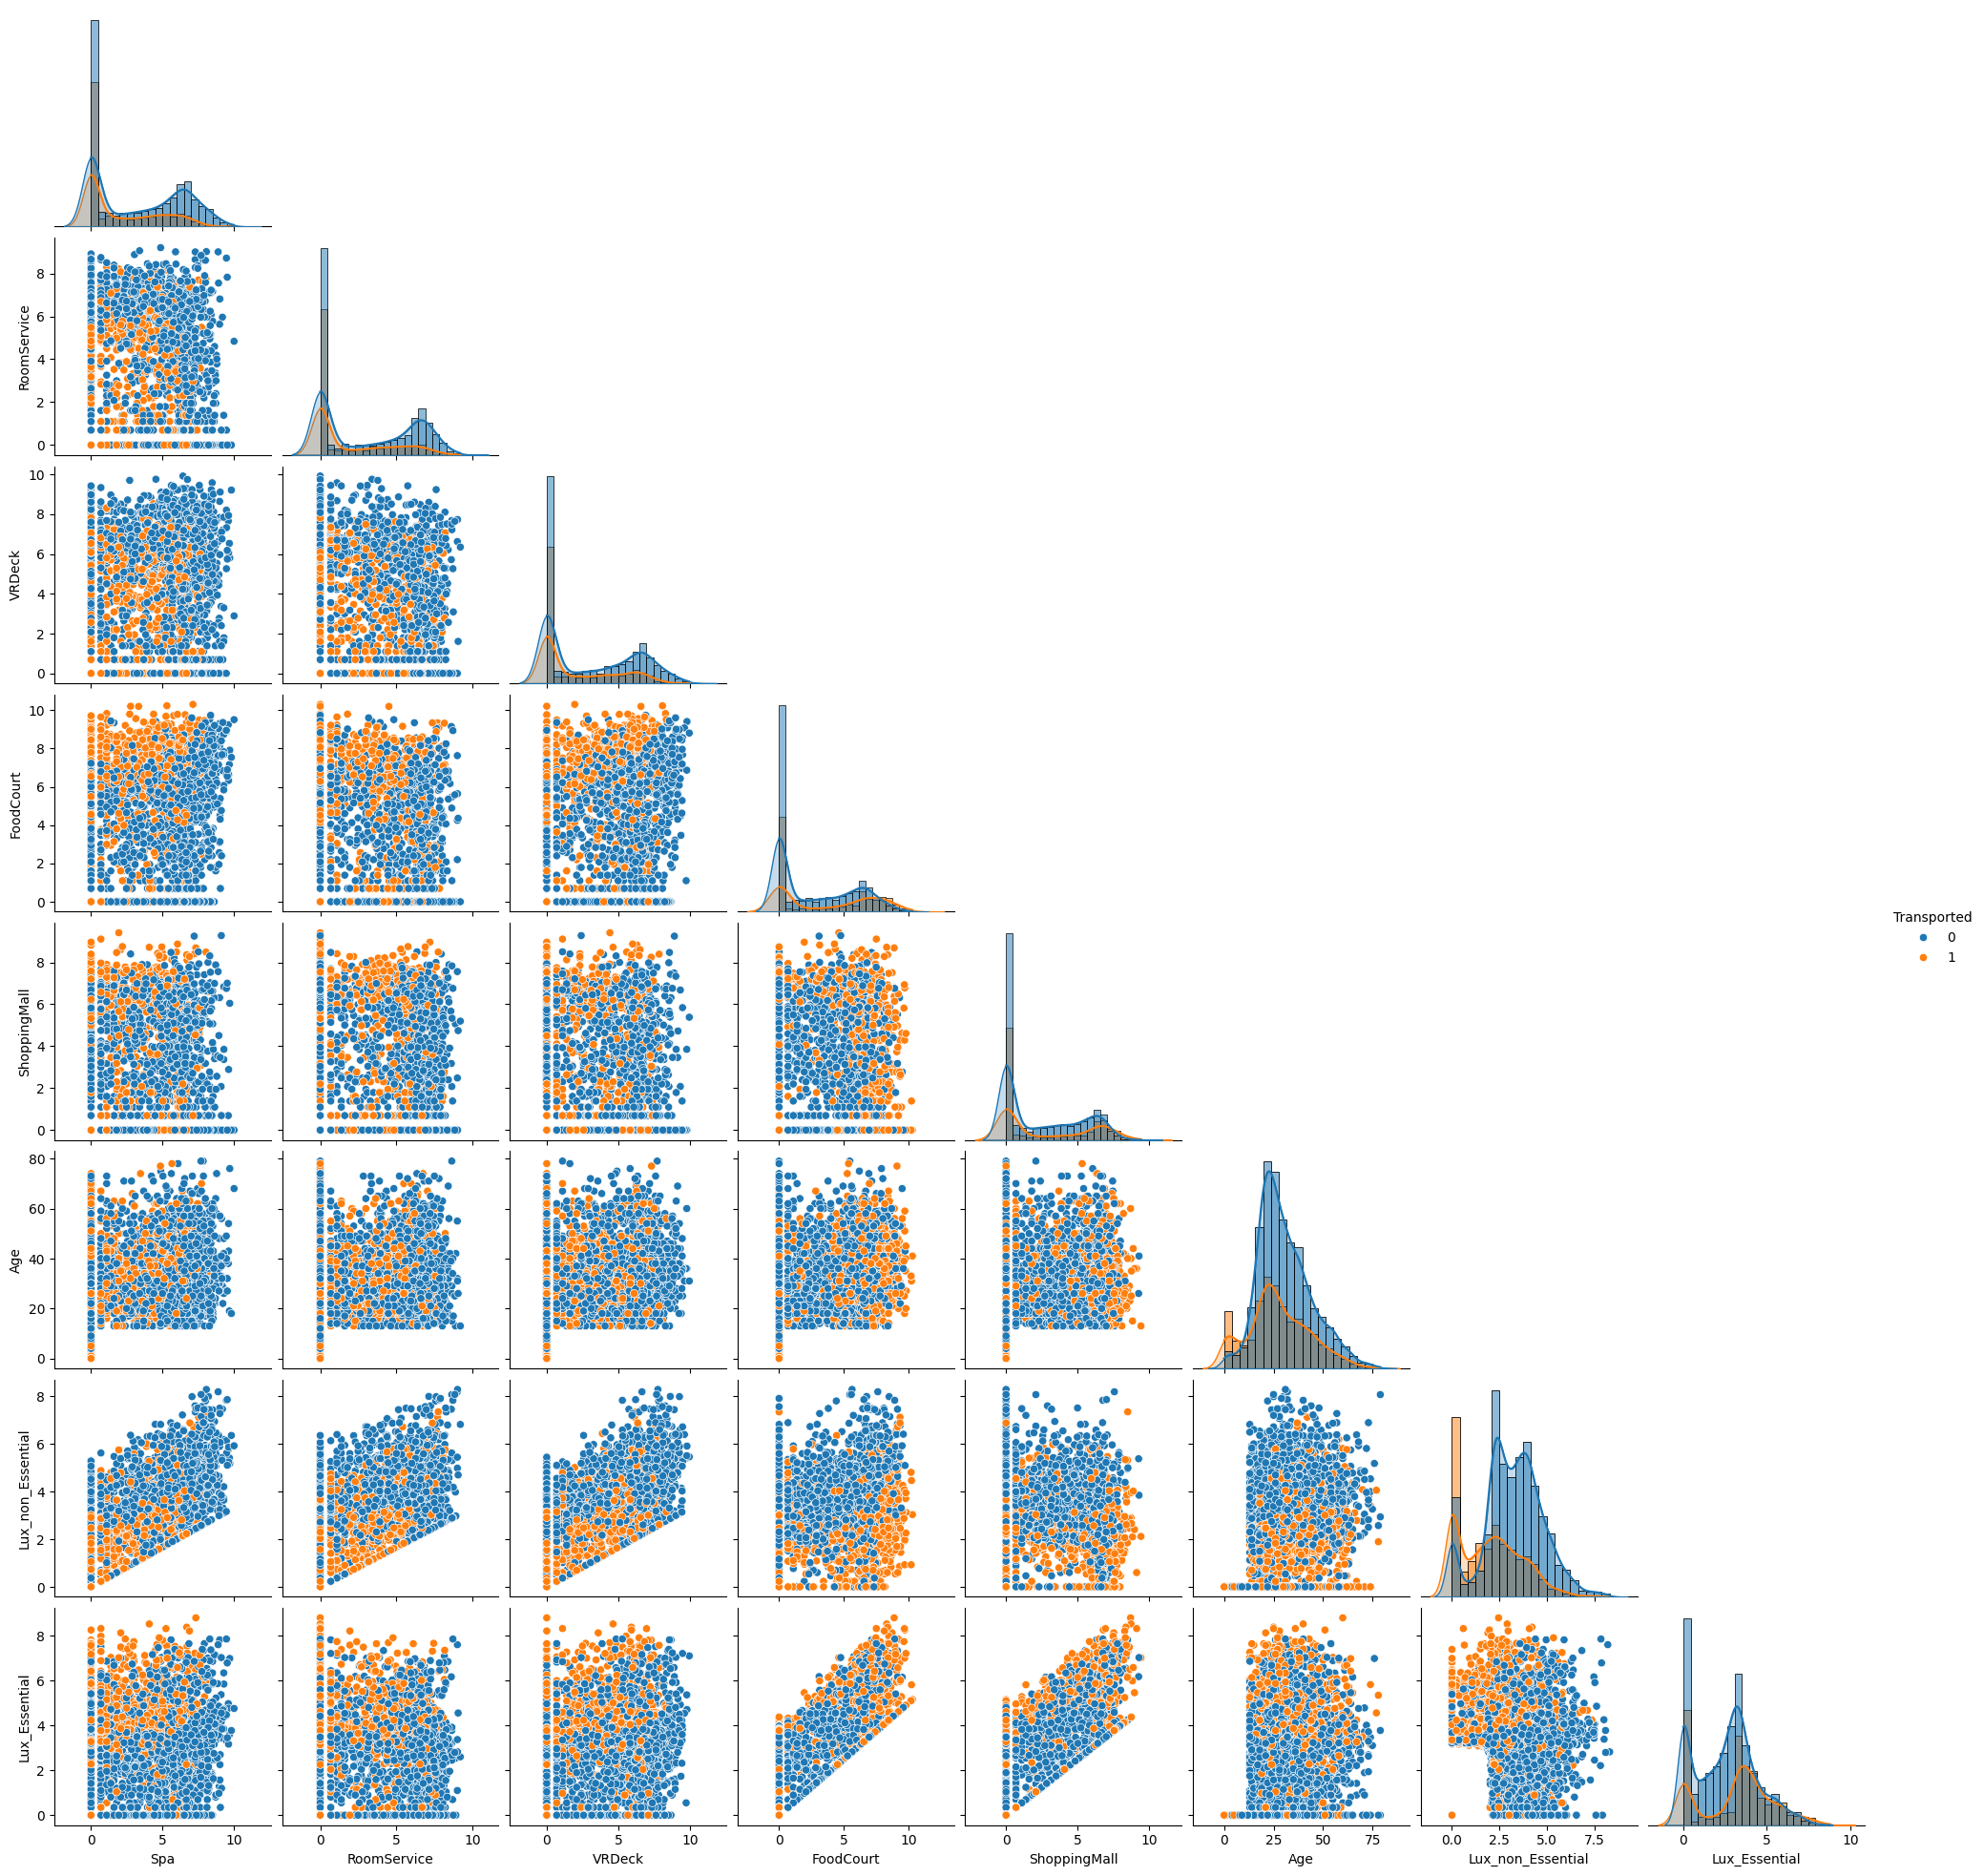

In [11]:
mask = df0['CryoSleep'] == 0
g = sns.pairplot(data = df0[mask].drop(columns = ['CryoSleep']), hue = 'Transported', corner = True)
g.map_diag(sns.histplot, kde = True, stat = 'density', bins = 20)

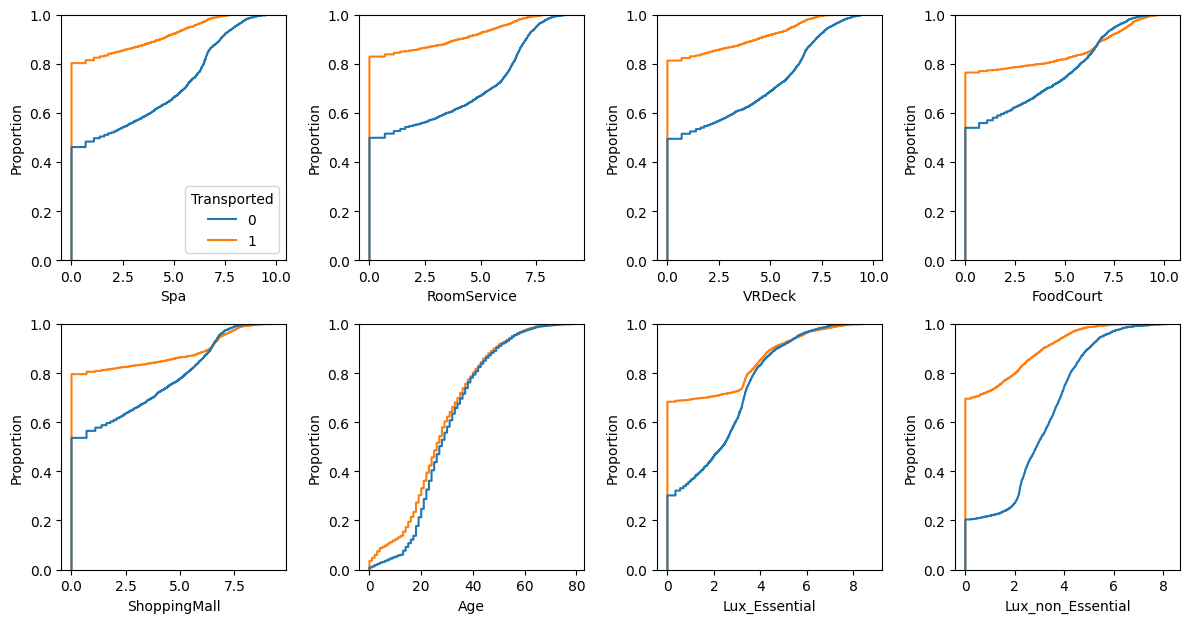

In [12]:
vars_list = Luxury_Features + ['Age', 'Lux_Essential', 'Lux_non_Essential']
get_ecdfplots(df0, vars_list, target = 'Transported', ncols = 4)

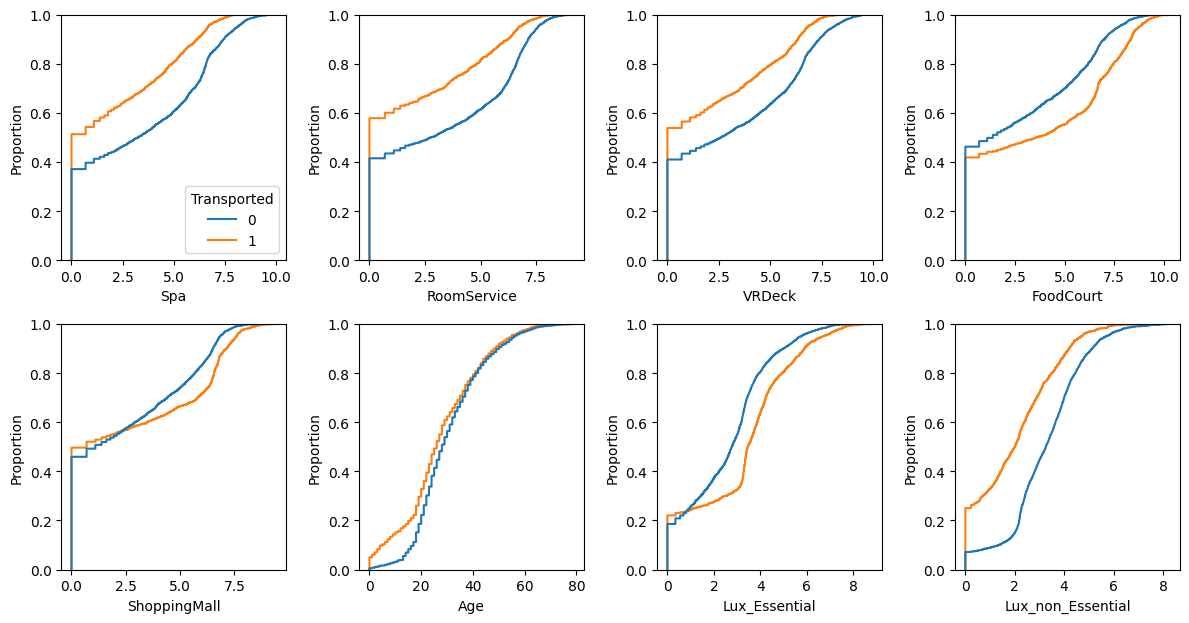

In [13]:
mask = df0['CryoSleep'] == 0
get_ecdfplots(df0[mask], vars_list, target = 'Transported', ncols = 4)

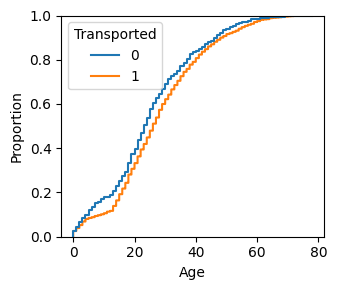

In [14]:
mask = df0['CryoSleep'] == 1
get_ecdfplots(df0[mask], ['Age'], target = 'Transported', ncols = 3)

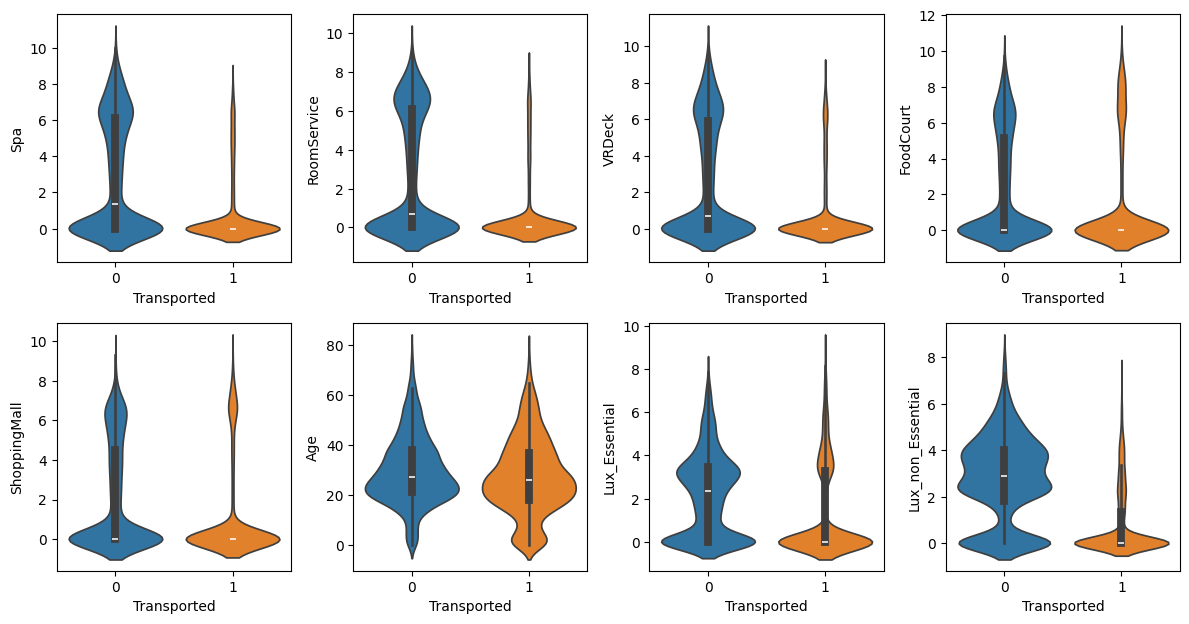

In [15]:
df01 = df0.copy()
df01['CryoSleep'] = df01['CryoSleep'].astype(bool).astype(str)
df01['Transported'] = df01['Transported'].astype(str)
get_violinplots(df01, vars_list, target1 = 'Transported', ncols = 4)

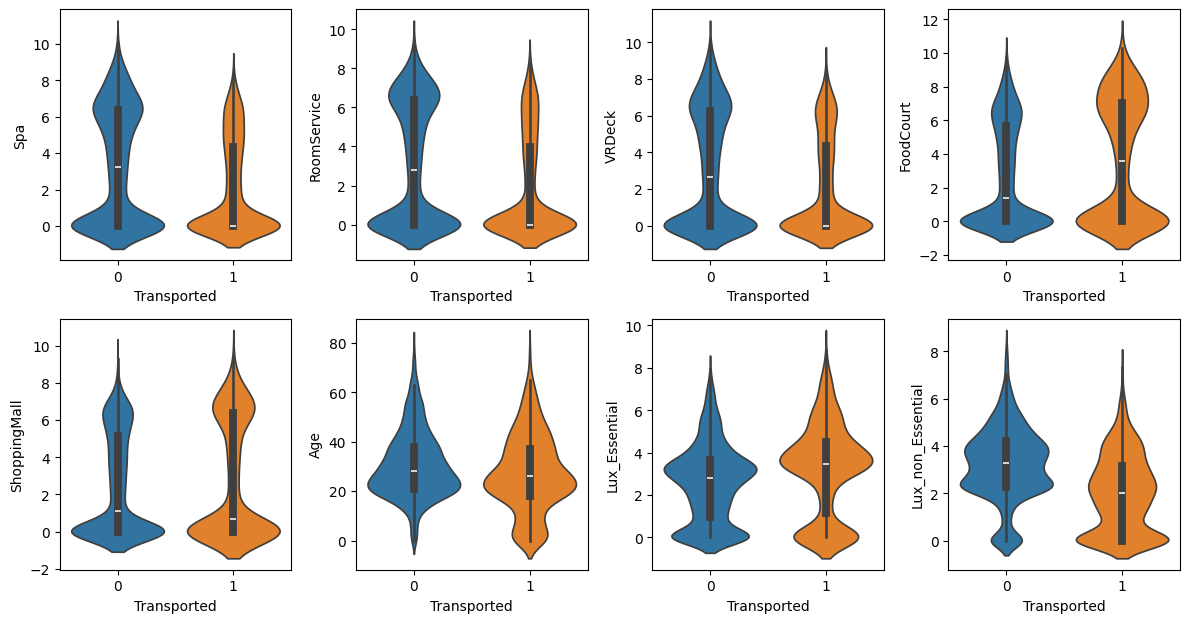

In [16]:
get_violinplots(df01[df01['CryoSleep'] == 'False'], vars_list, target1 = 'Transported', ncols = 4)

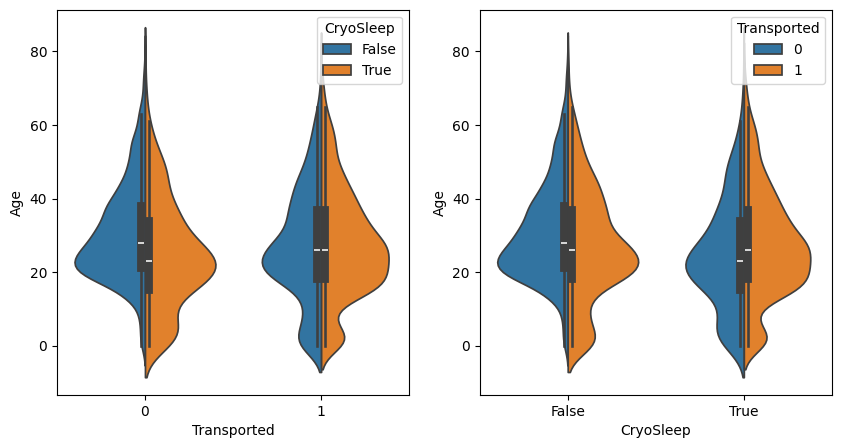

In [17]:
get_violinplots(df01, ['Age'], target1 = 'Transported', ncols = 1, target2 = 'CryoSleep')

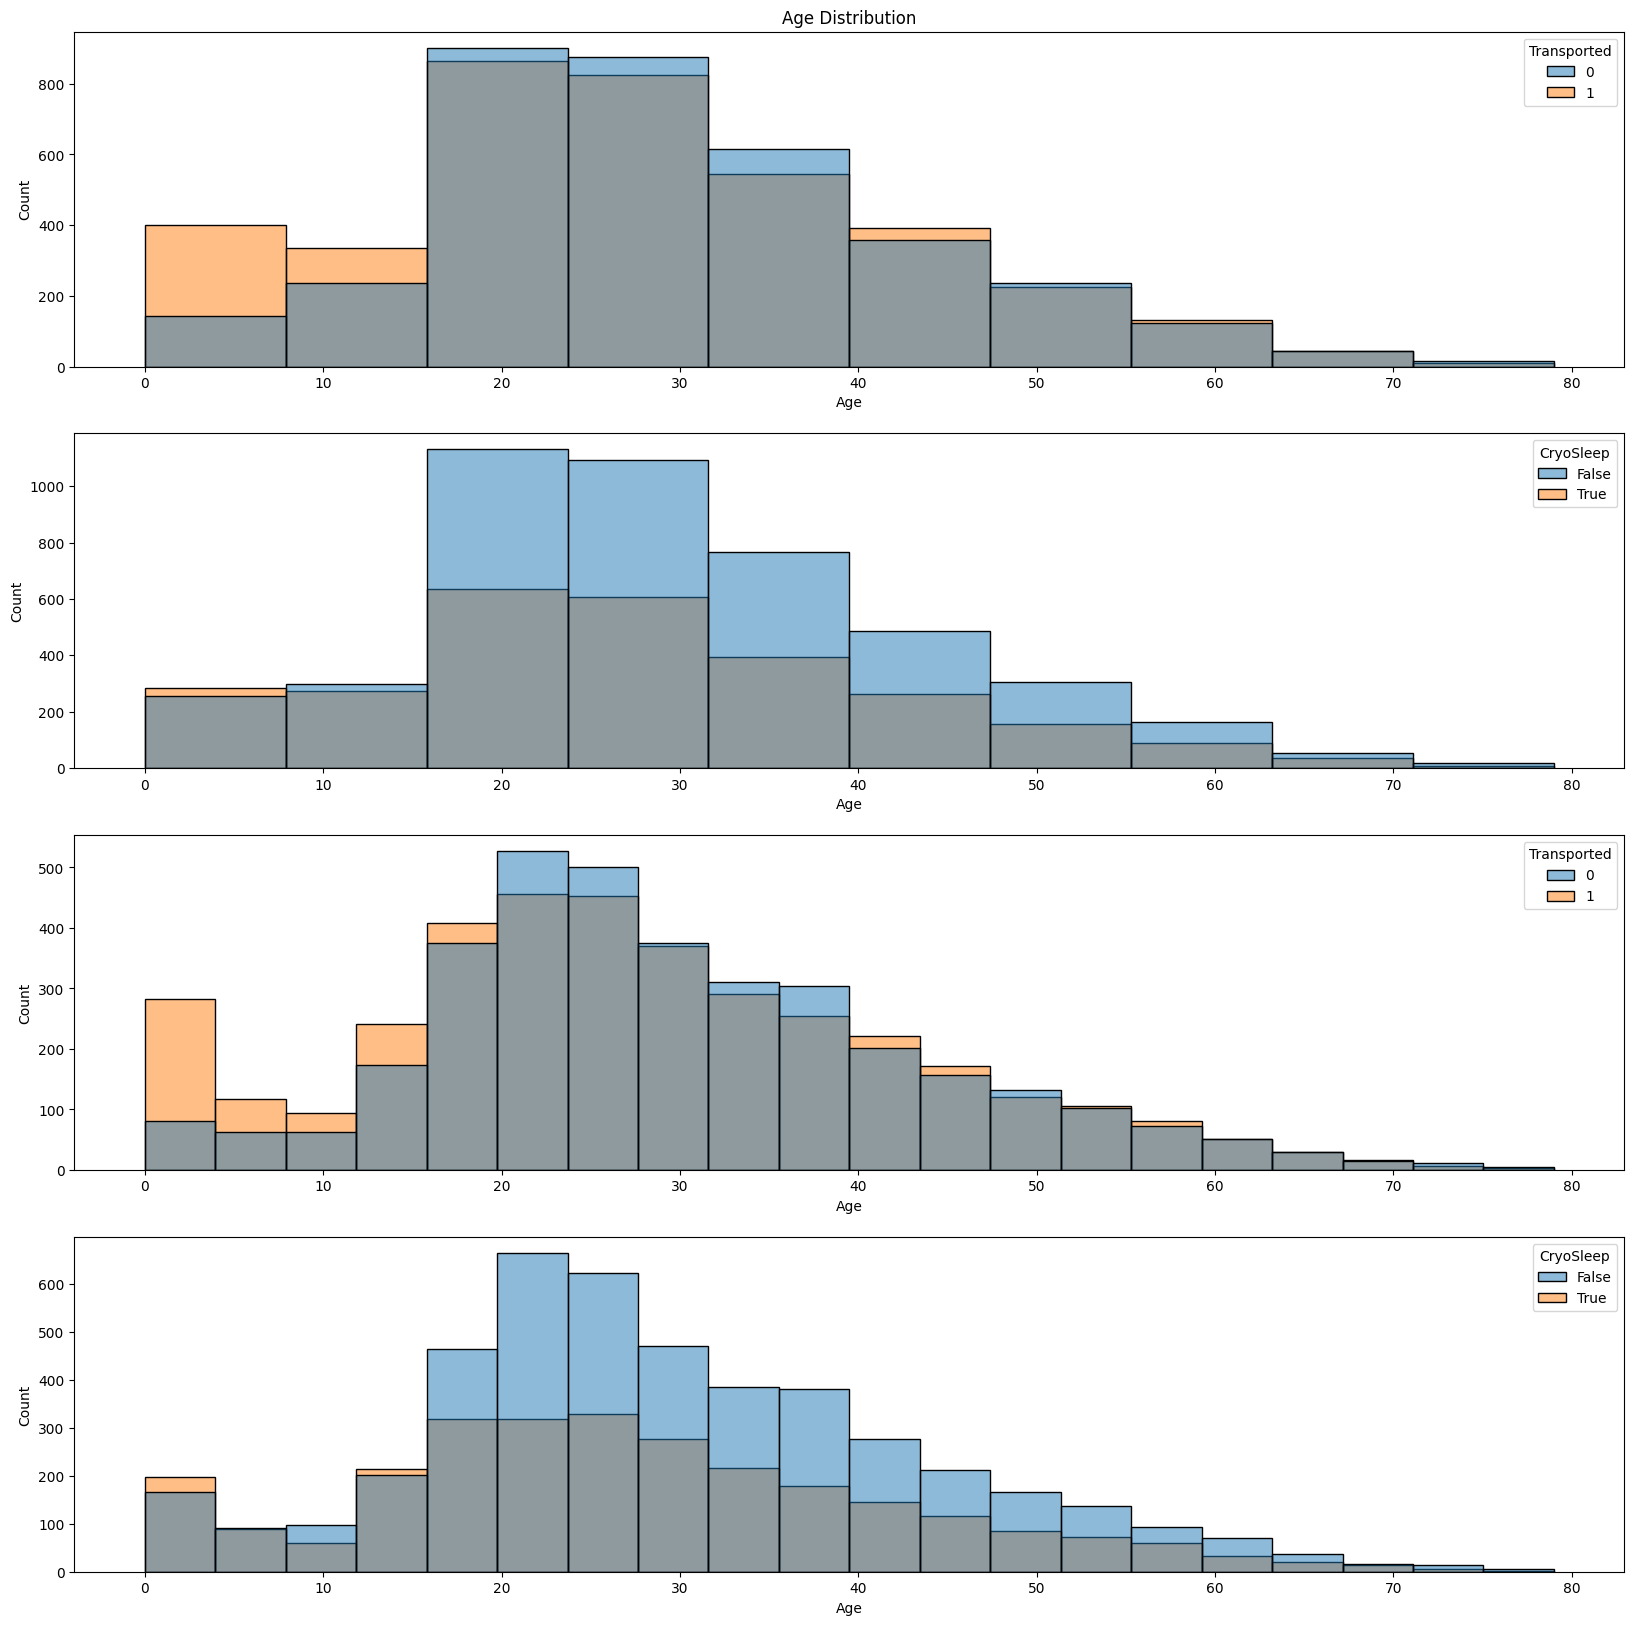

In [18]:
plot_hists_by_Cryo_and_Transported(df0, 'Age')

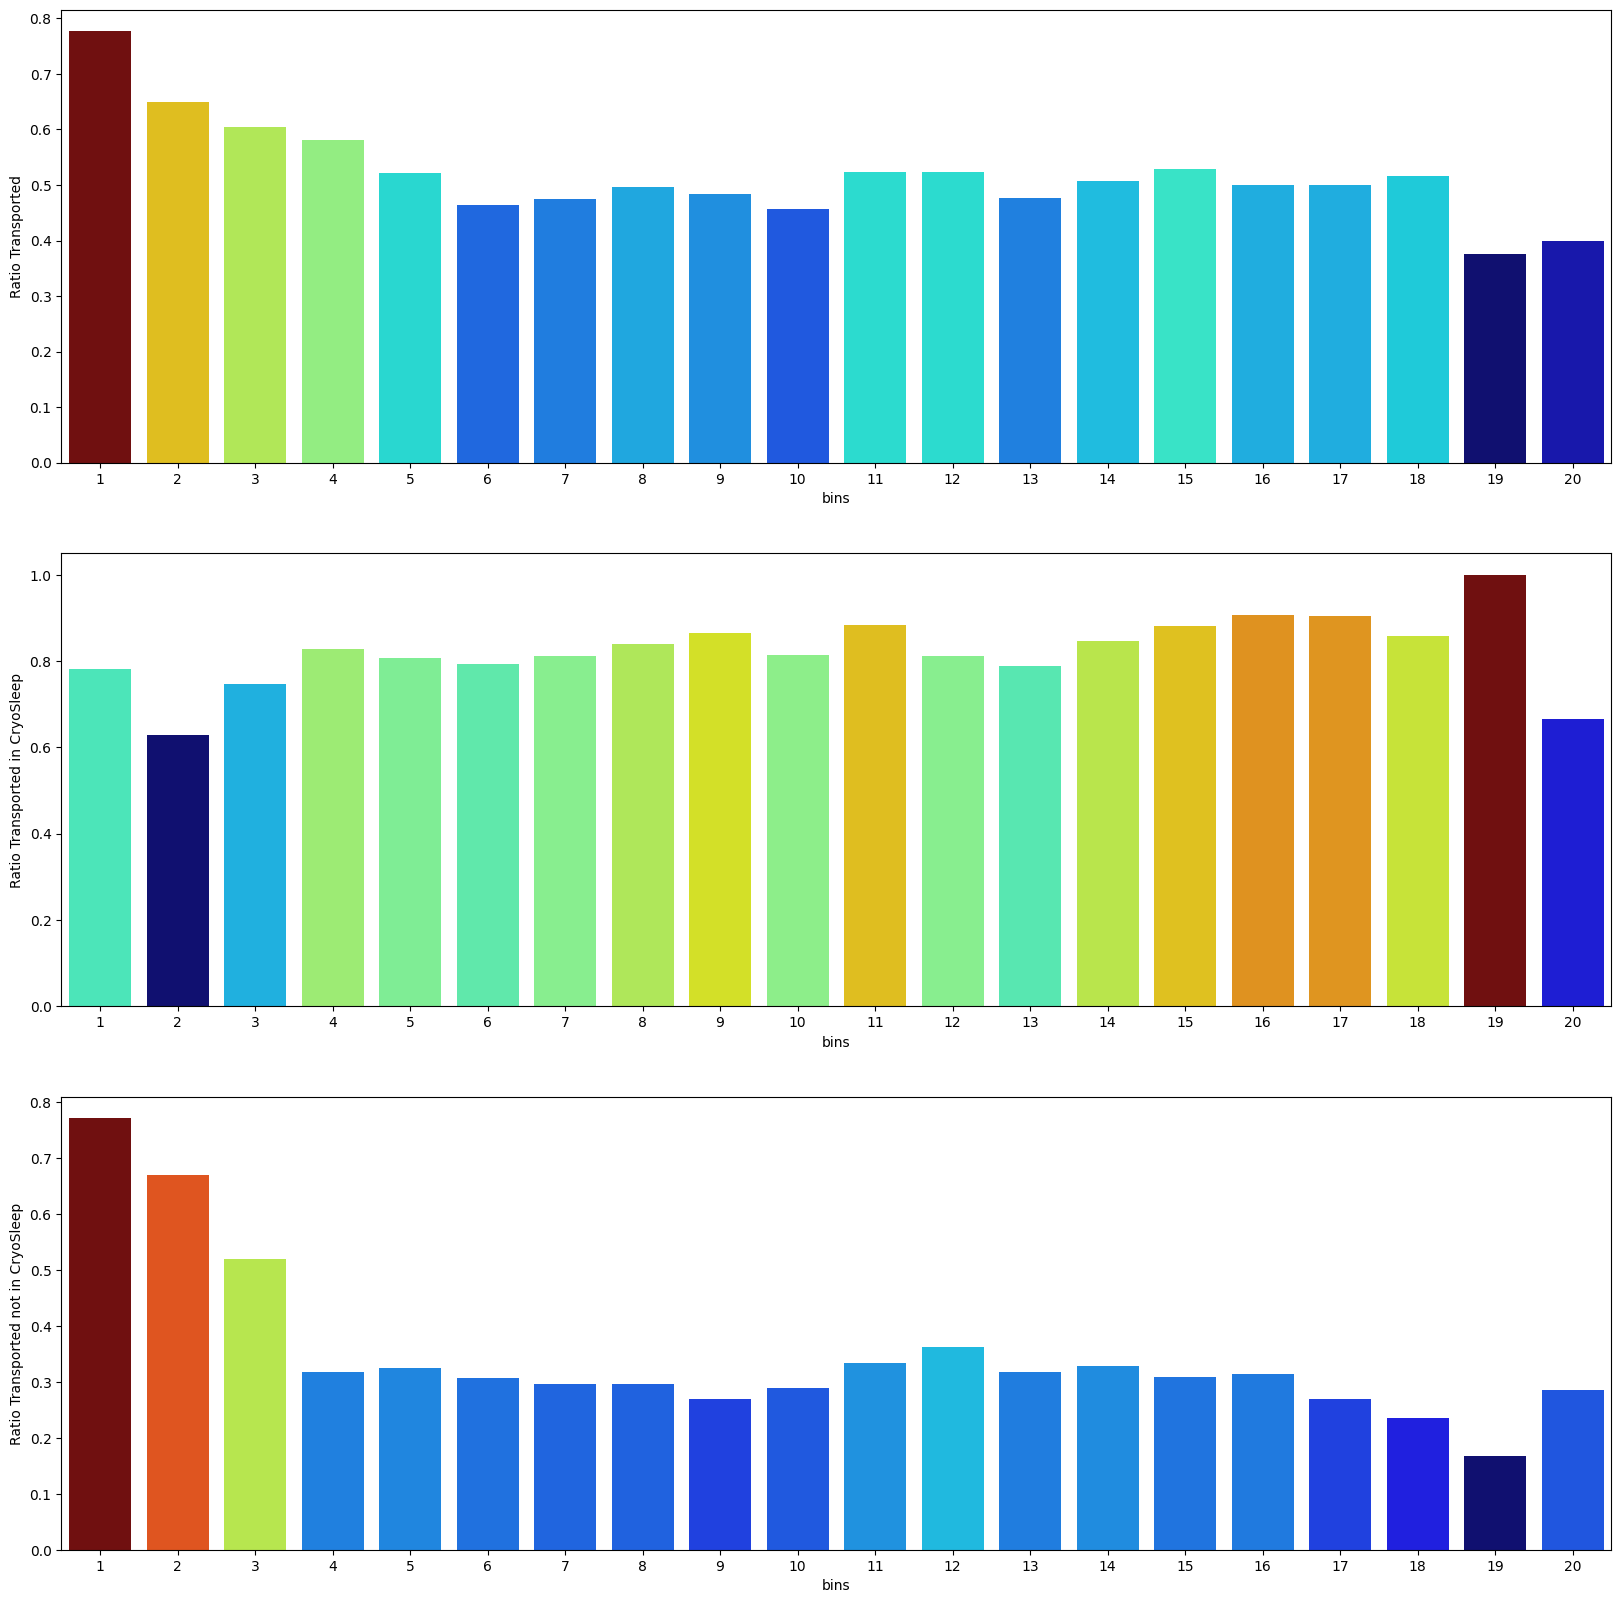

In [19]:
bin_ranges, df_num_groups = plot_ratios_by_Cryo_and_Transported(df0, 'Age', nbins = 20)

In [20]:
str(bin_ranges)

'[(0.0, 4.0), (4.0, 7.9), (7.9, 11.9), (11.9, 15.8), (15.8, 19.8), (19.8, 23.7), (23.7, 27.6), (27.6, 31.6), (31.6, 35.6), (35.6, 39.5), (39.5, 43.4), (43.4, 47.4), (47.4, 51.4), (51.4, 55.3), (55.3, 59.2), (59.2, 63.2), (63.2, 67.2), (67.2, 71.1), (71.1, 75.0), (75.0, 79.0)]'

In [21]:
# _, _ = plot_ratios_by_Cryo_and_Transported(df0, 'Age_Bin', nbins = bins, cat = True)

In [22]:
# mapping_age = {1: 'Child', 2: 'teen', 3: '19-21', 4: 'low 20s', 5: '25-27', 6: '28-30', 7: 'low 30s', 8: '36-41', 9: '42-49', 10: '50 and above'}
# df0['Age_Brackets'] = df0['Age_Bin'].map(mapping_age)

bin_edges = [0, 2, 5, 13, 20, 36, 46, 65, 90]
LifeStages_choices = ['Infant', 'Toddler', 'Child', 'Teen', 'Young Adult', 'Young middle aged', 'Older middle aged', 'Senior']
LifeStages_conds = [df0.Age.between(bin_edges[i], bin_edges[i + 1] - 0.1) for i in range(len(bin_edges) - 1)]

Brackets_choices = ['Child', 'Teen', '19-21', 'Low 20s', '25-27', '28-30', 'Low 30s', '36-41', '42-49', '50 and above']
Brackets_conds = [df0.Age_Bin == i for i in range(1, len(Brackets_choices) + 1)]

df0['Age_LifeStages'] = np.select(LifeStages_conds, LifeStages_choices)
df0['Age_Brackets'] = np.select(Brackets_conds, Brackets_choices)

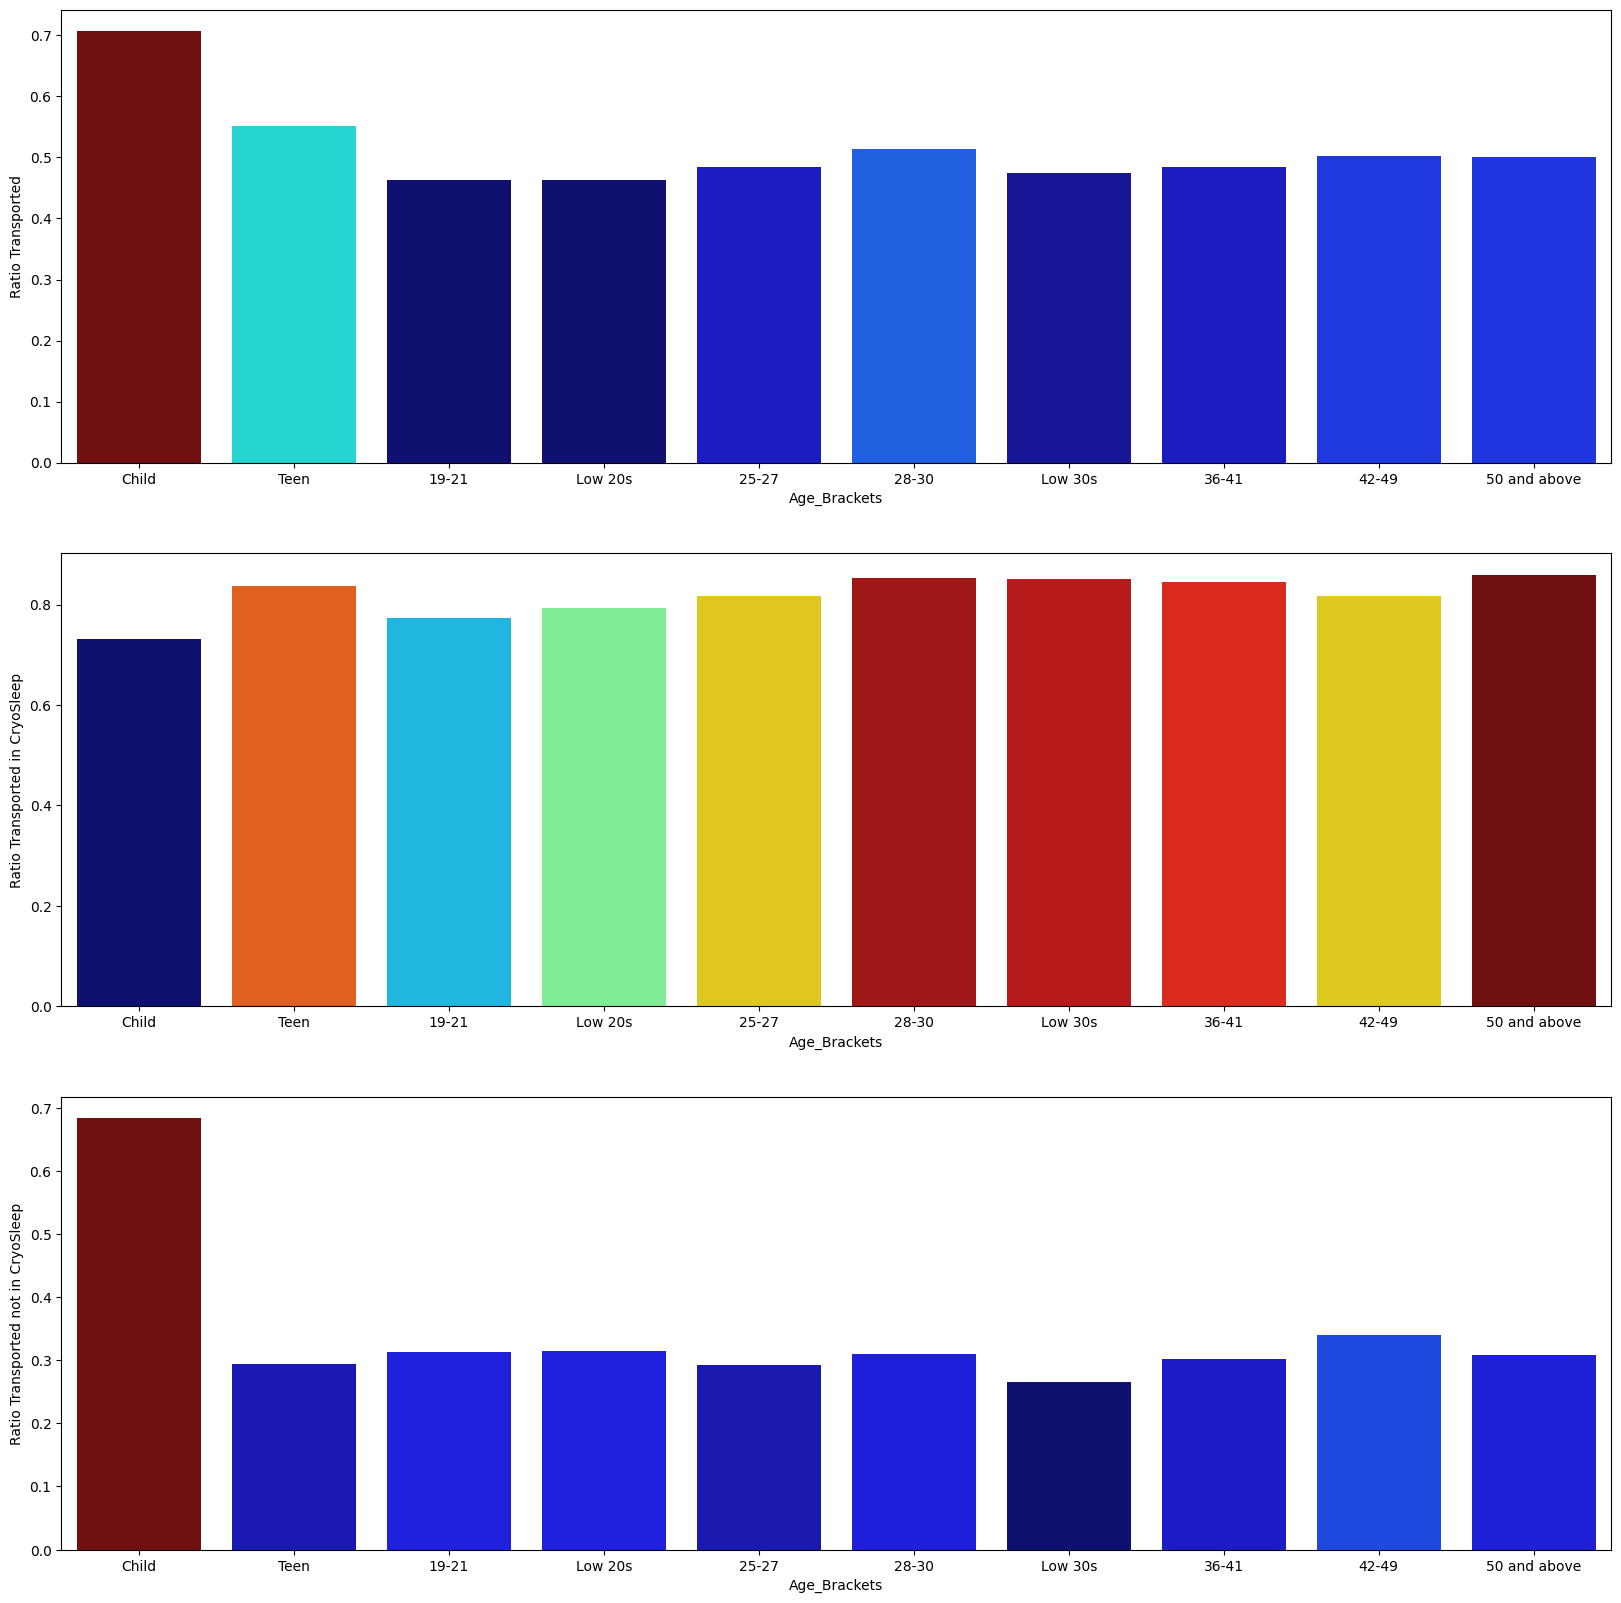

In [23]:
_, _ = plot_ratios_by_Cryo_and_Transported(df0, 'Age_Brackets', nbins = bins, cat = True, cat_bins = Brackets_choices)

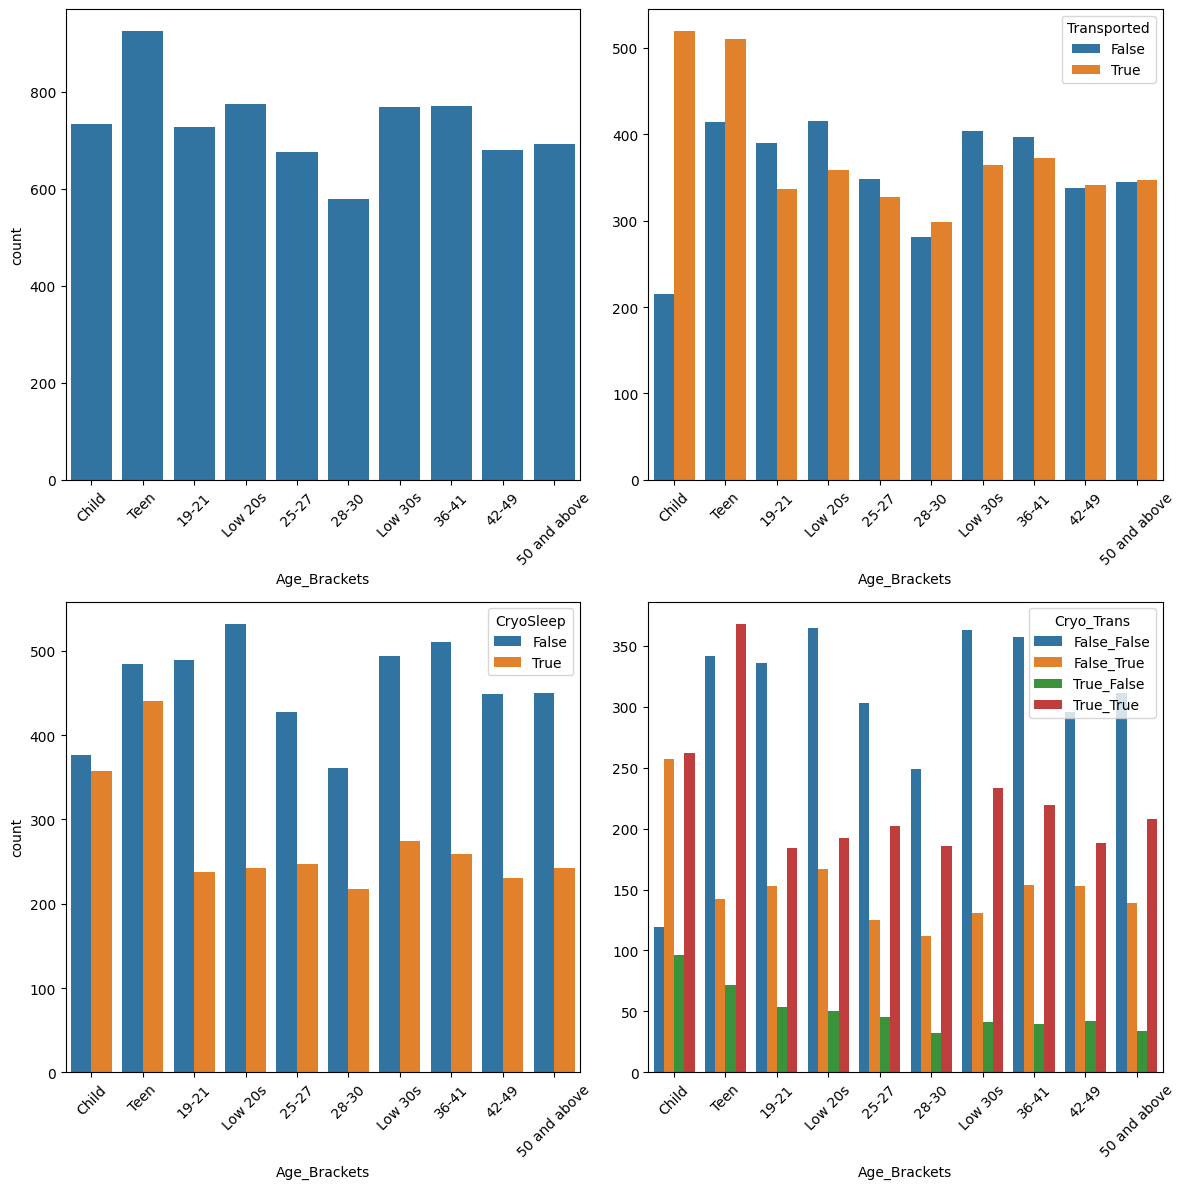

In [24]:
plot_CryoTrans_Counts(df0, 'Age_Brackets', Brackets_choices)

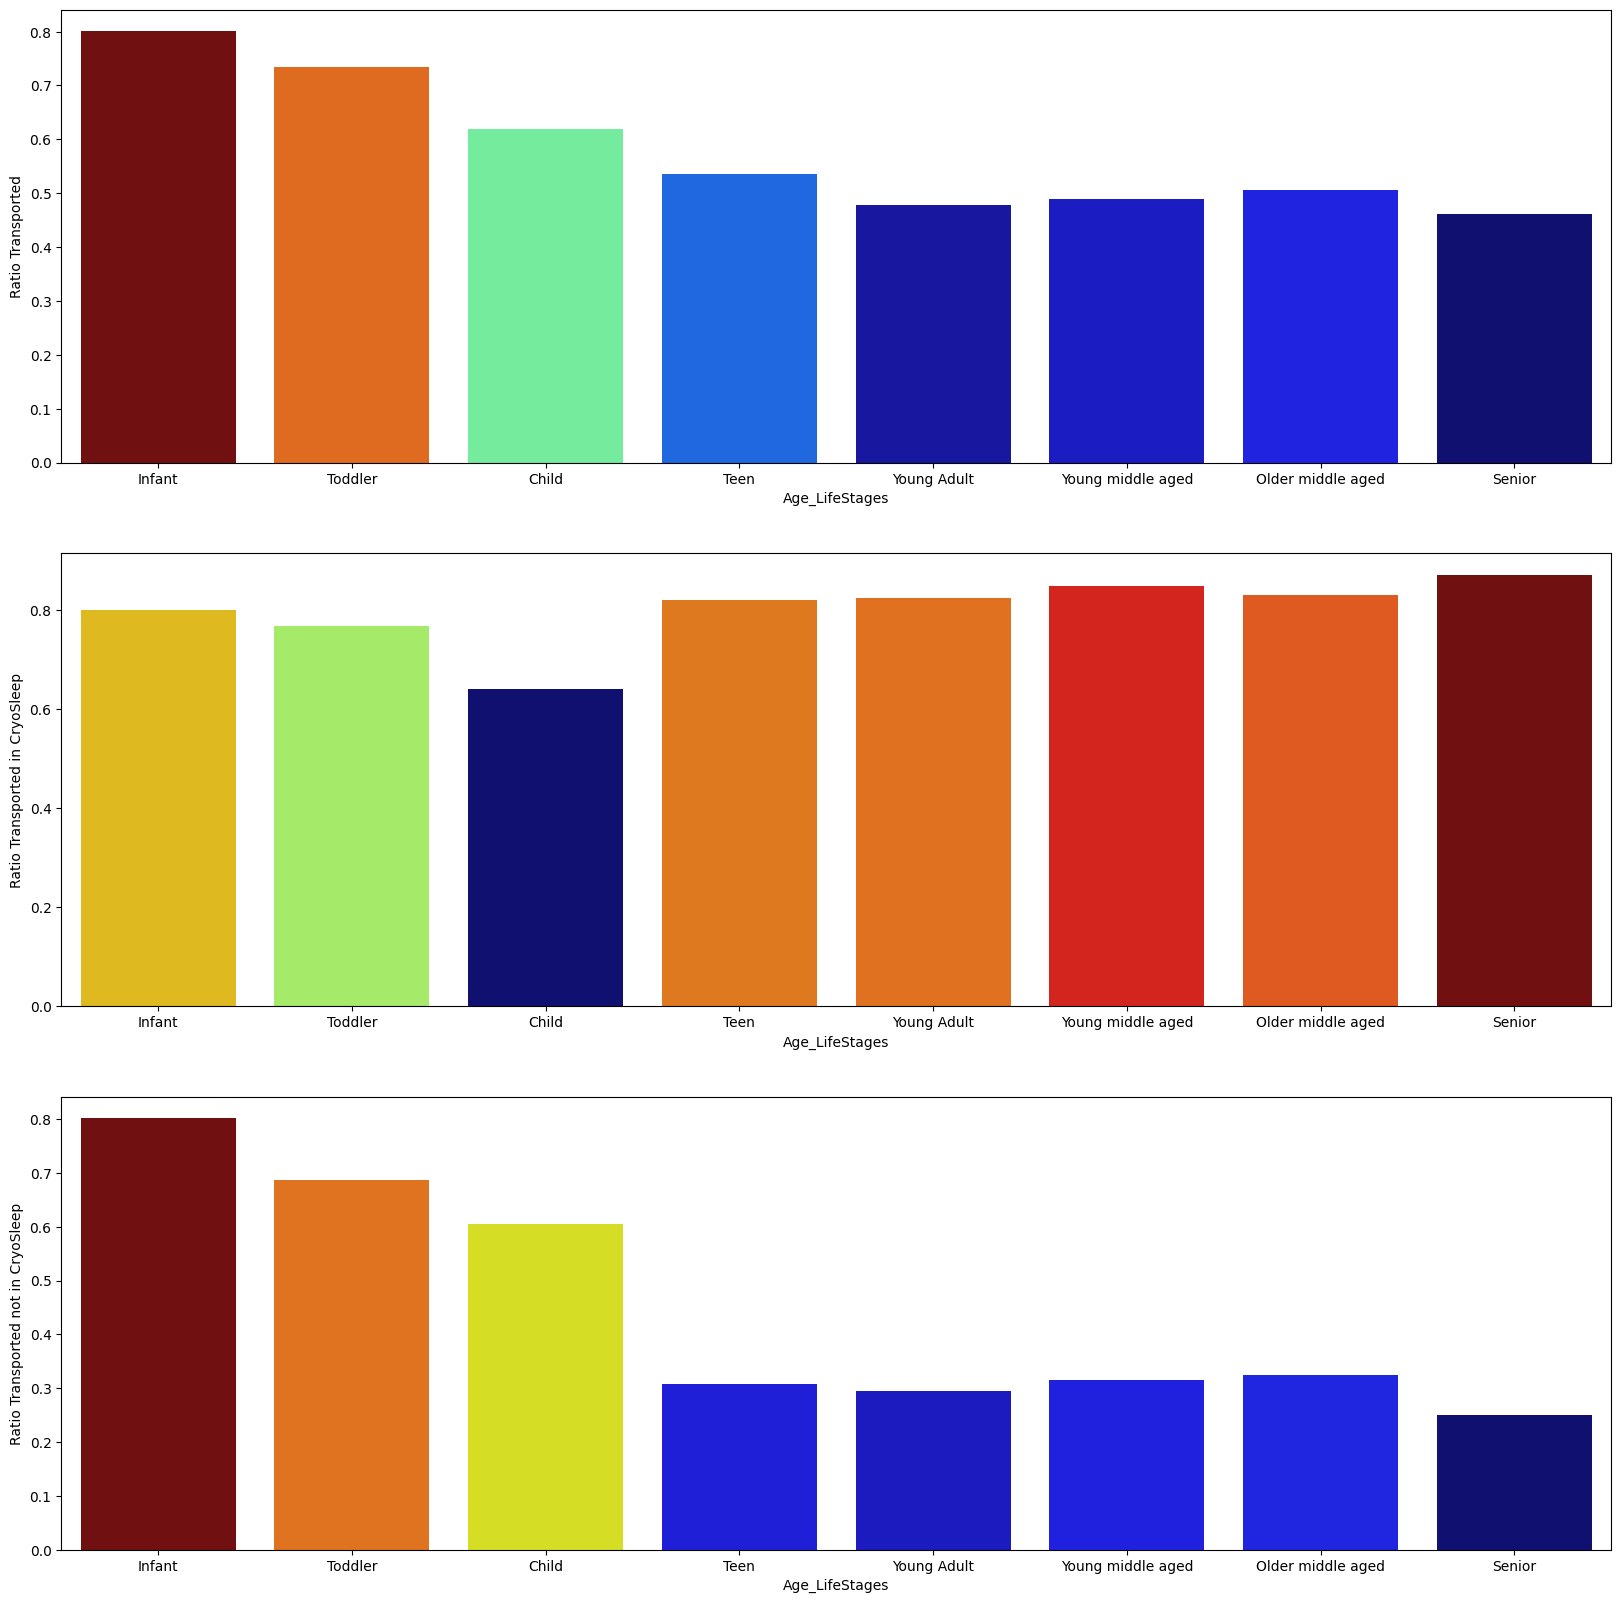

In [25]:
_, _ = plot_ratios_by_Cryo_and_Transported(df0, 'Age_LifeStages', nbins = bins, cat = True, cat_bins = LifeStages_choices)

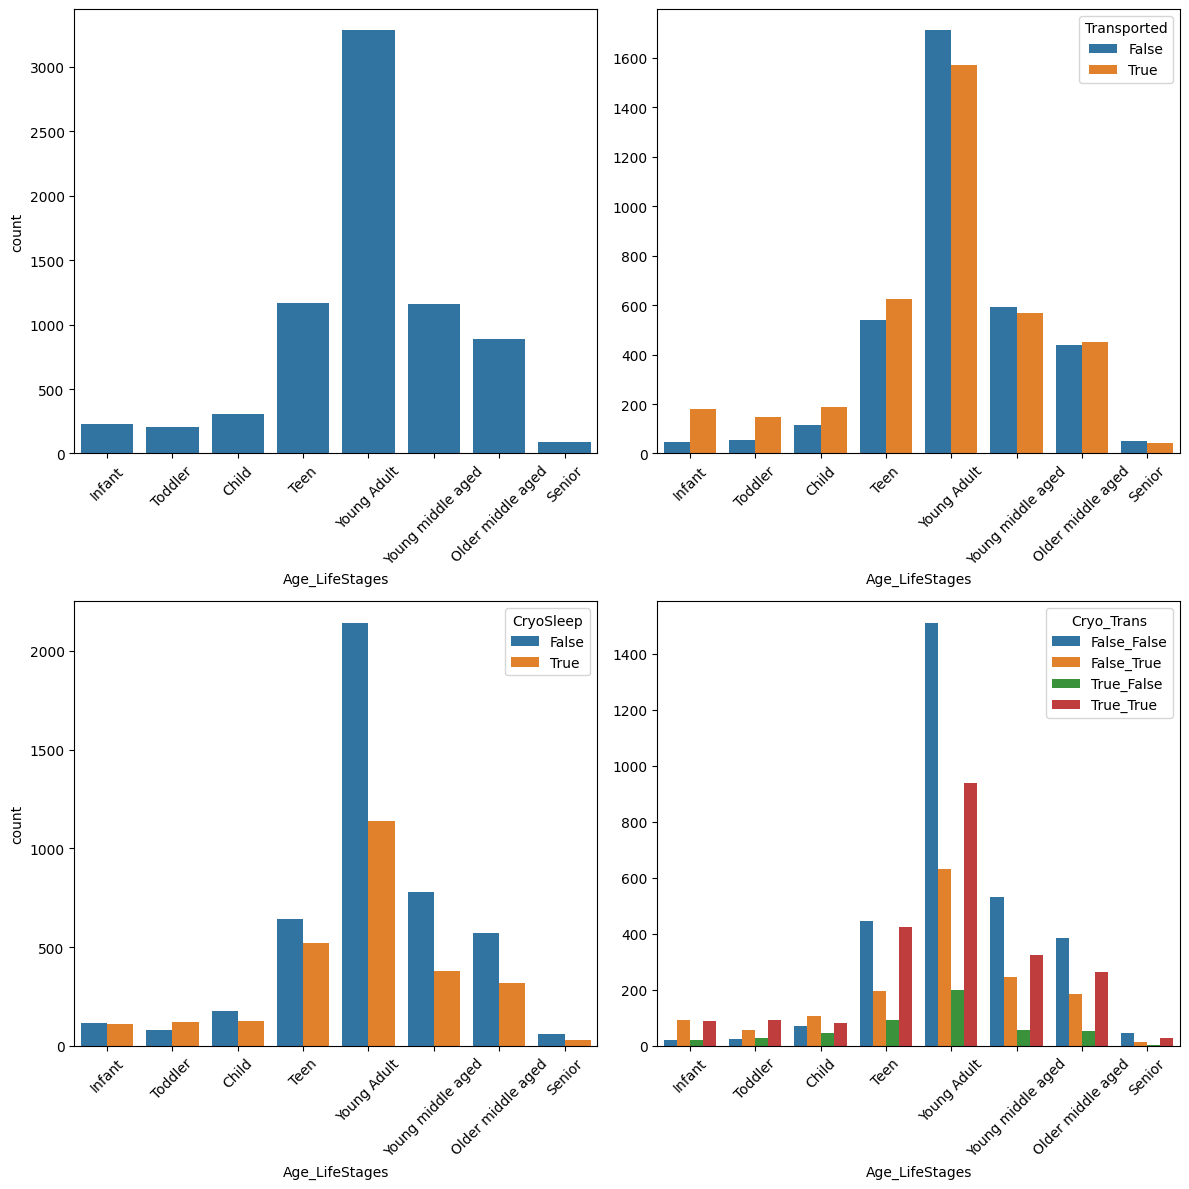

In [26]:
plot_CryoTrans_Counts(df0, 'Age_LifeStages', LifeStages_choices)

### Observations
* Passengers that spend very little or none on Luxury items are more likely to be transported
* However, passengers in CryoSleep are more likely to be transported and of course, cannot be using any of the luxury items.
* Correcting for CryoSleep, we see that among passengers not in Cryosleep, those that spend little in Spa, RoomSevice, and VRDeck are more likely to be transported compared to big spenders. However, it is the opposite for FoodCourt and ShoppingMall
* Among under age passengers that were not transported, they are a lot more likely to be in Cryosleep. In other words, young passengers that are not in Cryosleep are more likely to transported.
* There is a stronger correlation between being transported and the average of "non-essential luxury". Averaging "essential luxury" (FoodCourt and ShoppingMall) doesn't have the same effect

### Now, let's examine the effect of these features on few ML algorithms
The reported score below is the kfold accuracy score

In [27]:
df0.CryoSleep = df0.CryoSleep.astype(int)
df0.Transported = df0.Transported.astype(int)

In [28]:
basic_list = ['CryoSleep']
features_list = ['Spa', 'RoomService', 'VRDeck', 'FoodCourt', 'ShoppingMall', 'Age']
Compare_Ordered_Feature_Lists(df0, 'Transported', basic_list, features_list, Kfold = 10)

List0:  ['CryoSleep']
List1:  ['CryoSleep', 'Spa']
List2:  ['CryoSleep', 'Spa', 'RoomService']
List3:  ['CryoSleep', 'Spa', 'RoomService', 'VRDeck']
List4:  ['CryoSleep', 'Spa', 'RoomService', 'VRDeck', 'FoodCourt']
List5:  ['CryoSleep', 'Spa', 'RoomService', 'VRDeck', 'FoodCourt', 'ShoppingMall']
List6:  ['CryoSleep', 'Spa', 'RoomService', 'VRDeck', 'FoodCourt', 'ShoppingMall', 'Age']


,List0,List1,List2,List3,List4,List5,List6
Naive Bayes,0.7234,0.7234,0.7352,0.7616,0.7590,0.7513,0.7509
Logistic Regression,0.7234,0.7234,0.7346,0.7586,0.7730,0.7726,0.7728
LightGBM,0.7234,0.7231,0.7353,0.7743,0.7990,0.7997,0.8001
CatBoost,0.7234,0.7233,0.7350,0.7773,0.7984,0.7995,0.7993


In [29]:
basic_list = ['CryoSleep']
features_list = ['Lux_non_Essential', 'Lux_Essential', 'Age']
Compare_Ordered_Feature_Lists(df0, 'Transported', basic_list, features_list, Kfold = 10)

List0:  ['CryoSleep']
List1:  ['CryoSleep', 'Lux_non_Essential']
List2:  ['CryoSleep', 'Lux_non_Essential', 'Lux_Essential']
List3:  ['CryoSleep', 'Lux_non_Essential', 'Lux_Essential', 'Age']


,List0,List1,List2,List3
Naive Bayes,0.7234,0.7491,0.7373,0.7371
Logistic Regression,0.7234,0.7580,0.7694,0.7690
LightGBM,0.7234,0.7655,0.7711,0.7733
CatBoost,0.7234,0.7658,0.7739,0.7752


In [30]:
basic_list = ['CryoSleep']
features_list = ['Lux_non_Essential', 'FoodCourt', 'ShoppingMall', 'Age']
Compare_Ordered_Feature_Lists(df0, 'Transported', basic_list, features_list, Kfold = 10)

List0:  ['CryoSleep']
List1:  ['CryoSleep', 'Lux_non_Essential']
List2:  ['CryoSleep', 'Lux_non_Essential', 'FoodCourt']
List3:  ['CryoSleep', 'Lux_non_Essential', 'FoodCourt', 'ShoppingMall']
List4:  ['CryoSleep', 'Lux_non_Essential', 'FoodCourt', 'ShoppingMall', 'Age']


,List0,List1,List2,List3,List4
Naive Bayes,0.7234,0.7491,0.7416,0.7389,0.7395
Logistic Regression,0.7234,0.7580,0.7725,0.7728,0.7728
LightGBM,0.7234,0.7655,0.7887,0.7909,0.7901
CatBoost,0.7234,0.7658,0.7889,0.7917,0.7911


In [31]:
basic_list = ['CryoSleep', 'VRDeck']
features_list = ['Lux_non_Essential', 'FoodCourt', 'ShoppingMall', 'Age']
Compare_Ordered_Feature_Lists(df0, 'Transported', basic_list, features_list, Kfold = 10)

List0:  ['CryoSleep', 'VRDeck']
List1:  ['CryoSleep', 'VRDeck', 'Lux_non_Essential']
List2:  ['CryoSleep', 'VRDeck', 'Lux_non_Essential', 'FoodCourt']
List3:  ['CryoSleep', 'VRDeck', 'Lux_non_Essential', 'FoodCourt', 'ShoppingMall']
List4:  ['CryoSleep', 'VRDeck', 'Lux_non_Essential', 'FoodCourt', 'ShoppingMall', 'Age']


,List0,List1,List2,List3,List4
Naive Bayes,0.7234,0.7627,0.7535,0.7386,0.7399
Logistic Regression,0.7234,0.7584,0.7724,0.7729,0.7729
LightGBM,0.7229,0.7737,0.7889,0.7901,0.7898
CatBoost,0.7235,0.7705,0.7911,0.7929,0.7928


In [32]:
basic_list = ['CryoSleep']
features_list = ['Age', 'ShoppingMall', 'FoodCourt', 'VRDeck', 'RoomService', 'Spa']
Compare_Ordered_Feature_Lists(df0, 'Transported', basic_list, features_list, Kfold = 10)

List0:  ['CryoSleep']
List1:  ['CryoSleep', 'Age']
List2:  ['CryoSleep', 'Age', 'ShoppingMall']
List3:  ['CryoSleep', 'Age', 'ShoppingMall', 'FoodCourt']
List4:  ['CryoSleep', 'Age', 'ShoppingMall', 'FoodCourt', 'VRDeck']
List5:  ['CryoSleep', 'Age', 'ShoppingMall', 'FoodCourt', 'VRDeck', 'RoomService']
List6:  ['CryoSleep', 'Age', 'ShoppingMall', 'FoodCourt', 'VRDeck', 'RoomService', 'Spa']


,List0,List1,List2,List3,List4,List5,List6
Naive Bayes,0.7234,0.7234,0.7271,0.7391,0.7032,0.7193,0.7509
Logistic Regression,0.7234,0.7234,0.7234,0.7281,0.7340,0.7432,0.7728
LightGBM,0.7234,0.7404,0.7481,0.7640,0.7735,0.7857,0.8001
CatBoost,0.7234,0.7412,0.7463,0.7645,0.7756,0.7833,0.7975


In [33]:
df1 = df0.copy()
df1.Age_LifeStages = df1.Age_LifeStages.map({val: idx for idx, val in enumerate(LifeStages_choices)})
df1.Age_Brackets = df1.Age_Brackets.map({val: idx for idx, val in enumerate(Brackets_choices)})

In [34]:
basic_list = ['CryoSleep']
features_list = ['Age_LifeStages', 'ShoppingMall', 'FoodCourt', 'VRDeck', 'RoomService', 'Spa']
Compare_Ordered_Feature_Lists(df1, 'Transported', basic_list, features_list, Kfold = 10)

List0:  ['CryoSleep']
List1:  ['CryoSleep', 'Age_LifeStages']
List2:  ['CryoSleep', 'Age_LifeStages', 'ShoppingMall']
List3:  ['CryoSleep', 'Age_LifeStages', 'ShoppingMall', 'FoodCourt']
List4:  ['CryoSleep', 'Age_LifeStages', 'ShoppingMall', 'FoodCourt', 'VRDeck']
List5:  ['CryoSleep', 'Age_LifeStages', 'ShoppingMall', 'FoodCourt', 'VRDeck', 'RoomService']
List6:  ['CryoSleep', 'Age_LifeStages', 'ShoppingMall', 'FoodCourt', 'VRDeck', 'RoomService', 'Spa']


,List0,List1,List2,List3,List4,List5,List6
Naive Bayes,0.7234,0.7385,0.7402,0.7411,0.7114,0.7194,0.7496
Logistic Regression,0.7234,0.7234,0.7234,0.7277,0.7357,0.7484,0.7726
LightGBM,0.7234,0.7412,0.7464,0.7642,0.7762,0.7858,0.7999
CatBoost,0.7234,0.7412,0.7472,0.7638,0.7756,0.7841,0.7987


In [35]:
basic_list = ['CryoSleep']
features_list = ['Age_Brackets', 'ShoppingMall', 'FoodCourt', 'VRDeck', 'RoomService', 'Spa']
Compare_Ordered_Feature_Lists(df1, 'Transported', basic_list, features_list, Kfold = 10)

List0:  ['CryoSleep']
List1:  ['CryoSleep', 'Age_Brackets']
List2:  ['CryoSleep', 'Age_Brackets', 'ShoppingMall']
List3:  ['CryoSleep', 'Age_Brackets', 'ShoppingMall', 'FoodCourt']
List4:  ['CryoSleep', 'Age_Brackets', 'ShoppingMall', 'FoodCourt', 'VRDeck']
List5:  ['CryoSleep', 'Age_Brackets', 'ShoppingMall', 'FoodCourt', 'VRDeck', 'RoomService']
List6:  ['CryoSleep', 'Age_Brackets', 'ShoppingMall', 'FoodCourt', 'VRDeck', 'RoomService', 'Spa']


,List0,List1,List2,List3,List4,List5,List6
Naive Bayes,0.7234,0.7234,0.7234,0.7234,0.7032,0.7188,0.7509
Logistic Regression,0.7234,0.7234,0.7234,0.7275,0.7345,0.7437,0.7728
LightGBM,0.7234,0.7412,0.7487,0.7635,0.7759,0.7852,0.8007
CatBoost,0.7234,0.7412,0.7477,0.7652,0.7774,0.7853,0.7980


In [36]:
df1['Infant'] = np.where(df1.Age_LifeStages == 0, 1, 0)
df1['Toddler'] = np.where(df1.Age_LifeStages == 1, 1, 0)
df1['Child'] = np.where(df1.Age_LifeStages == 2, 1, 0)
df1['Under_13'] = np.where(df1.Age_Brackets == 0, 1, 0)

In [37]:
basic_list = ['CryoSleep']
features_list = ['Infant', 'Toddler', 'Child', 'ShoppingMall', 'FoodCourt', 'VRDeck', 'RoomService', 'Spa']
Compare_Ordered_Feature_Lists(df1, 'Transported', basic_list, features_list, Kfold = 10)

List0:  ['CryoSleep']
List1:  ['CryoSleep', 'Infant']
List2:  ['CryoSleep', 'Infant', 'Toddler']
List3:  ['CryoSleep', 'Infant', 'Toddler', 'Child']
List4:  ['CryoSleep', 'Infant', 'Toddler', 'Child', 'ShoppingMall']
List5:  ['CryoSleep', 'Infant', 'Toddler', 'Child', 'ShoppingMall', 'FoodCourt']
List6:  ['CryoSleep', 'Infant', 'Toddler', 'Child', 'ShoppingMall', 'FoodCourt', 'VRDeck']
List7:  ['CryoSleep', 'Infant', 'Toddler', 'Child', 'ShoppingMall', 'FoodCourt', 'VRDeck', 'RoomService']
List8:  ['CryoSleep', 'Infant', 'Toddler', 'Child', 'ShoppingMall', 'FoodCourt', 'VRDeck', 'RoomService', 'Spa']


,List0,List1,List2,List3,List4,List5,List6,List7,List8
Naive Bayes,0.7234,0.7338,0.7385,0.7412,0.7412,0.7412,0.7412,0.7412,0.7373
Logistic Regression,0.7234,0.7338,0.7341,0.7341,0.7341,0.7376,0.7503,0.7599,0.7743
LightGBM,0.7234,0.7338,0.7385,0.7412,0.7476,0.7639,0.7752,0.7846,0.7987
CatBoost,0.7234,0.7338,0.7385,0.7412,0.7483,0.7640,0.7777,0.7836,0.7988


In [38]:
basic_list = ['CryoSleep']
features_list = ['Under_13', 'ShoppingMall', 'FoodCourt', 'VRDeck', 'RoomService', 'Spa']
Compare_Ordered_Feature_Lists(df1, 'Transported', basic_list, features_list, Kfold = 10)

List0:  ['CryoSleep']
List1:  ['CryoSleep', 'Under_13']
List2:  ['CryoSleep', 'Under_13', 'ShoppingMall']
List3:  ['CryoSleep', 'Under_13', 'ShoppingMall', 'FoodCourt']
List4:  ['CryoSleep', 'Under_13', 'ShoppingMall', 'FoodCourt', 'VRDeck']
List5:  ['CryoSleep', 'Under_13', 'ShoppingMall', 'FoodCourt', 'VRDeck', 'RoomService']
List6:  ['CryoSleep', 'Under_13', 'ShoppingMall', 'FoodCourt', 'VRDeck', 'RoomService', 'Spa']


,List0,List1,List2,List3,List4,List5,List6
Naive Bayes,0.7234,0.7412,0.7412,0.7412,0.7412,0.7198,0.7455
Logistic Regression,0.7234,0.7412,0.7352,0.7275,0.7445,0.7649,0.7770
LightGBM,0.7234,0.7412,0.7473,0.7648,0.7756,0.7854,0.8007
CatBoost,0.7234,0.7412,0.7487,0.7642,0.7765,0.7857,0.7998


In [39]:
df1['Above_35'] = np.where(df1.Age_Bin > 7, 1, 0)

In [40]:
basic_list = ['CryoSleep']
features_list = ['Under_13', 'Above_35', 'ShoppingMall', 'FoodCourt', 'VRDeck', 'RoomService', 'Spa']
Compare_Ordered_Feature_Lists(df1, 'Transported', basic_list, features_list, Kfold = 10)

List0:  ['CryoSleep']
List1:  ['CryoSleep', 'Under_13']
List2:  ['CryoSleep', 'Under_13', 'Above_35']
List3:  ['CryoSleep', 'Under_13', 'Above_35', 'ShoppingMall']
List4:  ['CryoSleep', 'Under_13', 'Above_35', 'ShoppingMall', 'FoodCourt']
List5:  ['CryoSleep', 'Under_13', 'Above_35', 'ShoppingMall', 'FoodCourt', 'VRDeck']
List6:  ['CryoSleep', 'Under_13', 'Above_35', 'ShoppingMall', 'FoodCourt', 'VRDeck', 'RoomService']
List7:  ['CryoSleep', 'Under_13', 'Above_35', 'ShoppingMall', 'FoodCourt', 'VRDeck', 'RoomService', 'Spa']


,List0,List1,List2,List3,List4,List5,List6,List7
Naive Bayes,0.7234,0.7412,0.7412,0.7412,0.7412,0.7397,0.7201,0.7444
Logistic Regression,0.7234,0.7412,0.7412,0.7352,0.7275,0.7451,0.7641,0.7773
LightGBM,0.7234,0.7412,0.7412,0.7470,0.7653,0.7754,0.7854,0.8007
CatBoost,0.7234,0.7412,0.7412,0.7478,0.7646,0.7774,0.7856,0.7985


# Closer look at Homeplanets, Destinations, and Decks

In [41]:
Features0 = Luxury_Features + ['Under_13']
df0_base = df1[Features0].copy(deep = True)
Features = ['CryoSleep', 'Transported', 'HomePlanet', 'Destination', 'deck']
df0 = df_clean[Features].copy(deep = True)
df0['HomePlanet_deck'] = df0.HomePlanet + df0.deck
Features = Features + ['HomePlanet_deck']

df0.Transported = df0.Transported.astype(int)
df0.CryoSleep = df0.CryoSleep.astype(int)

In [42]:
print(df0.HomePlanet.unique())
print(df0.Destination.unique())
print(df0.HomePlanet_deck.unique())

['Europa' 'Earth' 'Mars']
['TRAPPIST-1e' 'PSO J318.5-22' '55 Cancri e']
['EuropaB' 'EarthF' 'EuropaA' 'EarthG' 'MarsF' 'EarthE' 'EuropaC'
 'EuropaD' 'MarsD' 'MarsE' 'EuropaE' 'EuropaT']


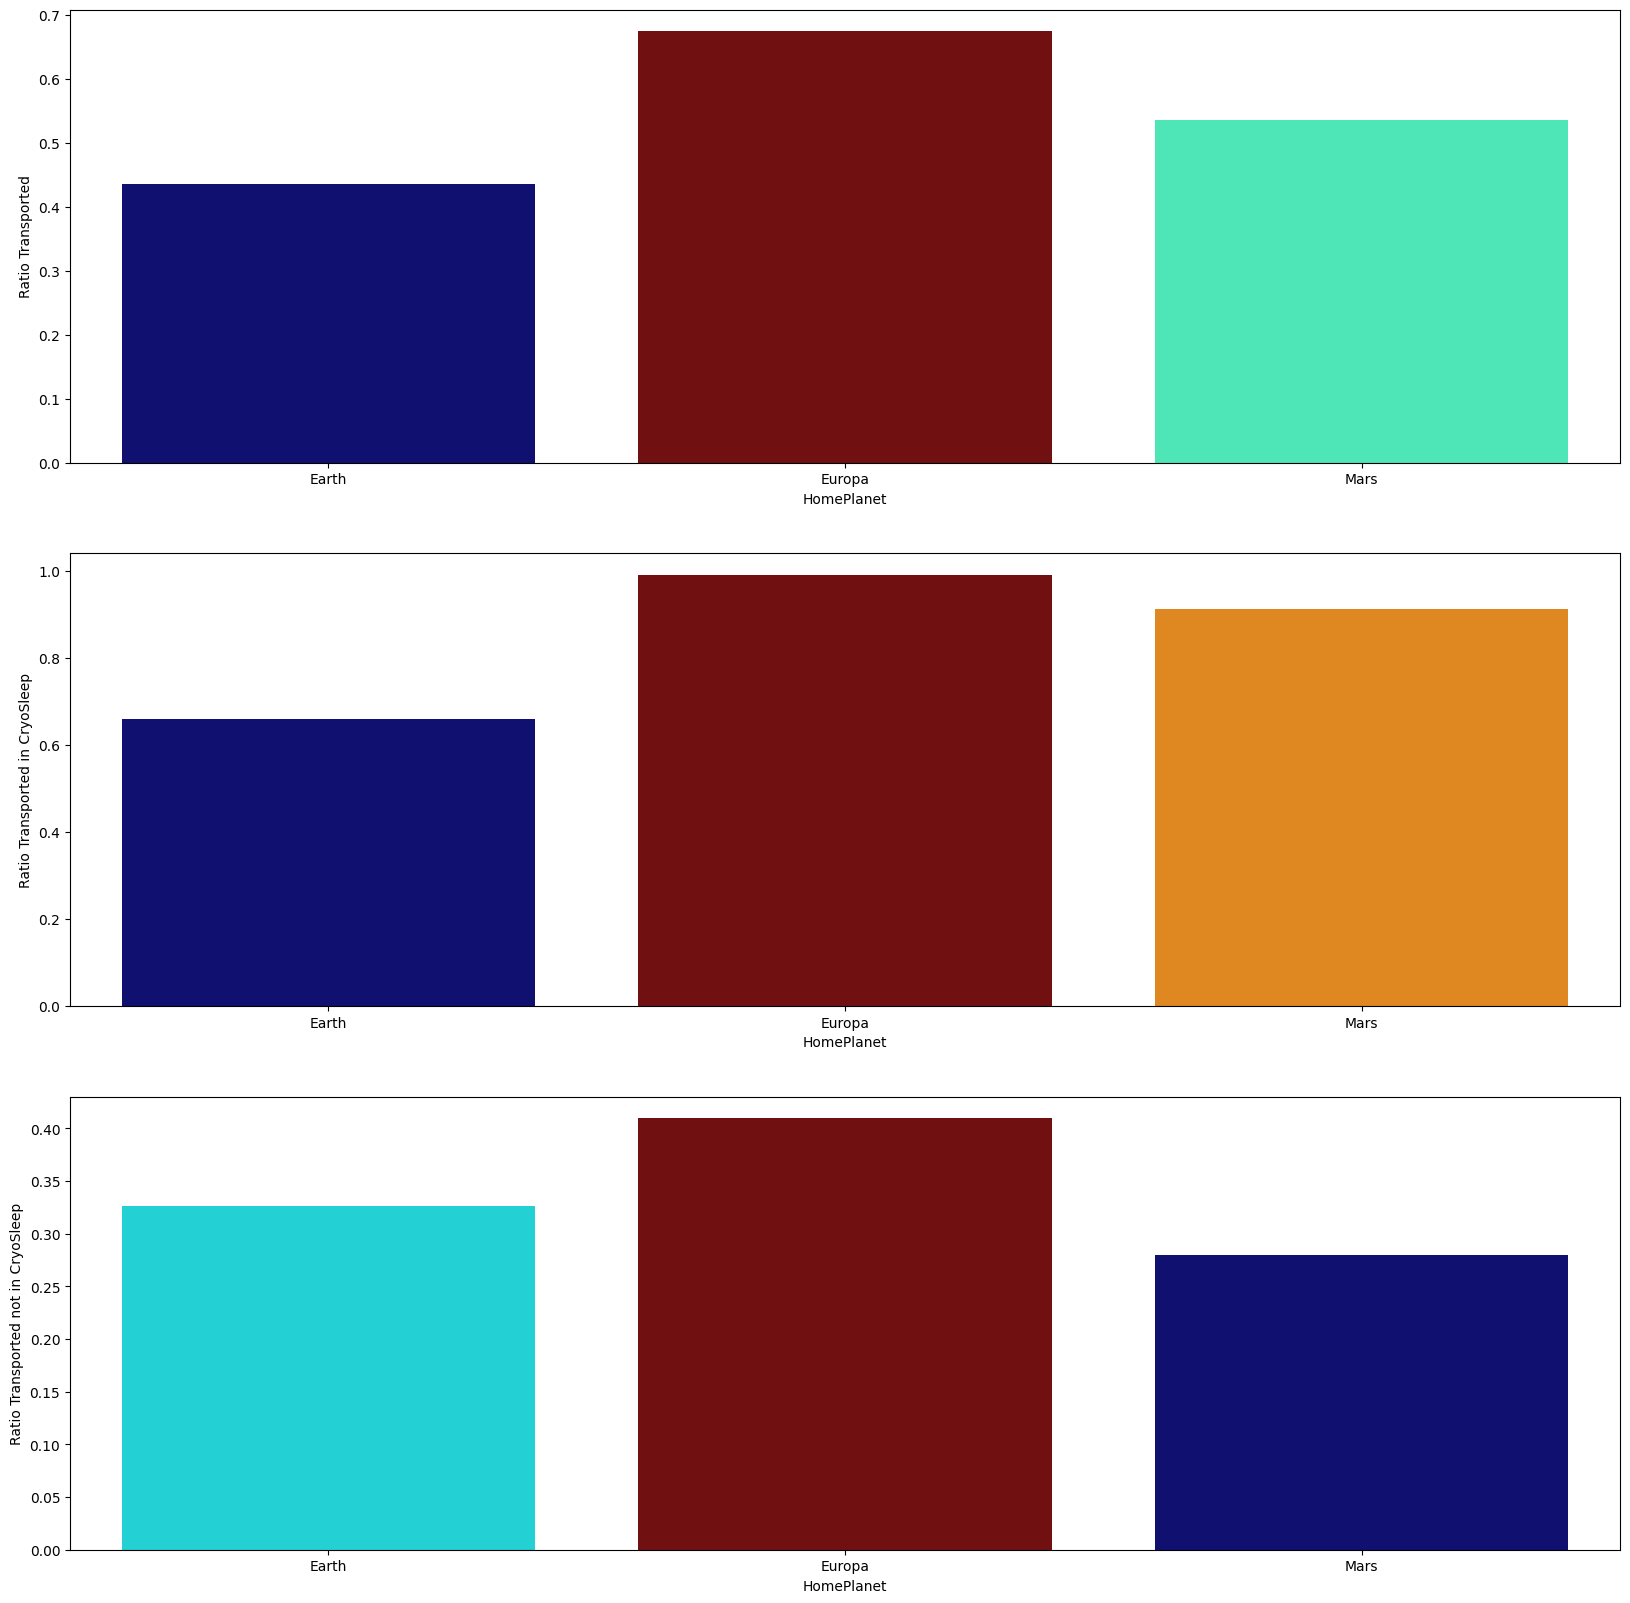

In [43]:
_, _ = plot_ratios_by_Cryo_and_Transported(df0, 'HomePlanet', cat = True)

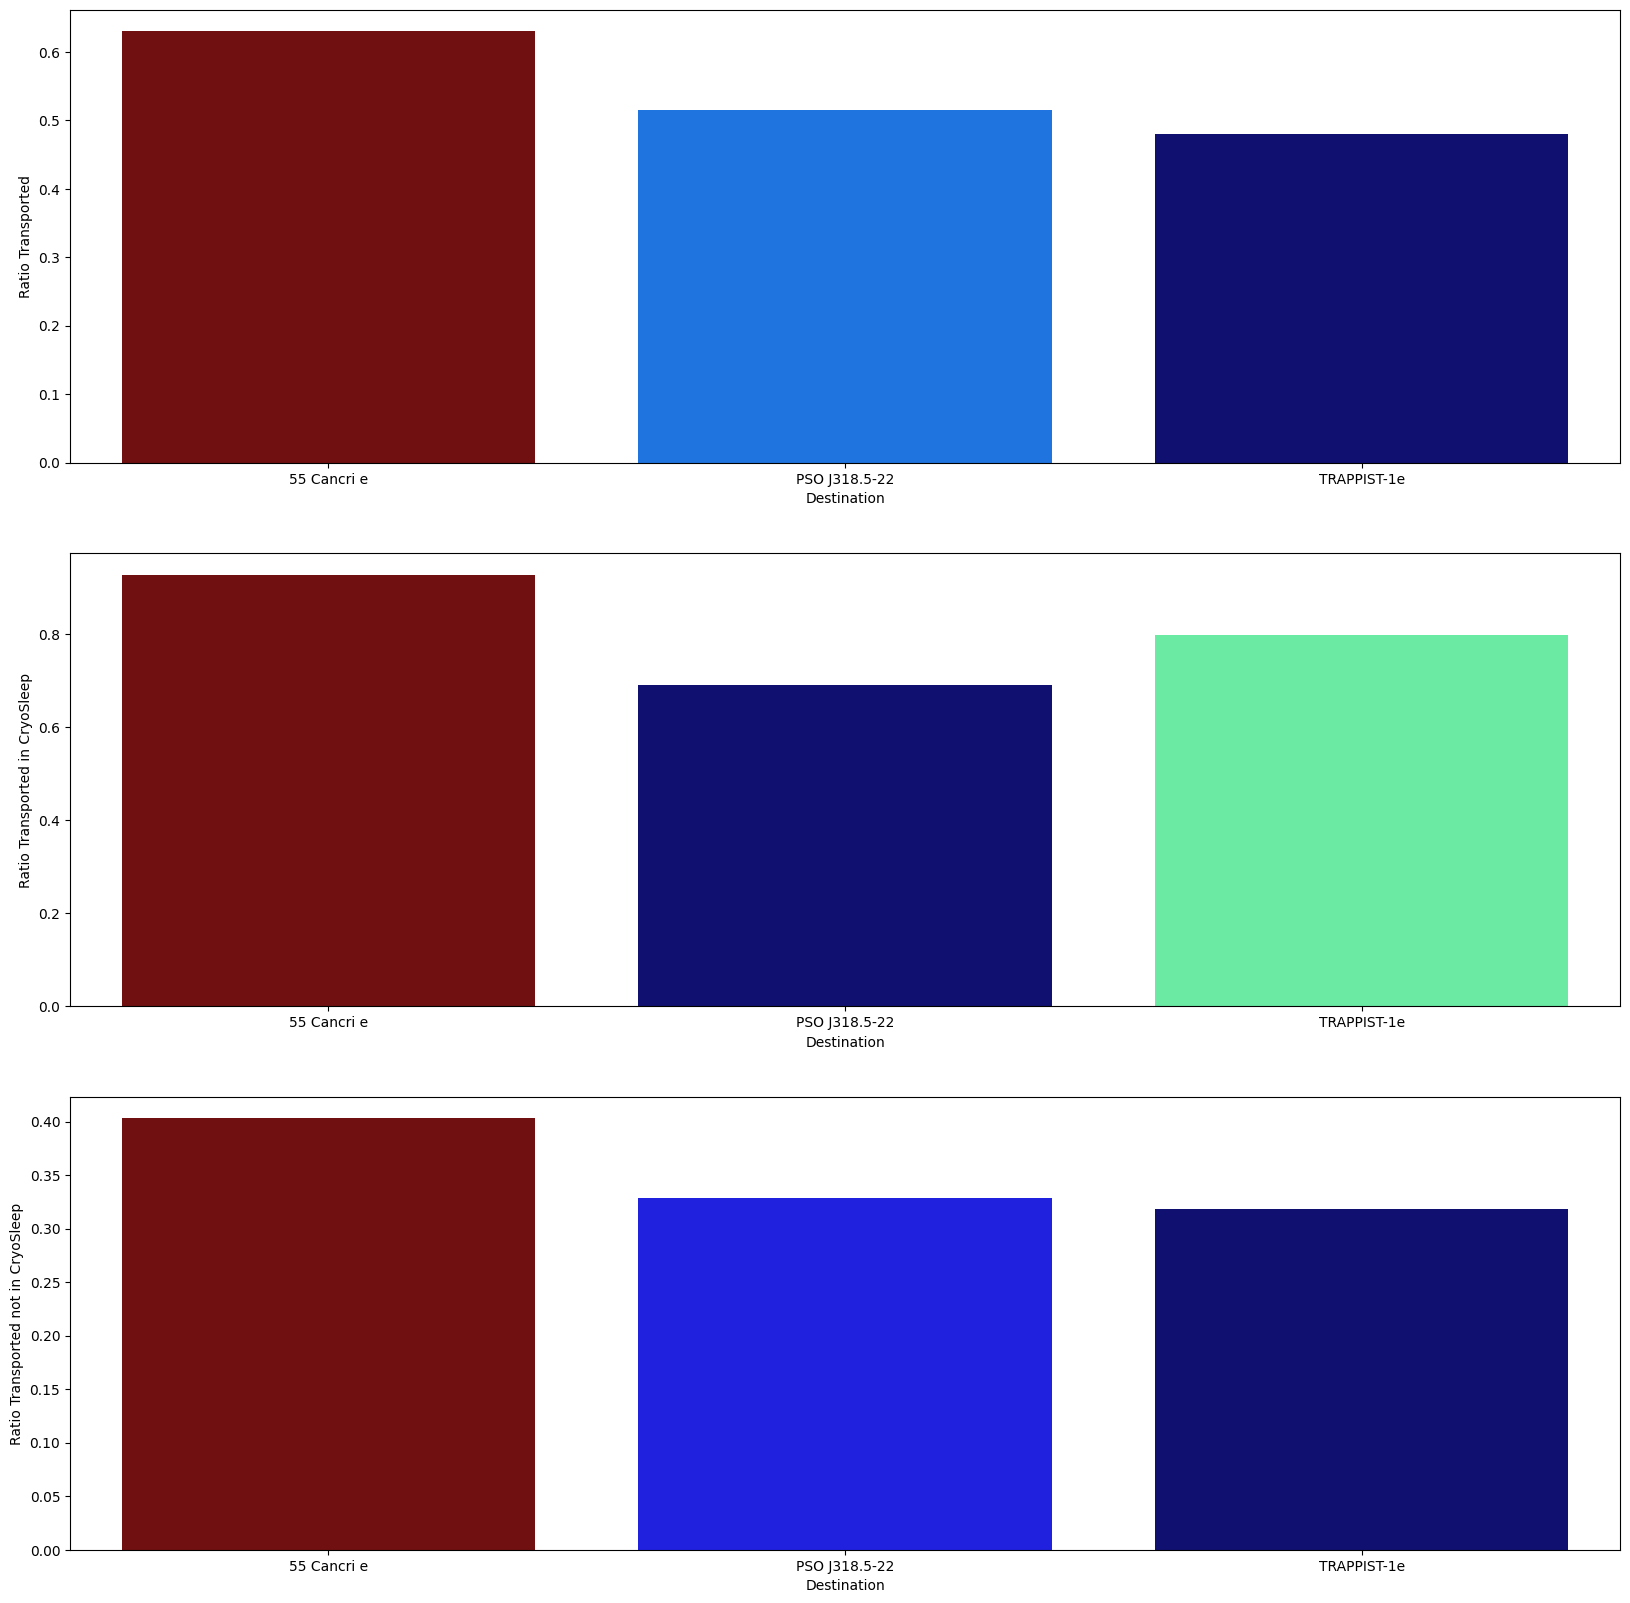

In [44]:
_, _ = plot_ratios_by_Cryo_and_Transported(df0, 'Destination', cat = True)

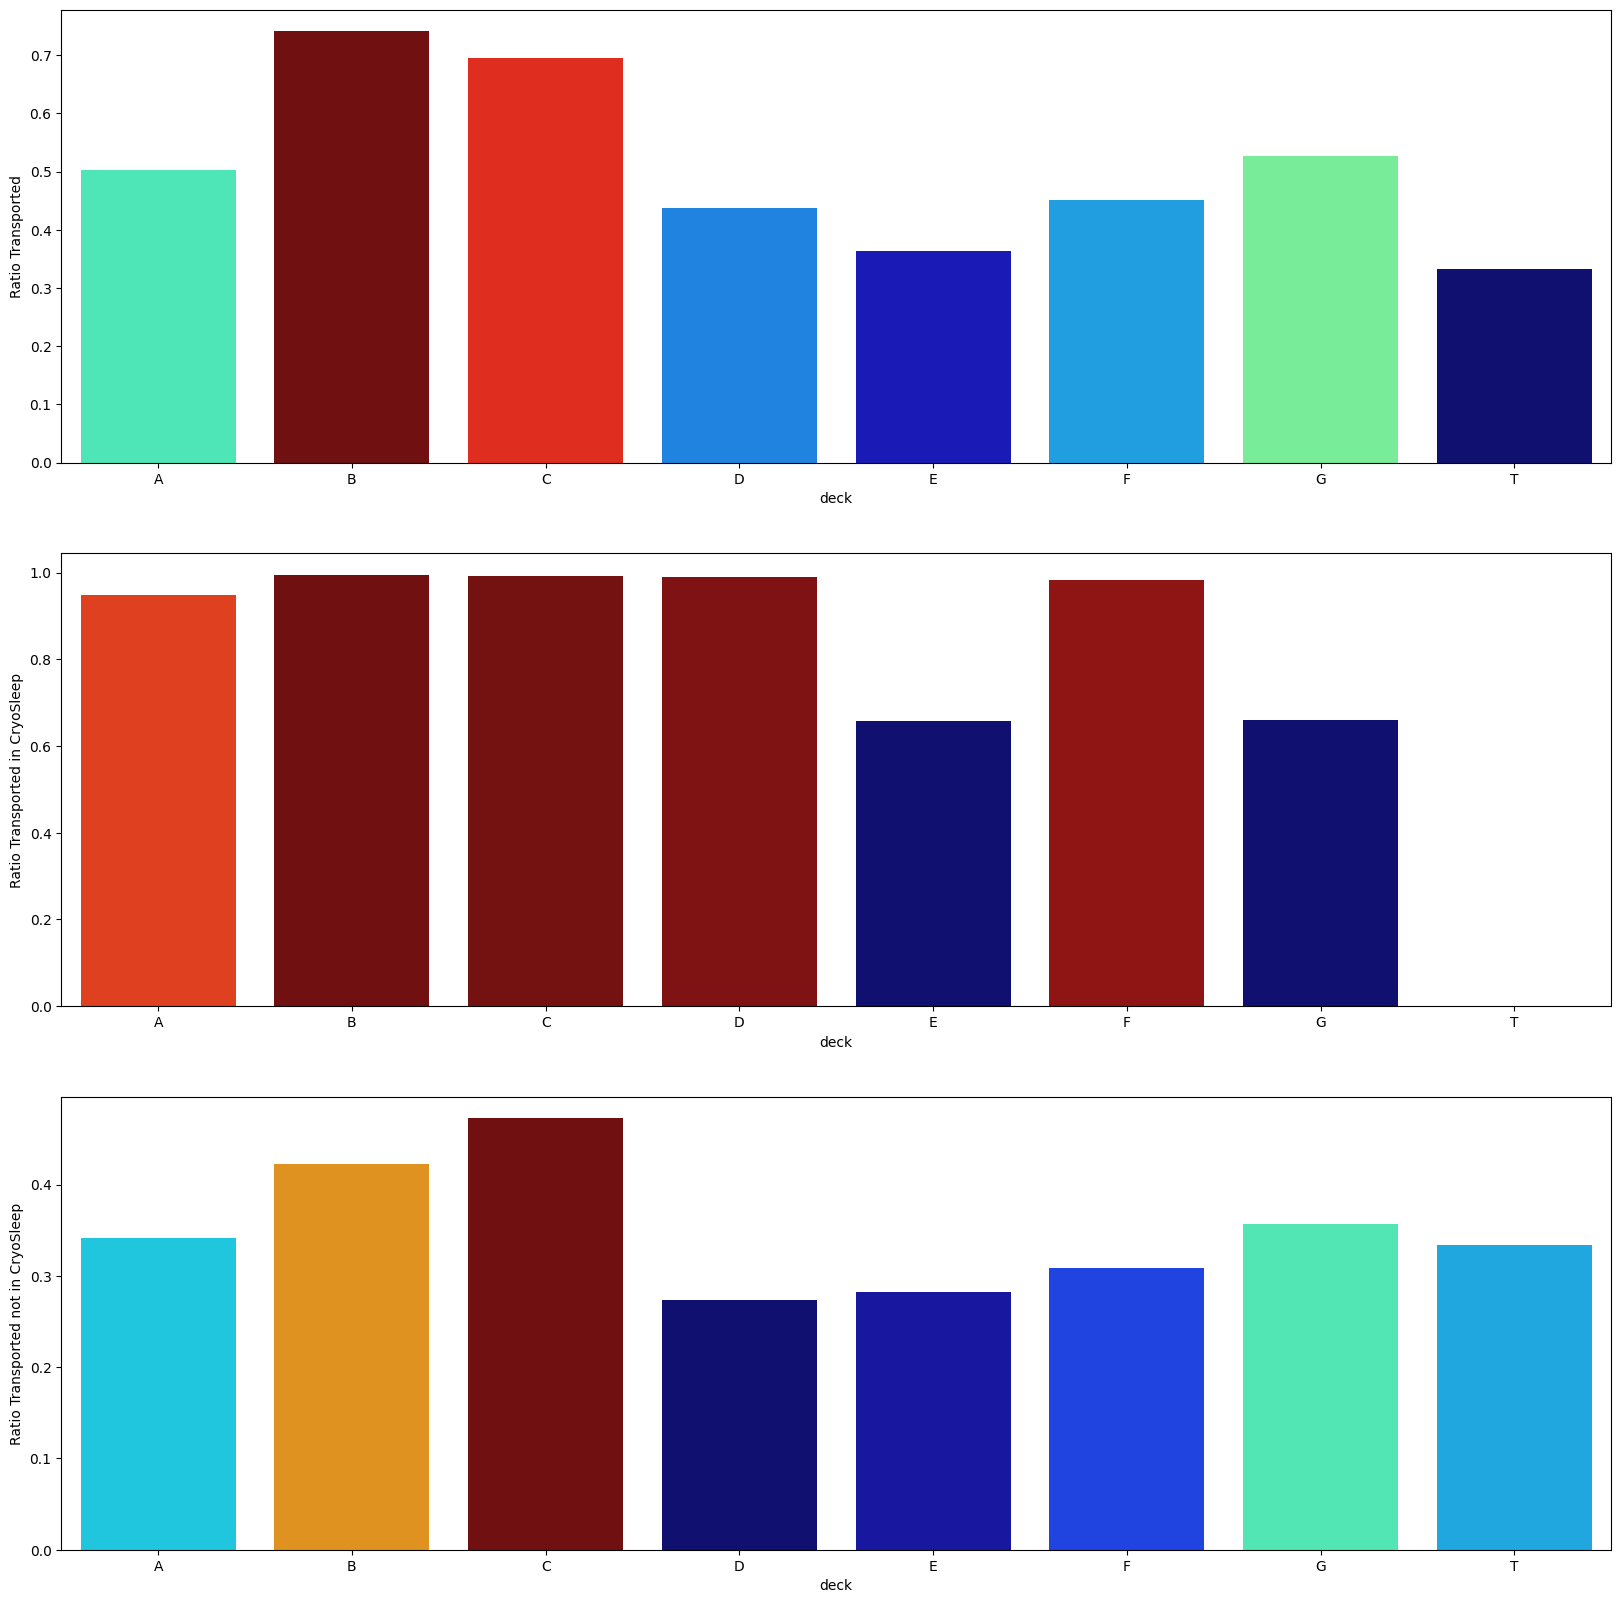

In [45]:
_, _ = plot_ratios_by_Cryo_and_Transported(df0, 'deck', cat = True)

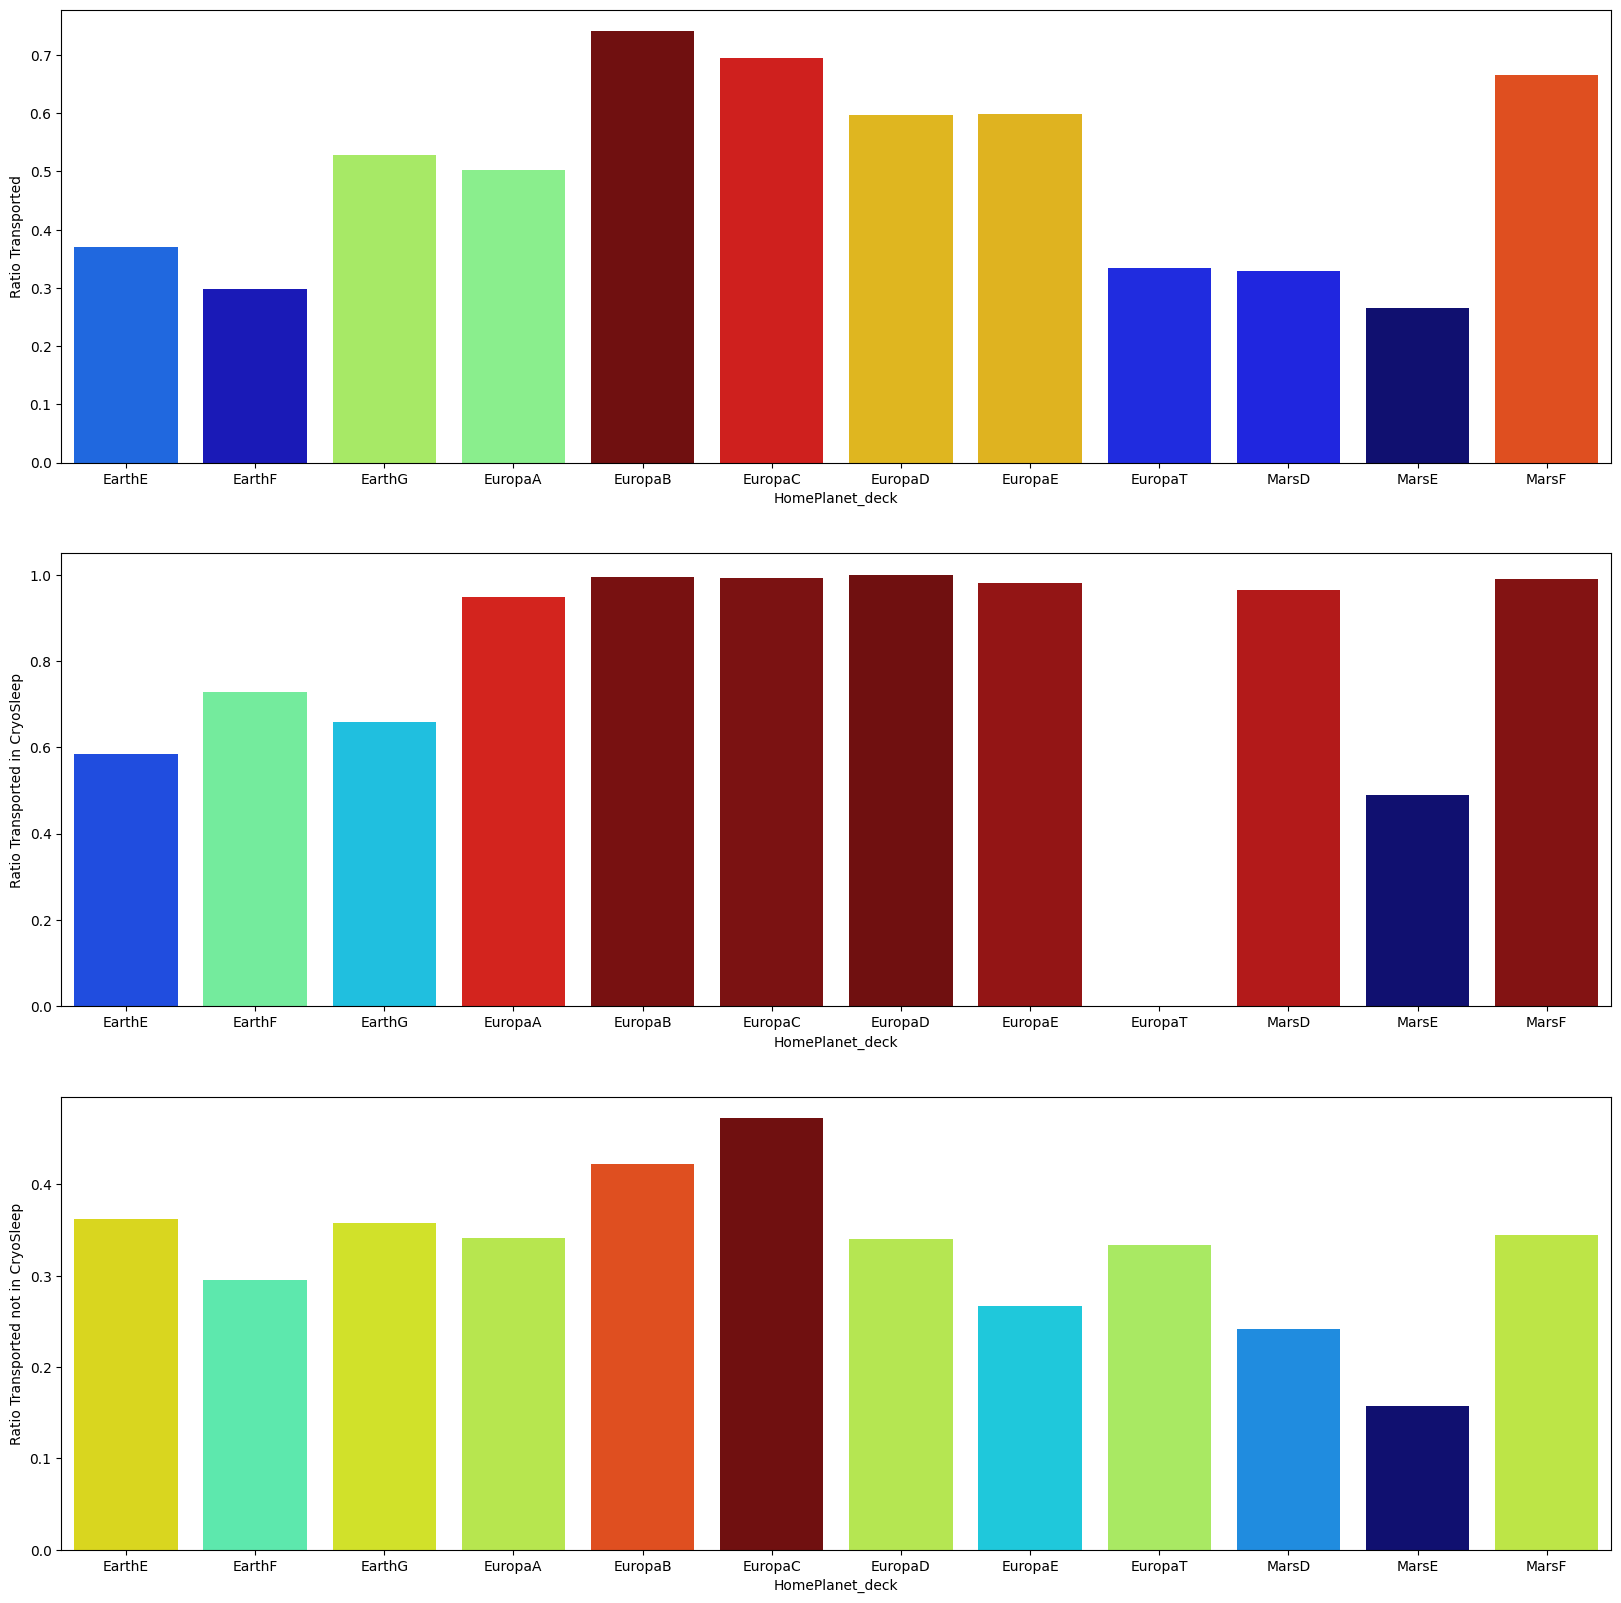

In [46]:
_, _ = plot_ratios_by_Cryo_and_Transported(df0, 'HomePlanet_deck', cat = True)

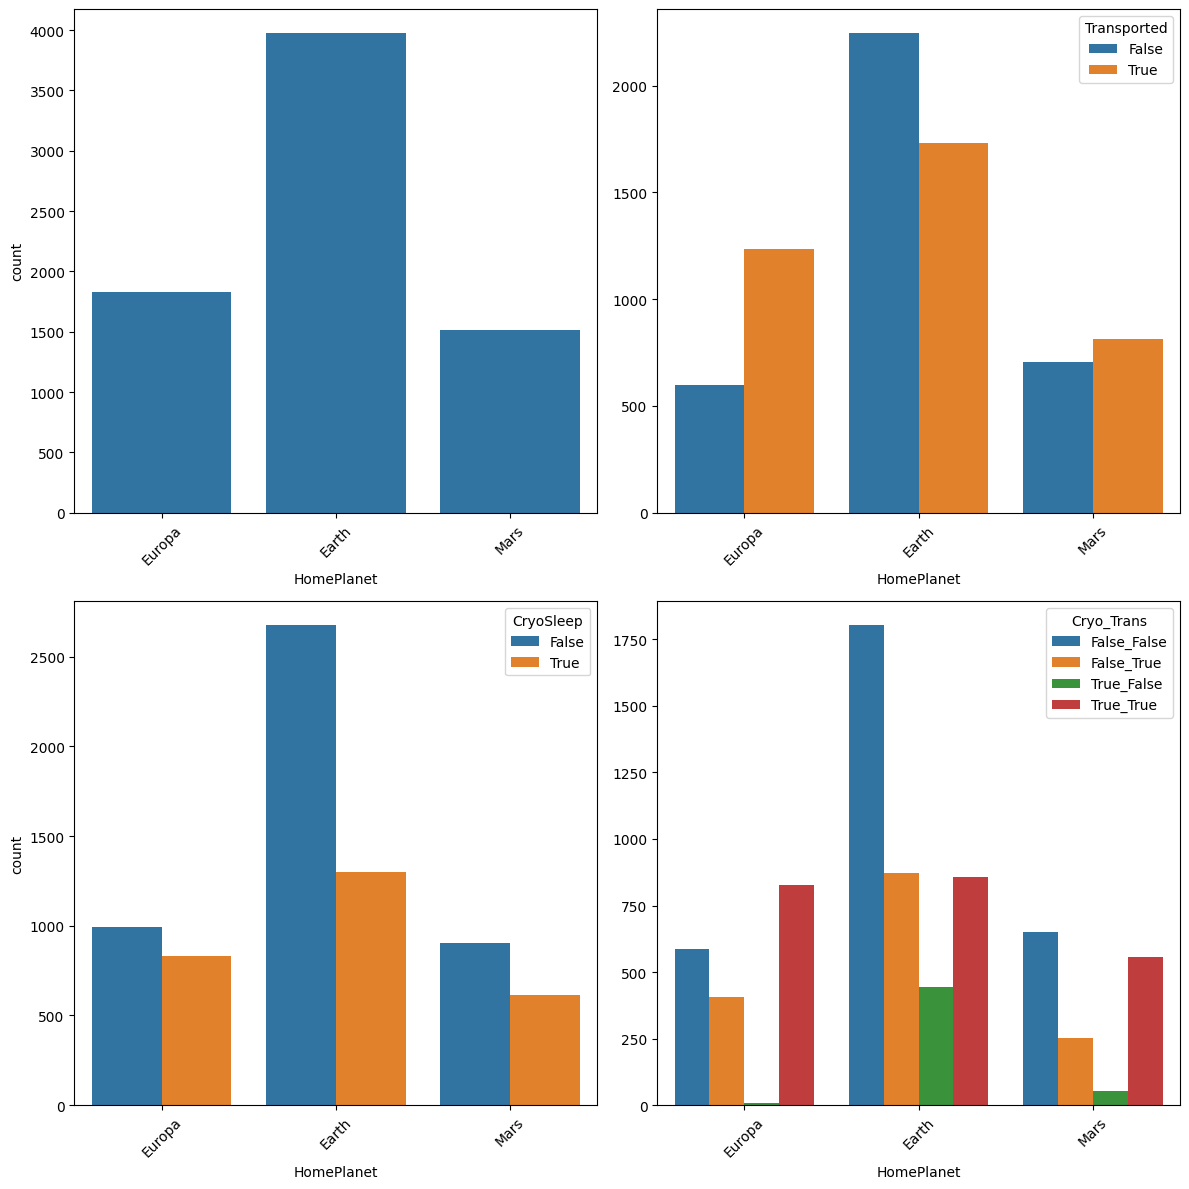

In [47]:
plot_CryoTrans_Counts(df0, 'HomePlanet', df0.HomePlanet.unique().tolist())

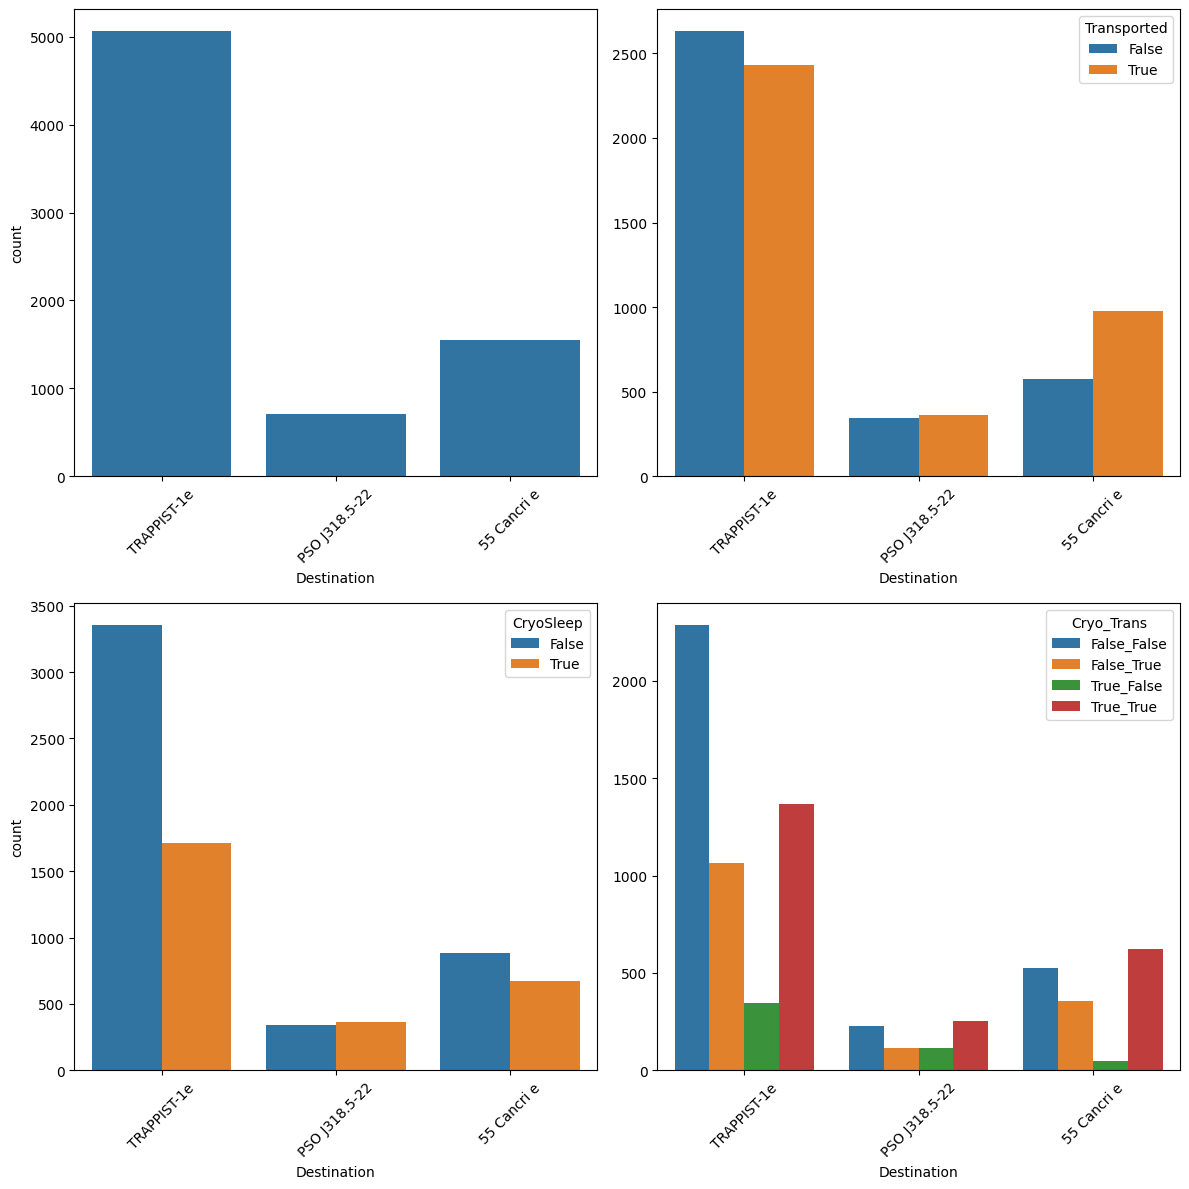

In [48]:
plot_CryoTrans_Counts(df0, 'Destination', df0.Destination.unique().tolist())

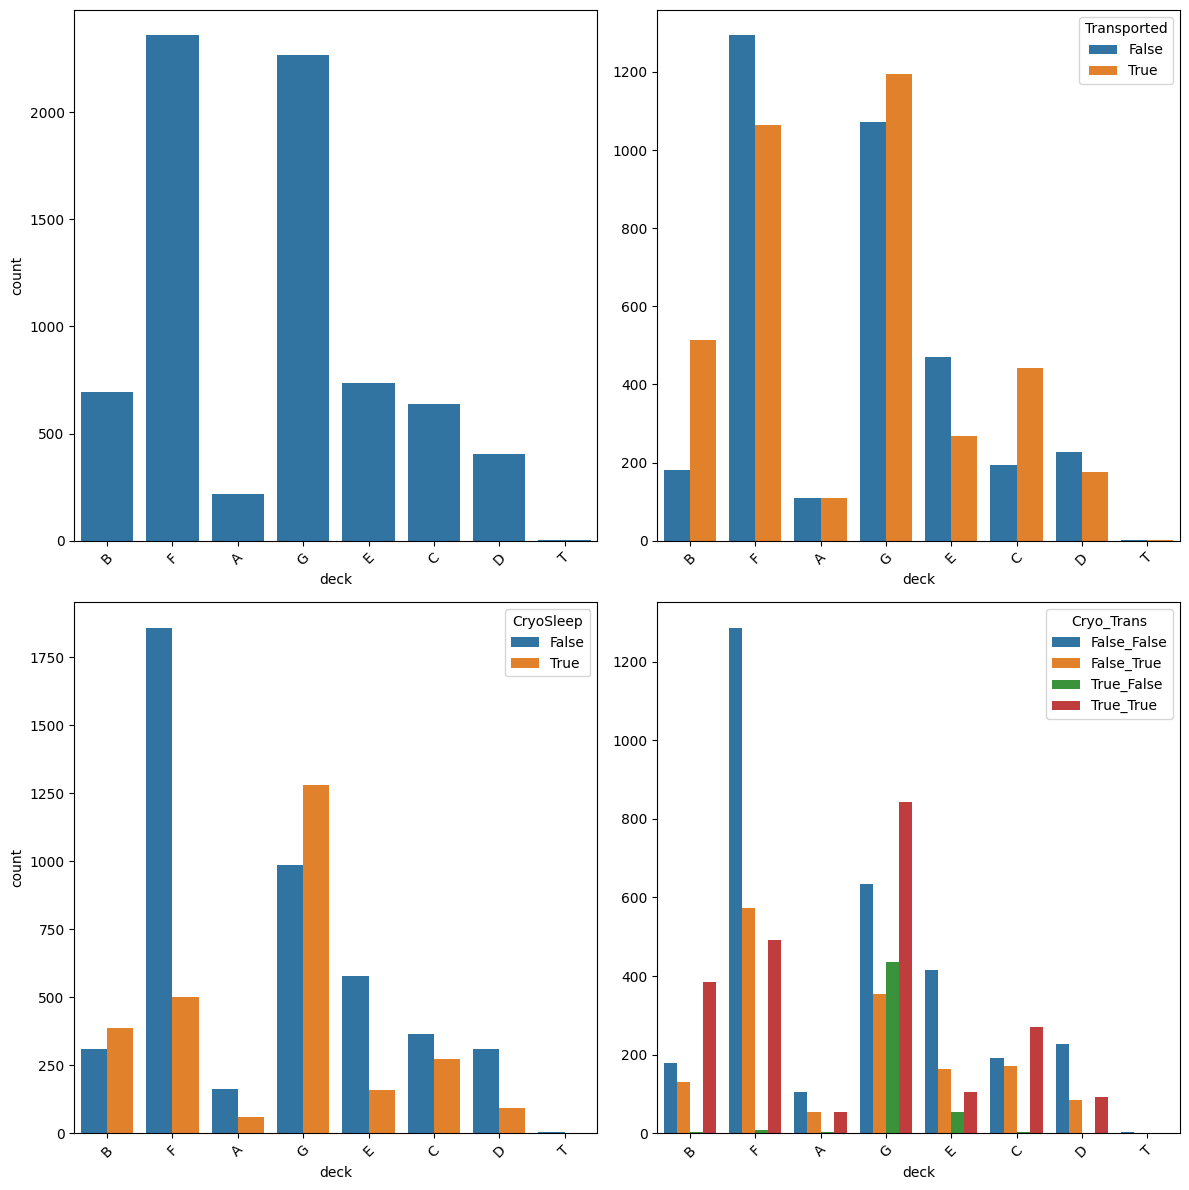

In [49]:
plot_CryoTrans_Counts(df0, 'deck', df0.deck.unique().tolist())

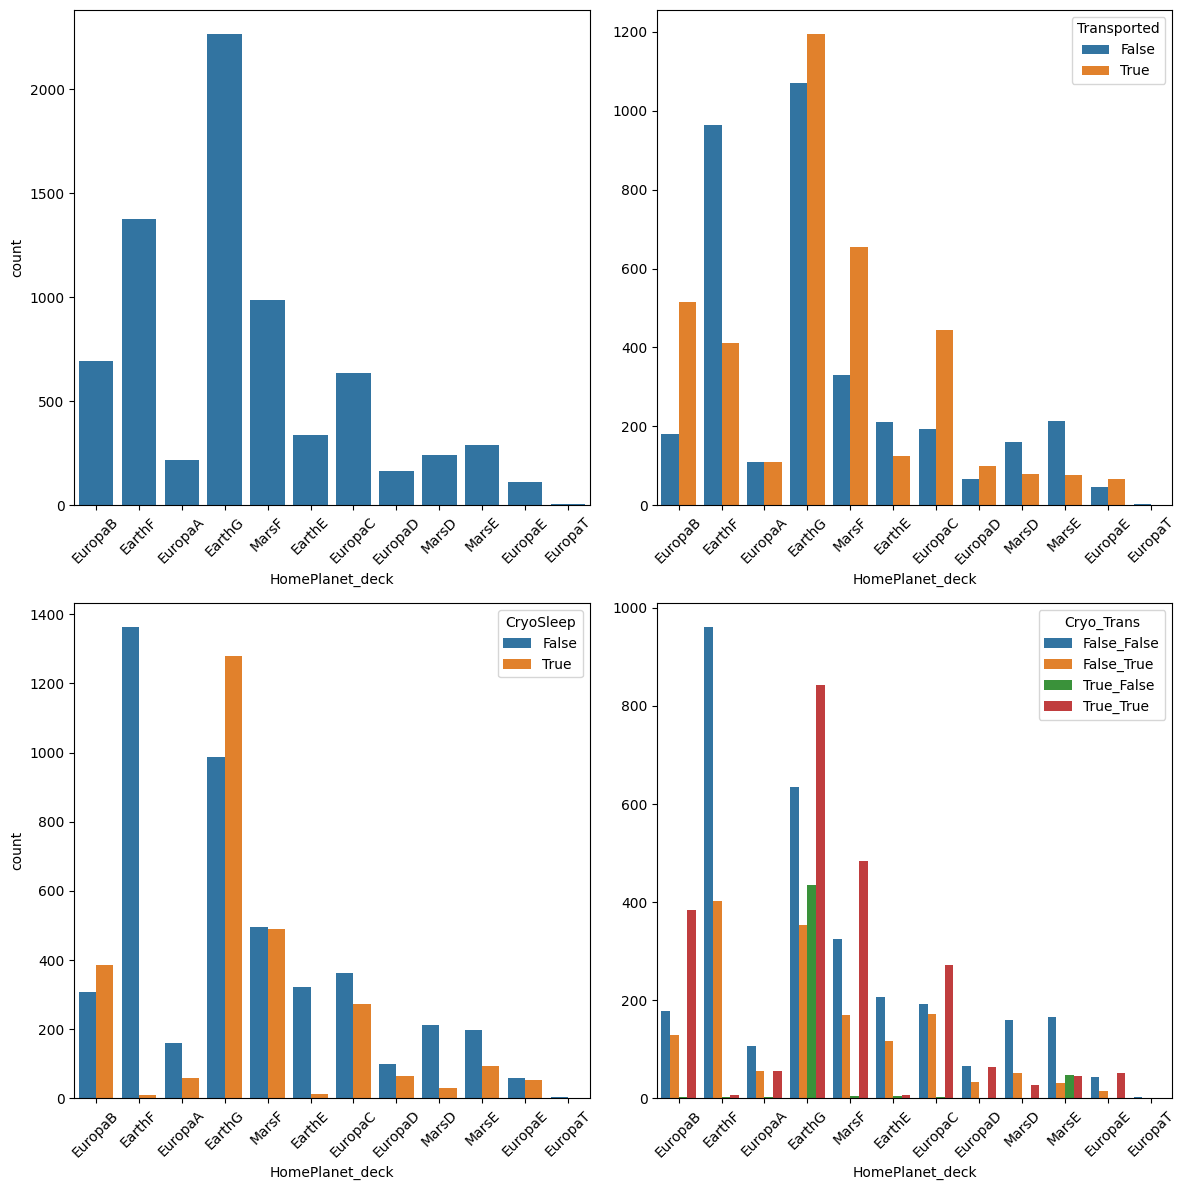

In [50]:
plot_CryoTrans_Counts(df0, 'HomePlanet_deck', df0.HomePlanet_deck.unique().tolist())

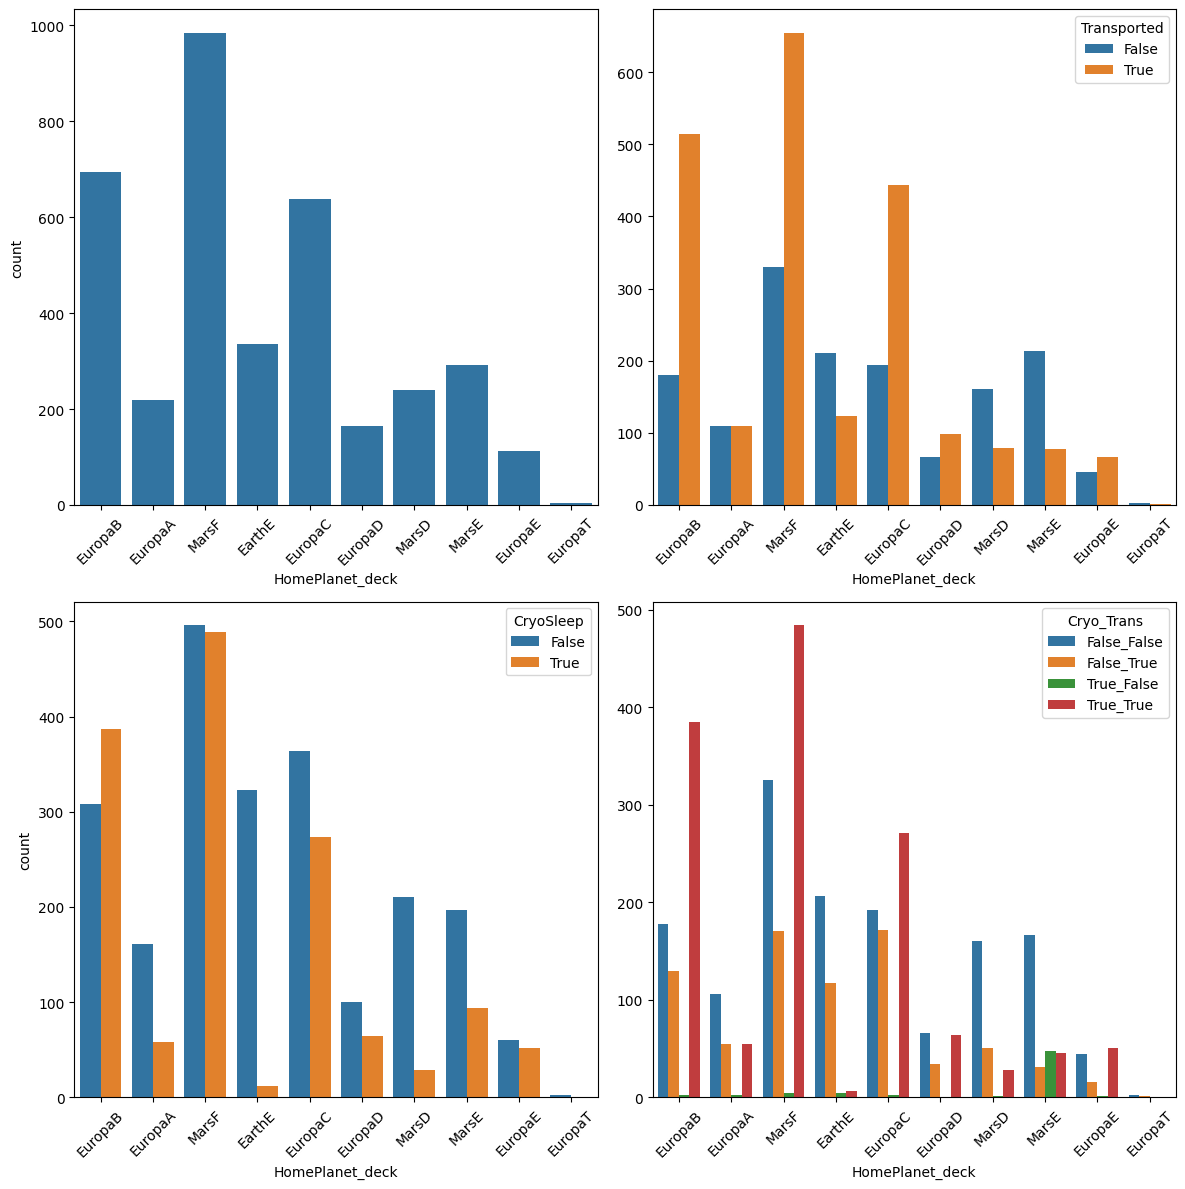

In [51]:
df0_temp = df0[(df0.HomePlanet_deck != 'EarthG') & (df0.HomePlanet_deck != 'EarthF')]
plot_CryoTrans_Counts(df0_temp, 'HomePlanet_deck', df0_temp.HomePlanet_deck.unique().tolist())

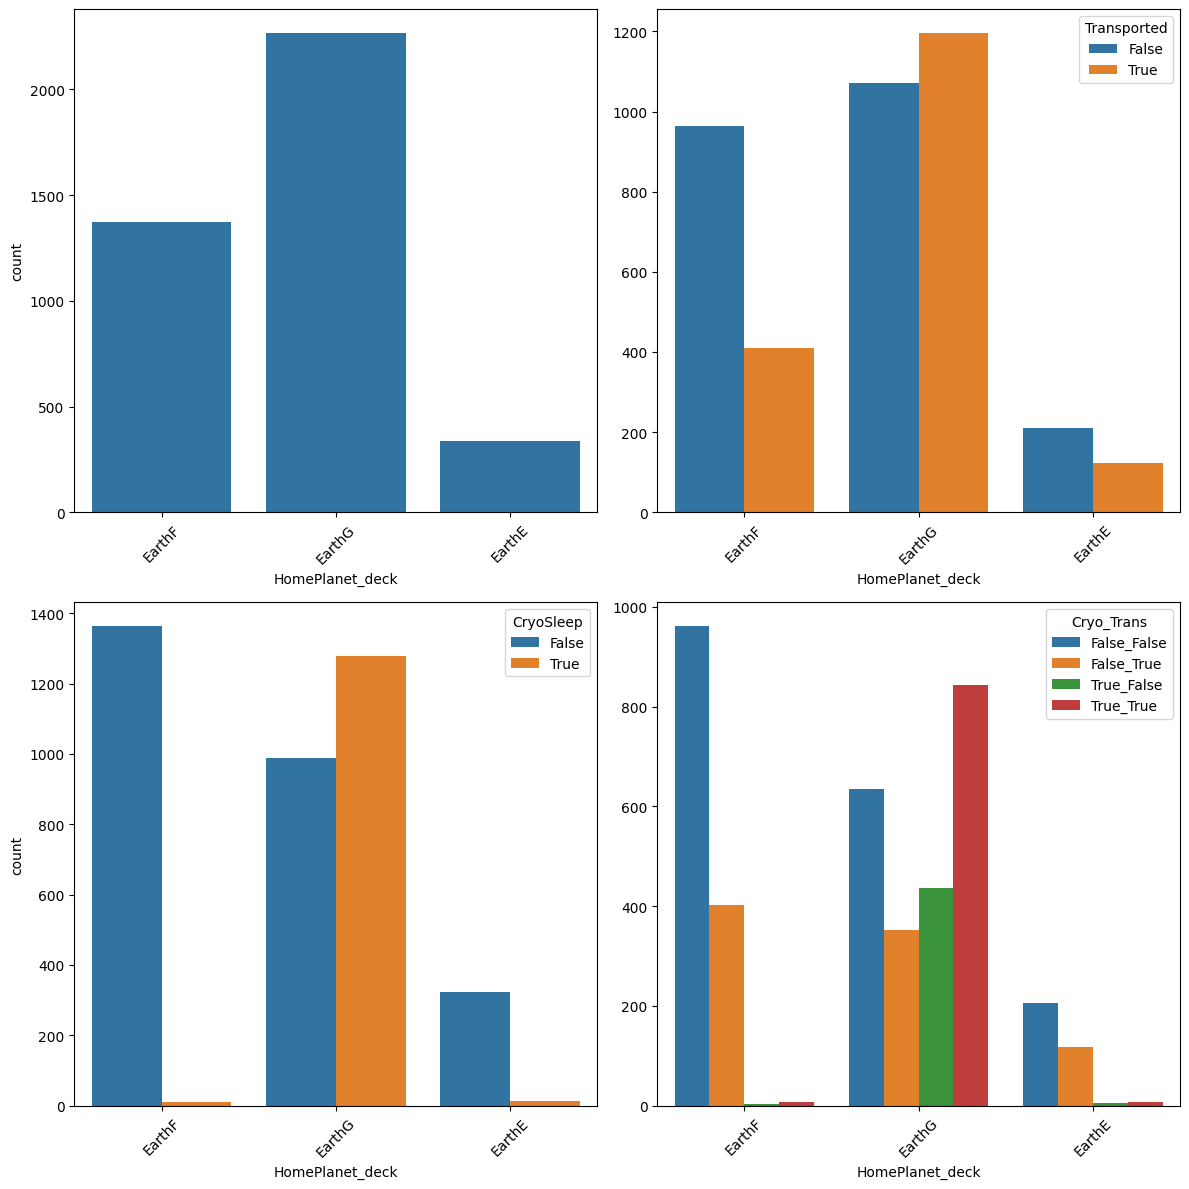

In [52]:
df0_temp = df0[df0.HomePlanet == 'Earth']
plot_CryoTrans_Counts(df0_temp, 'HomePlanet_deck', df0_temp.HomePlanet_deck.unique().tolist())

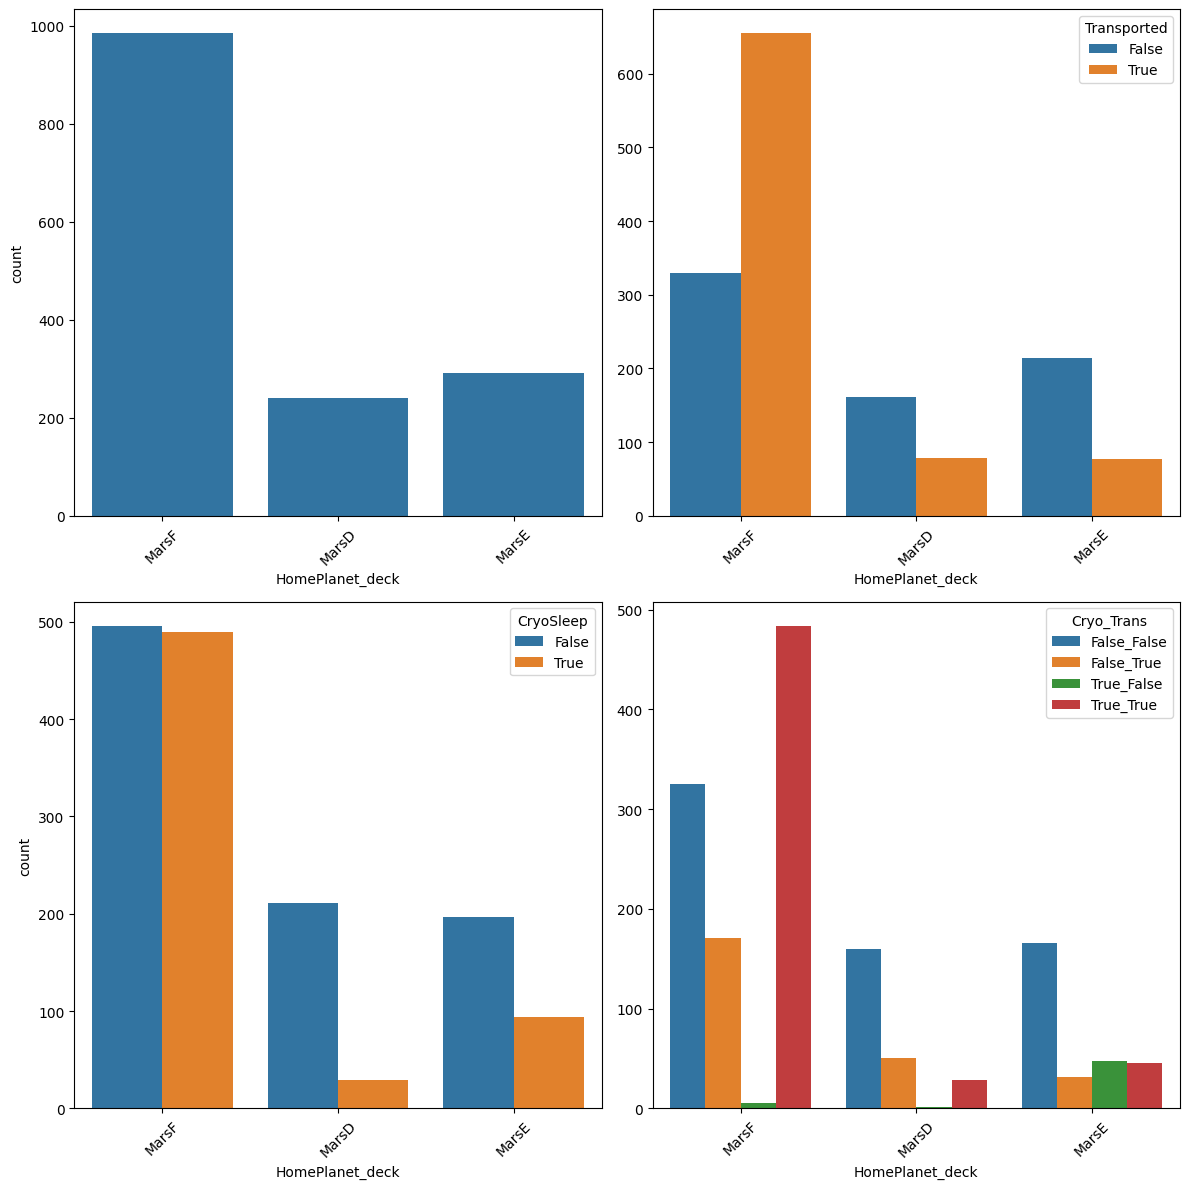

In [53]:
df0_temp = df0[df0.HomePlanet == 'Mars']
plot_CryoTrans_Counts(df0_temp, 'HomePlanet_deck', df0_temp.HomePlanet_deck.unique().tolist())

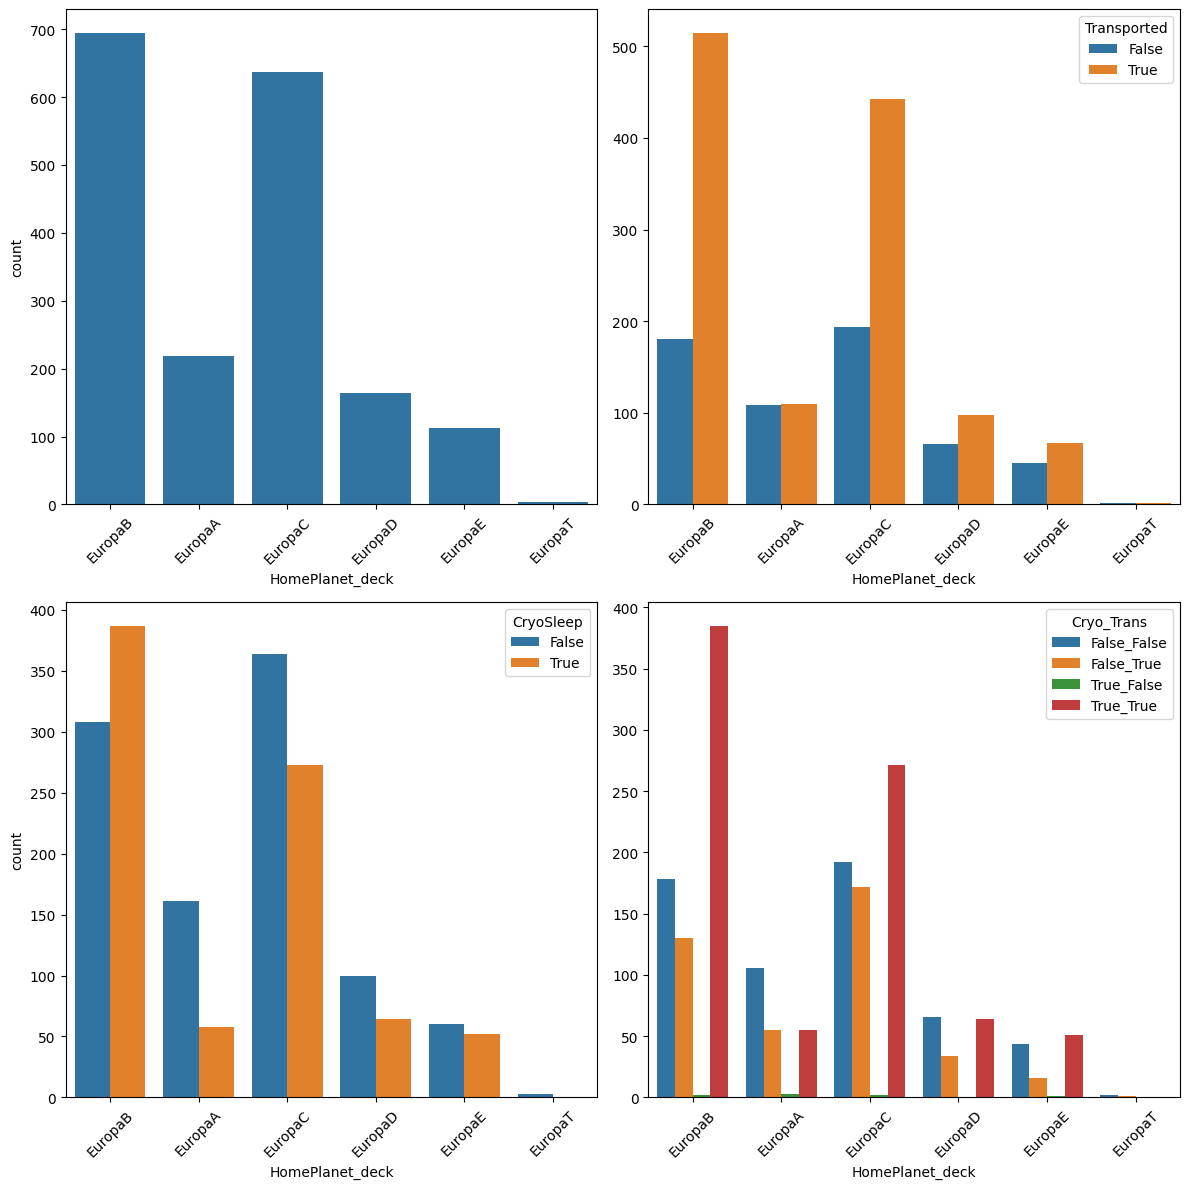

In [54]:
df0_temp = df0[df0.HomePlanet == 'Europa']
plot_CryoTrans_Counts(df0_temp, 'HomePlanet_deck', df0_temp.HomePlanet_deck.unique().tolist())

### Now, let's examine the effect of HomePlanet, Destination, and Deck on few ML algorithms

In [55]:
df0

,CryoSleep,Transported,HomePlanet,Destination,deck,HomePlanet_deck
PassengerId,,,,,,
0001_01,0,0,Europa,TRAPPIST-1e,B,EuropaB
0002_01,0,1,Earth,TRAPPIST-1e,F,EarthF
0003_01,0,0,Europa,TRAPPIST-1e,A,EuropaA
0003_02,0,0,Europa,TRAPPIST-1e,A,EuropaA
0004_01,0,1,Earth,TRAPPIST-1e,F,EarthF
...,...,...,...,...,...,...
9276_01,0,0,Europa,55 Cancri e,A,EuropaA
9278_01,1,0,Earth,PSO J318.5-22,G,EarthG
9279_01,0,1,Earth,TRAPPIST-1e,G,EarthG


In [56]:
df0_base

,Spa,RoomService,VRDeck,FoodCourt,ShoppingMall,Under_13
PassengerId,,,,,,
0001_01,0.000000,0.000000,0.000000,0.000000,0.000000,0
0002_01,6.309918,4.700480,3.806662,2.302585,3.258097,0
0003_01,8.812248,3.784190,3.912023,8.182280,0.000000,0
0003_02,8.110728,0.000000,5.267858,7.157735,5.918894,0
0004_01,6.338594,5.717028,1.098612,4.262680,5.023881,0
...,...,...,...,...,...,...
9276_01,7.404888,0.000000,4.317488,8.827615,0.000000,0
9278_01,0.000000,0.000000,0.000000,0.000000,0.000000,0
9279_01,0.693147,0.000000,0.000000,0.000000,7.535297,0


In [57]:
df1 = pd.concat([df0[['CryoSleep', 'Transported']], df0_base], axis = 1)
for feature in ['HomePlanet', 'Destination', 'deck', 'HomePlanet_deck']:
    prefix = feature if feature != 'HomePlanet_deck' else 'HD'
    one_hot_encoded = pd.get_dummies(df0[feature], prefix = prefix).astype(int)
    df1 = pd.concat([df1, one_hot_encoded], axis = 1)

HomePlanet_Features = [col for col in df1.columns if col.startswith('HomePlanet_')]
Destination_Features = [col for col in df1.columns if col.startswith('Destination_')]
deck_Features = [col for col in df1.columns if col.startswith('deck_')]
HomePlanet_deck_Features = [col for col in df1.columns if col.startswith('HD_')]

In [58]:
basic_list = ['CryoSleep']
features_list = HomePlanet_Features
Compare_Ordered_Feature_Lists(df1, 'Transported', basic_list, features_list, Kfold = 10)

List0:  ['CryoSleep']
List1:  ['CryoSleep', 'HomePlanet_Earth']
List2:  ['CryoSleep', 'HomePlanet_Earth', 'HomePlanet_Europa']
List3:  ['CryoSleep', 'HomePlanet_Earth', 'HomePlanet_Europa', 'HomePlanet_Mars']


,List0,List1,List2,List3
Naive Bayes,0.7234,0.7234,0.6988,0.6988
Logistic Regression,0.7234,0.7234,0.7190,0.7190
LightGBM,0.7234,0.7234,0.7234,0.7234
CatBoost,0.7234,0.7234,0.7234,0.7234


In [59]:
basic_list = ['CryoSleep'] + Features0
features_list = HomePlanet_Features
Compare_Ordered_Feature_Lists(df1, 'Transported', basic_list, features_list, Kfold = 10)

List0:  ['CryoSleep', 'Spa', 'RoomService', 'VRDeck', 'FoodCourt', 'ShoppingMall', 'Under_13']
List1:  ['CryoSleep', 'Spa', 'RoomService', 'VRDeck', 'FoodCourt', 'ShoppingMall', 'Under_13', 'HomePlanet_Earth']
List2:  ['CryoSleep', 'Spa', 'RoomService', 'VRDeck', 'FoodCourt', 'ShoppingMall', 'Under_13', 'HomePlanet_Earth', 'HomePlanet_Europa']
List3:  ['CryoSleep', 'Spa', 'RoomService', 'VRDeck', 'FoodCourt', 'ShoppingMall', 'Under_13', 'HomePlanet_Earth', 'HomePlanet_Europa', 'HomePlanet_Mars']


,List0,List1,List2,List3
Naive Bayes,0.7455,0.7434,0.7449,0.7444
Logistic Regression,0.7770,0.7771,0.7777,0.7777
LightGBM,0.8007,0.8018,0.8011,0.8010
CatBoost,0.7994,0.7990,0.8004,0.7980


In [60]:
basic_list = ['CryoSleep']
features_list = Destination_Features
Compare_Ordered_Feature_Lists(df1, 'Transported', basic_list, features_list, Kfold = 10)

List0:  ['CryoSleep']
List1:  ['CryoSleep', 'Destination_55 Cancri e']
List2:  ['CryoSleep', 'Destination_55 Cancri e', 'Destination_PSO J318.5-22']
List3:  ['CryoSleep', 'Destination_55 Cancri e', 'Destination_PSO J318.5-22', 'Destination_TRAPPIST-1e']


,List0,List1,List2,List3
Naive Bayes,0.7234,0.7038,0.7038,0.7014
Logistic Regression,0.7234,0.7234,0.7234,0.7234
LightGBM,0.7234,0.7234,0.7234,0.7234
CatBoost,0.7234,0.7234,0.7234,0.7234


In [61]:
basic_list = ['CryoSleep'] + Features0
features_list = Destination_Features
Compare_Ordered_Feature_Lists(df1, 'Transported', basic_list, features_list, Kfold = 10)

List0:  ['CryoSleep', 'Spa', 'RoomService', 'VRDeck', 'FoodCourt', 'ShoppingMall', 'Under_13']
List1:  ['CryoSleep', 'Spa', 'RoomService', 'VRDeck', 'FoodCourt', 'ShoppingMall', 'Under_13', 'Destination_55 Cancri e']
List2:  ['CryoSleep', 'Spa', 'RoomService', 'VRDeck', 'FoodCourt', 'ShoppingMall', 'Under_13', 'Destination_55 Cancri e', 'Destination_PSO J318.5-22']
List3:  ['CryoSleep', 'Spa', 'RoomService', 'VRDeck', 'FoodCourt', 'ShoppingMall', 'Under_13', 'Destination_55 Cancri e', 'Destination_PSO J318.5-22', 'Destination_TRAPPIST-1e']


,List0,List1,List2,List3
Naive Bayes,0.7455,0.7453,0.7453,0.7448
Logistic Regression,0.7769,0.7775,0.7775,0.7775
LightGBM,0.8007,0.8005,0.8011,0.8012
CatBoost,0.7994,0.7982,0.7977,0.7982


In [62]:
basic_list = ['CryoSleep']
features_list = deck_Features
Compare_Ordered_Feature_Lists(df1, 'Transported', basic_list, features_list, Kfold = 10)

List0:  ['CryoSleep']
List1:  ['CryoSleep', 'deck_A']
List2:  ['CryoSleep', 'deck_A', 'deck_B']
List3:  ['CryoSleep', 'deck_A', 'deck_B', 'deck_C']
List4:  ['CryoSleep', 'deck_A', 'deck_B', 'deck_C', 'deck_D']
List5:  ['CryoSleep', 'deck_A', 'deck_B', 'deck_C', 'deck_D', 'deck_E']
List6:  ['CryoSleep', 'deck_A', 'deck_B', 'deck_C', 'deck_D', 'deck_E', 'deck_F']
List7:  ['CryoSleep', 'deck_A', 'deck_B', 'deck_C', 'deck_D', 'deck_E', 'deck_F', 'deck_G']
List8:  ['CryoSleep', 'deck_A', 'deck_B', 'deck_C', 'deck_D', 'deck_E', 'deck_F', 'deck_G', 'deck_T']


,List0,List1,List2,List3,List4,List5,List6,List7,List8
Naive Bayes,0.7234,0.7226,0.7178,0.7142,0.7003,0.6930,0.6930,0.6930,0.6767
Logistic Regression,0.7234,0.7234,0.7186,0.7150,0.7150,0.7150,0.7150,0.7150,0.7150
LightGBM,0.7234,0.7234,0.7234,0.7220,0.7220,0.7220,0.7220,0.7220,0.7220
CatBoost,0.7234,0.7234,0.7234,0.7220,0.7220,0.7220,0.7220,0.7234,0.7234


In [63]:
basic_list = ['CryoSleep'] + Features0
features_list = deck_Features
Compare_Ordered_Feature_Lists(df1, 'Transported', basic_list, features_list, Kfold = 10)

List0:  ['CryoSleep', 'Spa', 'RoomService', 'VRDeck', 'FoodCourt', 'ShoppingMall', 'Under_13']
List1:  ['CryoSleep', 'Spa', 'RoomService', 'VRDeck', 'FoodCourt', 'ShoppingMall', 'Under_13', 'deck_A']
List2:  ['CryoSleep', 'Spa', 'RoomService', 'VRDeck', 'FoodCourt', 'ShoppingMall', 'Under_13', 'deck_A', 'deck_B']
List3:  ['CryoSleep', 'Spa', 'RoomService', 'VRDeck', 'FoodCourt', 'ShoppingMall', 'Under_13', 'deck_A', 'deck_B', 'deck_C']
List4:  ['CryoSleep', 'Spa', 'RoomService', 'VRDeck', 'FoodCourt', 'ShoppingMall', 'Under_13', 'deck_A', 'deck_B', 'deck_C', 'deck_D']
List5:  ['CryoSleep', 'Spa', 'RoomService', 'VRDeck', 'FoodCourt', 'ShoppingMall', 'Under_13', 'deck_A', 'deck_B', 'deck_C', 'deck_D', 'deck_E']
List6:  ['CryoSleep', 'Spa', 'RoomService', 'VRDeck', 'FoodCourt', 'ShoppingMall', 'Under_13', 'deck_A', 'deck_B', 'deck_C', 'deck_D', 'deck_E', 'deck_F']
List7:  ['CryoSleep', 'Spa', 'RoomService', 'VRDeck', 'FoodCourt', 'ShoppingMall', 'Under_13', 'deck_A', 'deck_B', 'deck_C', 

,List0,List1,List2,List3,List4,List5,List6,List7,List8
Naive Bayes,0.7455,0.7448,0.7468,0.7519,0.7545,0.7582,0.7582,0.7582,0.7478
Logistic Regression,0.7770,0.7765,0.7786,0.7800,0.7811,0.7833,0.7835,0.7830,0.7830
LightGBM,0.8007,0.8007,0.8003,0.8014,0.8013,0.8013,0.7991,0.8014,0.8014
CatBoost,0.7994,0.7993,0.7988,0.8003,0.8018,0.8025,0.8053,0.8066,0.8047


In [64]:
basic_list = ['CryoSleep']
features_list = HomePlanet_deck_Features
Compare_Ordered_Feature_Lists(df1, 'Transported', basic_list, features_list, Kfold = 10)

List0:  ['CryoSleep']
List1:  ['CryoSleep', 'HD_EarthE']
List2:  ['CryoSleep', 'HD_EarthE', 'HD_EarthF']
List3:  ['CryoSleep', 'HD_EarthE', 'HD_EarthF', 'HD_EarthG']
List4:  ['CryoSleep', 'HD_EarthE', 'HD_EarthF', 'HD_EarthG', 'HD_EuropaA']
List5:  ['CryoSleep', 'HD_EarthE', 'HD_EarthF', 'HD_EarthG', 'HD_EuropaA', 'HD_EuropaB']
List6:  ['CryoSleep', 'HD_EarthE', 'HD_EarthF', 'HD_EarthG', 'HD_EuropaA', 'HD_EuropaB', 'HD_EuropaC']
List7:  ['CryoSleep', 'HD_EarthE', 'HD_EarthF', 'HD_EarthG', 'HD_EuropaA', 'HD_EuropaB', 'HD_EuropaC', 'HD_EuropaD']
List8:  ['CryoSleep', 'HD_EarthE', 'HD_EarthF', 'HD_EarthG', 'HD_EuropaA', 'HD_EuropaB', 'HD_EuropaC', 'HD_EuropaD', 'HD_EuropaE']
List9:  ['CryoSleep', 'HD_EarthE', 'HD_EarthF', 'HD_EarthG', 'HD_EuropaA', 'HD_EuropaB', 'HD_EuropaC', 'HD_EuropaD', 'HD_EuropaE', 'HD_EuropaT']
List10:  ['CryoSleep', 'HD_EarthE', 'HD_EarthF', 'HD_EarthG', 'HD_EuropaA', 'HD_EuropaB', 'HD_EuropaC', 'HD_EuropaD', 'HD_EuropaE', 'HD_EuropaT', 'HD_MarsD']
List11:  ['CryoS

,List0,List1,List2,List3,List4,List5,List6,List7,List8,List9,List10,List11,List12
Naive Bayes,0.7234,0.7240,0.7240,0.7240,0.7189,0.7186,0.7142,0.7094,0.7066,0.6892,0.6857,0.6758,0.6681
Logistic Regression,0.7234,0.7234,0.7234,0.7234,0.7234,0.7186,0.7150,0.7150,0.7150,0.7150,0.7150,0.7150,0.7150
LightGBM,0.7234,0.7234,0.7234,0.7234,0.7234,0.7234,0.7220,0.7220,0.7220,0.7220,0.7220,0.7211,0.7211
CatBoost,0.7234,0.7234,0.7234,0.7234,0.7234,0.7234,0.7234,0.7234,0.7234,0.7234,0.7234,0.7229,0.7229


In [65]:
basic_list = ['CryoSleep'] + Features0
features_list = HomePlanet_deck_Features
Compare_Ordered_Feature_Lists(df1, 'Transported', basic_list, features_list, Kfold = 10)

List0:  ['CryoSleep', 'Spa', 'RoomService', 'VRDeck', 'FoodCourt', 'ShoppingMall', 'Under_13']
List1:  ['CryoSleep', 'Spa', 'RoomService', 'VRDeck', 'FoodCourt', 'ShoppingMall', 'Under_13', 'HD_EarthE']
List2:  ['CryoSleep', 'Spa', 'RoomService', 'VRDeck', 'FoodCourt', 'ShoppingMall', 'Under_13', 'HD_EarthE', 'HD_EarthF']
List3:  ['CryoSleep', 'Spa', 'RoomService', 'VRDeck', 'FoodCourt', 'ShoppingMall', 'Under_13', 'HD_EarthE', 'HD_EarthF', 'HD_EarthG']
List4:  ['CryoSleep', 'Spa', 'RoomService', 'VRDeck', 'FoodCourt', 'ShoppingMall', 'Under_13', 'HD_EarthE', 'HD_EarthF', 'HD_EarthG', 'HD_EuropaA']
List5:  ['CryoSleep', 'Spa', 'RoomService', 'VRDeck', 'FoodCourt', 'ShoppingMall', 'Under_13', 'HD_EarthE', 'HD_EarthF', 'HD_EarthG', 'HD_EuropaA', 'HD_EuropaB']
List6:  ['CryoSleep', 'Spa', 'RoomService', 'VRDeck', 'FoodCourt', 'ShoppingMall', 'Under_13', 'HD_EarthE', 'HD_EarthF', 'HD_EarthG', 'HD_EuropaA', 'HD_EuropaB', 'HD_EuropaC']
List7:  ['CryoSleep', 'Spa', 'RoomService', 'VRDeck', 'F

,List0,List1,List2,List3,List4,List5,List6,List7,List8,List9,List10,List11,List12
Naive Bayes,0.7455,0.7454,0.7471,0.7471,0.7469,0.7485,0.7549,0.7534,0.7511,0.7427,0.7386,0.7427,0.7433
Logistic Regression,0.7770,0.7768,0.7730,0.7715,0.7717,0.7709,0.7767,0.7771,0.7790,0.7790,0.7790,0.7791,0.7792
LightGBM,0.8007,0.8008,0.8008,0.8011,0.8011,0.8011,0.8012,0.8012,0.8012,0.8012,0.8012,0.8021,0.8016
CatBoost,0.7994,0.7986,0.7993,0.7991,0.7991,0.7983,0.8007,0.8010,0.8010,0.8009,0.7993,0.8031,0.8029


In [66]:
HomePlanet_deck_Features2 = ['HD_EuropaA', 'HD_EuropaB', 'HD_EuropaC', 'HD_EuropaD', 'HD_EuropaE', 'HD_MarsD', 'HD_MarsE', 'HD_MarsF', 'HD_EarthE', 'HD_EarthF', 'HD_EarthG']

In [67]:
basic_list = ['CryoSleep'] + Features0
features_list = HomePlanet_deck_Features2
Compare_Ordered_Feature_Lists(df1, 'Transported', basic_list, features_list, Kfold = 10)

List0:  ['CryoSleep', 'Spa', 'RoomService', 'VRDeck', 'FoodCourt', 'ShoppingMall', 'Under_13']
List1:  ['CryoSleep', 'Spa', 'RoomService', 'VRDeck', 'FoodCourt', 'ShoppingMall', 'Under_13', 'HD_EuropaA']
List2:  ['CryoSleep', 'Spa', 'RoomService', 'VRDeck', 'FoodCourt', 'ShoppingMall', 'Under_13', 'HD_EuropaA', 'HD_EuropaB']
List3:  ['CryoSleep', 'Spa', 'RoomService', 'VRDeck', 'FoodCourt', 'ShoppingMall', 'Under_13', 'HD_EuropaA', 'HD_EuropaB', 'HD_EuropaC']
List4:  ['CryoSleep', 'Spa', 'RoomService', 'VRDeck', 'FoodCourt', 'ShoppingMall', 'Under_13', 'HD_EuropaA', 'HD_EuropaB', 'HD_EuropaC', 'HD_EuropaD']
List5:  ['CryoSleep', 'Spa', 'RoomService', 'VRDeck', 'FoodCourt', 'ShoppingMall', 'Under_13', 'HD_EuropaA', 'HD_EuropaB', 'HD_EuropaC', 'HD_EuropaD', 'HD_EuropaE']
List6:  ['CryoSleep', 'Spa', 'RoomService', 'VRDeck', 'FoodCourt', 'ShoppingMall', 'Under_13', 'HD_EuropaA', 'HD_EuropaB', 'HD_EuropaC', 'HD_EuropaD', 'HD_EuropaE', 'HD_MarsD']
List7:  ['CryoSleep', 'Spa', 'RoomService',

,List0,List1,List2,List3,List4,List5,List6,List7,List8,List9,List10,List11
Naive Bayes,0.7455,0.7448,0.7468,0.7519,0.7504,0.7490,0.7473,0.7522,0.7512,0.7517,0.7537,0.7537
Logistic Regression,0.7770,0.7765,0.7786,0.7800,0.7806,0.7811,0.7812,0.7829,0.7800,0.7786,0.7799,0.7792
LightGBM,0.8007,0.8007,0.8003,0.8014,0.8010,0.8009,0.8009,0.8025,0.8001,0.8001,0.8001,0.8016
CatBoost,0.7994,0.7993,0.7988,0.8003,0.8005,0.8001,0.8001,0.8059,0.8029,0.8042,0.8041,0.8040


In [68]:
basic_list = ['CryoSleep'] + Features0 + HomePlanet_deck_Features2
features_list = Destination_Features
Compare_Ordered_Feature_Lists(df1, 'Transported', basic_list, features_list, Kfold = 10)

List0:  ['CryoSleep', 'Spa', 'RoomService', 'VRDeck', 'FoodCourt', 'ShoppingMall', 'Under_13', 'HD_EuropaA', 'HD_EuropaB', 'HD_EuropaC', 'HD_EuropaD', 'HD_EuropaE', 'HD_MarsD', 'HD_MarsE', 'HD_MarsF', 'HD_EarthE', 'HD_EarthF', 'HD_EarthG']
List1:  ['CryoSleep', 'Spa', 'RoomService', 'VRDeck', 'FoodCourt', 'ShoppingMall', 'Under_13', 'HD_EuropaA', 'HD_EuropaB', 'HD_EuropaC', 'HD_EuropaD', 'HD_EuropaE', 'HD_MarsD', 'HD_MarsE', 'HD_MarsF', 'HD_EarthE', 'HD_EarthF', 'HD_EarthG', 'Destination_55 Cancri e']
List2:  ['CryoSleep', 'Spa', 'RoomService', 'VRDeck', 'FoodCourt', 'ShoppingMall', 'Under_13', 'HD_EuropaA', 'HD_EuropaB', 'HD_EuropaC', 'HD_EuropaD', 'HD_EuropaE', 'HD_MarsD', 'HD_MarsE', 'HD_MarsF', 'HD_EarthE', 'HD_EarthF', 'HD_EarthG', 'Destination_55 Cancri e', 'Destination_PSO J318.5-22']
List3:  ['CryoSleep', 'Spa', 'RoomService', 'VRDeck', 'FoodCourt', 'ShoppingMall', 'Under_13', 'HD_EuropaA', 'HD_EuropaB', 'HD_EuropaC', 'HD_EuropaD', 'HD_EuropaE', 'HD_MarsD', 'HD_MarsE', 'HD_Mars

,List0,List1,List2,List3
Naive Bayes,0.7537,0.7532,0.7532,0.7517
Logistic Regression,0.7792,0.7814,0.7817,0.7817
LightGBM,0.8016,0.8014,0.8011,0.8013
CatBoost,0.8040,0.8038,0.8046,0.8044


In [69]:
basic_list = ['CryoSleep'] + Features0 + HomePlanet_Features + deck_Features
features_list = Destination_Features
Compare_Ordered_Feature_Lists(df1, 'Transported', basic_list, features_list, Kfold = 10)

List0:  ['CryoSleep', 'Spa', 'RoomService', 'VRDeck', 'FoodCourt', 'ShoppingMall', 'Under_13', 'HomePlanet_Earth', 'HomePlanet_Europa', 'HomePlanet_Mars', 'deck_A', 'deck_B', 'deck_C', 'deck_D', 'deck_E', 'deck_F', 'deck_G', 'deck_T']
List1:  ['CryoSleep', 'Spa', 'RoomService', 'VRDeck', 'FoodCourt', 'ShoppingMall', 'Under_13', 'HomePlanet_Earth', 'HomePlanet_Europa', 'HomePlanet_Mars', 'deck_A', 'deck_B', 'deck_C', 'deck_D', 'deck_E', 'deck_F', 'deck_G', 'deck_T', 'Destination_55 Cancri e']
List2:  ['CryoSleep', 'Spa', 'RoomService', 'VRDeck', 'FoodCourt', 'ShoppingMall', 'Under_13', 'HomePlanet_Earth', 'HomePlanet_Europa', 'HomePlanet_Mars', 'deck_A', 'deck_B', 'deck_C', 'deck_D', 'deck_E', 'deck_F', 'deck_G', 'deck_T', 'Destination_55 Cancri e', 'Destination_PSO J318.5-22']
List3:  ['CryoSleep', 'Spa', 'RoomService', 'VRDeck', 'FoodCourt', 'ShoppingMall', 'Under_13', 'HomePlanet_Earth', 'HomePlanet_Europa', 'HomePlanet_Mars', 'deck_A', 'deck_B', 'deck_C', 'deck_D', 'deck_E', 'deck_F

,List0,List1,List2,List3
Naive Bayes,0.7481,0.7469,0.7469,0.7480
Logistic Regression,0.7841,0.7825,0.7821,0.7821
LightGBM,0.8003,0.8003,0.8005,0.8003
CatBoost,0.8031,0.8035,0.8040,0.8033


In [70]:
deck_Features2 = ['deck_A', 'deck_B', 'deck_C', 'deck_D', 'deck_E', 'deck_F', 'deck_G']
basic_list = ['CryoSleep'] + Features0 + deck_Features2
features_list = Destination_Features
Compare_Ordered_Feature_Lists(df1, 'Transported', basic_list, features_list, Kfold = 10)

List0:  ['CryoSleep', 'Spa', 'RoomService', 'VRDeck', 'FoodCourt', 'ShoppingMall', 'Under_13', 'deck_A', 'deck_B', 'deck_C', 'deck_D', 'deck_E', 'deck_F', 'deck_G']
List1:  ['CryoSleep', 'Spa', 'RoomService', 'VRDeck', 'FoodCourt', 'ShoppingMall', 'Under_13', 'deck_A', 'deck_B', 'deck_C', 'deck_D', 'deck_E', 'deck_F', 'deck_G', 'Destination_55 Cancri e']
List2:  ['CryoSleep', 'Spa', 'RoomService', 'VRDeck', 'FoodCourt', 'ShoppingMall', 'Under_13', 'deck_A', 'deck_B', 'deck_C', 'deck_D', 'deck_E', 'deck_F', 'deck_G', 'Destination_55 Cancri e', 'Destination_PSO J318.5-22']
List3:  ['CryoSleep', 'Spa', 'RoomService', 'VRDeck', 'FoodCourt', 'ShoppingMall', 'Under_13', 'deck_A', 'deck_B', 'deck_C', 'deck_D', 'deck_E', 'deck_F', 'deck_G', 'Destination_55 Cancri e', 'Destination_PSO J318.5-22', 'Destination_TRAPPIST-1e']


,List0,List1,List2,List3
Naive Bayes,0.7582,0.7586,0.7588,0.7592
Logistic Regression,0.7830,0.7834,0.7825,0.7825
LightGBM,0.8014,0.8014,0.8012,0.8012
CatBoost,0.8066,0.8031,0.8040,0.8050


In [71]:
basic_list = ['CryoSleep'] + Features0 + deck_Features2
features_list = HomePlanet_Features
Compare_Ordered_Feature_Lists(df1, 'Transported', basic_list, features_list, Kfold = 10)

List0:  ['CryoSleep', 'Spa', 'RoomService', 'VRDeck', 'FoodCourt', 'ShoppingMall', 'Under_13', 'deck_A', 'deck_B', 'deck_C', 'deck_D', 'deck_E', 'deck_F', 'deck_G']
List1:  ['CryoSleep', 'Spa', 'RoomService', 'VRDeck', 'FoodCourt', 'ShoppingMall', 'Under_13', 'deck_A', 'deck_B', 'deck_C', 'deck_D', 'deck_E', 'deck_F', 'deck_G', 'HomePlanet_Earth']
List2:  ['CryoSleep', 'Spa', 'RoomService', 'VRDeck', 'FoodCourt', 'ShoppingMall', 'Under_13', 'deck_A', 'deck_B', 'deck_C', 'deck_D', 'deck_E', 'deck_F', 'deck_G', 'HomePlanet_Earth', 'HomePlanet_Europa']
List3:  ['CryoSleep', 'Spa', 'RoomService', 'VRDeck', 'FoodCourt', 'ShoppingMall', 'Under_13', 'deck_A', 'deck_B', 'deck_C', 'deck_D', 'deck_E', 'deck_F', 'deck_G', 'HomePlanet_Earth', 'HomePlanet_Europa', 'HomePlanet_Mars']


,List0,List1,List2,List3
Naive Bayes,0.7582,0.7593,0.7597,0.7597
Logistic Regression,0.7830,0.7786,0.7841,0.7841
LightGBM,0.8014,0.8023,0.8003,0.8003
CatBoost,0.8066,0.8042,0.8035,0.8033


#### Check if looking at the letters in name make any difference. This is probably a long shot

In [72]:
df2 = pd.concat([df1, df_clean[list(string.ascii_lowercase)]], axis = 1)

In [73]:
basic_list = ['CryoSleep'] + Features0 + deck_Features2
features_list = list(string.ascii_lowercase)[:5]
Compare_Ordered_Feature_Lists(df2, 'Transported', basic_list, features_list, Kfold = 10)

List0:  ['CryoSleep', 'Spa', 'RoomService', 'VRDeck', 'FoodCourt', 'ShoppingMall', 'Under_13', 'deck_A', 'deck_B', 'deck_C', 'deck_D', 'deck_E', 'deck_F', 'deck_G']
List1:  ['CryoSleep', 'Spa', 'RoomService', 'VRDeck', 'FoodCourt', 'ShoppingMall', 'Under_13', 'deck_A', 'deck_B', 'deck_C', 'deck_D', 'deck_E', 'deck_F', 'deck_G', 'a']
List2:  ['CryoSleep', 'Spa', 'RoomService', 'VRDeck', 'FoodCourt', 'ShoppingMall', 'Under_13', 'deck_A', 'deck_B', 'deck_C', 'deck_D', 'deck_E', 'deck_F', 'deck_G', 'a', 'b']
List3:  ['CryoSleep', 'Spa', 'RoomService', 'VRDeck', 'FoodCourt', 'ShoppingMall', 'Under_13', 'deck_A', 'deck_B', 'deck_C', 'deck_D', 'deck_E', 'deck_F', 'deck_G', 'a', 'b', 'c']
List4:  ['CryoSleep', 'Spa', 'RoomService', 'VRDeck', 'FoodCourt', 'ShoppingMall', 'Under_13', 'deck_A', 'deck_B', 'deck_C', 'deck_D', 'deck_E', 'deck_F', 'deck_G', 'a', 'b', 'c', 'd']
List5:  ['CryoSleep', 'Spa', 'RoomService', 'VRDeck', 'FoodCourt', 'ShoppingMall', 'Under_13', 'deck_A', 'deck_B', 'deck_C', 

,List0,List1,List2,List3,List4,List5
Naive Bayes,0.7582,0.7584,0.7585,0.7584,0.7588,0.7592
Logistic Regression,0.7830,0.7829,0.7828,0.7825,0.7827,0.7827
LightGBM,0.8014,0.8014,0.8014,0.8014,0.8014,0.8014
CatBoost,0.8066,0.8049,0.8054,0.8048,0.8044,0.8056


In [74]:
features_list = list(string.ascii_lowercase)[5:10]
Compare_Ordered_Feature_Lists(df2, 'Transported', basic_list, features_list, Kfold = 10)

List0:  ['CryoSleep', 'Spa', 'RoomService', 'VRDeck', 'FoodCourt', 'ShoppingMall', 'Under_13', 'deck_A', 'deck_B', 'deck_C', 'deck_D', 'deck_E', 'deck_F', 'deck_G']
List1:  ['CryoSleep', 'Spa', 'RoomService', 'VRDeck', 'FoodCourt', 'ShoppingMall', 'Under_13', 'deck_A', 'deck_B', 'deck_C', 'deck_D', 'deck_E', 'deck_F', 'deck_G', 'f']
List2:  ['CryoSleep', 'Spa', 'RoomService', 'VRDeck', 'FoodCourt', 'ShoppingMall', 'Under_13', 'deck_A', 'deck_B', 'deck_C', 'deck_D', 'deck_E', 'deck_F', 'deck_G', 'f', 'g']
List3:  ['CryoSleep', 'Spa', 'RoomService', 'VRDeck', 'FoodCourt', 'ShoppingMall', 'Under_13', 'deck_A', 'deck_B', 'deck_C', 'deck_D', 'deck_E', 'deck_F', 'deck_G', 'f', 'g', 'h']
List4:  ['CryoSleep', 'Spa', 'RoomService', 'VRDeck', 'FoodCourt', 'ShoppingMall', 'Under_13', 'deck_A', 'deck_B', 'deck_C', 'deck_D', 'deck_E', 'deck_F', 'deck_G', 'f', 'g', 'h', 'i']
List5:  ['CryoSleep', 'Spa', 'RoomService', 'VRDeck', 'FoodCourt', 'ShoppingMall', 'Under_13', 'deck_A', 'deck_B', 'deck_C', 

,List0,List1,List2,List3,List4,List5
Naive Bayes,0.7582,0.7581,0.7584,0.7579,0.7581,0.7578
Logistic Regression,0.7830,0.7824,0.7827,0.7819,0.7817,0.7816
LightGBM,0.8014,0.8014,0.8014,0.8014,0.8014,0.8014
CatBoost,0.8066,0.8052,0.8053,0.8046,0.8035,0.8047


In [75]:
features_list = list(string.ascii_lowercase)[10:18]
Compare_Ordered_Feature_Lists(df2, 'Transported', basic_list, features_list, Kfold = 10)

List0:  ['CryoSleep', 'Spa', 'RoomService', 'VRDeck', 'FoodCourt', 'ShoppingMall', 'Under_13', 'deck_A', 'deck_B', 'deck_C', 'deck_D', 'deck_E', 'deck_F', 'deck_G']
List1:  ['CryoSleep', 'Spa', 'RoomService', 'VRDeck', 'FoodCourt', 'ShoppingMall', 'Under_13', 'deck_A', 'deck_B', 'deck_C', 'deck_D', 'deck_E', 'deck_F', 'deck_G', 'k']
List2:  ['CryoSleep', 'Spa', 'RoomService', 'VRDeck', 'FoodCourt', 'ShoppingMall', 'Under_13', 'deck_A', 'deck_B', 'deck_C', 'deck_D', 'deck_E', 'deck_F', 'deck_G', 'k', 'l']
List3:  ['CryoSleep', 'Spa', 'RoomService', 'VRDeck', 'FoodCourt', 'ShoppingMall', 'Under_13', 'deck_A', 'deck_B', 'deck_C', 'deck_D', 'deck_E', 'deck_F', 'deck_G', 'k', 'l', 'm']
List4:  ['CryoSleep', 'Spa', 'RoomService', 'VRDeck', 'FoodCourt', 'ShoppingMall', 'Under_13', 'deck_A', 'deck_B', 'deck_C', 'deck_D', 'deck_E', 'deck_F', 'deck_G', 'k', 'l', 'm', 'n']
List5:  ['CryoSleep', 'Spa', 'RoomService', 'VRDeck', 'FoodCourt', 'ShoppingMall', 'Under_13', 'deck_A', 'deck_B', 'deck_C', 

,List0,List1,List2,List3,List4,List5,List6,List7,List8
Naive Bayes,0.7582,0.7580,0.7584,0.7583,0.7579,0.7577,0.7582,0.7564,0.7560
Logistic Regression,0.7830,0.7831,0.7811,0.7805,0.7808,0.7811,0.7807,0.7797,0.7798
LightGBM,0.8014,0.8014,0.8015,0.8015,0.8015,0.8014,0.8014,0.8014,0.8015
CatBoost,0.8066,0.8050,0.8068,0.8055,0.8039,0.8048,0.8031,0.8053,0.8042


In [76]:
features_list = list(string.ascii_lowercase)[18:26]
Compare_Ordered_Feature_Lists(df2, 'Transported', basic_list, features_list, Kfold = 10)

List0:  ['CryoSleep', 'Spa', 'RoomService', 'VRDeck', 'FoodCourt', 'ShoppingMall', 'Under_13', 'deck_A', 'deck_B', 'deck_C', 'deck_D', 'deck_E', 'deck_F', 'deck_G']
List1:  ['CryoSleep', 'Spa', 'RoomService', 'VRDeck', 'FoodCourt', 'ShoppingMall', 'Under_13', 'deck_A', 'deck_B', 'deck_C', 'deck_D', 'deck_E', 'deck_F', 'deck_G', 's']
List2:  ['CryoSleep', 'Spa', 'RoomService', 'VRDeck', 'FoodCourt', 'ShoppingMall', 'Under_13', 'deck_A', 'deck_B', 'deck_C', 'deck_D', 'deck_E', 'deck_F', 'deck_G', 's', 't']
List3:  ['CryoSleep', 'Spa', 'RoomService', 'VRDeck', 'FoodCourt', 'ShoppingMall', 'Under_13', 'deck_A', 'deck_B', 'deck_C', 'deck_D', 'deck_E', 'deck_F', 'deck_G', 's', 't', 'u']
List4:  ['CryoSleep', 'Spa', 'RoomService', 'VRDeck', 'FoodCourt', 'ShoppingMall', 'Under_13', 'deck_A', 'deck_B', 'deck_C', 'deck_D', 'deck_E', 'deck_F', 'deck_G', 's', 't', 'u', 'v']
List5:  ['CryoSleep', 'Spa', 'RoomService', 'VRDeck', 'FoodCourt', 'ShoppingMall', 'Under_13', 'deck_A', 'deck_B', 'deck_C', 

,List0,List1,List2,List3,List4,List5,List6,List7,List8
Naive Bayes,0.7582,0.7582,0.7585,0.7577,0.7575,0.7575,0.7551,0.7555,0.7543
Logistic Regression,0.7830,0.7836,0.7825,0.7818,0.7818,0.7839,0.7831,0.7836,0.7838
LightGBM,0.8014,0.8014,0.8014,0.8014,0.8014,0.8012,0.8012,0.8013,0.8013
CatBoost,0.8066,0.8039,0.8061,0.8051,0.8054,0.8066,0.8067,0.8071,0.8070


In [77]:
features_list = ['g', 'l', 'y', 'z']
Compare_Ordered_Feature_Lists(df2, 'Transported', basic_list, features_list, Kfold = 10)

List0:  ['CryoSleep', 'Spa', 'RoomService', 'VRDeck', 'FoodCourt', 'ShoppingMall', 'Under_13', 'deck_A', 'deck_B', 'deck_C', 'deck_D', 'deck_E', 'deck_F', 'deck_G']
List1:  ['CryoSleep', 'Spa', 'RoomService', 'VRDeck', 'FoodCourt', 'ShoppingMall', 'Under_13', 'deck_A', 'deck_B', 'deck_C', 'deck_D', 'deck_E', 'deck_F', 'deck_G', 'g']
List2:  ['CryoSleep', 'Spa', 'RoomService', 'VRDeck', 'FoodCourt', 'ShoppingMall', 'Under_13', 'deck_A', 'deck_B', 'deck_C', 'deck_D', 'deck_E', 'deck_F', 'deck_G', 'g', 'l']
List3:  ['CryoSleep', 'Spa', 'RoomService', 'VRDeck', 'FoodCourt', 'ShoppingMall', 'Under_13', 'deck_A', 'deck_B', 'deck_C', 'deck_D', 'deck_E', 'deck_F', 'deck_G', 'g', 'l', 'y']
List4:  ['CryoSleep', 'Spa', 'RoomService', 'VRDeck', 'FoodCourt', 'ShoppingMall', 'Under_13', 'deck_A', 'deck_B', 'deck_C', 'deck_D', 'deck_E', 'deck_F', 'deck_G', 'g', 'l', 'y', 'z']


,List0,List1,List2,List3,List4
Naive Bayes,0.7582,0.7587,0.7588,0.7591,0.7577
Logistic Regression,0.7830,0.7835,0.7826,0.7824,0.7824
LightGBM,0.8014,0.8014,0.8015,0.8016,0.8016
CatBoost,0.8066,0.8053,0.8063,0.8055,0.8055


# Closer look at GroupId, ppId, G1, G2, G3, G4, Sizes (Group, Family, Cabin), First and Last names Lengths, and Cabin Number

In [78]:
df_clean.columns

Index(['HomePlanet', 'CryoSleep', 'Destination', 'Age', 'VIP', 'RoomService',
       'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck', 'Transported', 'GroupId',
       'ppId', 'GroupSize', 'G1', 'G2', 'G3', 'G4', 'deck', 'Cabin Number',
       'side', 'FamilySize', 'FirstNameLength', 'LastNameLength',
       'GroupFamilySize', 'CabinFamilySize', 'CabinGroupSize', 'CabinSize',
       'a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'j', 'k', 'l', 'm', 'n',
       'o', 'p', 'q', 'r', 's', 't', 'u', 'v', 'w', 'x', 'y', 'z'],
      dtype='object')

In [79]:
Features = ['CryoSleep', 'Transported', 'GroupId', 'ppId', 'G1', 'G2', 'G3', 'G4', 'Cabin Number', 'GroupSize', 'FamilySize', 'CabinSize',
            'GroupFamilySize', 'CabinFamilySize', 'CabinGroupSize', 'FirstNameLength', 'LastNameLength']
df0 = df_clean[Features].copy(deep = True)
int_features = ['CryoSleep', 'Transported', 'GroupId', 'Cabin Number', 'G1', 'G2', 'G3', 'G4', 'FirstNameLength', 'LastNameLength']
df0[int_features] = df0[int_features].astype(int)
for feature in ['GroupSize', 'GroupFamilySize', 'CabinFamilySize', 'CabinGroupSize', 'CabinSize', 'FamilySize']:
    df0[feature] = np.expm1(df0[feature]).round(0).astype(int)

In [80]:
df0.nunique()

CryoSleep             2
Transported           2
GroupId            5422
ppId                  8
G1                   10
G2                   10
G3                   10
G4                   10
Cabin Number       1762
GroupSize             8
FamilySize           19
CabinSize             8
GroupFamilySize       8
CabinFamilySize       7
CabinGroupSize        8
FirstNameLength       5
LastNameLength        9
dtype: int64

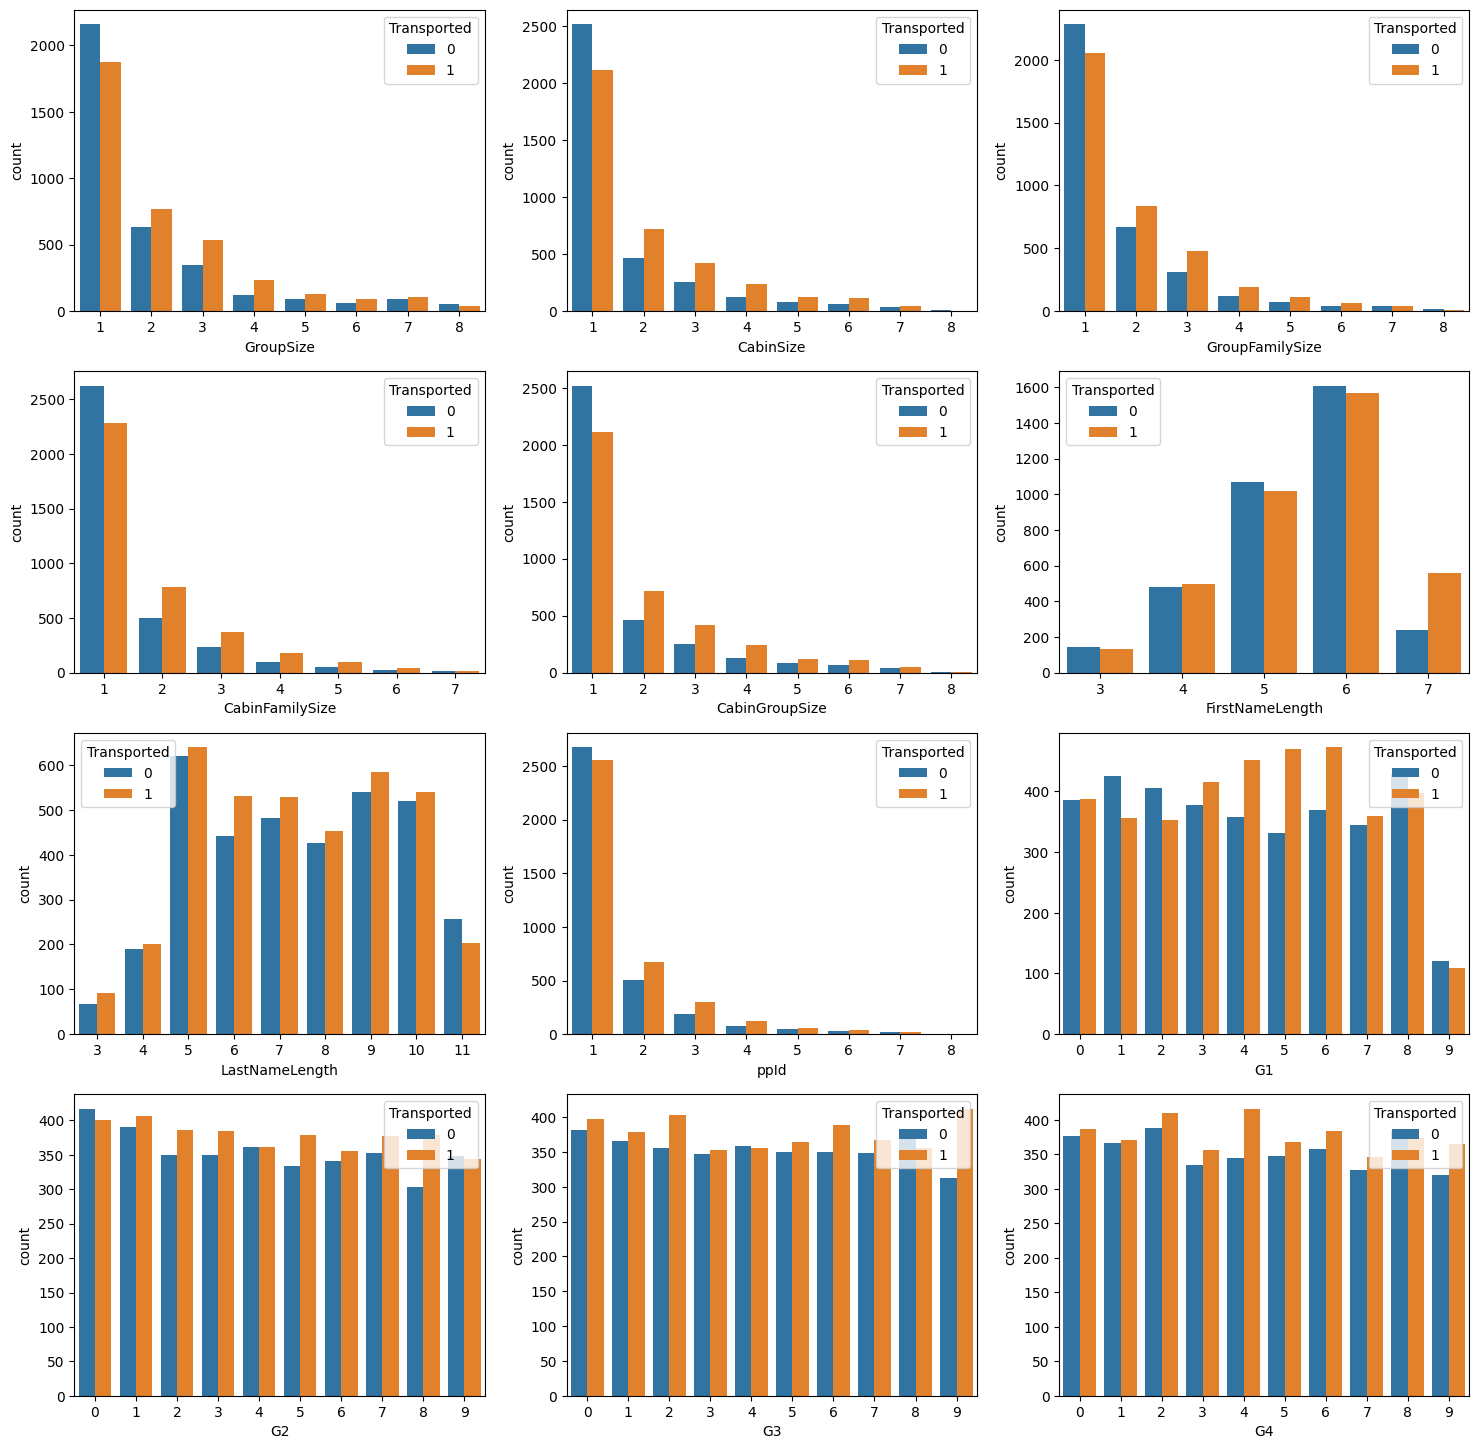

In [81]:
my_list = ['GroupSize', 'CabinSize', 'GroupFamilySize', 'CabinFamilySize', 'CabinGroupSize', 
           'FirstNameLength', 'LastNameLength', 'ppId', 'G1', 'G2', 'G3', 'G4']
plt.figure(figsize = (18, 18))
x = 1
for k in range(12):
    plt.subplot(4, 3, x)        
    sns.countplot(x = my_list[k], hue = 'Transported', data = df0)
    x += 1

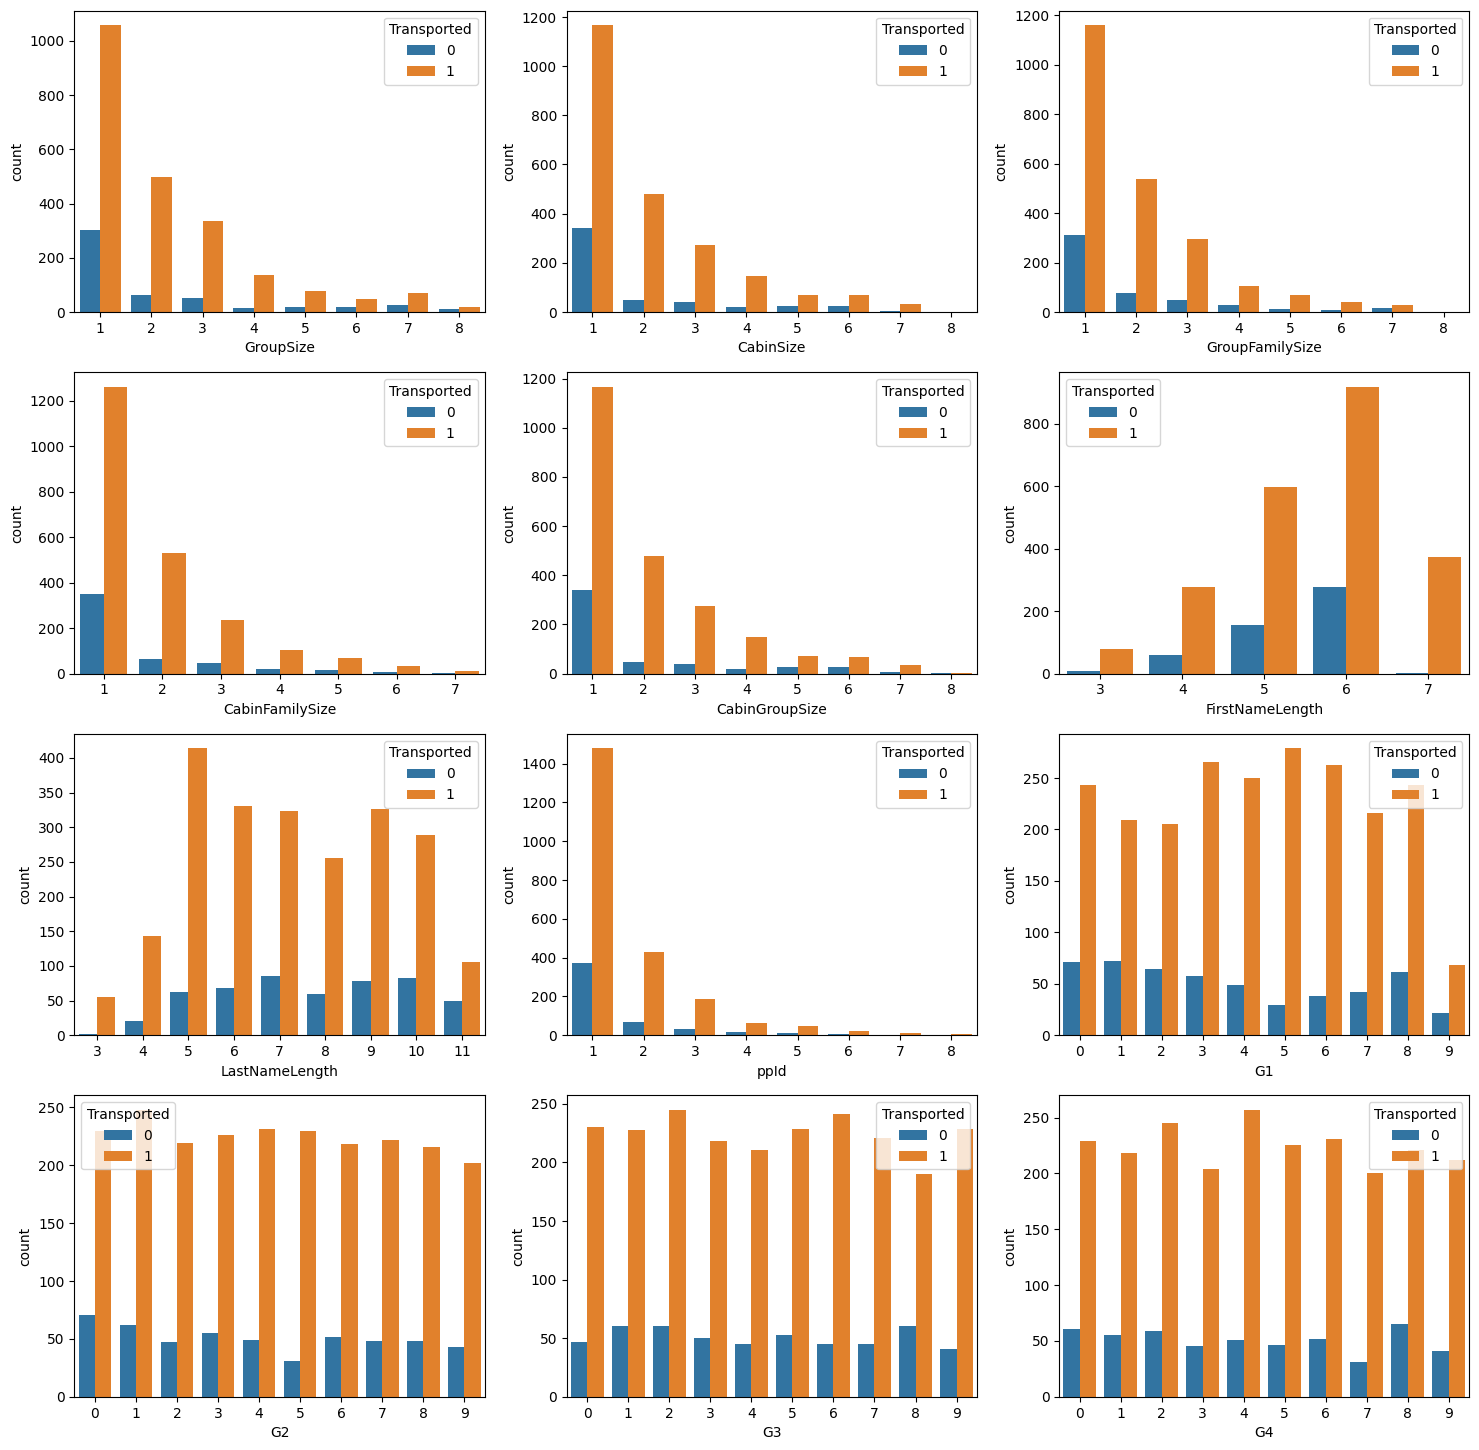

In [82]:
plt.figure(figsize = (18, 18))
x = 1
for k in range(12):
    plt.subplot(4, 3, x)        
    sns.countplot(x = my_list[k], hue = 'Transported', data = df0[df0.CryoSleep == 1])
    x += 1

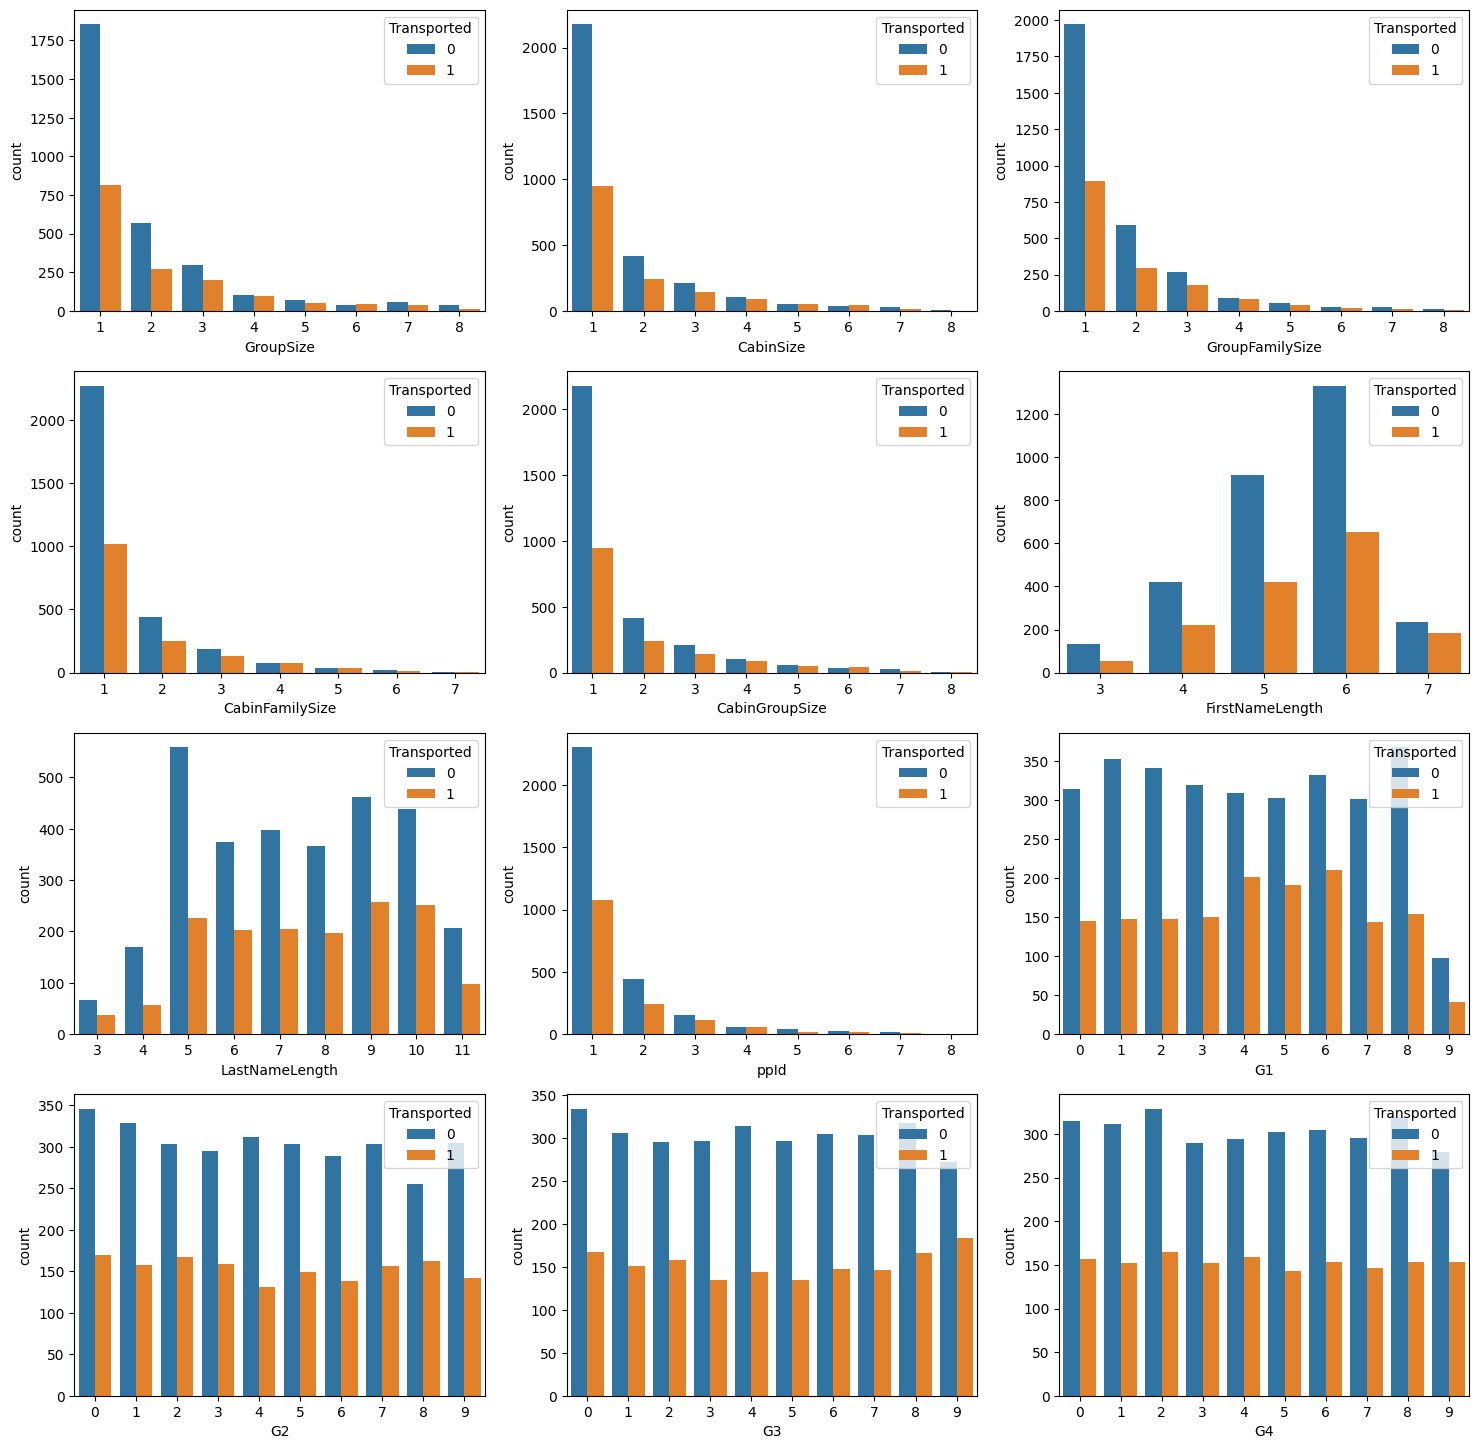

In [83]:
plt.figure(figsize = (18, 18))
x = 1
for k in range(12):
    plt.subplot(4, 3, x)        
    sns.countplot(x = my_list[k], hue = 'Transported', data = df0[df0.CryoSleep == 0])
    x += 1

#### FamilySize

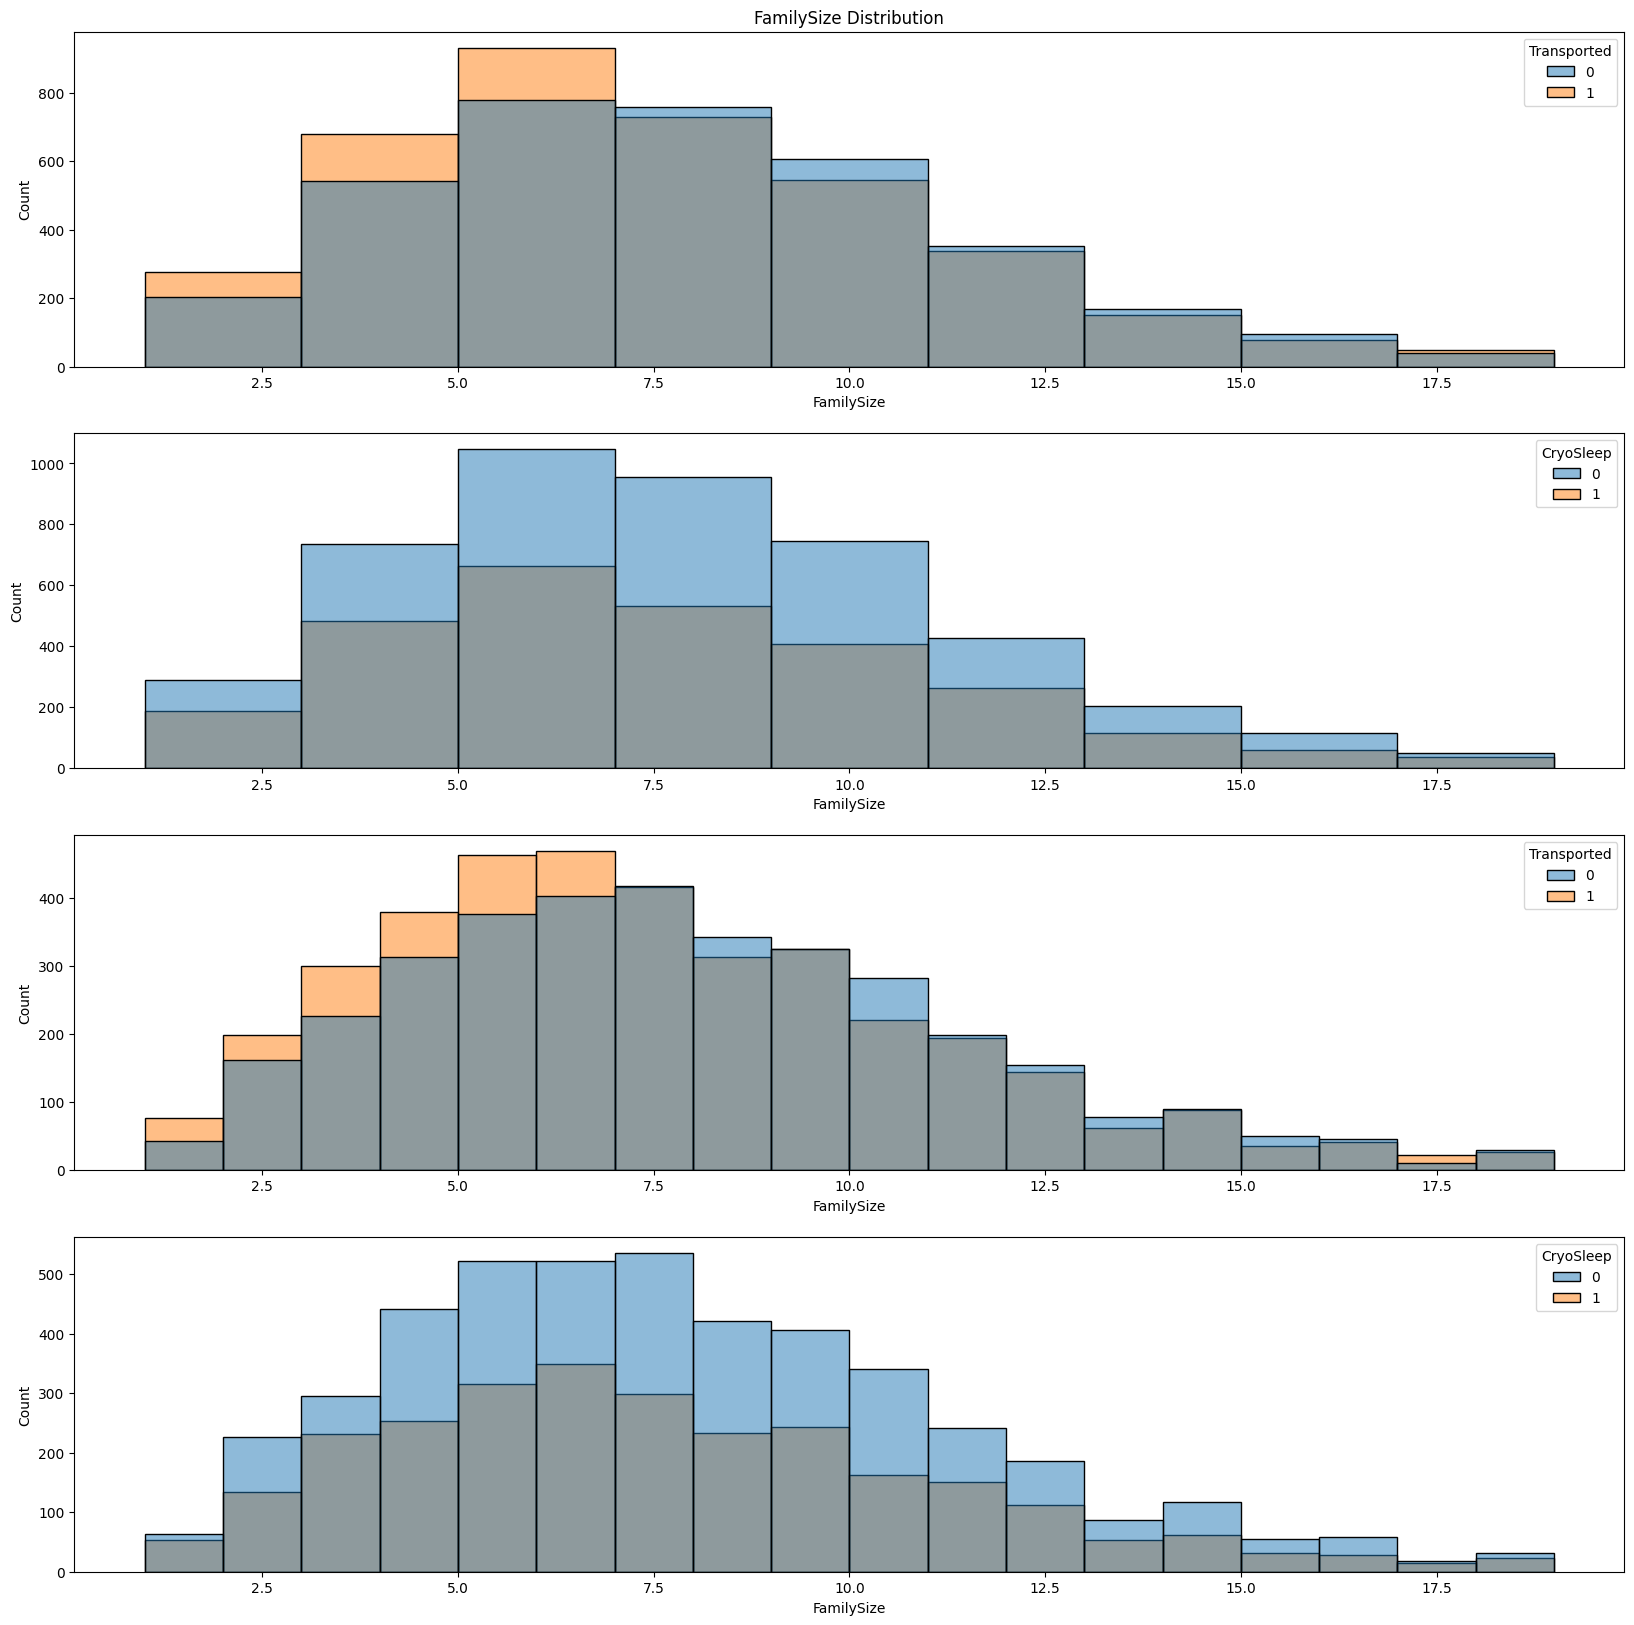

In [84]:
plot_hists_by_Cryo_and_Transported(df0, 'FamilySize', bins = 9)

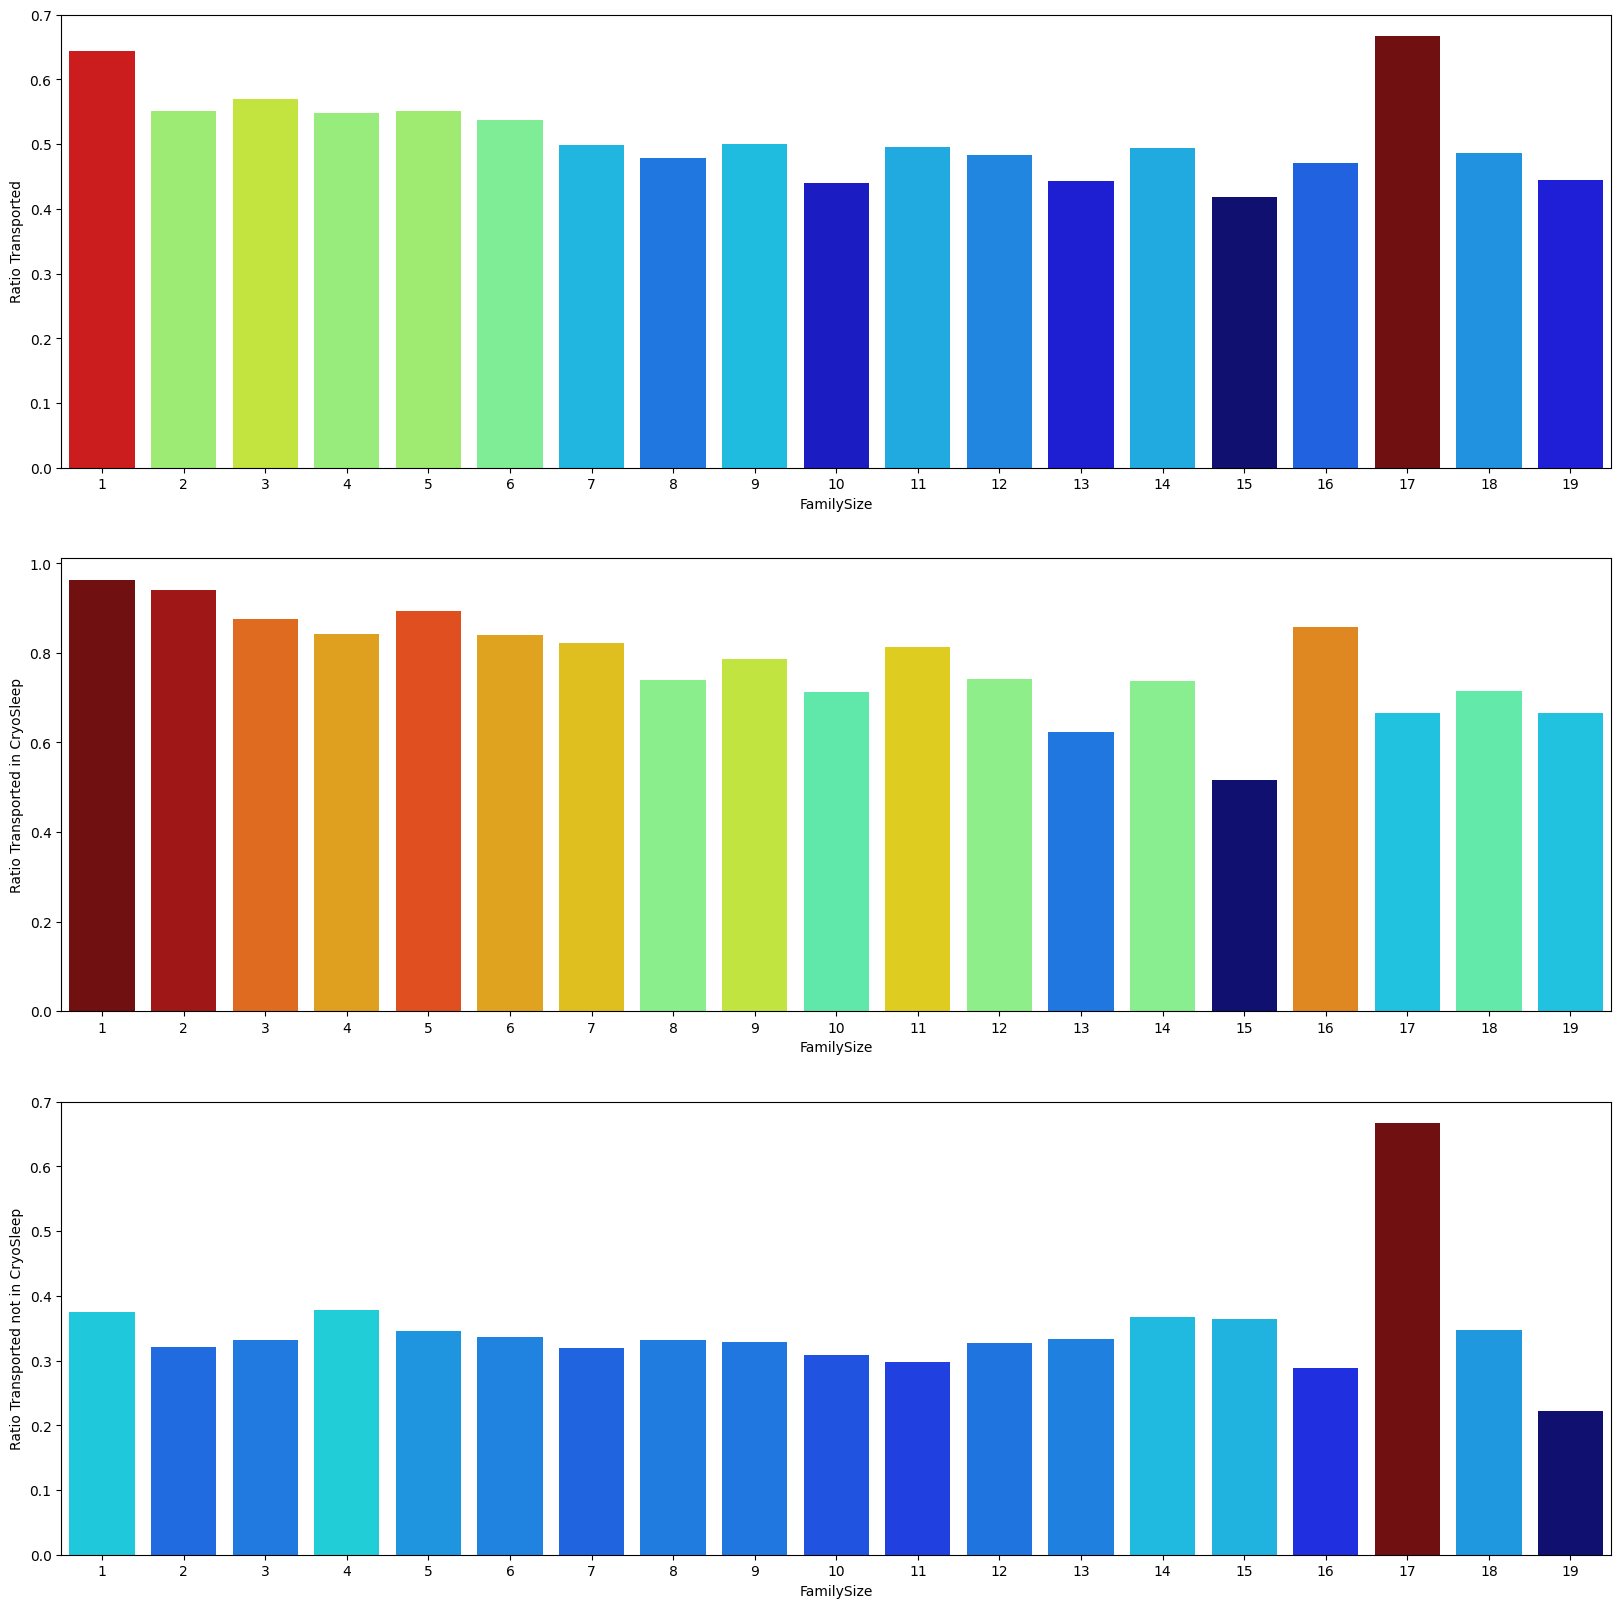

In [85]:
_, _ = plot_ratios_by_Cryo_and_Transported(df0, 'FamilySize', cat = True)

<Axes: xlabel='FamilySize', ylabel='count'>

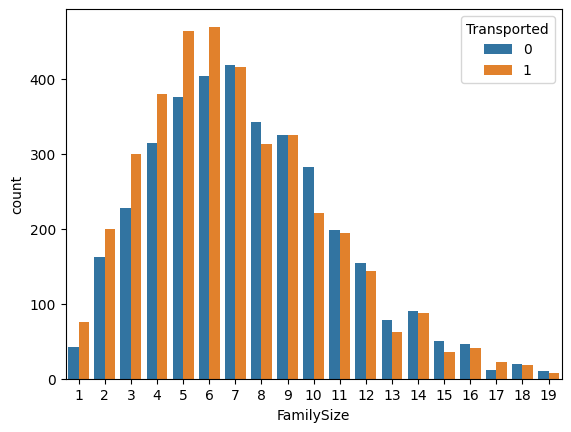

In [86]:
sns.countplot(x = 'FamilySize', hue = 'Transported', data = df0)

<Axes: xlabel='FamilySize', ylabel='count'>

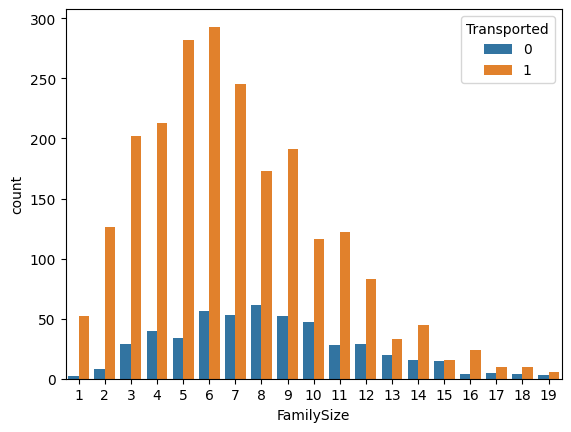

In [87]:
sns.countplot(x = 'FamilySize', hue = 'Transported', data = df0[df0.CryoSleep == 1])

<Axes: xlabel='FamilySize', ylabel='count'>

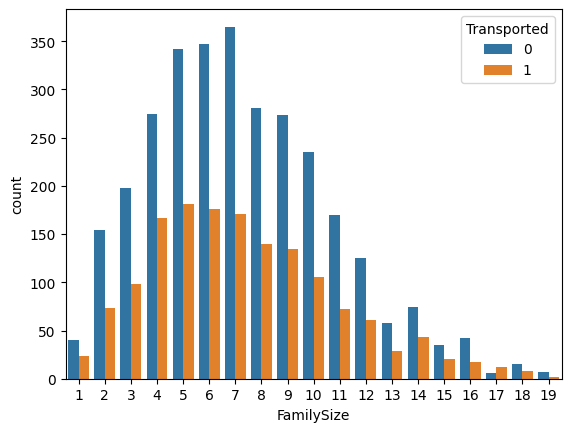

In [88]:
sns.countplot(x = 'FamilySize', hue = 'Transported', data = df0[df0.CryoSleep == 0])

#### Cabin Number & GroupId

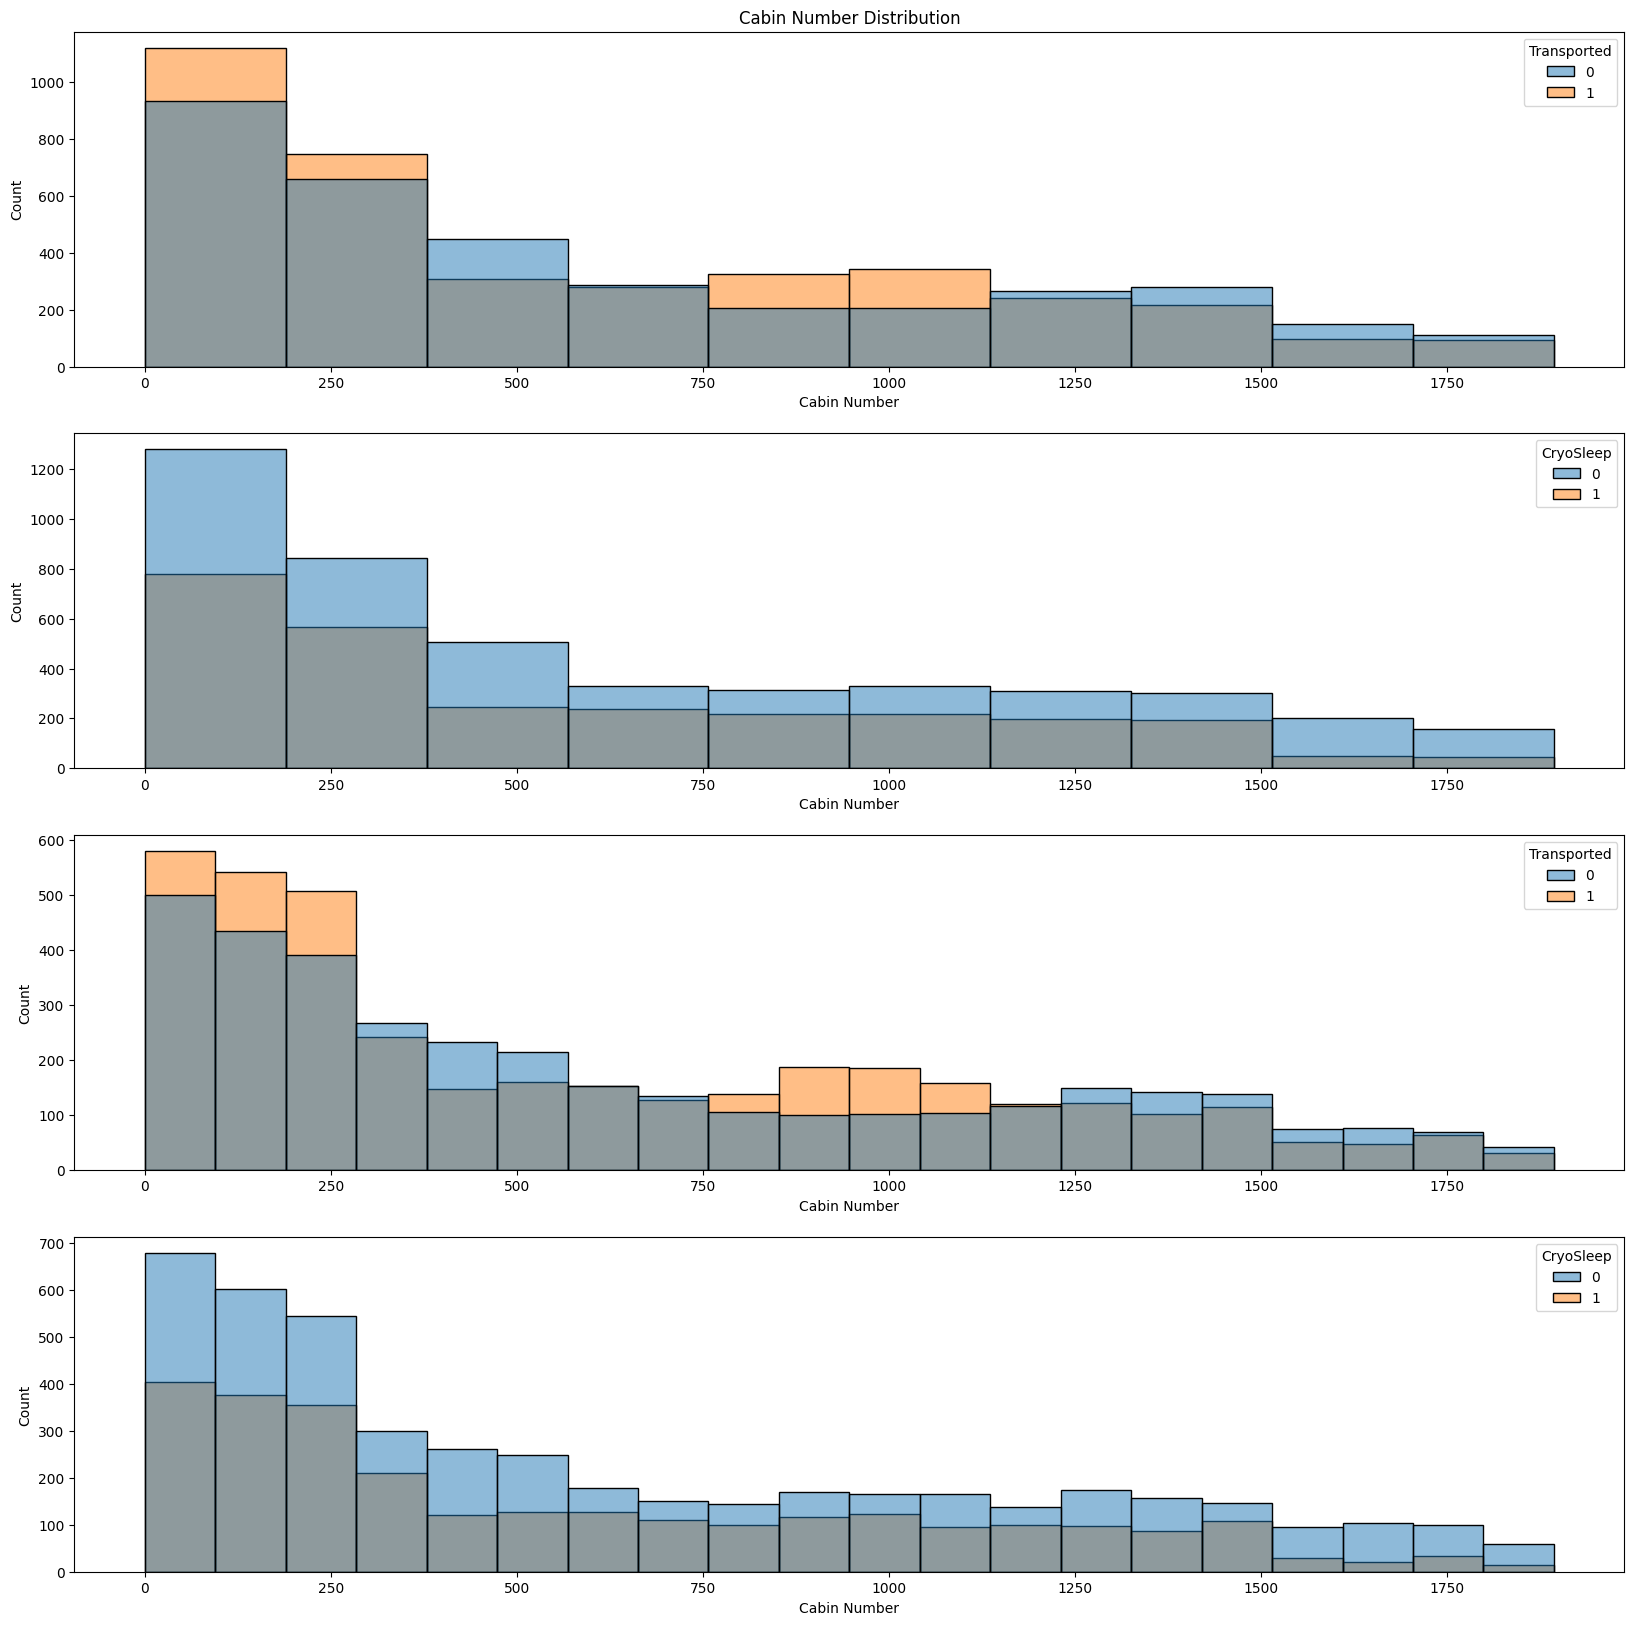

In [89]:
plot_hists_by_Cryo_and_Transported(df0, 'Cabin Number')

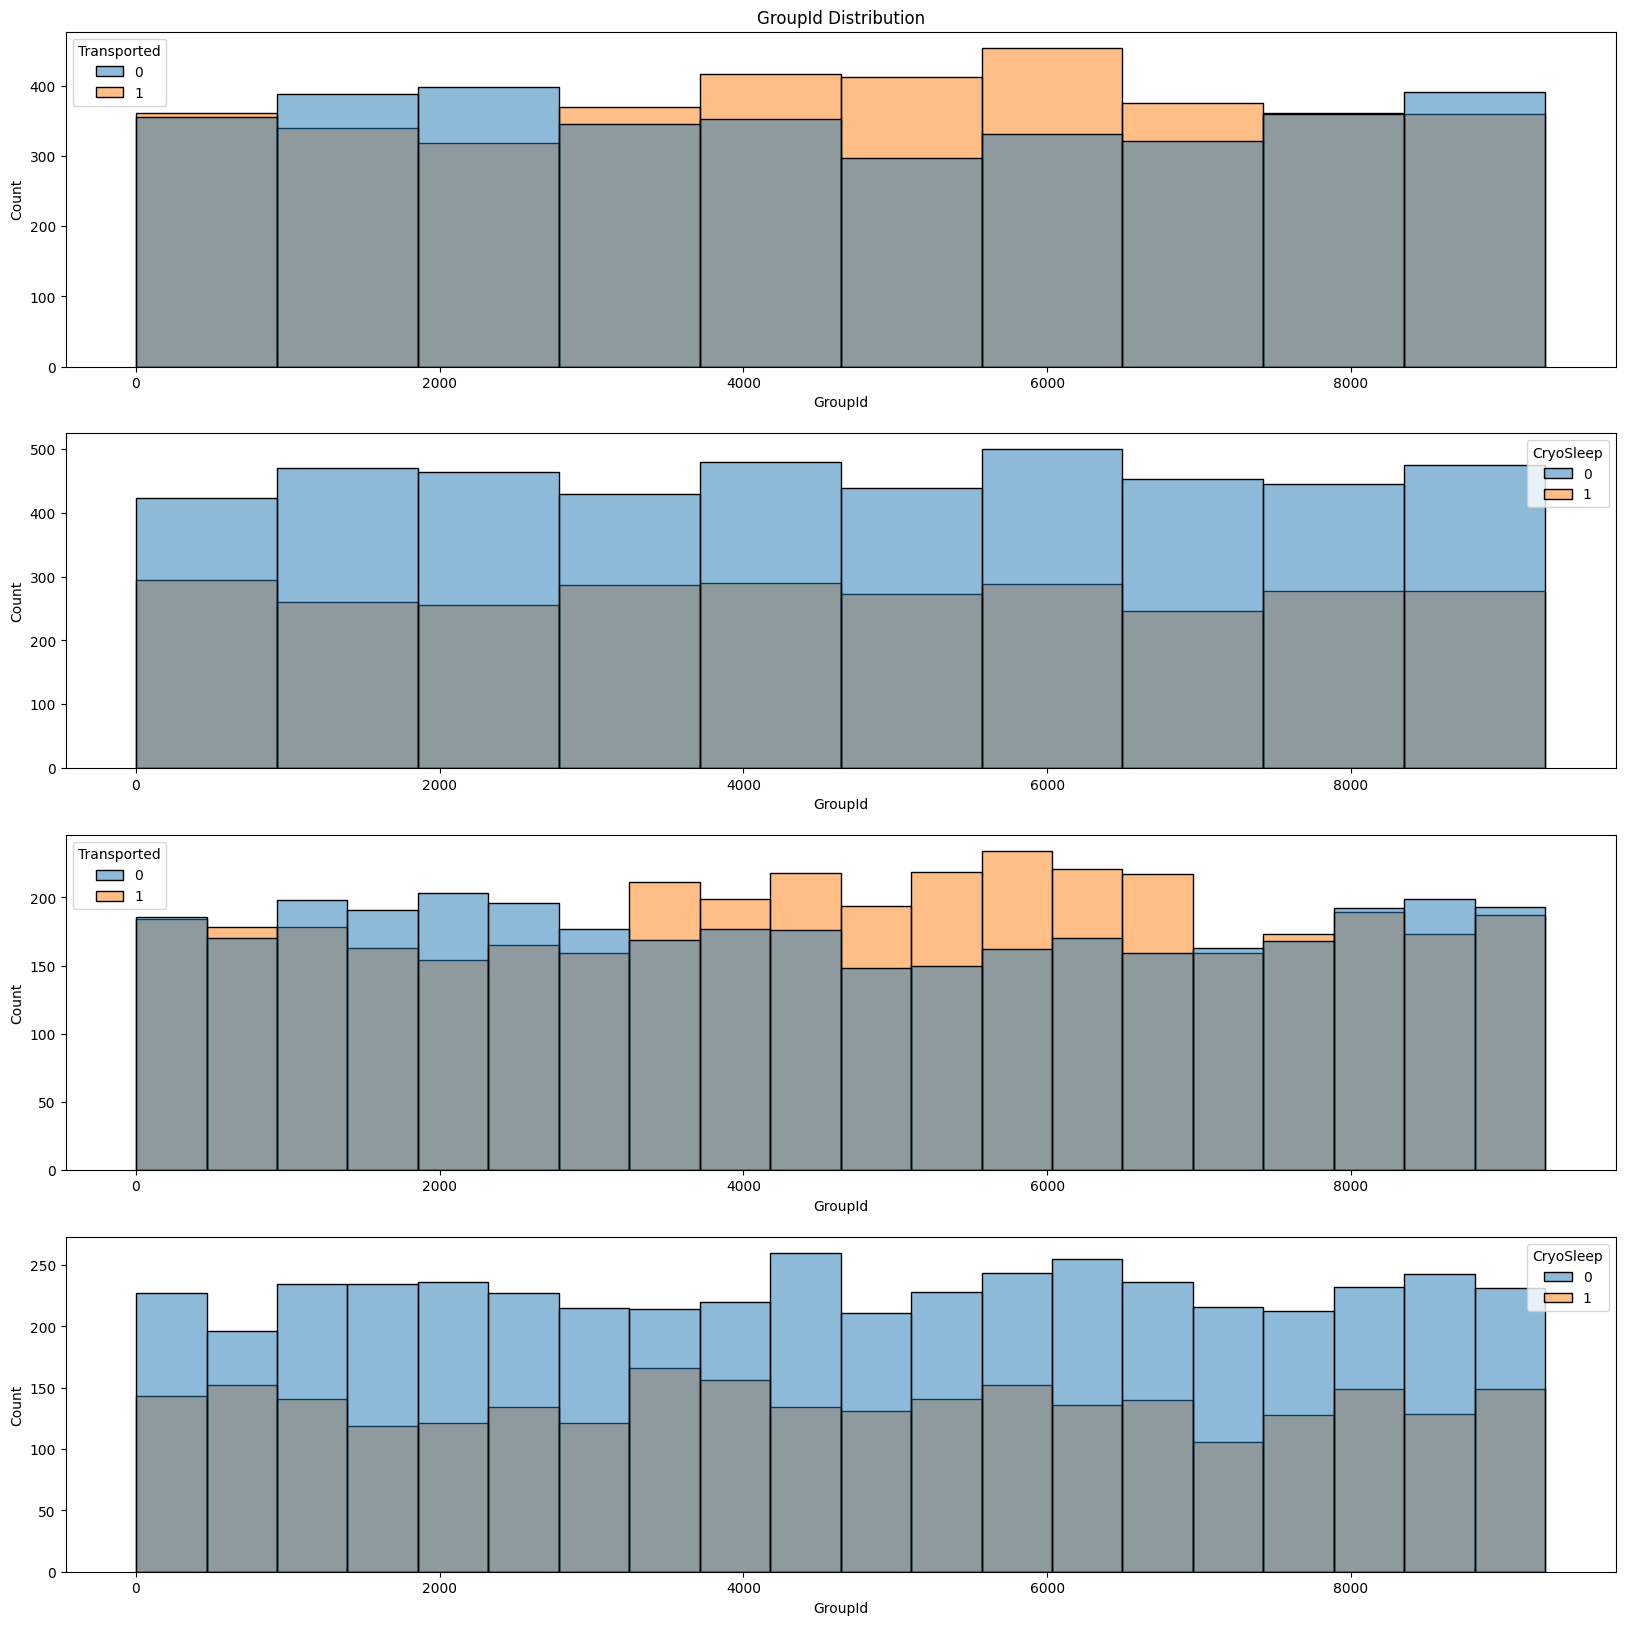

In [90]:
plot_hists_by_Cryo_and_Transported(df0, 'GroupId')

#### Looking at the histograms above we can see that for cabin numbers there are 4 main predictive regions while for GroupId we have 3 main predictive regions. Let's look even closer to see if these are simply explained by a difference in ratio of passengers in cryosleep vs not cryosleep since we know that the former are a lot more likely to be transported than the latter.

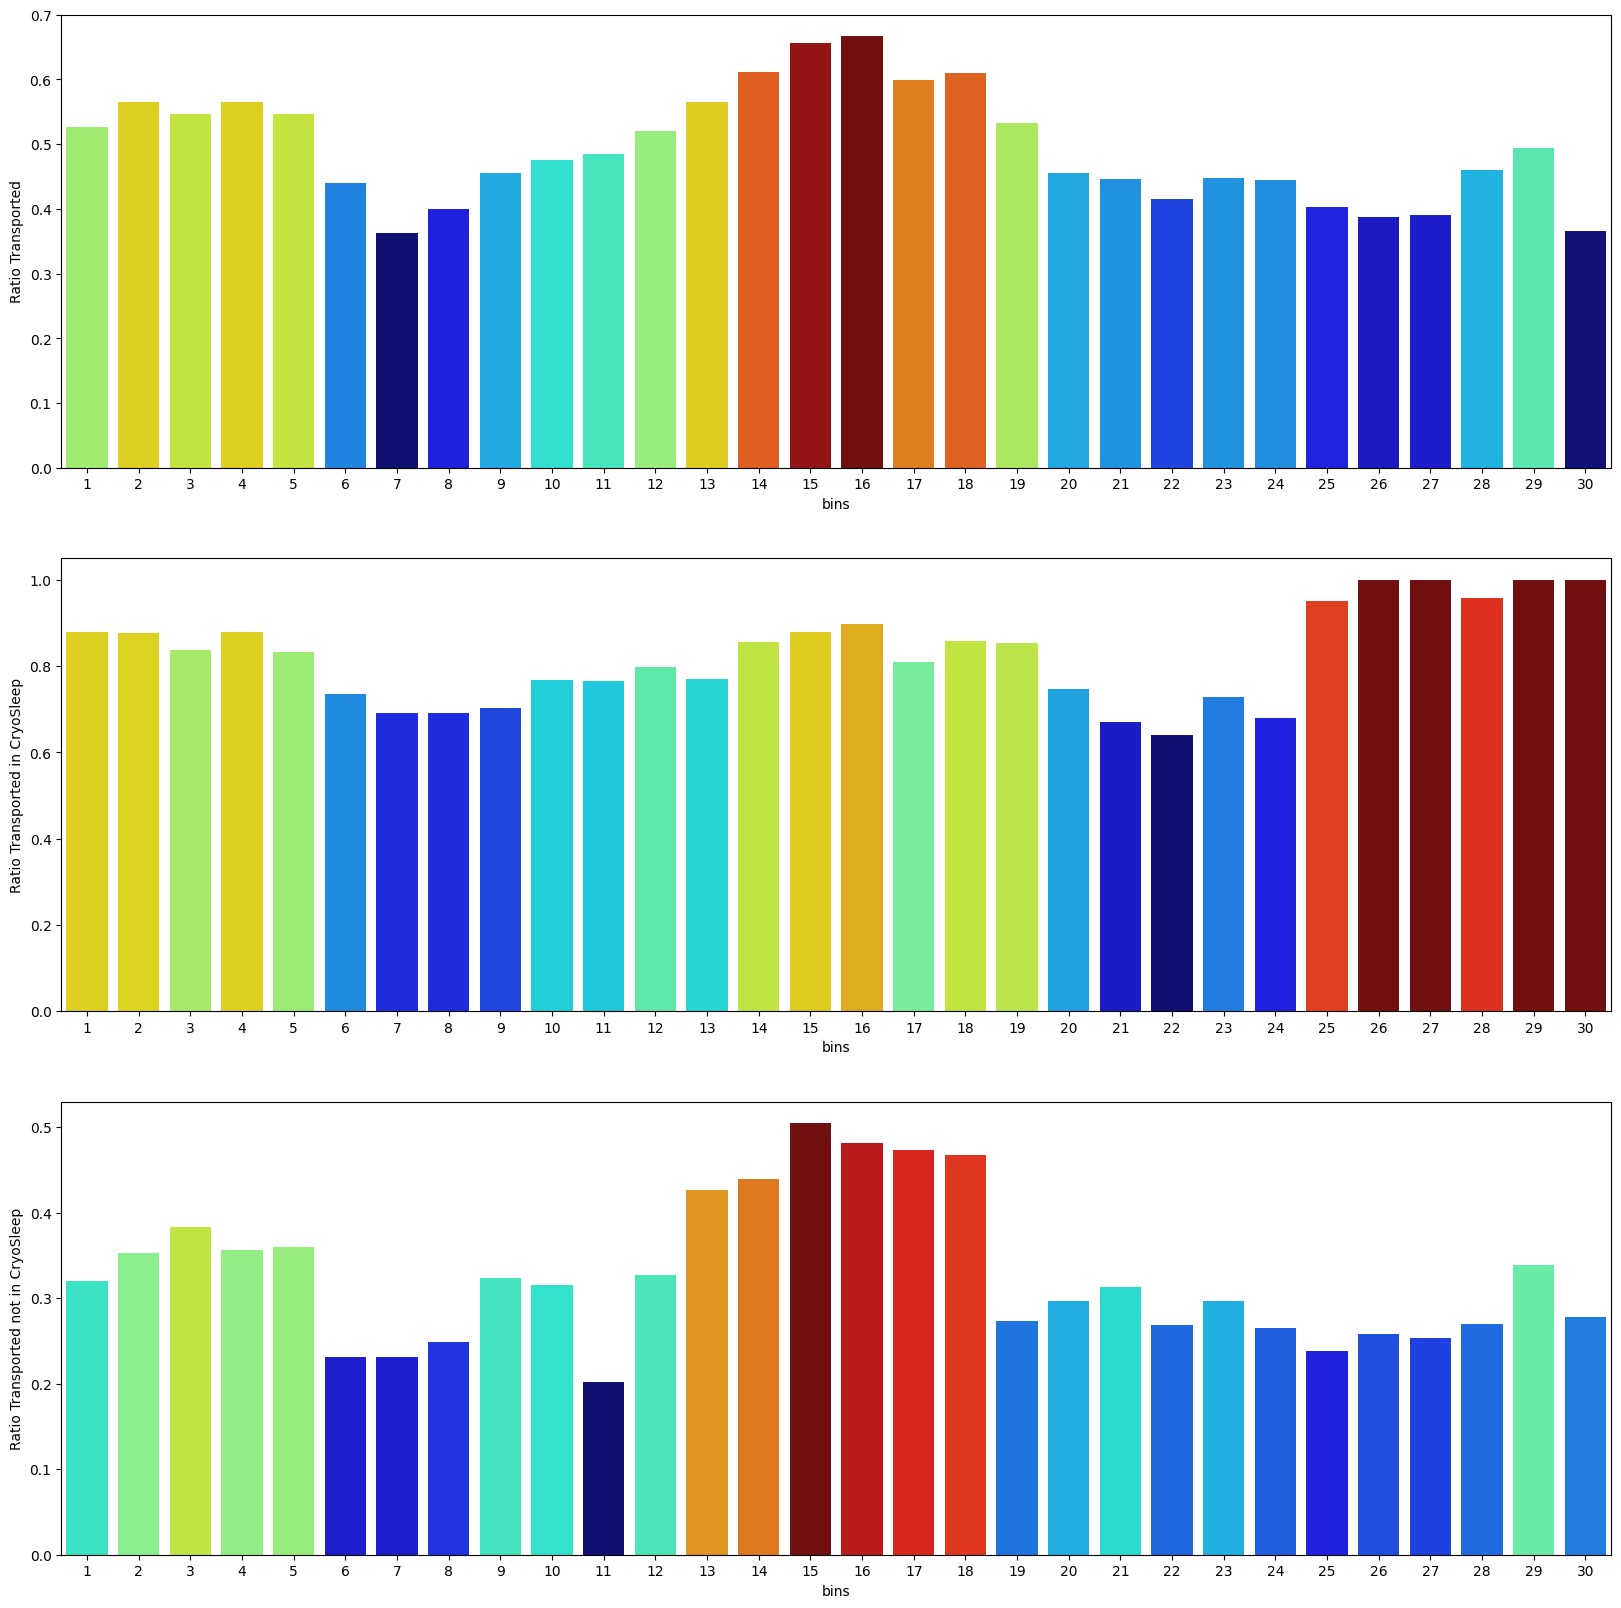

In [91]:
CaBin_ranges, df_num_groups = plot_ratios_by_Cryo_and_Transported(df0, 'Cabin Number', nbins = 30)

In [92]:
CaBin_ranges

[(0.0, 63.1),
 (63.1, 126.3),
 (126.3, 189.4),
 (189.4, 252.5),
 (252.5, 315.7),
 (315.7, 378.8),
 (378.8, 441.9),
 (441.9, 505.1),
 (505.1, 568.2),
 (568.2, 631.3),
 (631.3, 694.5),
 (694.5, 757.6),
 (757.6, 820.7),
 (820.7, 883.9),
 (883.9, 947.0),
 (947.0, 1010.1),
 (1010.1, 1073.3),
 (1073.3, 1136.4),
 (1136.4, 1199.5),
 (1199.5, 1262.7),
 (1262.7, 1325.8),
 (1325.8, 1388.9),
 (1388.9, 1452.1),
 (1452.1, 1515.2),
 (1515.2, 1578.3),
 (1578.3, 1641.5),
 (1641.5, 1704.6),
 (1704.6, 1767.7),
 (1767.7, 1830.9),
 (1830.9, 1894.0)]

#### With this more detailed view we can find 5 main cabin regions:
* Region1: bins 1 - 5 ==> range = [0, 316)
* Region2: bins 6 - 12 ==> range = [316, 758)
* Region3: bins 13 - 18 ==> range = [758, 1137)
* Region4: bins 19 - 24 ==> range = [1137, 1516)
* Region5: bins 25 - 30 ==> range = [1516, inf)

In [93]:
bin_edges = [0, 316, 758, 1137, 1516]
df0 = Get_Regions(df0, 'Cabin Number', 'Region', bin_edges)

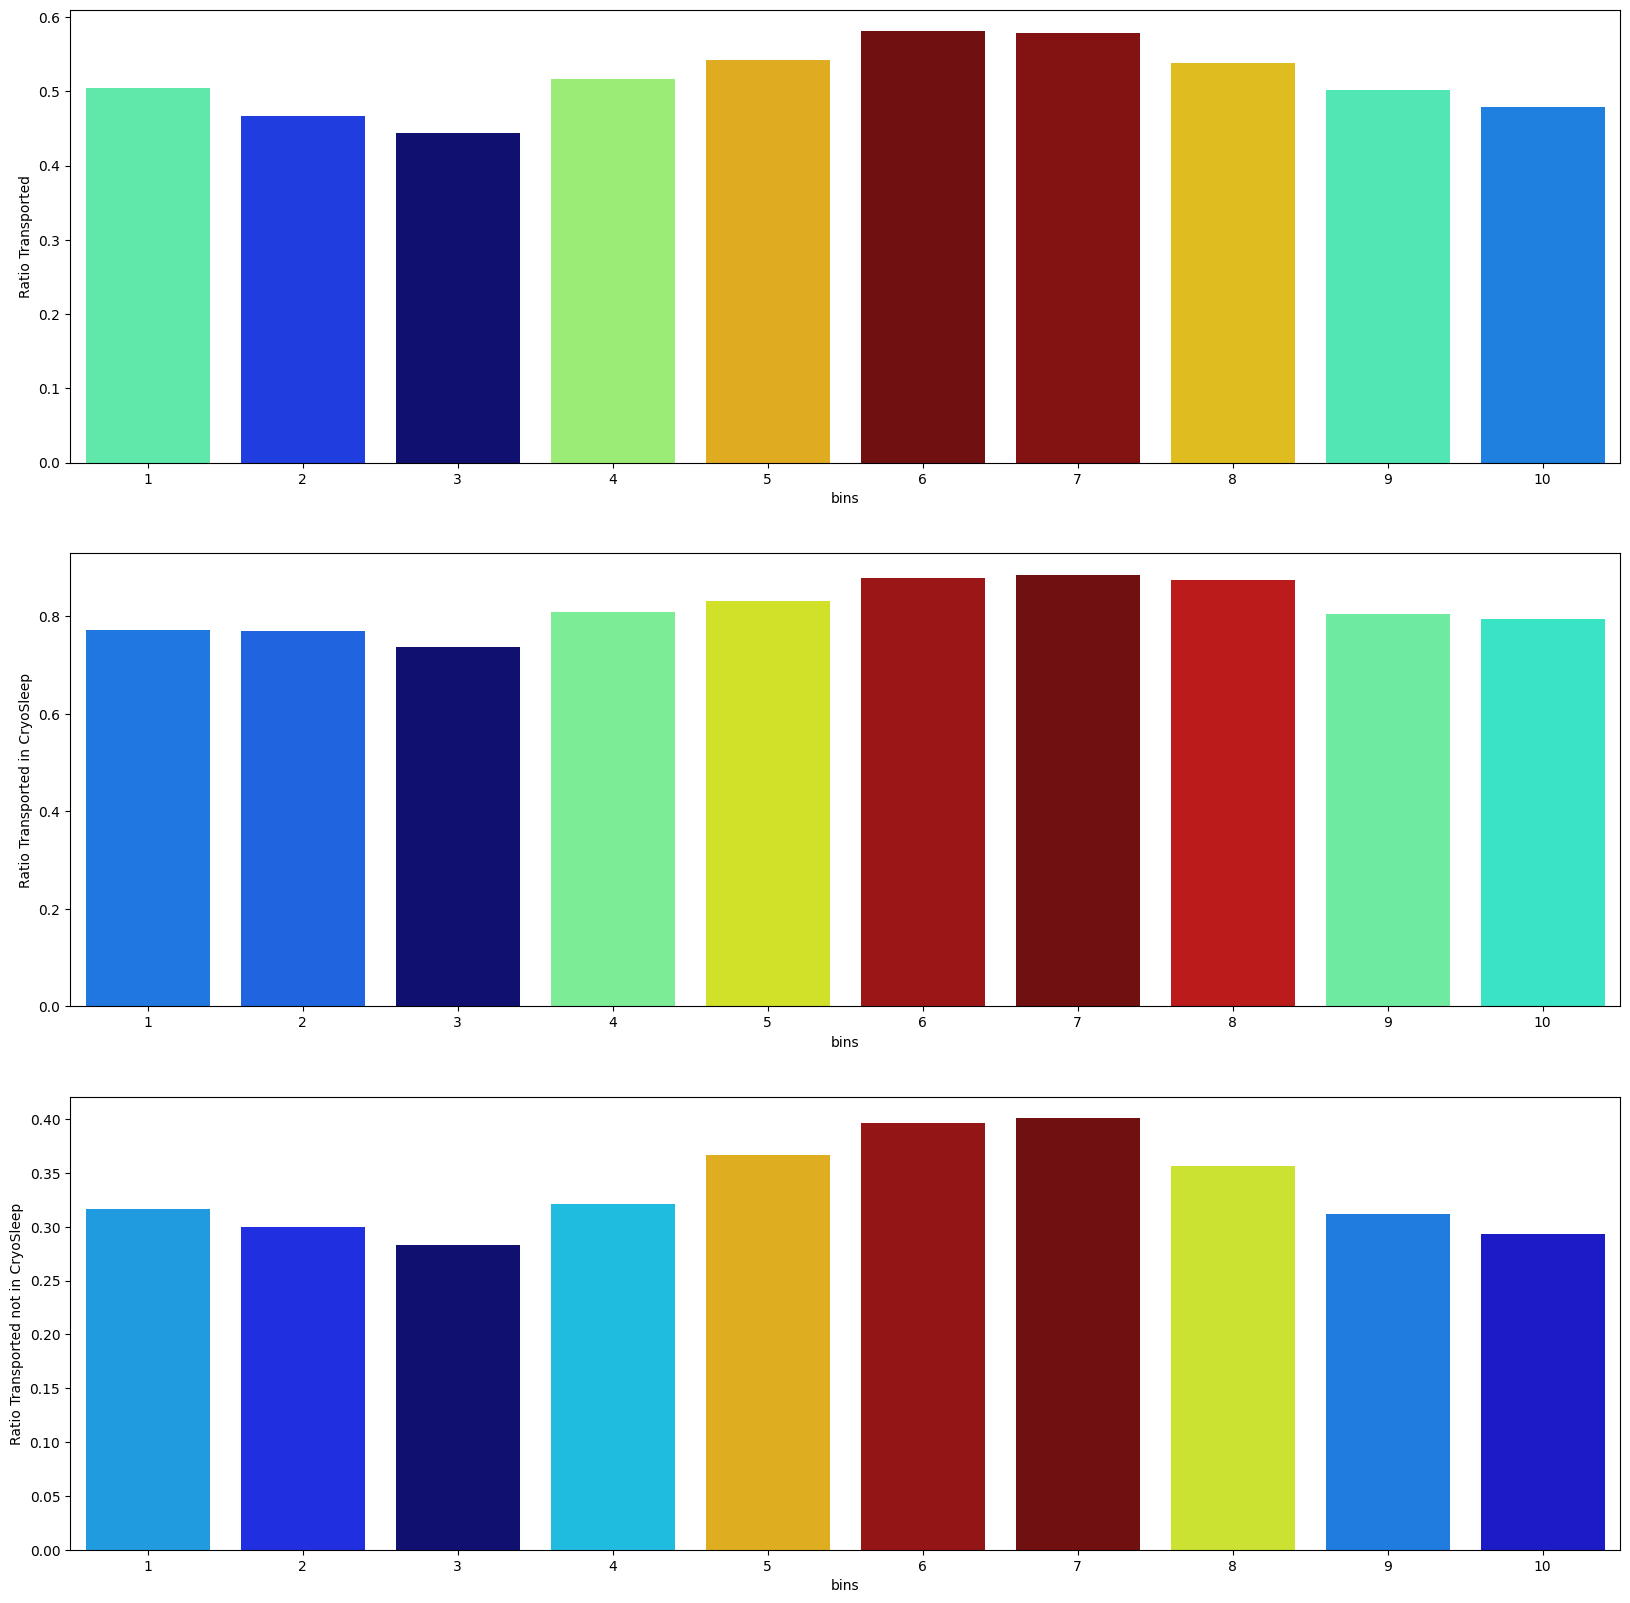

In [94]:
GrBin_ranges, df_num_groups = plot_ratios_by_Cryo_and_Transported(df0, 'GroupId', nbins = 10)

In [95]:
GrBin_ranges

[(1.0, 928.9),
 (928.9, 1856.8),
 (1856.8, 2784.7),
 (2784.7, 3712.6),
 (3712.6, 4640.5),
 (4640.5, 5568.4),
 (5568.4, 6496.3),
 (6496.3, 7424.2),
 (7424.2, 8352.1),
 (8352.1, 9280.0)]

#### Similarly we find 5 main GroupId groups:
* Group1: bins 1 - 4 ==> range = [1, 3713)
* Group2: bins 5 ==> range = [3713, 4641)
* Group3: bins 6 - 7 ==> range = [4641, 6497)
* Group4: bins 8 ==> range = [6497, 7425)
* Group5: bins 9 - 10 ==> range = [7425, inf)
#### It might also be helpful to keep G1. We need to see the effect on prediction

In [96]:
bin_edges = [1, 3713, 4641, 6497, 7425]
df0 = Get_Regions(df0, 'GroupId', 'Batch', bin_edges)

#### CabinSize, GroupSize, & ppId

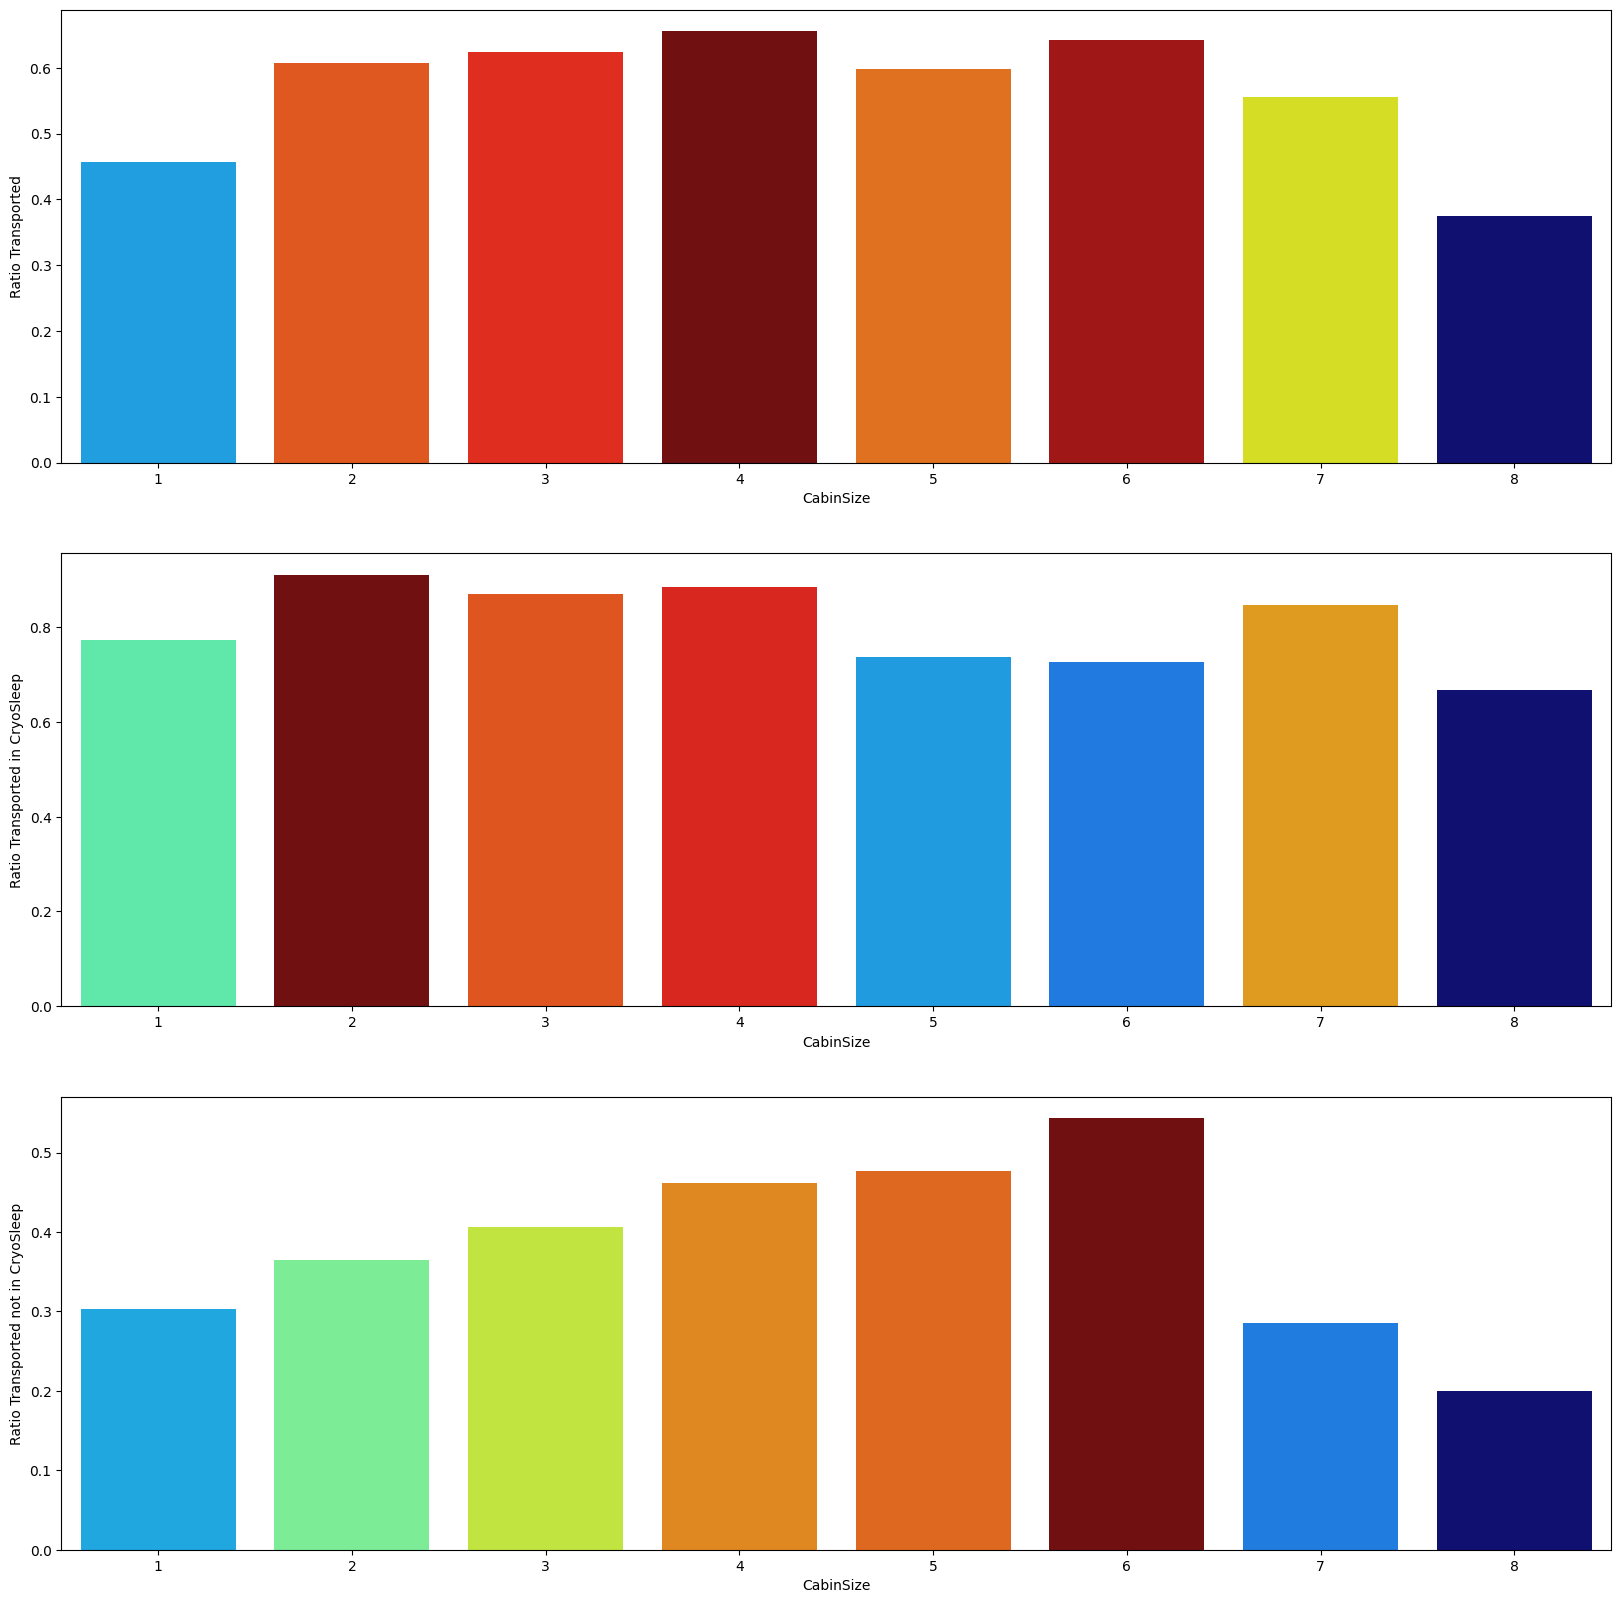

In [97]:
_, _ = plot_ratios_by_Cryo_and_Transported(df0, 'CabinSize', cat = True)

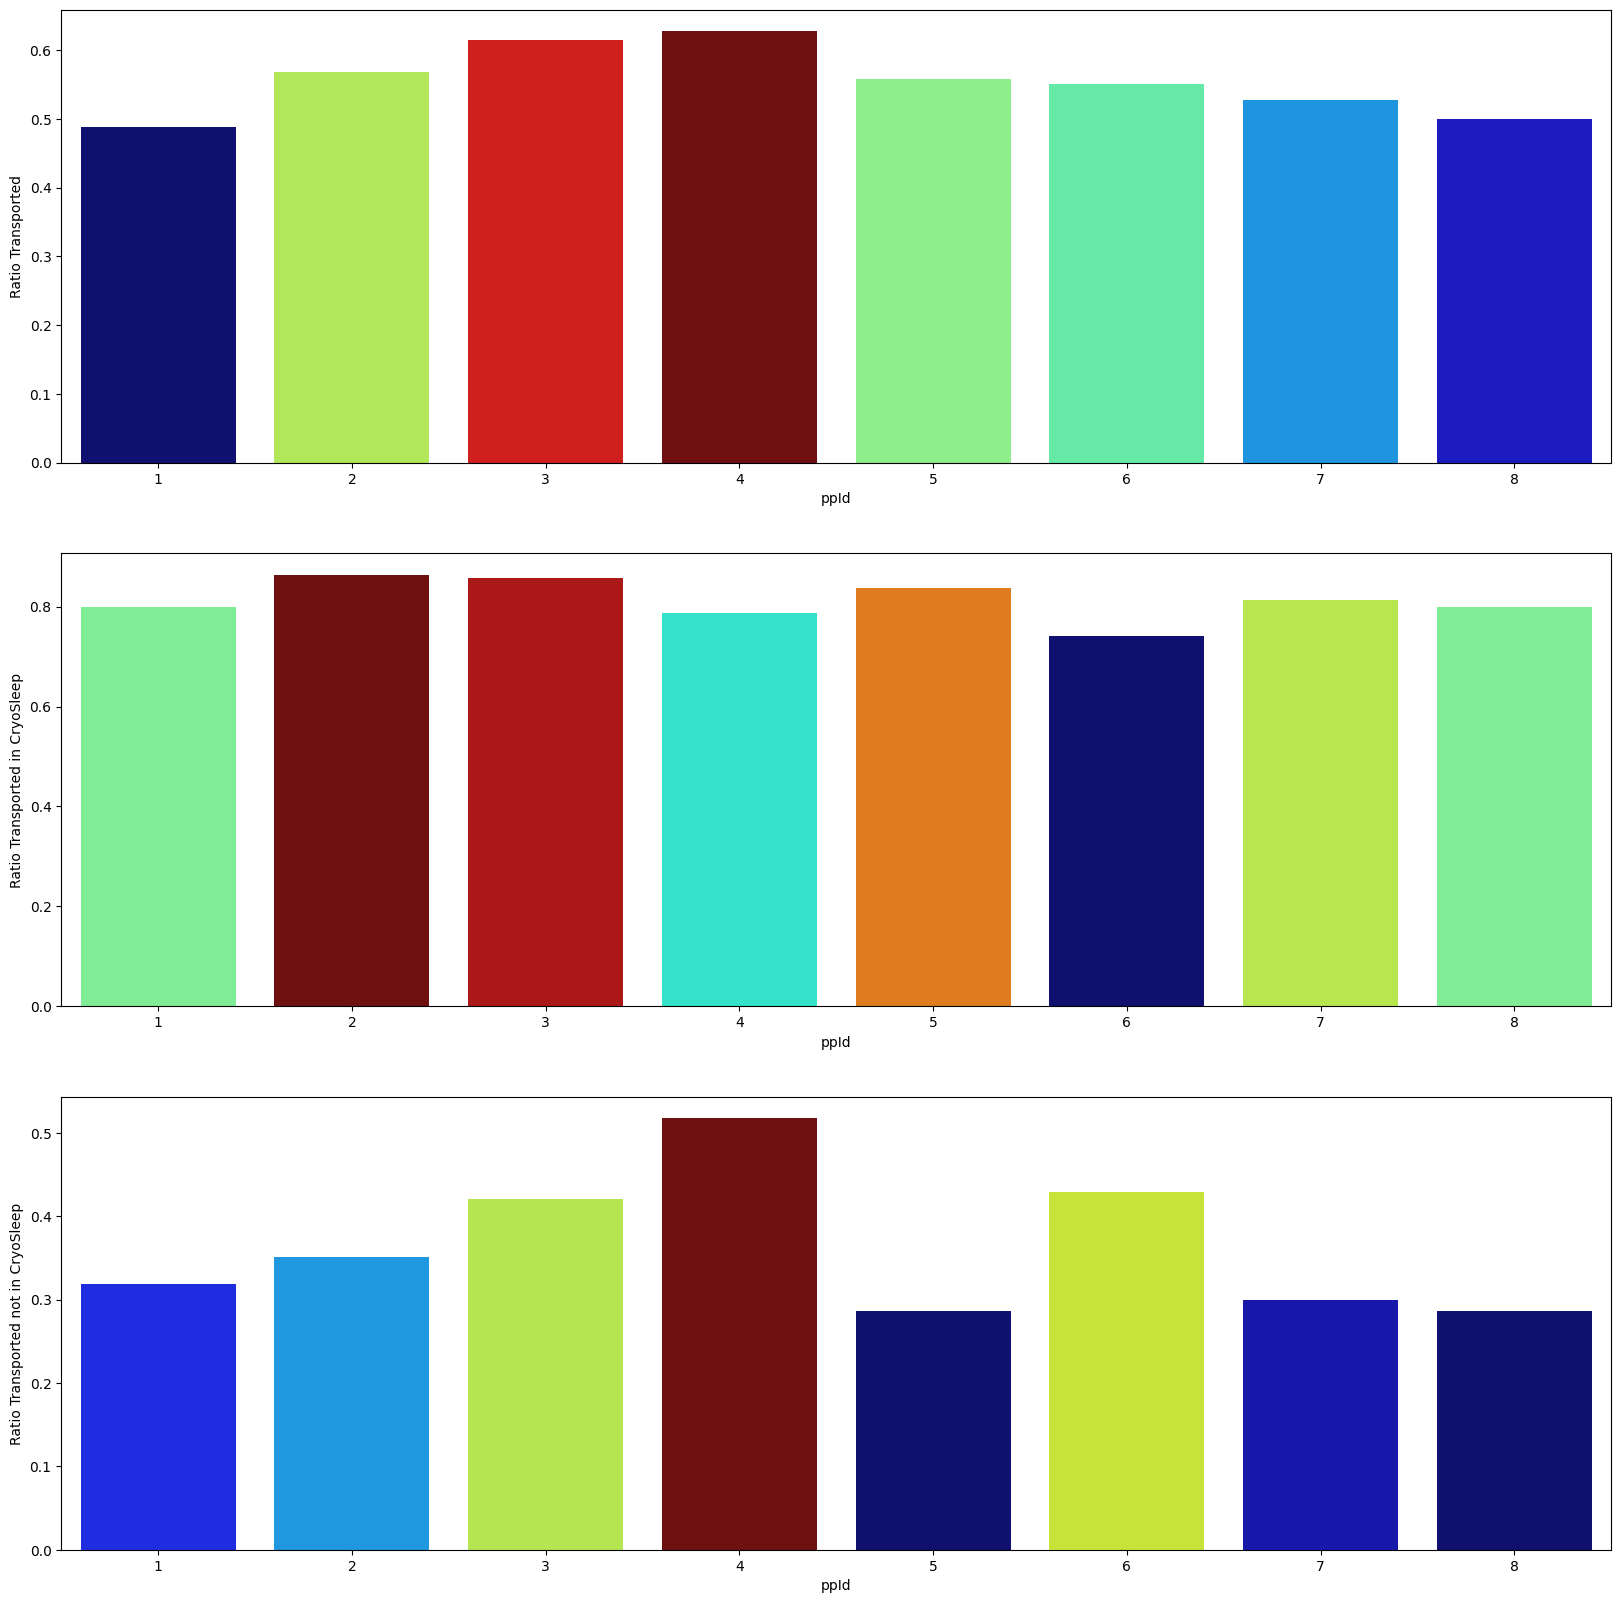

In [98]:
_, _ = plot_ratios_by_Cryo_and_Transported(df0, 'ppId', cat = True)

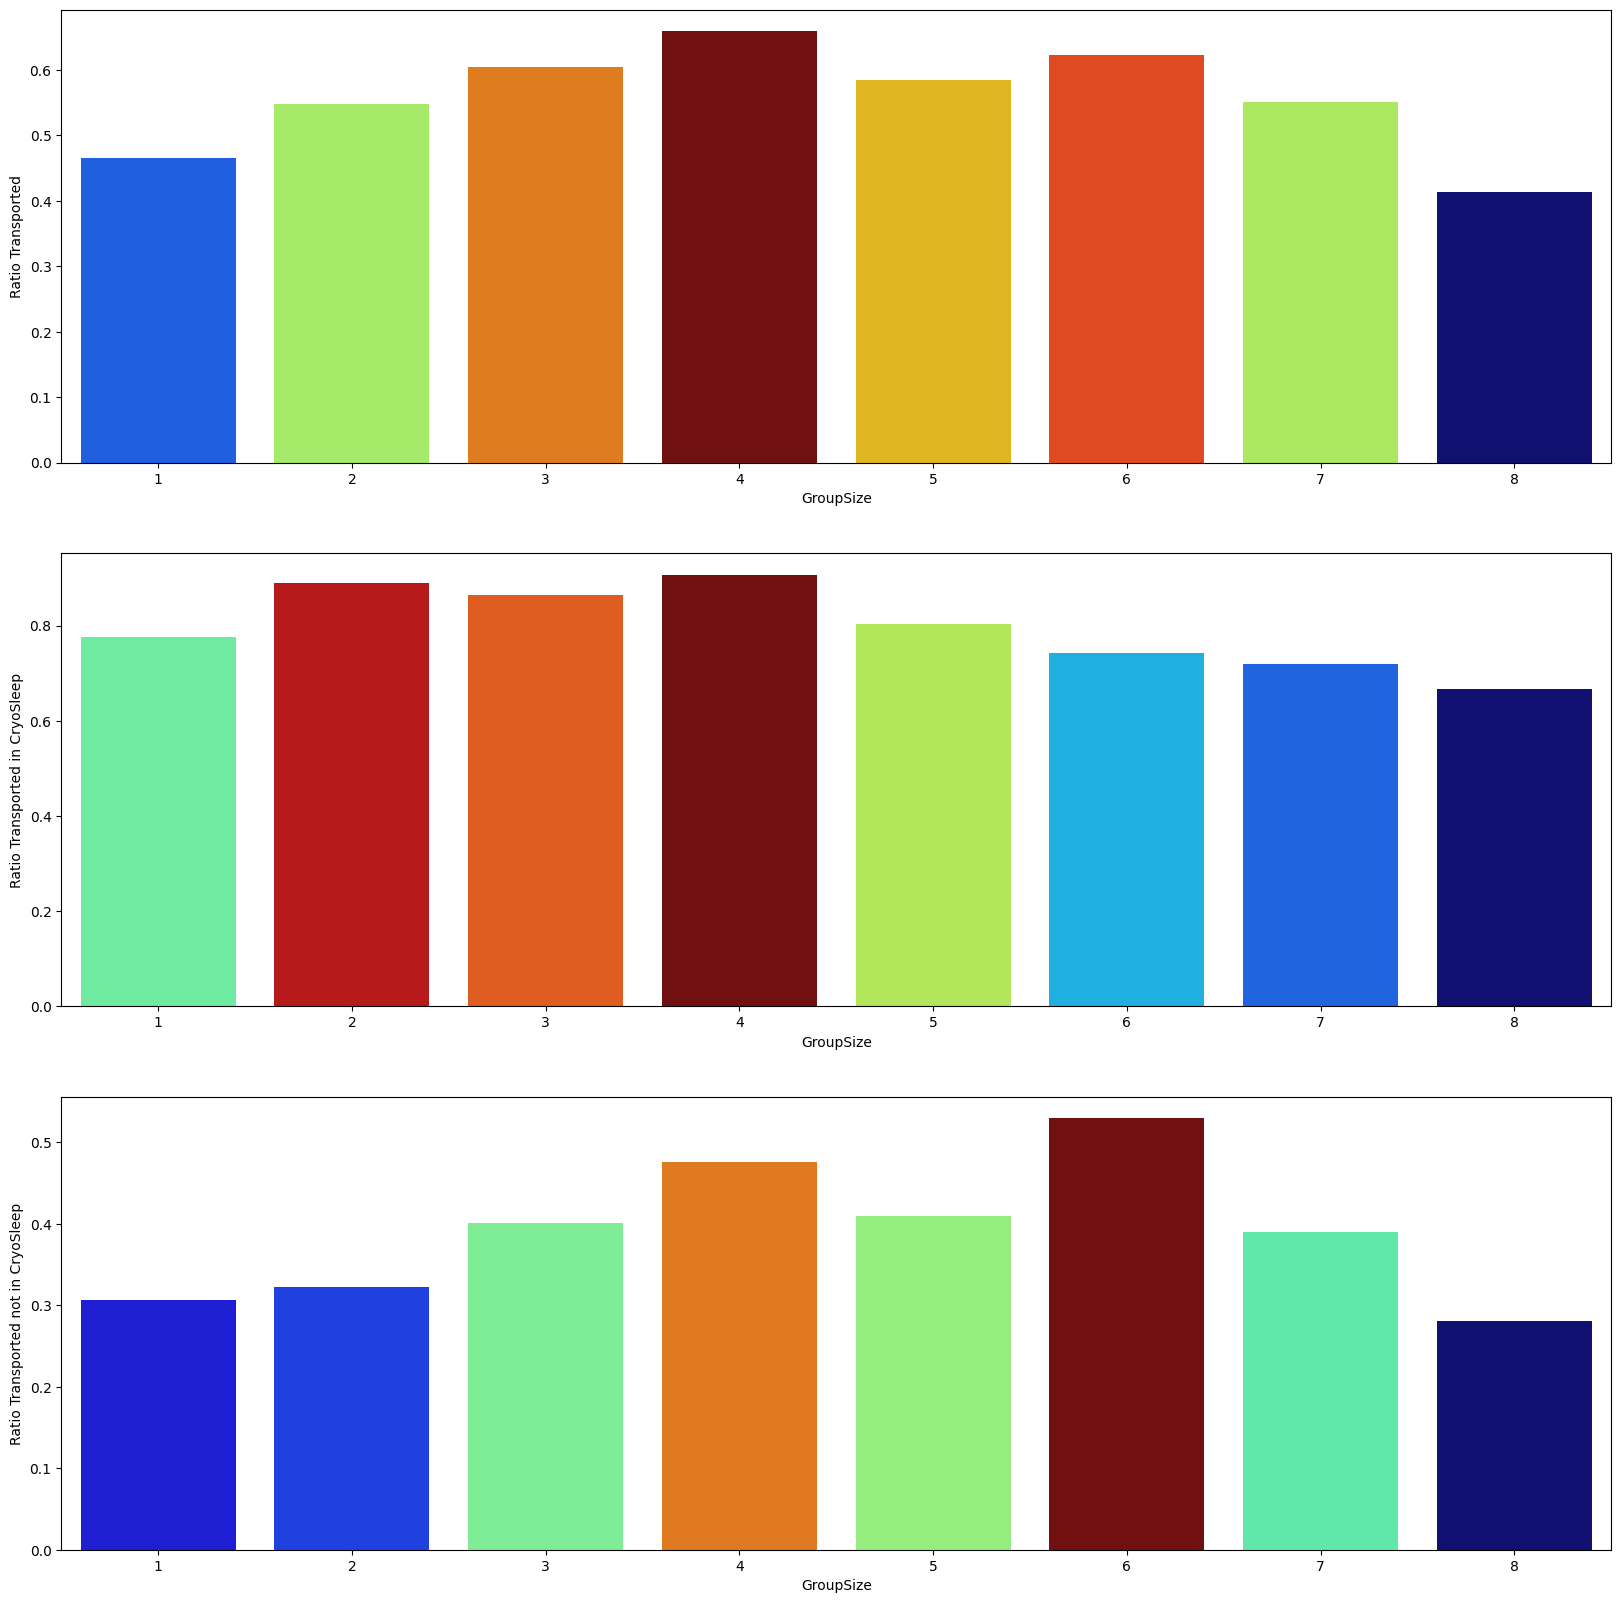

In [99]:
_, _ = plot_ratios_by_Cryo_and_Transported(df0, 'GroupSize', cat = True)

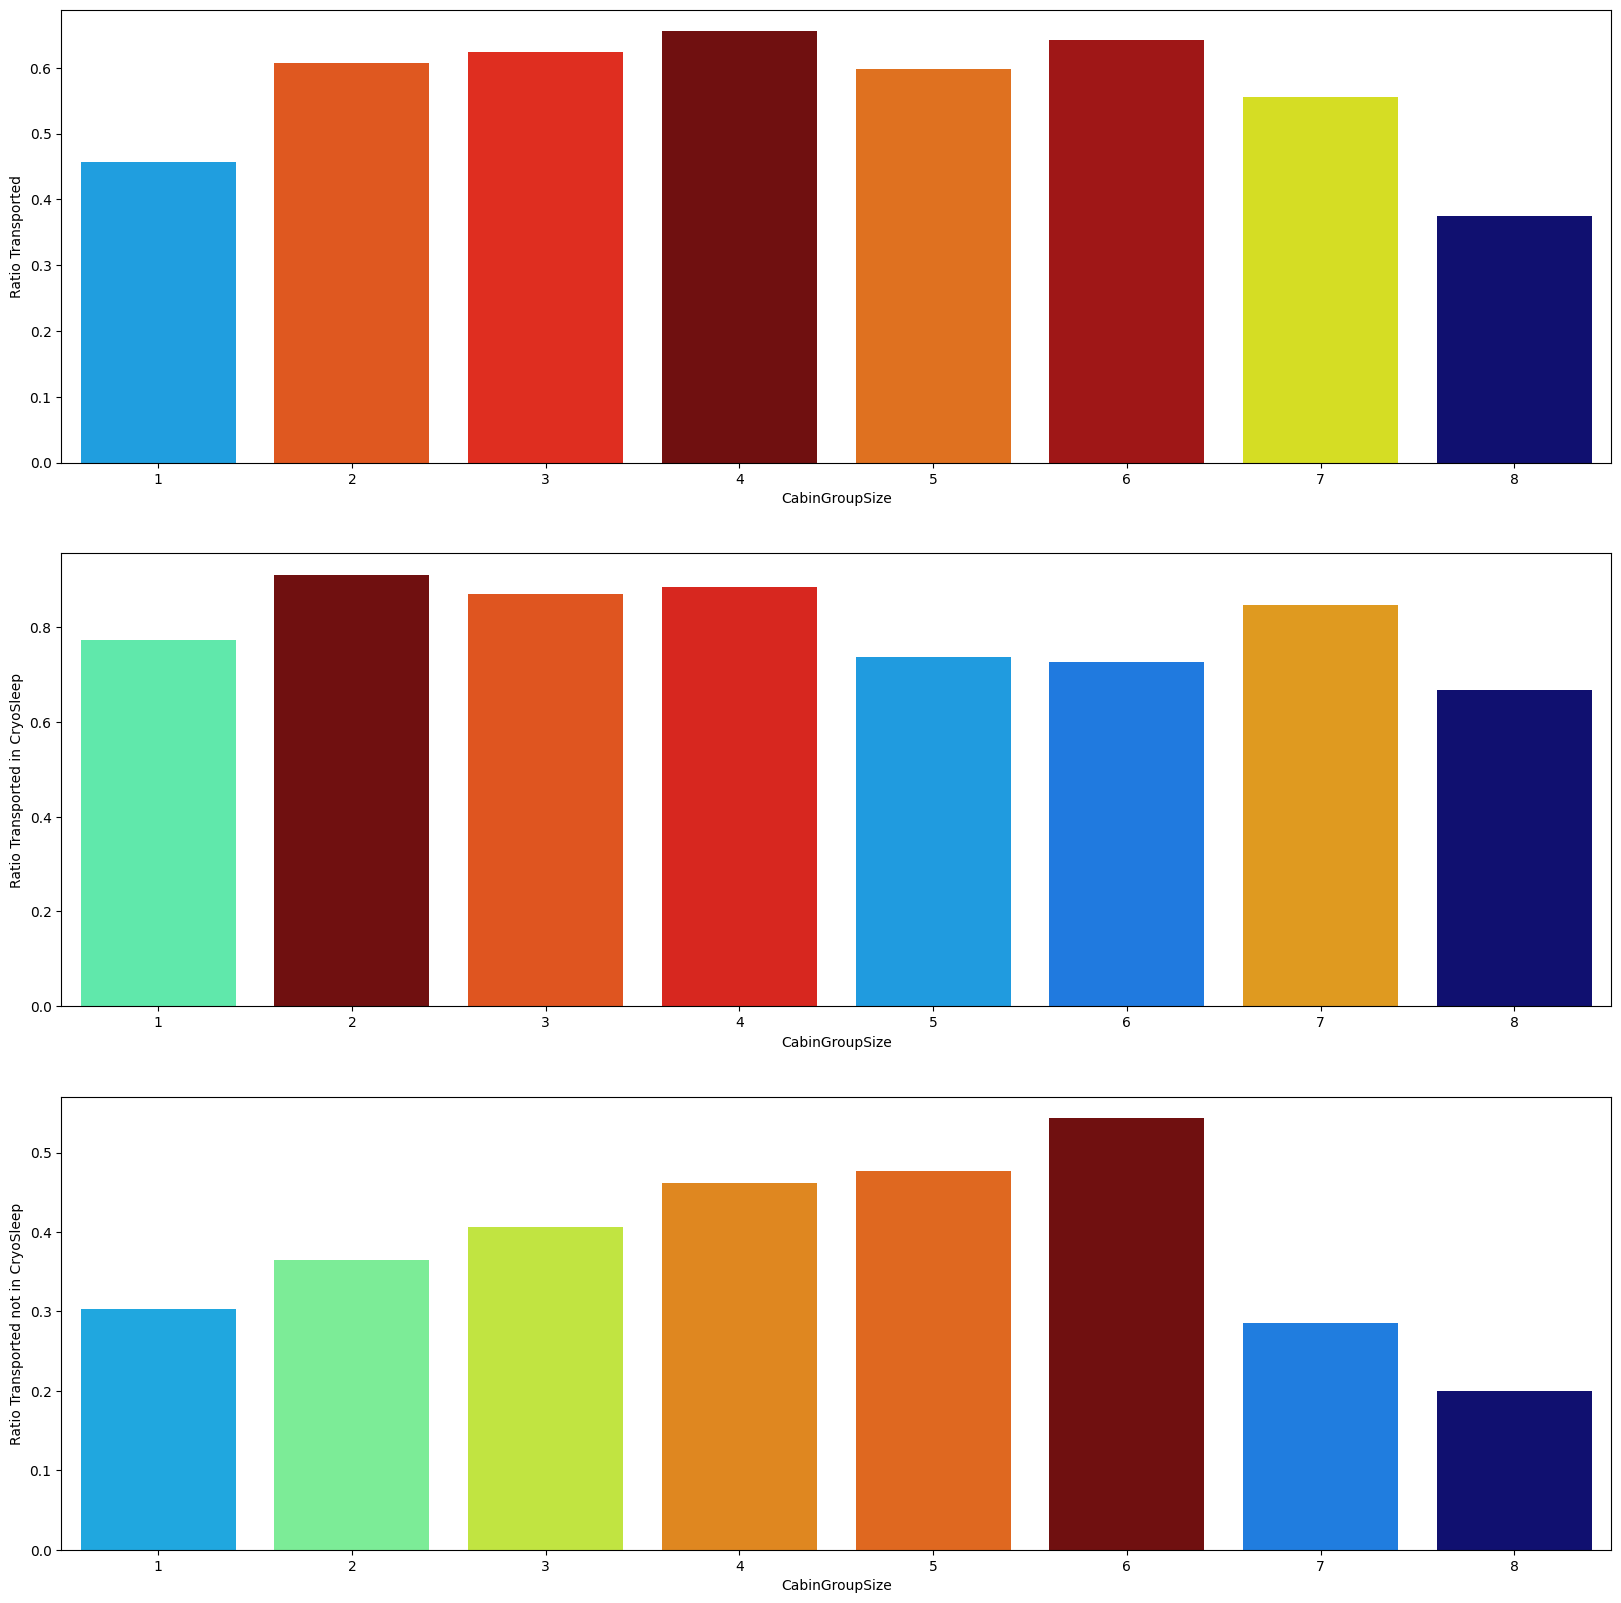

In [100]:
_, _ = plot_ratios_by_Cryo_and_Transported(df0, 'CabinGroupSize', cat = True)

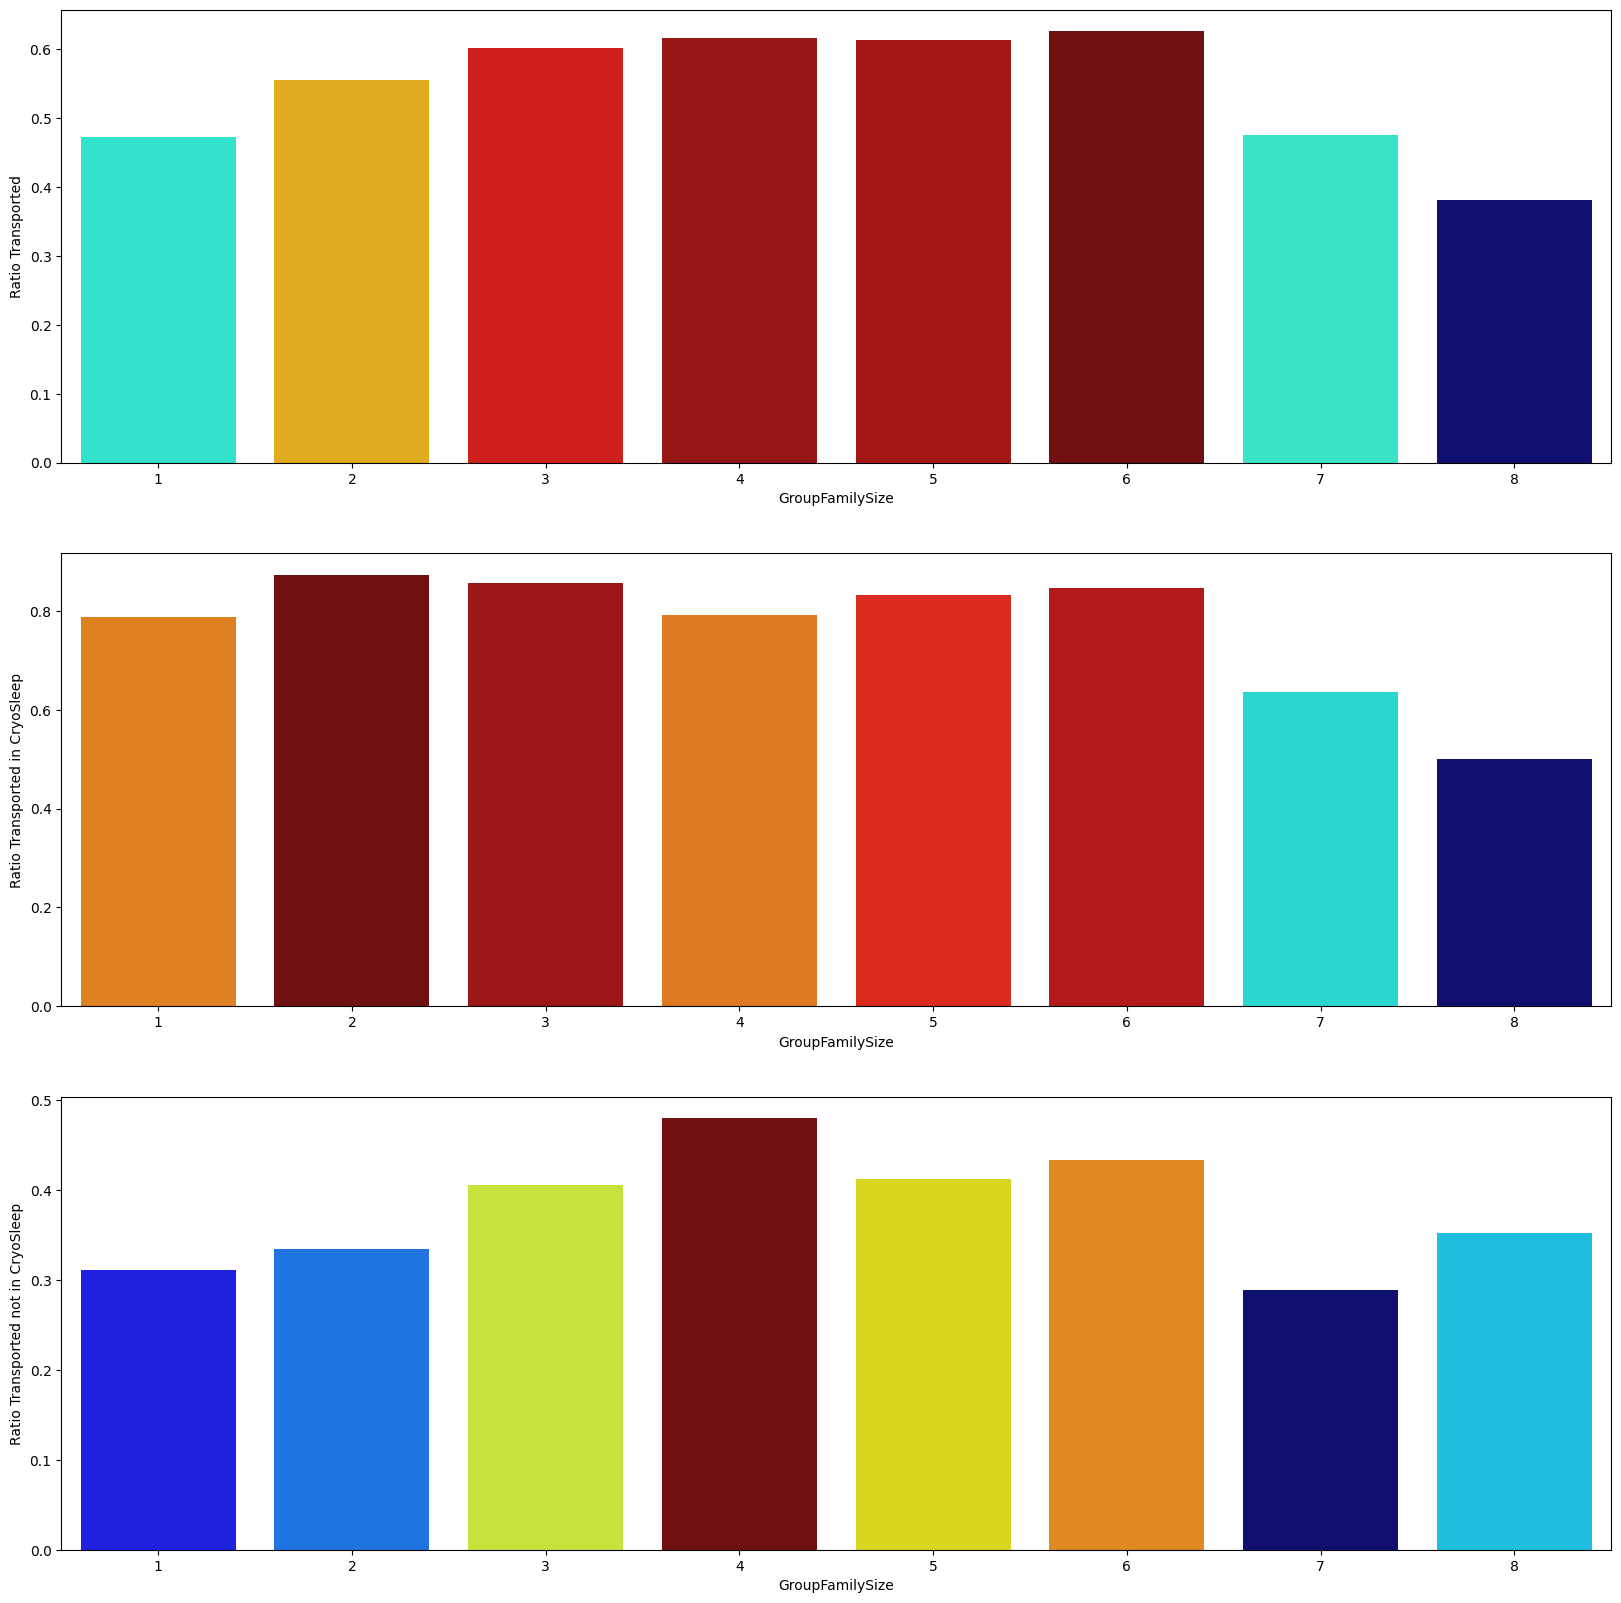

In [101]:
_, _ = plot_ratios_by_Cryo_and_Transported(df0, 'GroupFamilySize', cat = True)

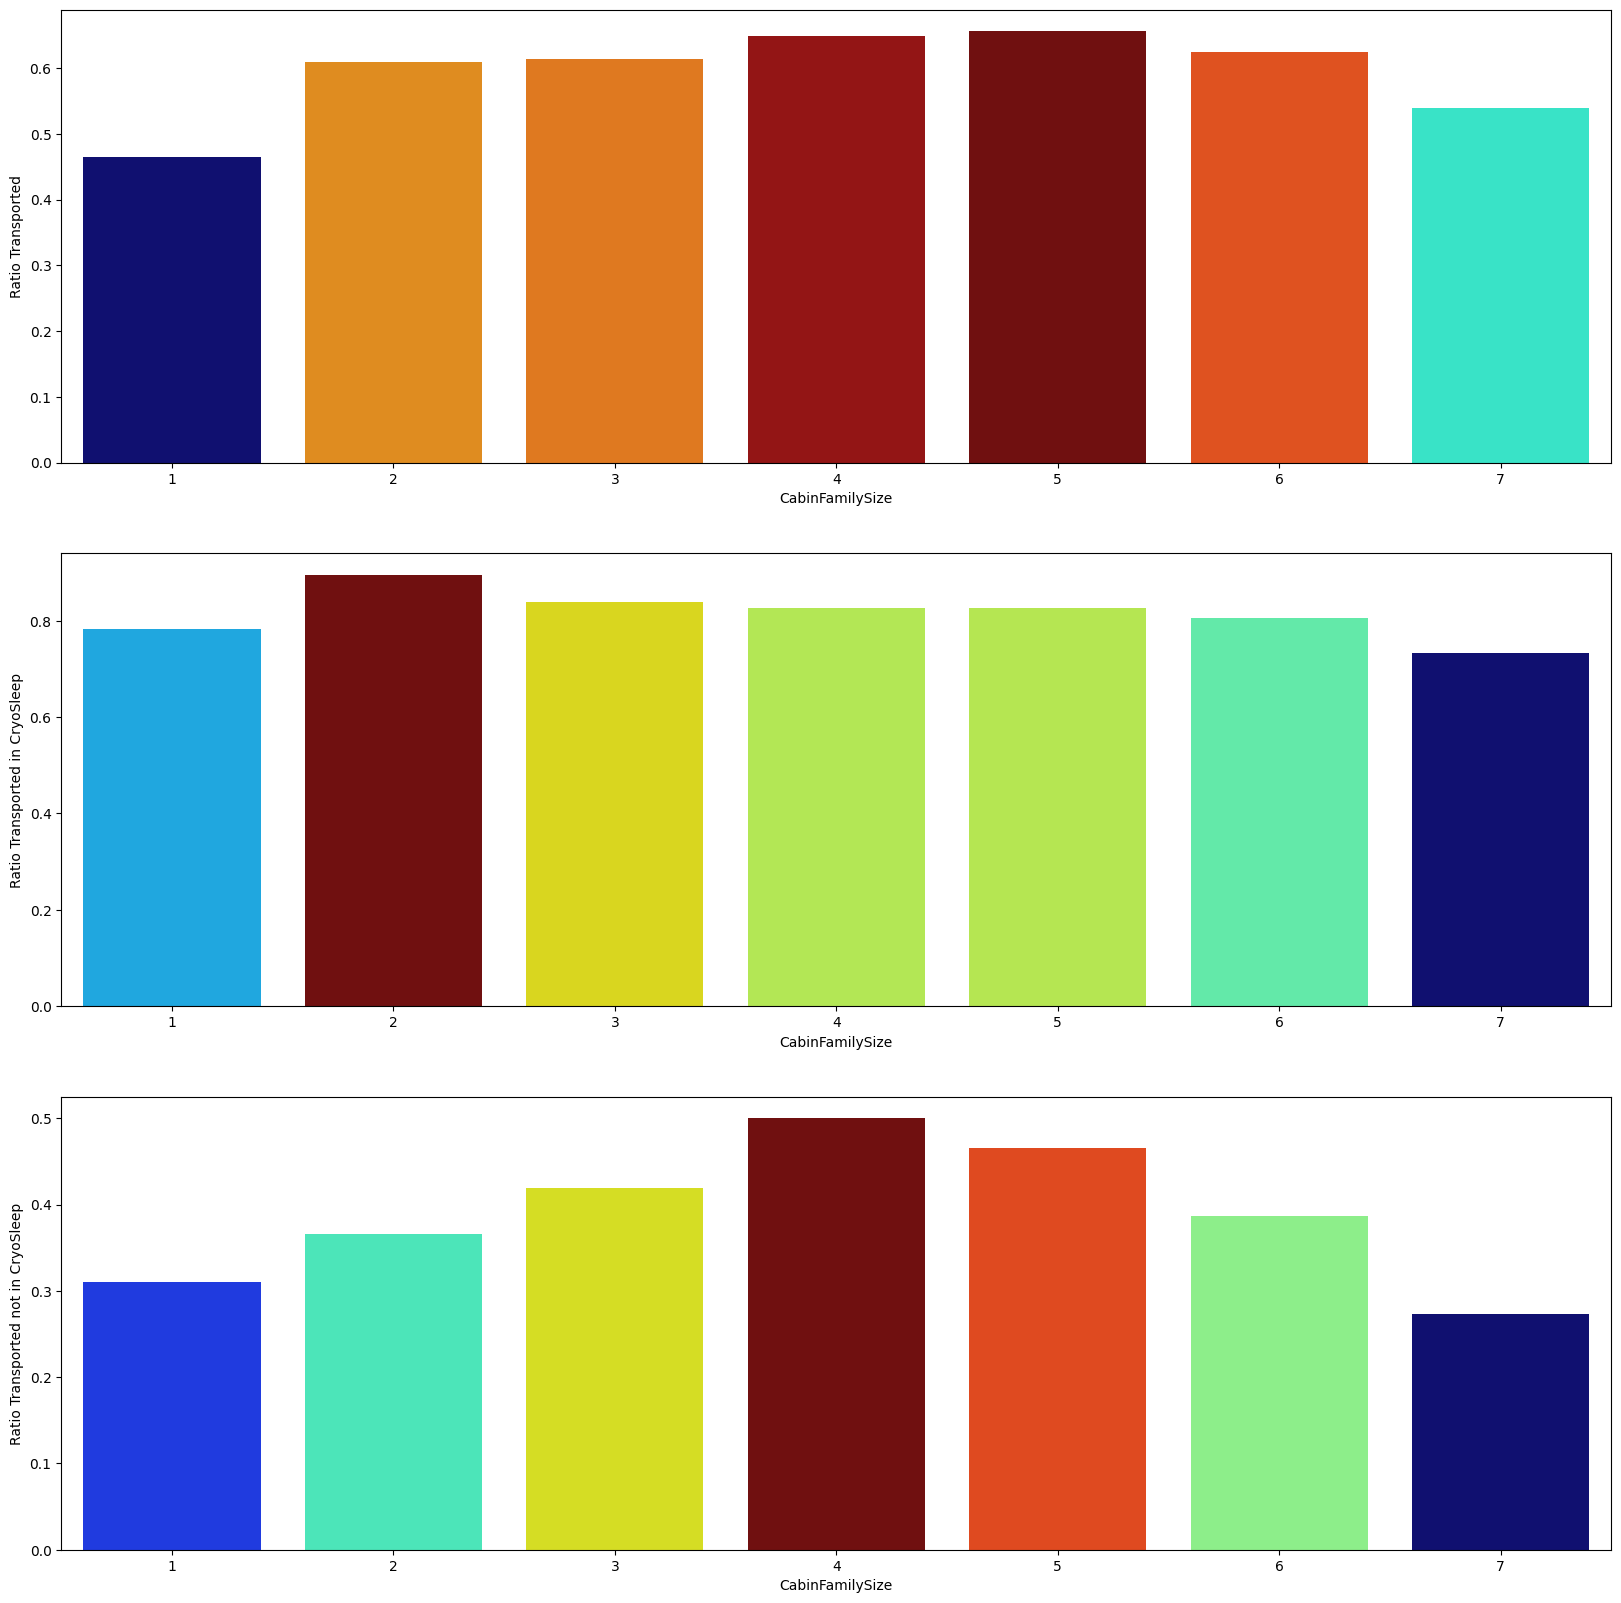

In [102]:
_, _ = plot_ratios_by_Cryo_and_Transported(df0, 'CabinFamilySize', cat = True)

#### Name Lengths

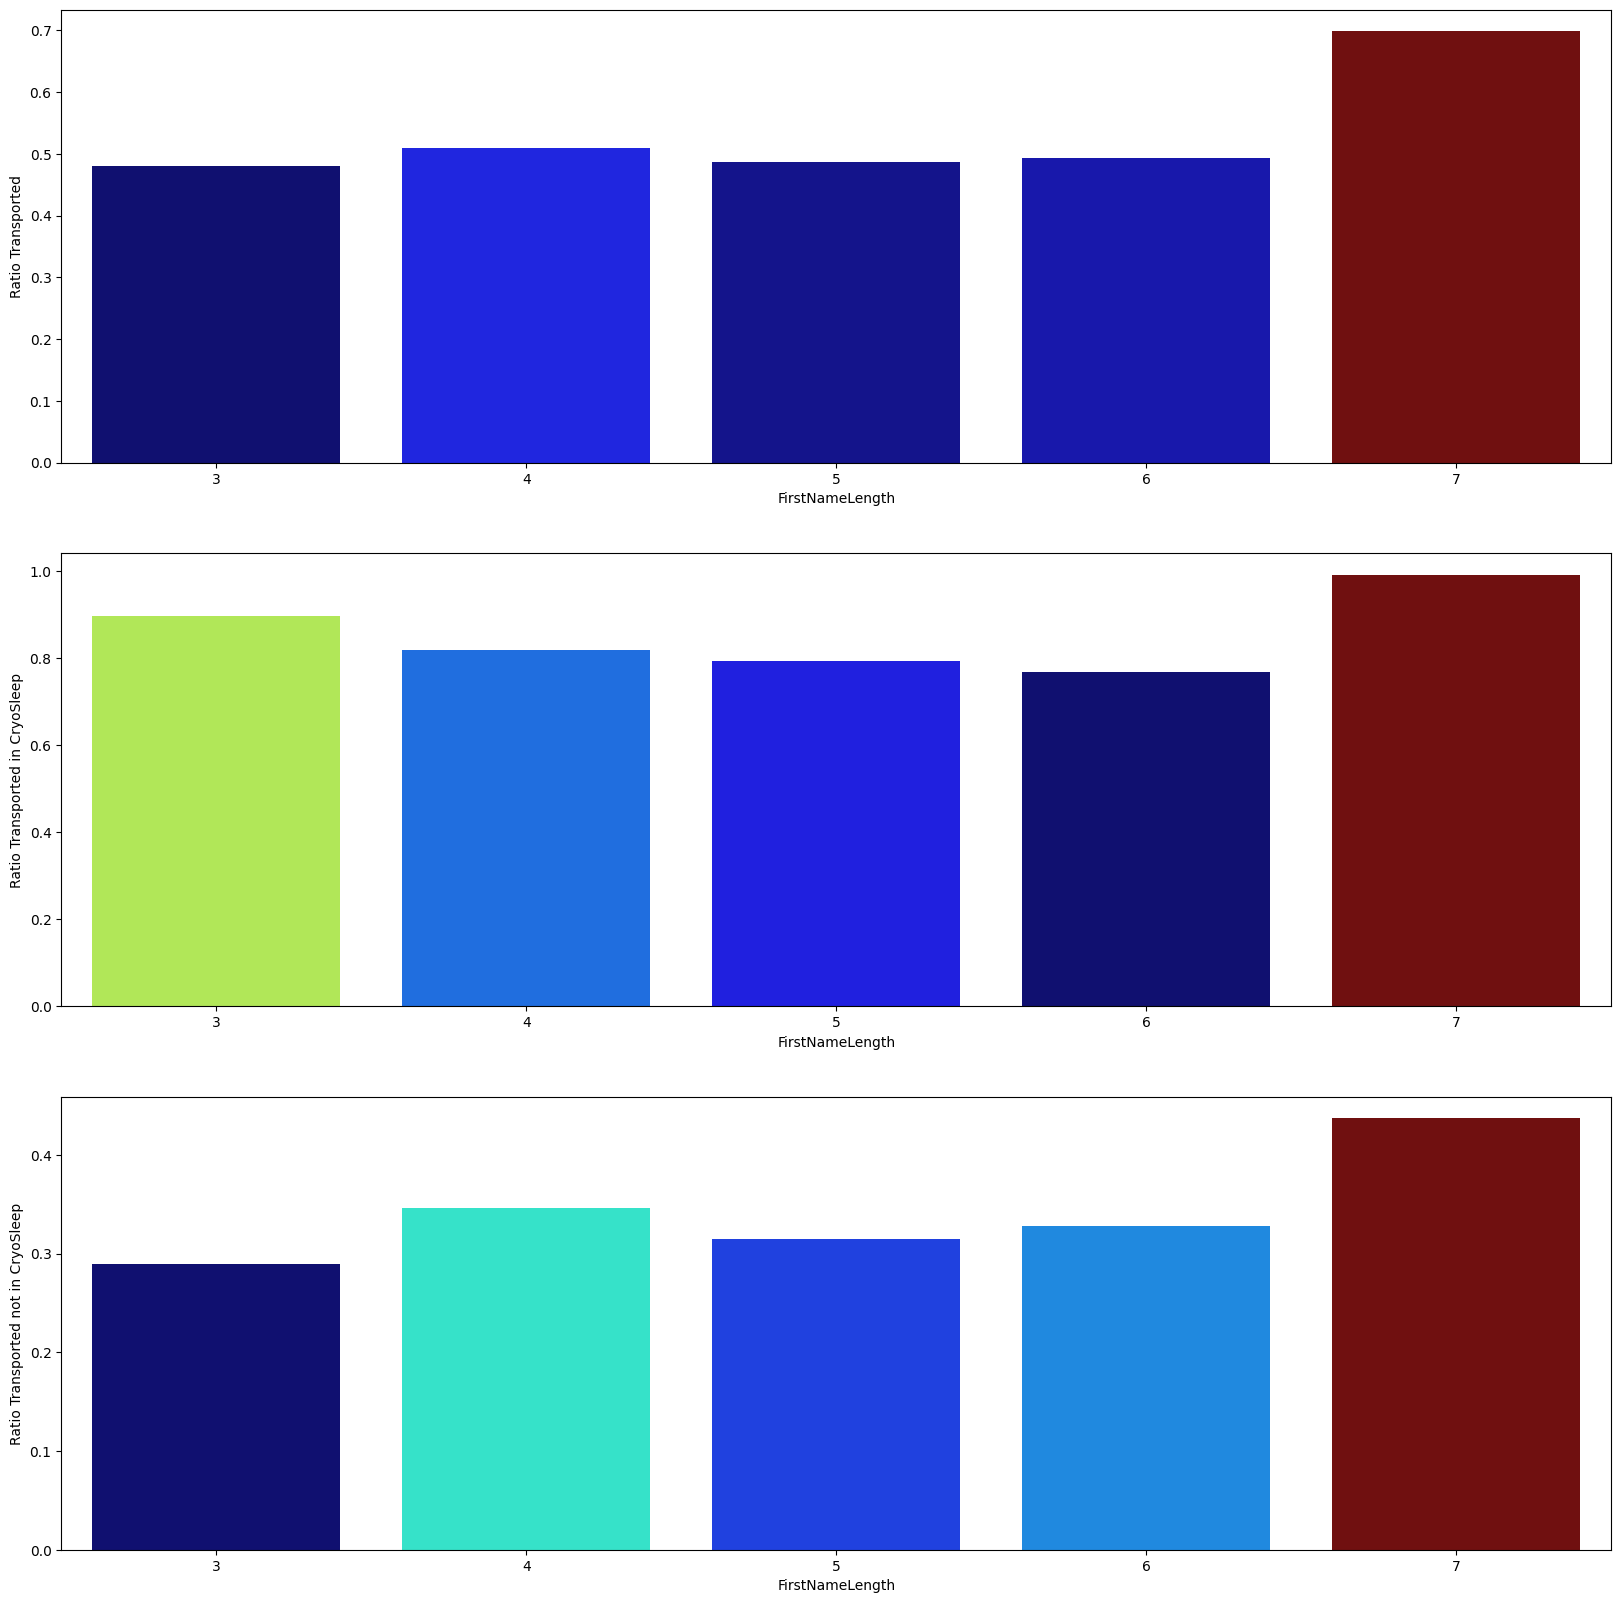

In [103]:
_, _ = plot_ratios_by_Cryo_and_Transported(df0, 'FirstNameLength', cat = True)

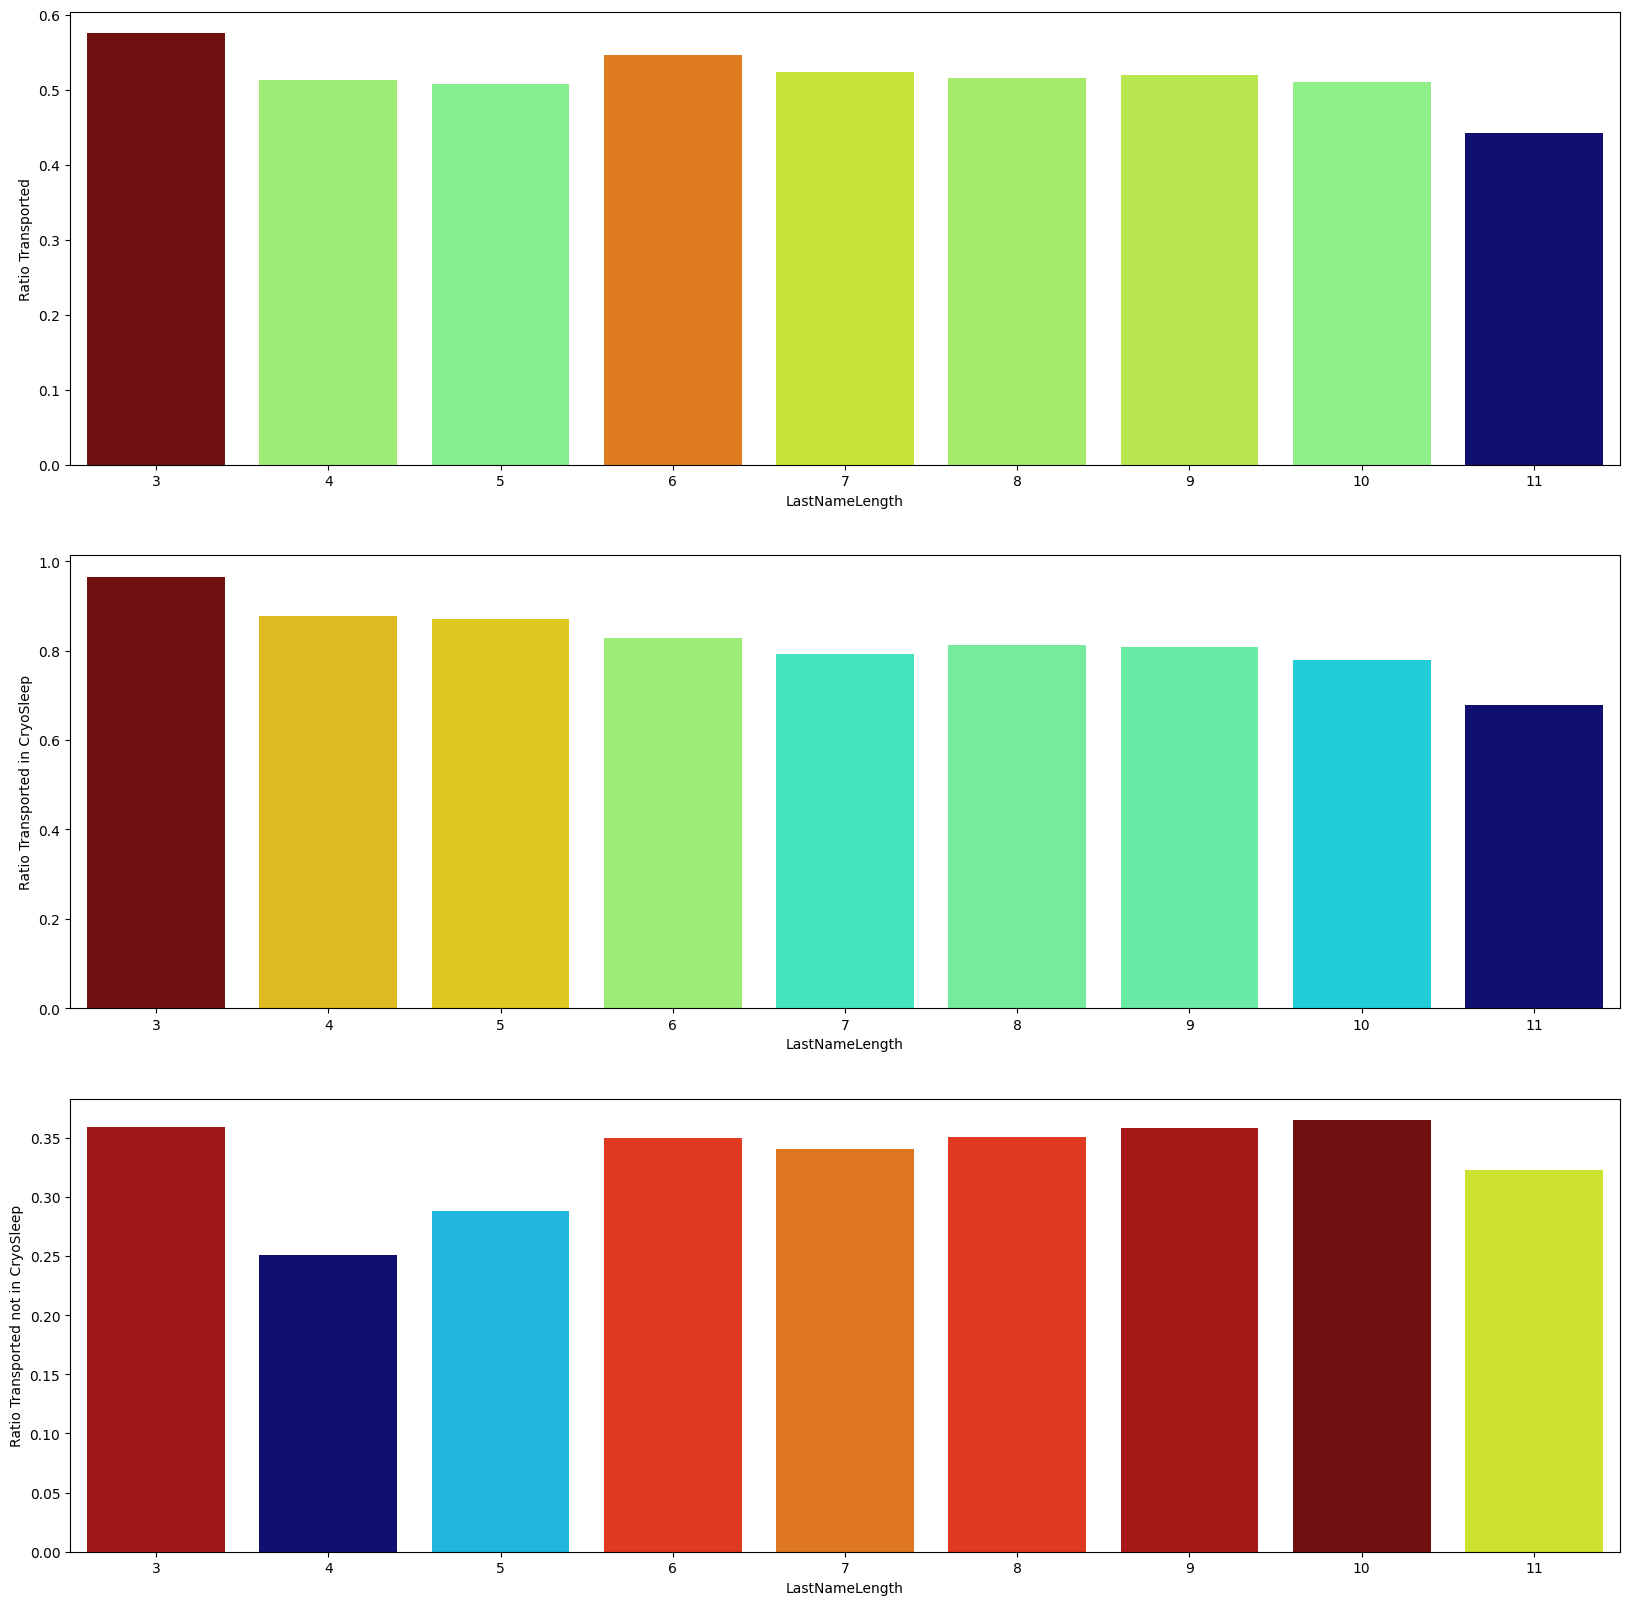

In [104]:
_, _ = plot_ratios_by_Cryo_and_Transported(df0, 'LastNameLength', cat = True)

#### For FirstNameLength it seems to matter whether it is a long name (7 letters or more) or not. However, this effect might be because passengers from Europa tend to have longer names and also are more likely to be transported overall. Let's check the distribution among passengers from Europa only. Similarly, short Family Names (3, 4) are all from Mars

In [105]:
df1 = pd.concat([df0, df_clean[['HomePlanet']]], axis = 1)

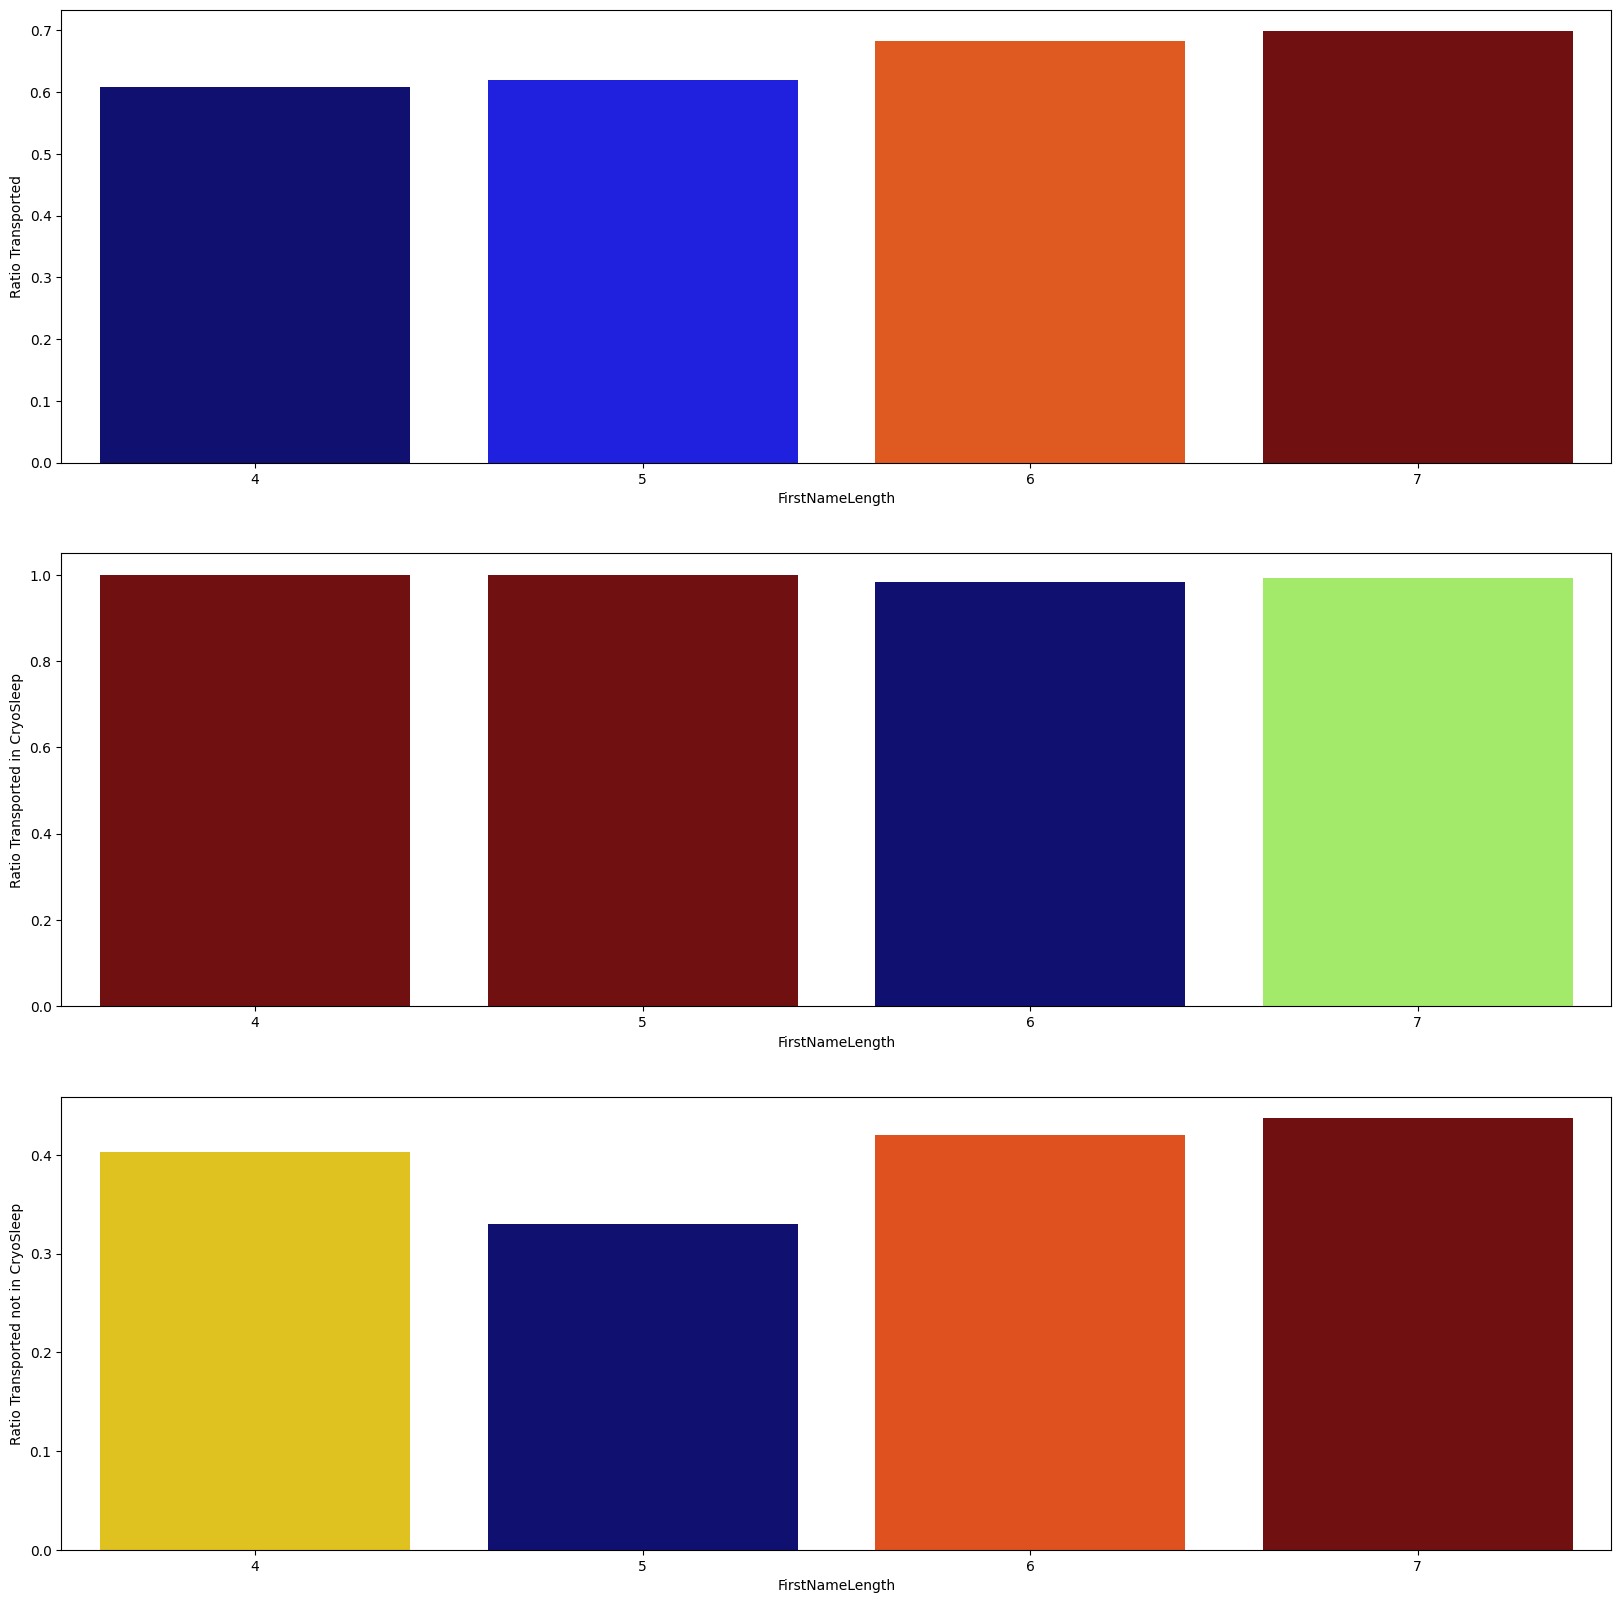

In [106]:
_, _ = plot_ratios_by_Cryo_and_Transported(df1[df1.HomePlanet == 'Europa'], 'FirstNameLength', cat = True)

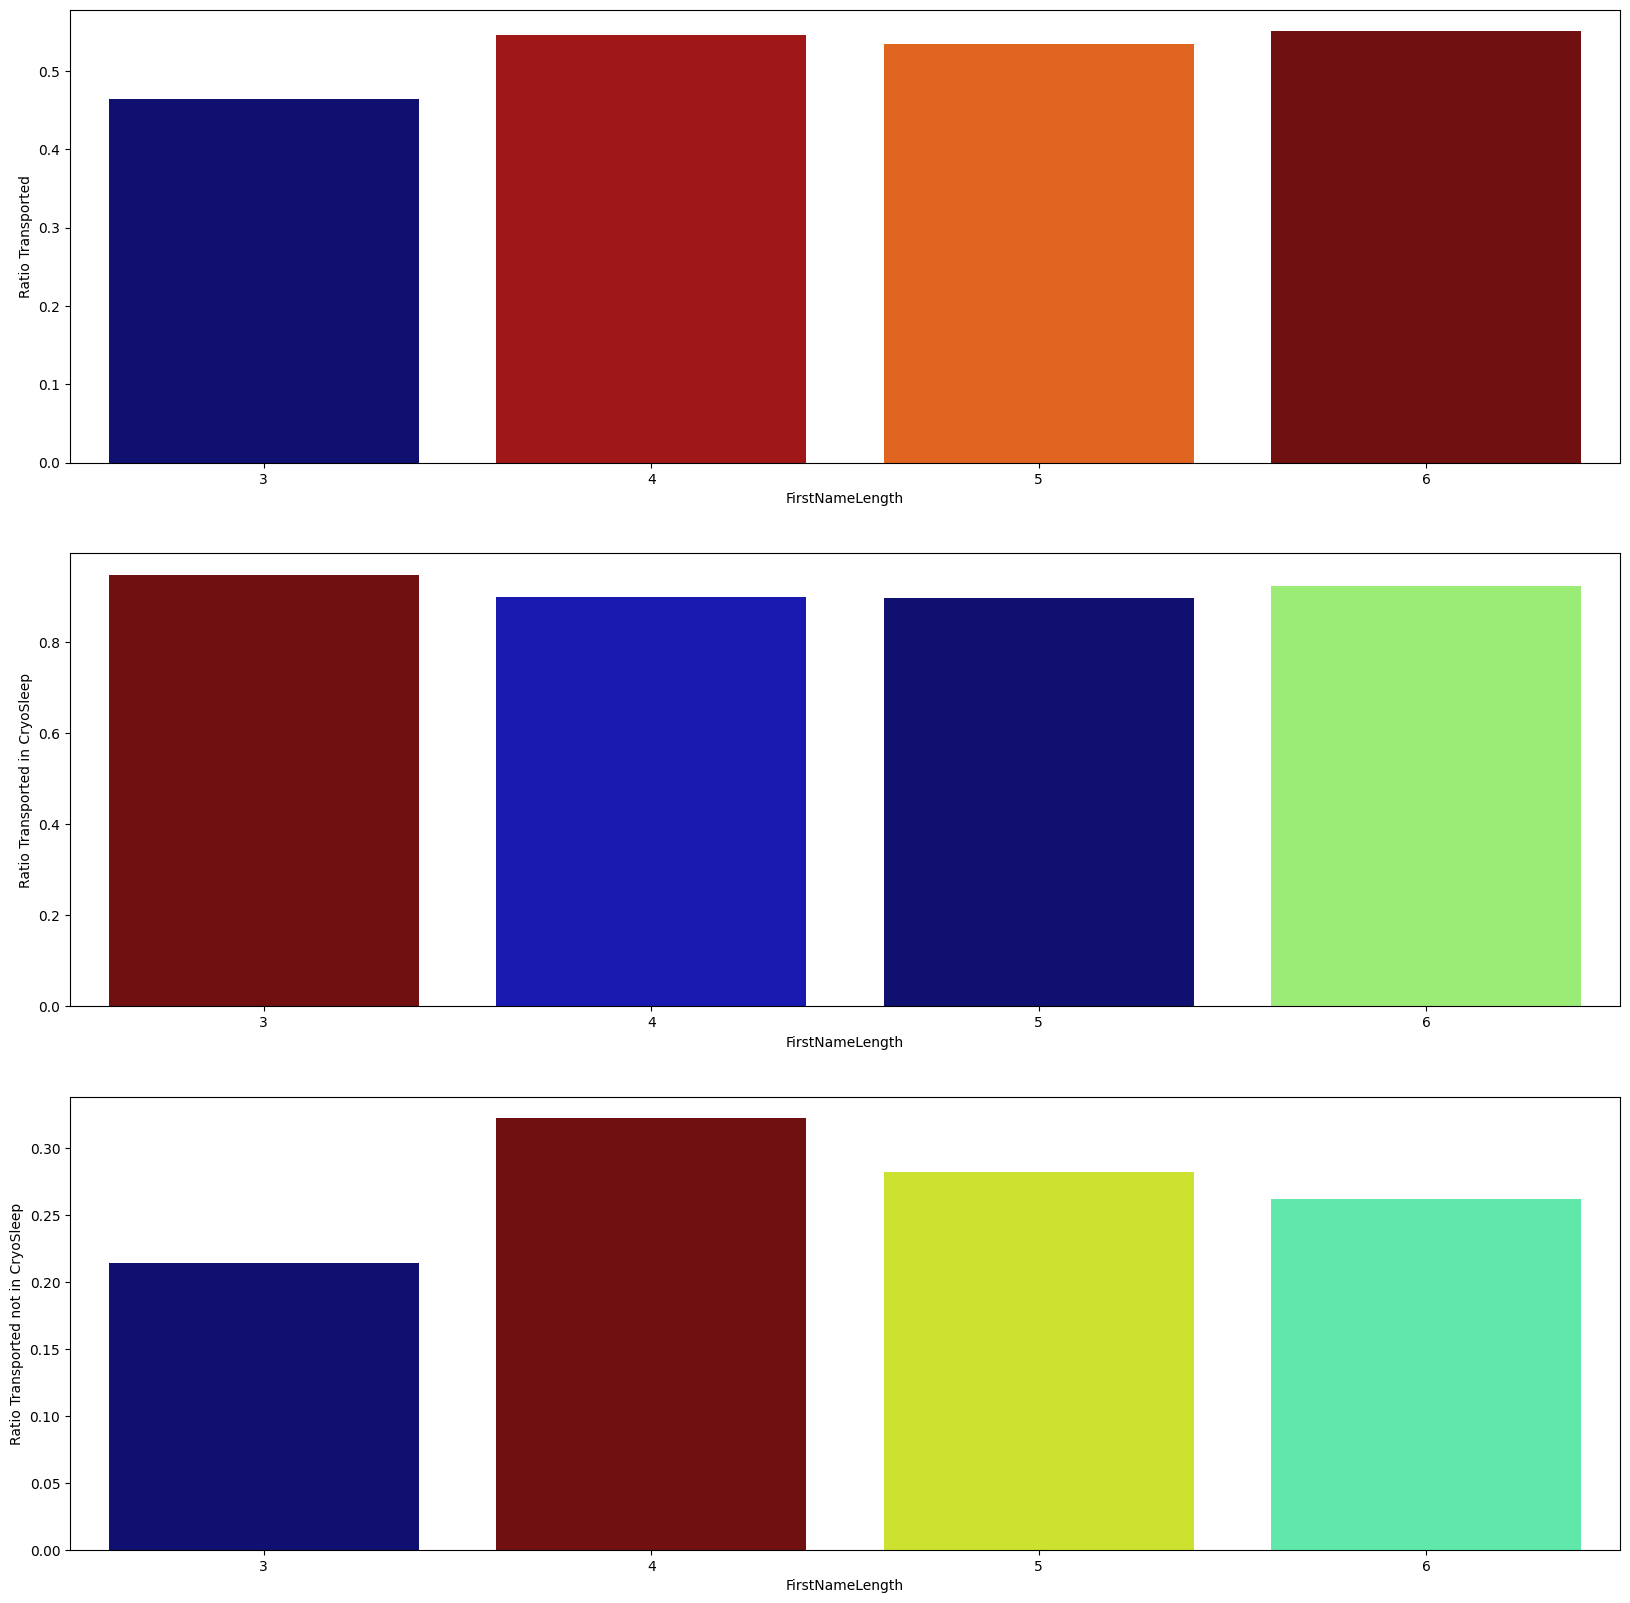

In [107]:
_, _ = plot_ratios_by_Cryo_and_Transported(df1[df1.HomePlanet == 'Mars'], 'FirstNameLength', cat = True)

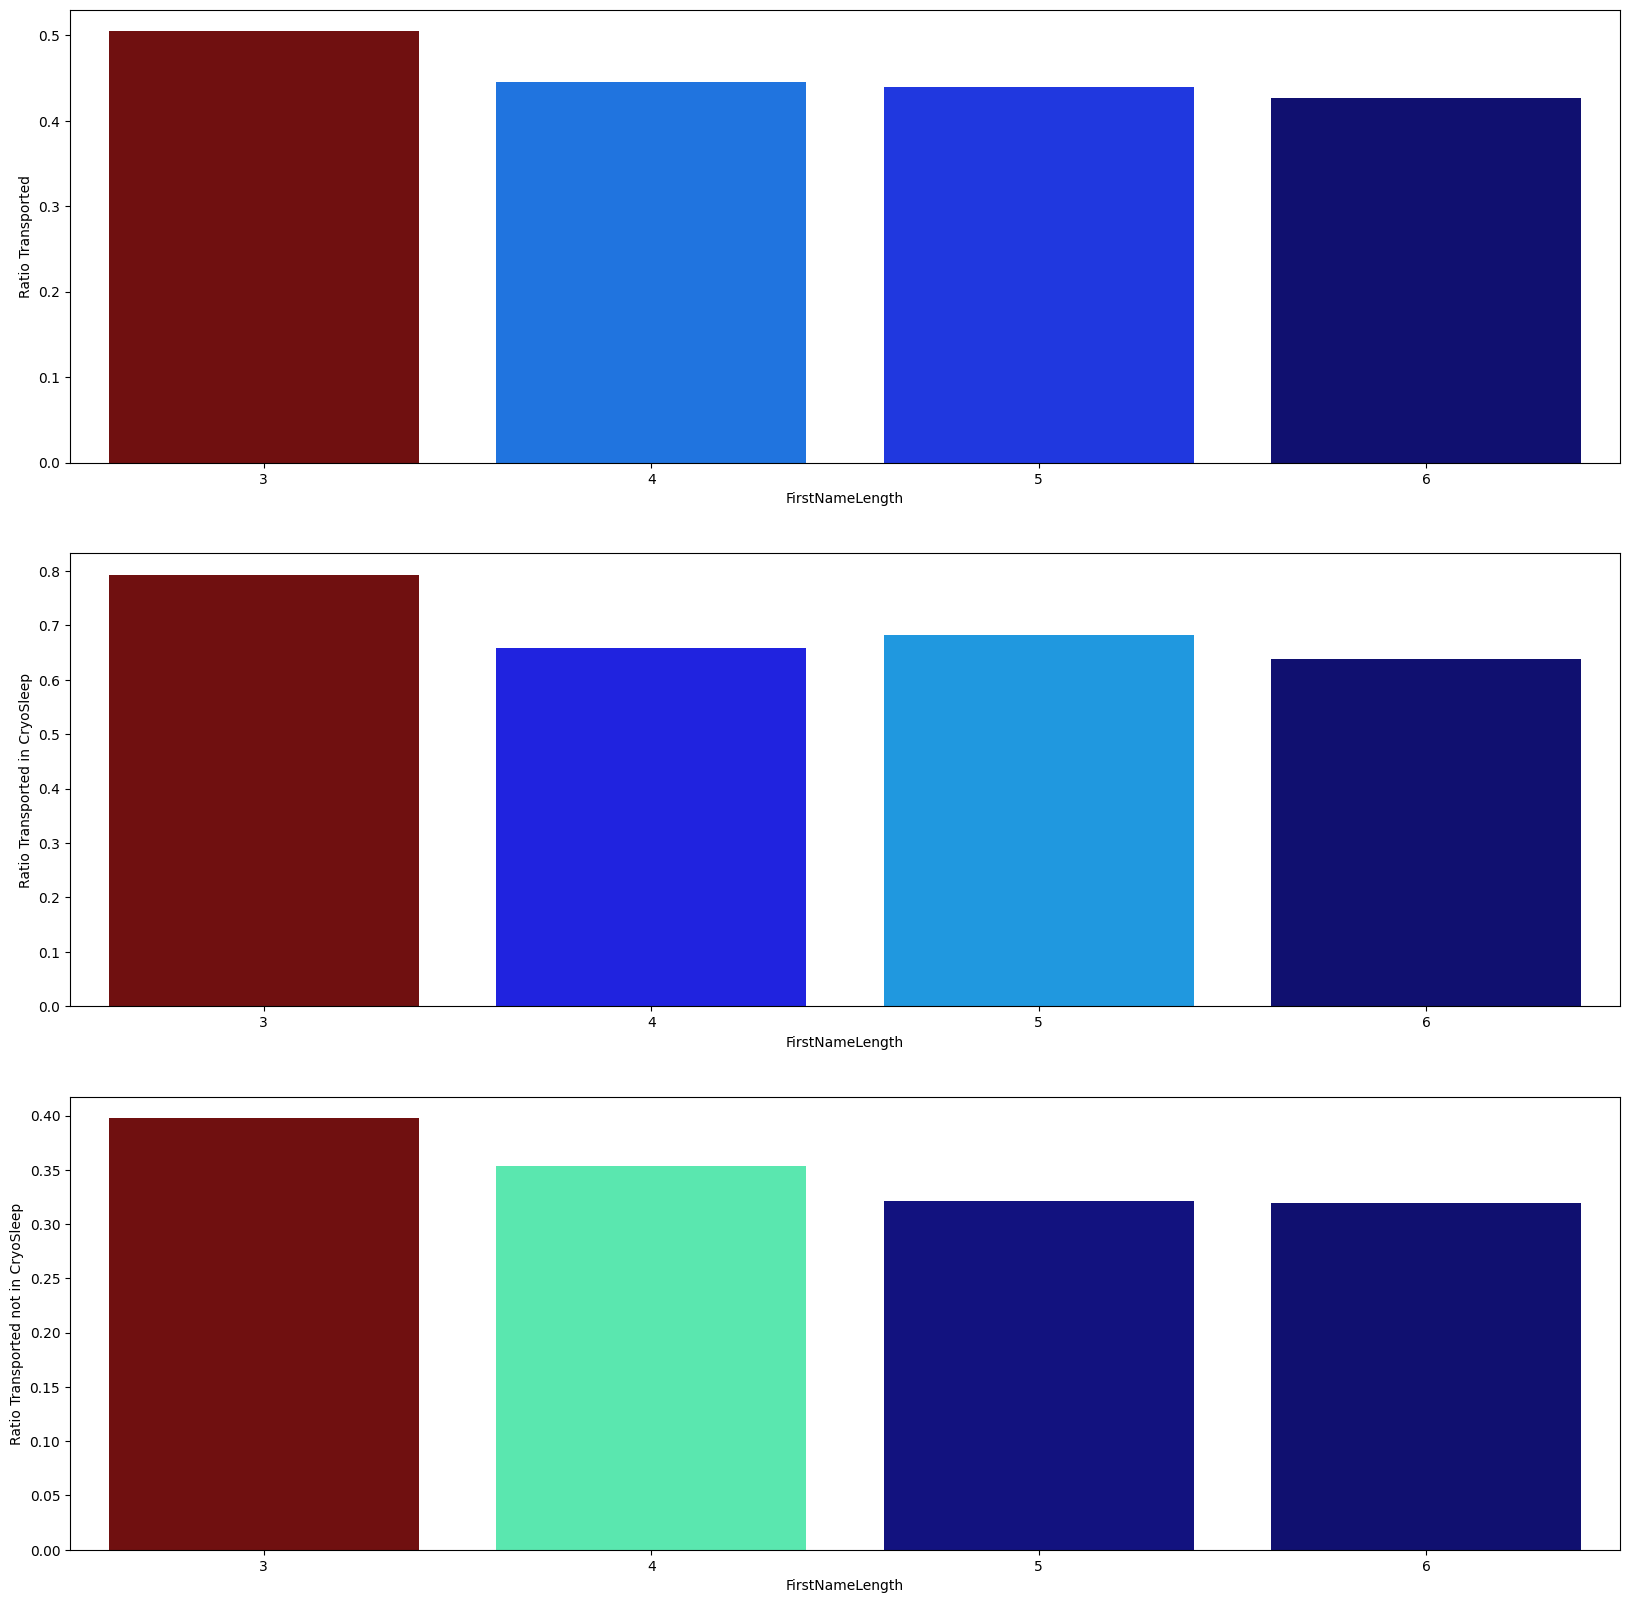

In [108]:
_, _ = plot_ratios_by_Cryo_and_Transported(df1[df1.HomePlanet == 'Earth'], 'FirstNameLength', cat = True)

#### FirstNameLength might have small predictive power when combined with HomePlanet info

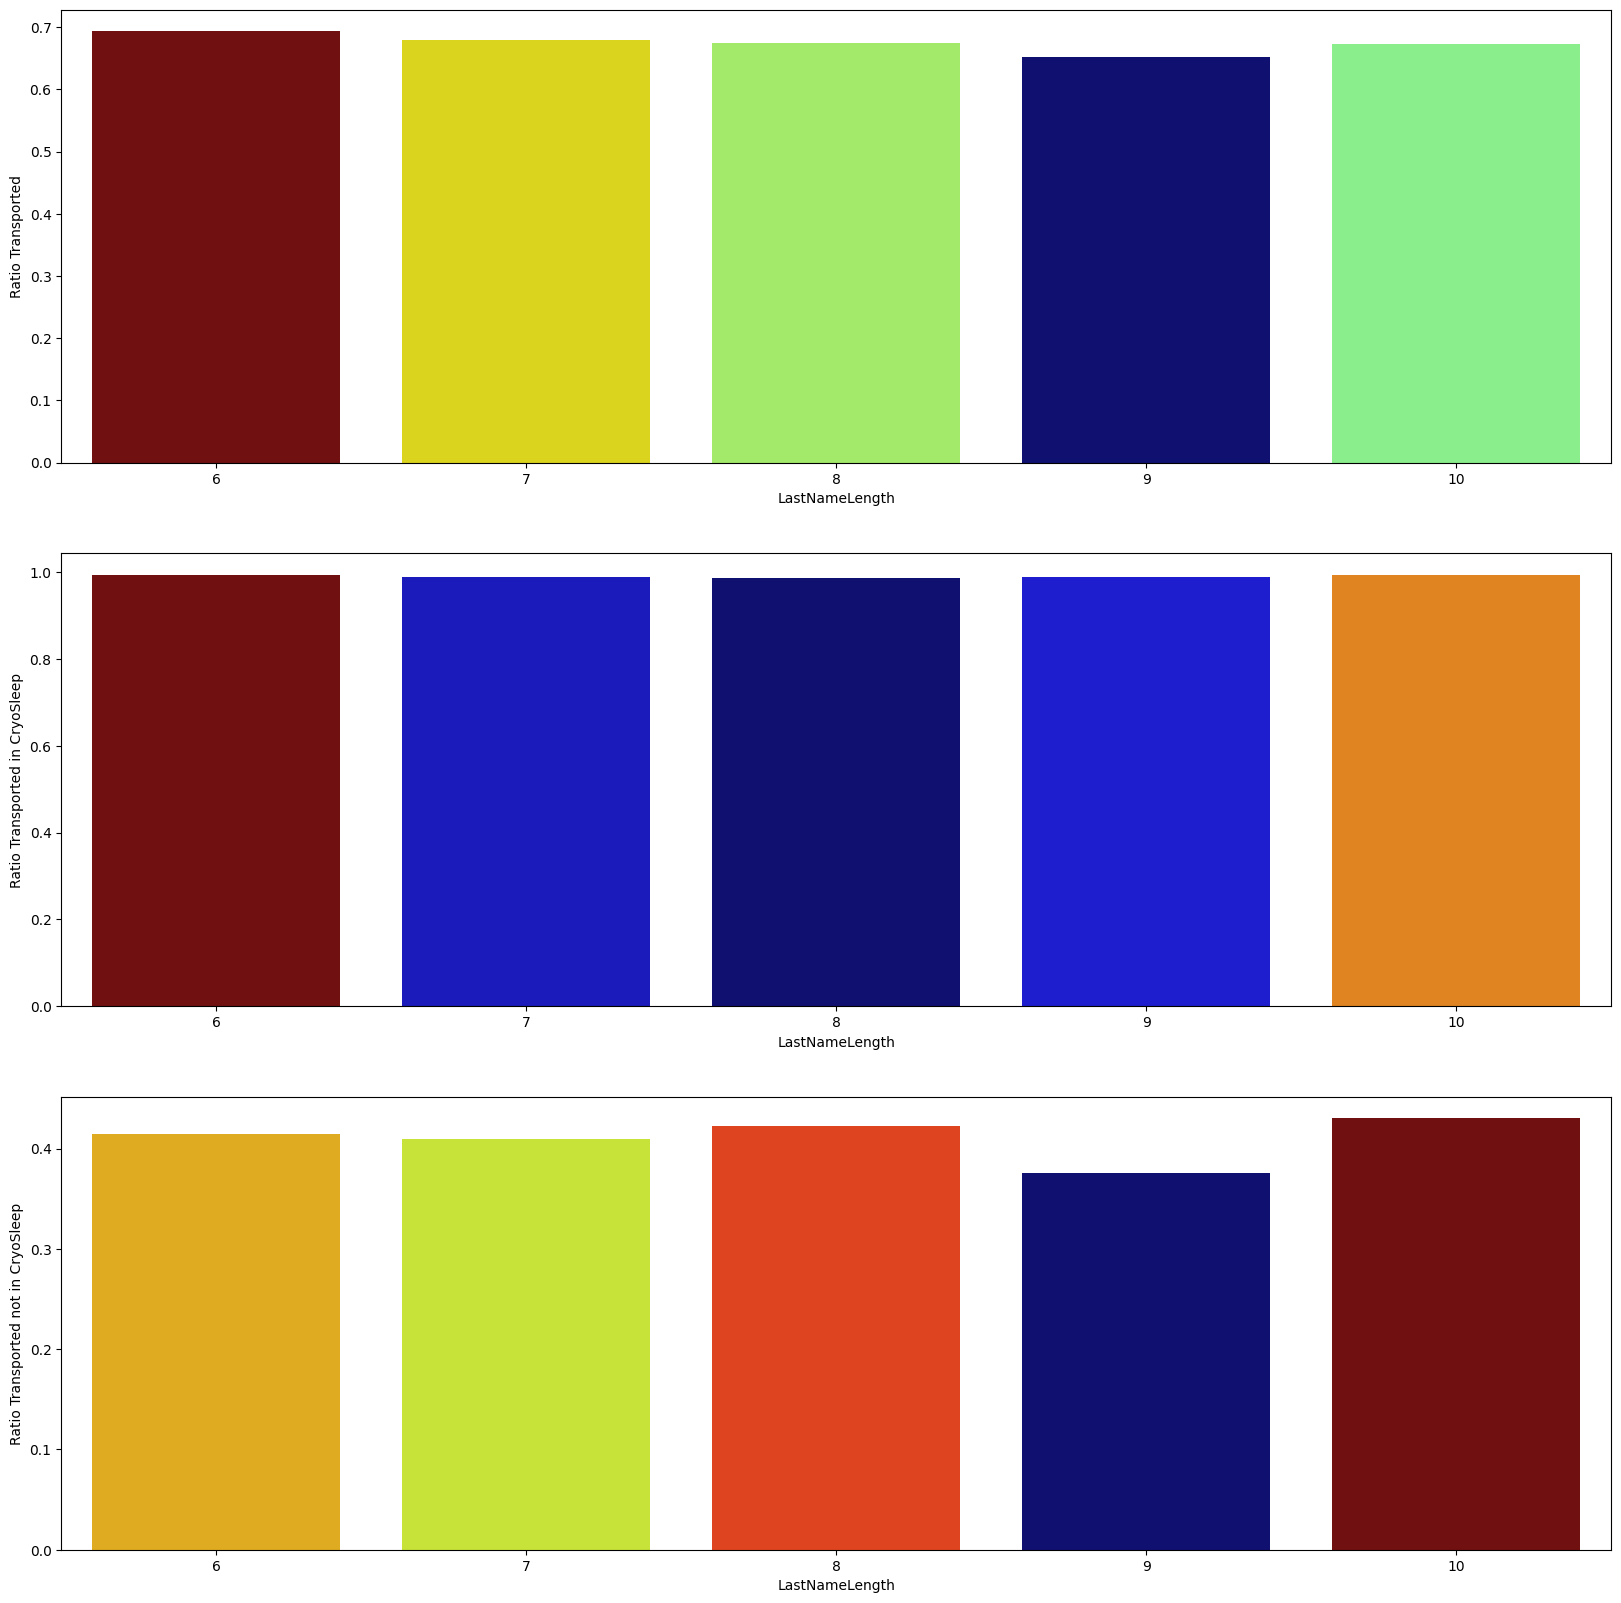

In [109]:
_, _ = plot_ratios_by_Cryo_and_Transported(df1[df1.HomePlanet == 'Europa'], 'LastNameLength', cat = True)

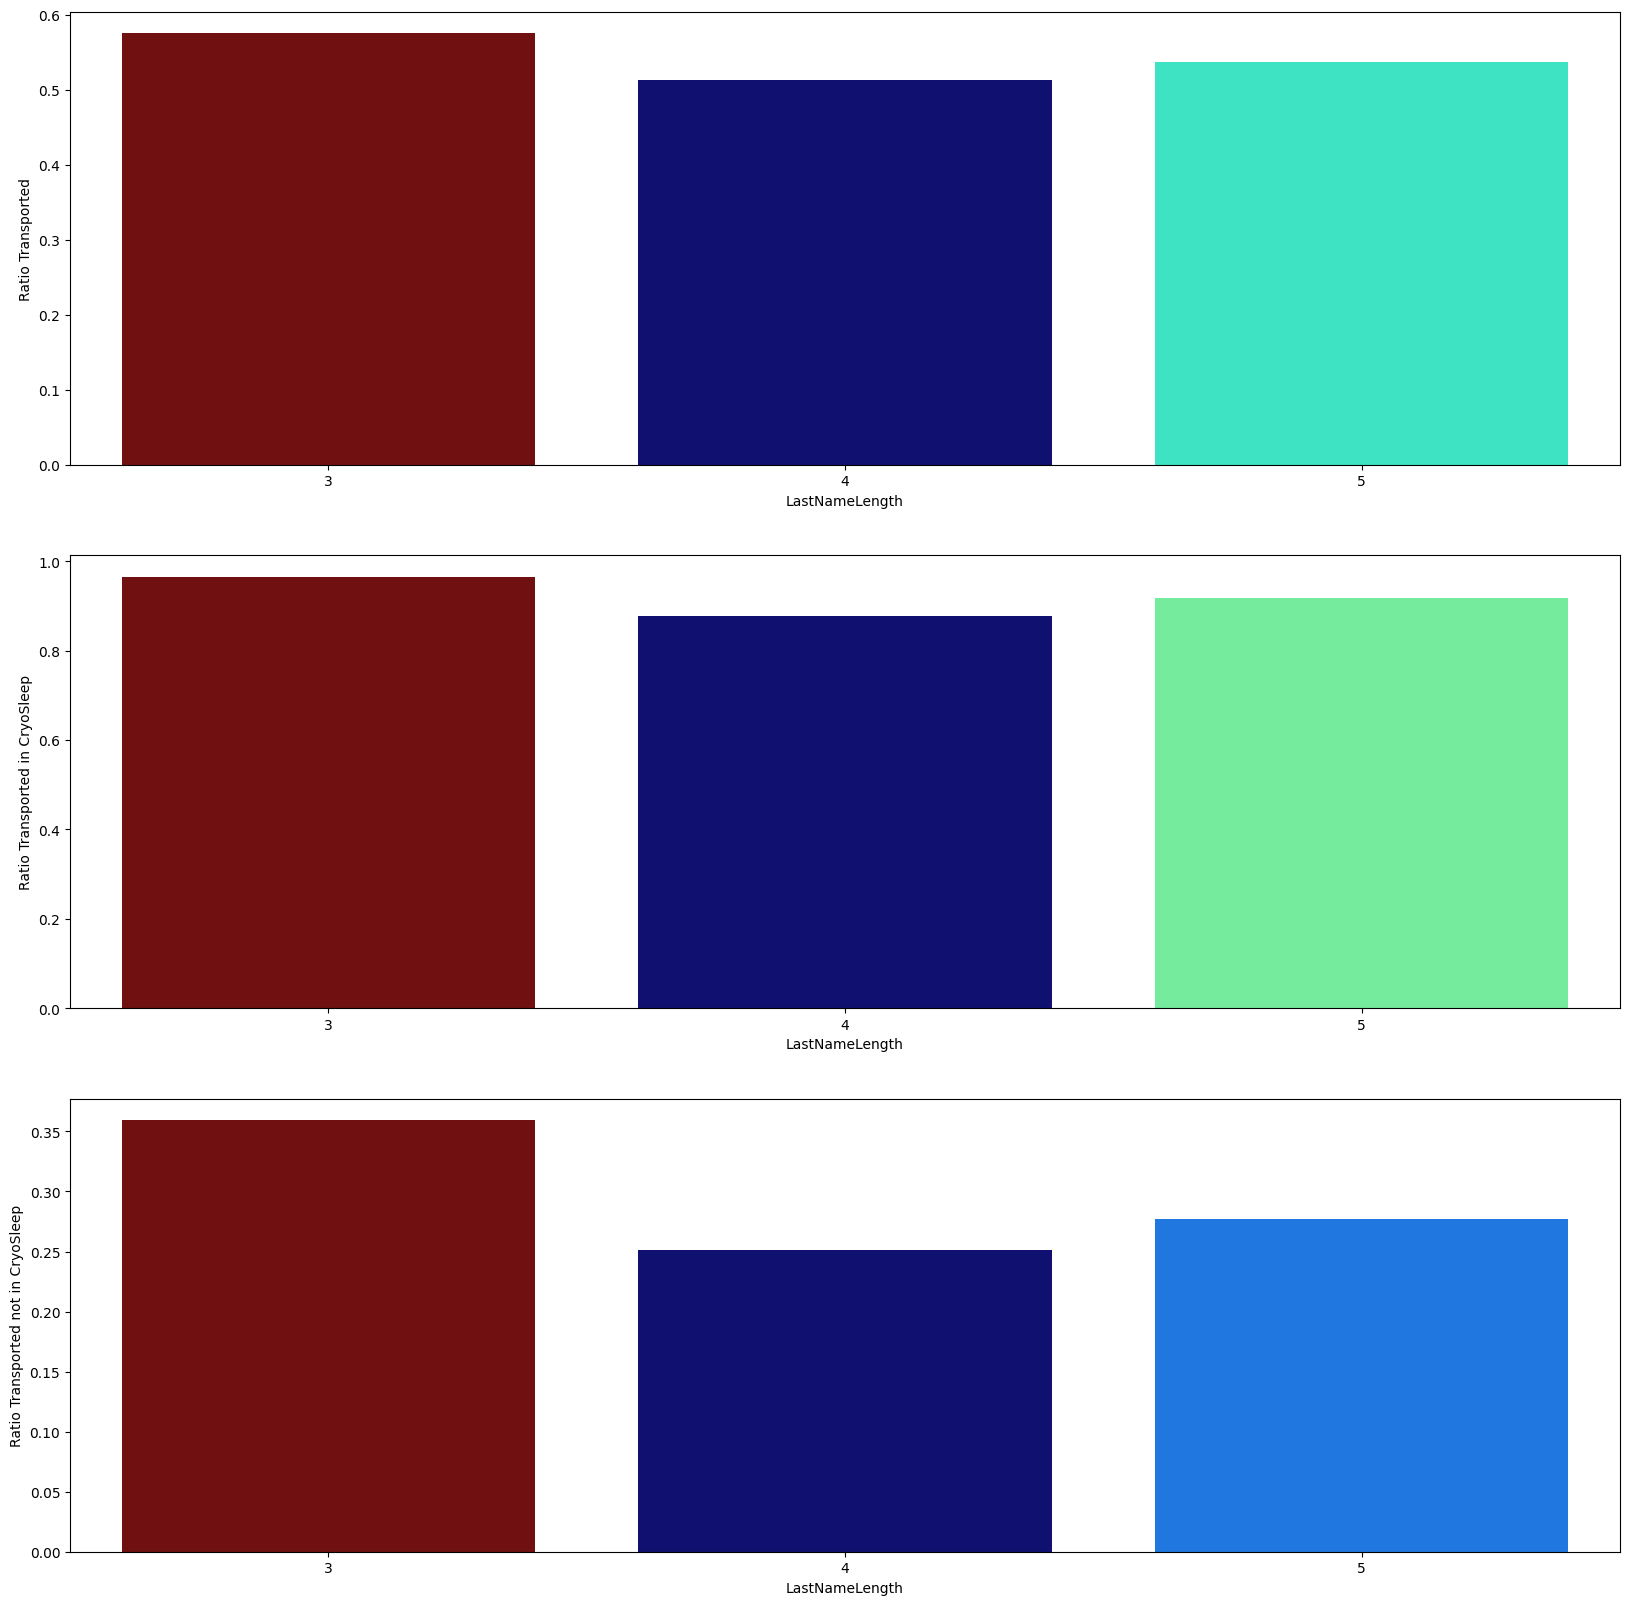

In [110]:
_, _ = plot_ratios_by_Cryo_and_Transported(df1[df1.HomePlanet == 'Mars'], 'LastNameLength', cat = True)

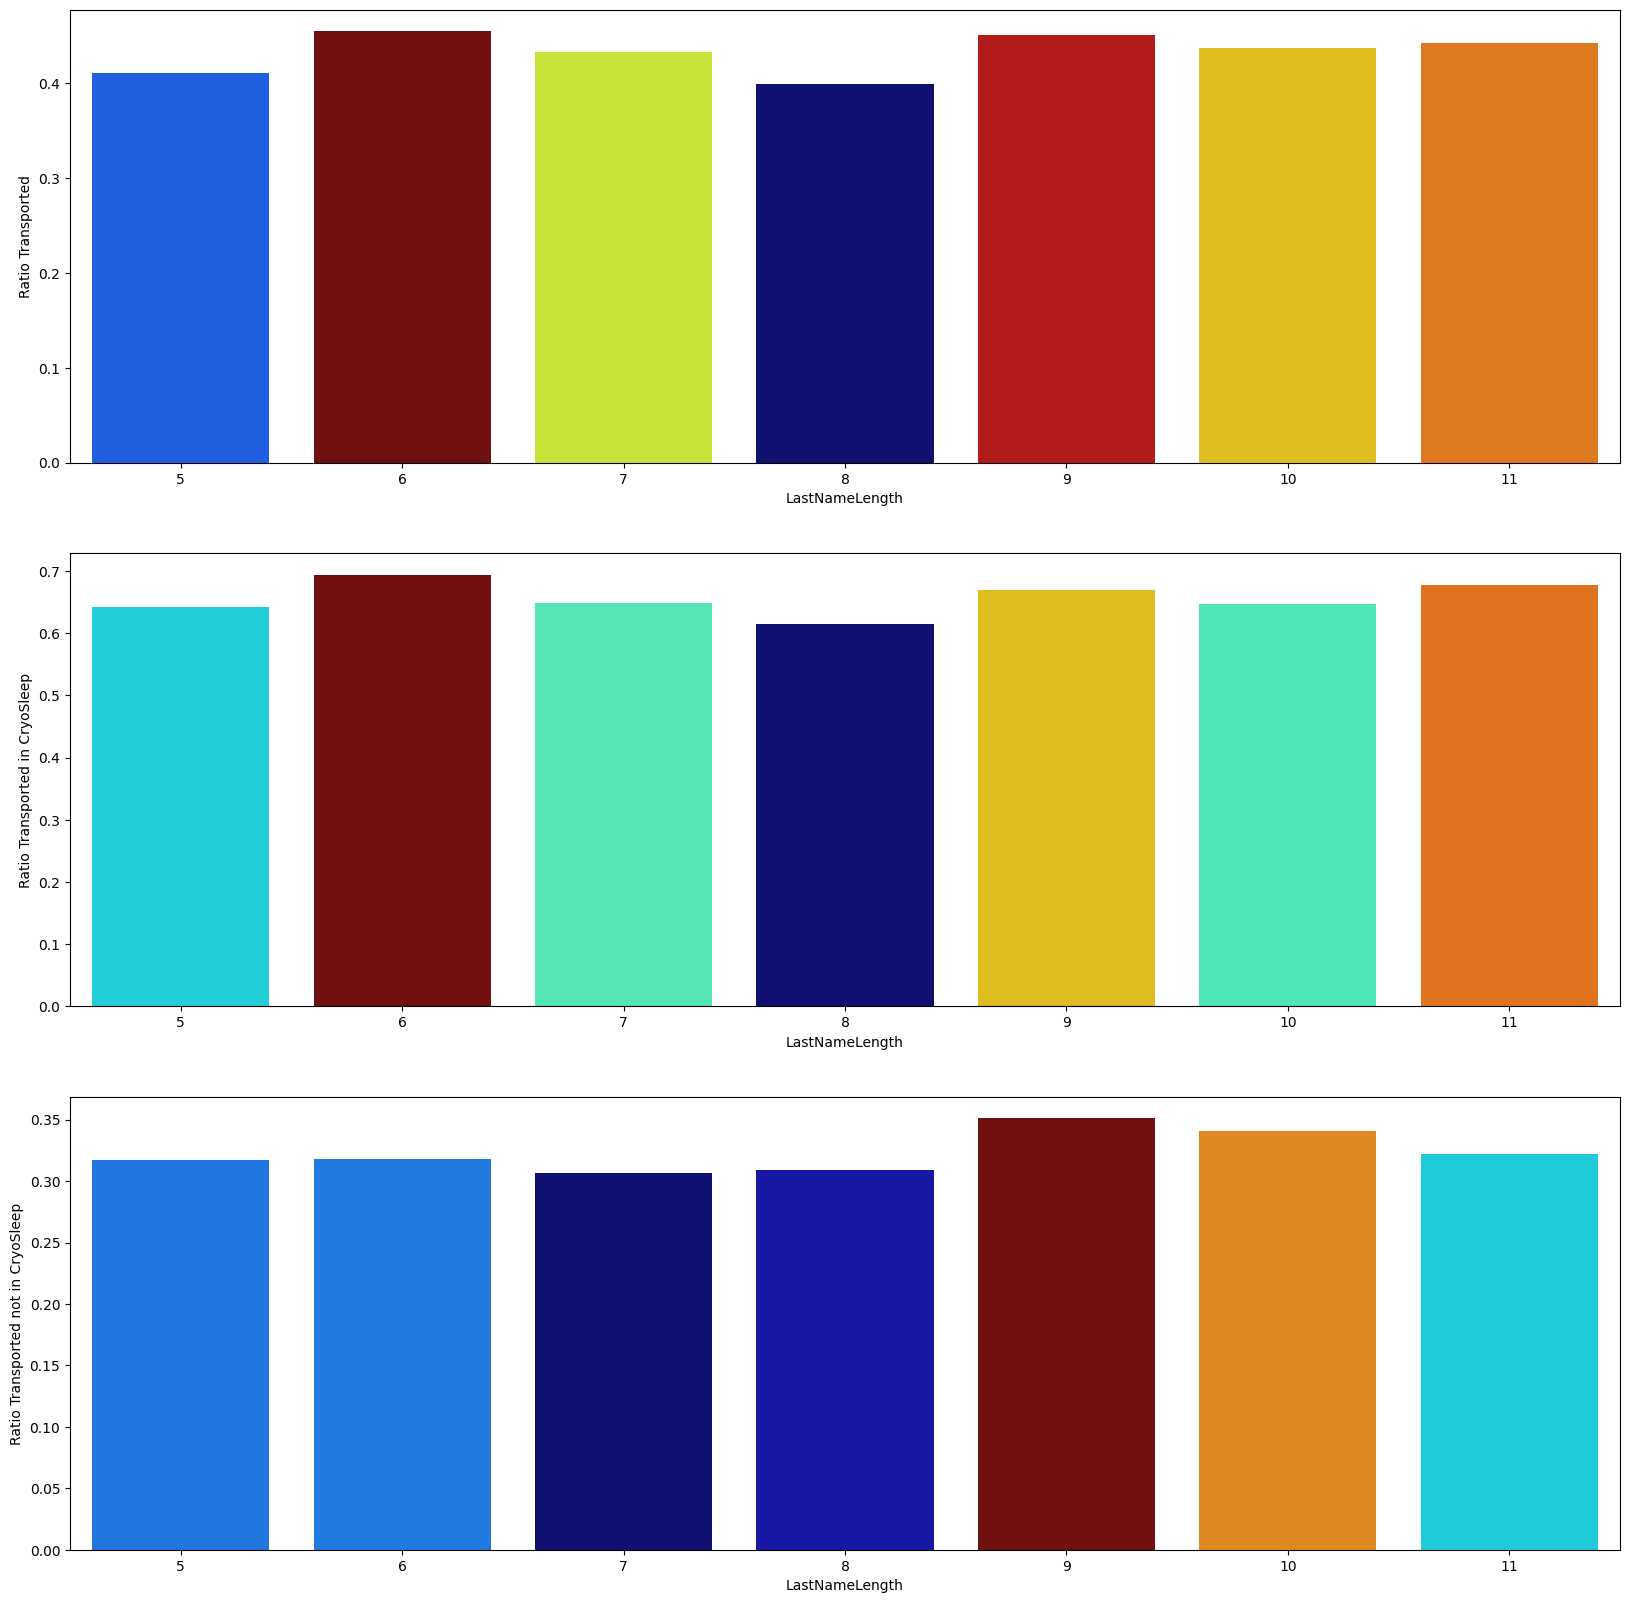

In [111]:
_, _ = plot_ratios_by_Cryo_and_Transported(df1[df1.HomePlanet == 'Earth'], 'LastNameLength', cat = True)

#### Let's Check the effect on performance

In [112]:
df1 = pd.concat([df0, df0_base, df_clean[['HomePlanet', 'Destination', 'deck']]], axis = 1)
df1['HomePlanet_deck'] = df1.HomePlanet + df1.deck
df1['BigFamily'] = (df1['FamilySize'] > 6).astype(int)
skewed_features = ['GroupSize', 'CabinSize', 'FamilySize','CabinGroupSize', 'CabinFamilySize', 'GroupFamilySize']
df1[skewed_features] = df1[skewed_features].apply(np.log1p)
for feature in ['HomePlanet', 'Destination', 'deck', 'HomePlanet_deck']:
    prefix = feature if feature != 'HomePlanet_deck' else 'HD'
    one_hot_encoded = pd.get_dummies(df1[feature], prefix = prefix).astype(int)
    df1 = pd.concat([df1, one_hot_encoded], axis = 1)

HomePlanet_Features = [col for col in df1.columns if col.startswith('HomePlanet_')]
Destination_Features = [col for col in df1.columns if col.startswith('Destination_')]
deck_Features = [col for col in df1.columns if col.startswith('deck_')]
HomePlanet_deck_Features = [col for col in df1.columns if col.startswith('HD_')]

In [113]:
df1.columns

Index(['CryoSleep', 'Transported', 'GroupId', 'ppId', 'G1', 'G2', 'G3', 'G4',
       'Cabin Number', 'GroupSize', 'FamilySize', 'CabinSize',
       'GroupFamilySize', 'CabinFamilySize', 'CabinGroupSize',
       'FirstNameLength', 'LastNameLength', 'Region_1', 'Region_2', 'Region_3',
       'Region_4', 'Region_5', 'Region', 'Batch_1', 'Batch_2', 'Batch_3',
       'Batch_4', 'Batch_5', 'Batch', 'Spa', 'RoomService', 'VRDeck',
       'FoodCourt', 'ShoppingMall', 'Under_13', 'HomePlanet', 'Destination',
       'deck', 'HomePlanet_deck', 'BigFamily', 'HomePlanet_Earth',
       'HomePlanet_Europa', 'HomePlanet_Mars', 'Destination_55 Cancri e',
       'Destination_PSO J318.5-22', 'Destination_TRAPPIST-1e', 'deck_A',
       'deck_B', 'deck_C', 'deck_D', 'deck_E', 'deck_F', 'deck_G', 'deck_T',
       'HD_EarthE', 'HD_EarthF', 'HD_EarthG', 'HD_EuropaA', 'HD_EuropaB',
       'HD_EuropaC', 'HD_EuropaD', 'HD_EuropaE', 'HD_EuropaT', 'HD_MarsD',
       'HD_MarsE', 'HD_MarsF'],
      dtype='object')

In [114]:
basic_list = ['CryoSleep', 'Under_13'] + Luxury_Features + HomePlanet_deck_Features2
features_list = ['Region', 'Batch']
Compare_Ordered_Feature_Lists(df1, 'Transported', basic_list, features_list, Kfold = 10)

List0:  ['CryoSleep', 'Under_13', 'Spa', 'RoomService', 'VRDeck', 'FoodCourt', 'ShoppingMall', 'HD_EuropaA', 'HD_EuropaB', 'HD_EuropaC', 'HD_EuropaD', 'HD_EuropaE', 'HD_MarsD', 'HD_MarsE', 'HD_MarsF', 'HD_EarthE', 'HD_EarthF', 'HD_EarthG']
List1:  ['CryoSleep', 'Under_13', 'Spa', 'RoomService', 'VRDeck', 'FoodCourt', 'ShoppingMall', 'HD_EuropaA', 'HD_EuropaB', 'HD_EuropaC', 'HD_EuropaD', 'HD_EuropaE', 'HD_MarsD', 'HD_MarsE', 'HD_MarsF', 'HD_EarthE', 'HD_EarthF', 'HD_EarthG', 'Region']
List2:  ['CryoSleep', 'Under_13', 'Spa', 'RoomService', 'VRDeck', 'FoodCourt', 'ShoppingMall', 'HD_EuropaA', 'HD_EuropaB', 'HD_EuropaC', 'HD_EuropaD', 'HD_EuropaE', 'HD_MarsD', 'HD_MarsE', 'HD_MarsF', 'HD_EarthE', 'HD_EarthF', 'HD_EarthG', 'Region', 'Batch']


,List0,List1,List2
Naive Bayes,0.7537,0.7541,0.7541
Logistic Regression,0.7791,0.7808,0.7807
LightGBM,0.8016,0.8011,0.8012
CatBoost,0.8024,0.8090,0.8079


In [115]:
basic_list = ['CryoSleep', 'Under_13'] + Luxury_Features + HomePlanet_deck_Features2
features_list = ['Batch', 'Region']
Compare_Ordered_Feature_Lists(df1, 'Transported', basic_list, features_list, Kfold = 10)

List0:  ['CryoSleep', 'Under_13', 'Spa', 'RoomService', 'VRDeck', 'FoodCourt', 'ShoppingMall', 'HD_EuropaA', 'HD_EuropaB', 'HD_EuropaC', 'HD_EuropaD', 'HD_EuropaE', 'HD_MarsD', 'HD_MarsE', 'HD_MarsF', 'HD_EarthE', 'HD_EarthF', 'HD_EarthG']
List1:  ['CryoSleep', 'Under_13', 'Spa', 'RoomService', 'VRDeck', 'FoodCourt', 'ShoppingMall', 'HD_EuropaA', 'HD_EuropaB', 'HD_EuropaC', 'HD_EuropaD', 'HD_EuropaE', 'HD_MarsD', 'HD_MarsE', 'HD_MarsF', 'HD_EarthE', 'HD_EarthF', 'HD_EarthG', 'Batch']
List2:  ['CryoSleep', 'Under_13', 'Spa', 'RoomService', 'VRDeck', 'FoodCourt', 'ShoppingMall', 'HD_EuropaA', 'HD_EuropaB', 'HD_EuropaC', 'HD_EuropaD', 'HD_EuropaE', 'HD_MarsD', 'HD_MarsE', 'HD_MarsF', 'HD_EarthE', 'HD_EarthF', 'HD_EarthG', 'Batch', 'Region']


,List0,List1,List2
Naive Bayes,0.7537,0.7539,0.7541
Logistic Regression,0.7791,0.7812,0.7807
LightGBM,0.8016,0.8012,0.8012
CatBoost,0.8024,0.8089,0.8096


In [116]:
basic_list = ['CryoSleep', 'Under_13'] + Luxury_Features + deck_Features2
features_list = ['Batch', 'Region']
Compare_Ordered_Feature_Lists(df1, 'Transported', basic_list, features_list, Kfold = 10)

List0:  ['CryoSleep', 'Under_13', 'Spa', 'RoomService', 'VRDeck', 'FoodCourt', 'ShoppingMall', 'deck_A', 'deck_B', 'deck_C', 'deck_D', 'deck_E', 'deck_F', 'deck_G']
List1:  ['CryoSleep', 'Under_13', 'Spa', 'RoomService', 'VRDeck', 'FoodCourt', 'ShoppingMall', 'deck_A', 'deck_B', 'deck_C', 'deck_D', 'deck_E', 'deck_F', 'deck_G', 'Batch']
List2:  ['CryoSleep', 'Under_13', 'Spa', 'RoomService', 'VRDeck', 'FoodCourt', 'ShoppingMall', 'deck_A', 'deck_B', 'deck_C', 'deck_D', 'deck_E', 'deck_F', 'deck_G', 'Batch', 'Region']


,List0,List1,List2
Naive Bayes,0.7582,0.7586,0.7593
Logistic Regression,0.7830,0.7848,0.7853
LightGBM,0.8014,0.8012,0.8008
CatBoost,0.8054,0.8083,0.8093


In [117]:
basic_list = ['CryoSleep', 'Under_13'] + Luxury_Features + HomePlanet_deck_Features2
features_list = ['Region_1', 'Region_2', 'Region_3', 'Region_4', 'Region_5']
Compare_Ordered_Feature_Lists(df1, 'Transported', basic_list, features_list, Kfold = 10)

List0:  ['CryoSleep', 'Under_13', 'Spa', 'RoomService', 'VRDeck', 'FoodCourt', 'ShoppingMall', 'HD_EuropaA', 'HD_EuropaB', 'HD_EuropaC', 'HD_EuropaD', 'HD_EuropaE', 'HD_MarsD', 'HD_MarsE', 'HD_MarsF', 'HD_EarthE', 'HD_EarthF', 'HD_EarthG']
List1:  ['CryoSleep', 'Under_13', 'Spa', 'RoomService', 'VRDeck', 'FoodCourt', 'ShoppingMall', 'HD_EuropaA', 'HD_EuropaB', 'HD_EuropaC', 'HD_EuropaD', 'HD_EuropaE', 'HD_MarsD', 'HD_MarsE', 'HD_MarsF', 'HD_EarthE', 'HD_EarthF', 'HD_EarthG', 'Region_1']
List2:  ['CryoSleep', 'Under_13', 'Spa', 'RoomService', 'VRDeck', 'FoodCourt', 'ShoppingMall', 'HD_EuropaA', 'HD_EuropaB', 'HD_EuropaC', 'HD_EuropaD', 'HD_EuropaE', 'HD_MarsD', 'HD_MarsE', 'HD_MarsF', 'HD_EarthE', 'HD_EarthF', 'HD_EarthG', 'Region_1', 'Region_2']
List3:  ['CryoSleep', 'Under_13', 'Spa', 'RoomService', 'VRDeck', 'FoodCourt', 'ShoppingMall', 'HD_EuropaA', 'HD_EuropaB', 'HD_EuropaC', 'HD_EuropaD', 'HD_EuropaE', 'HD_MarsD', 'HD_MarsE', 'HD_MarsF', 'HD_EarthE', 'HD_EarthF', 'HD_EarthG', 'Reg

,List0,List1,List2,List3,List4,List5
Naive Bayes,0.7537,0.7540,0.7539,0.7559,0.7562,0.7555
Logistic Regression,0.7792,0.7807,0.7816,0.7853,0.7849,0.7844
LightGBM,0.8016,0.8012,0.8008,0.8014,0.8014,0.8014
CatBoost,0.8024,0.8025,0.8022,0.8072,0.8059,0.8065


In [118]:
basic_list = ['CryoSleep', 'Under_13', 'Region'] + Luxury_Features + HomePlanet_deck_Features2
features_list = ['Batch_1', 'Batch_2', 'Batch_3', 'Batch_4', 'Batch_5']
Compare_Ordered_Feature_Lists(df1, 'Transported', basic_list, features_list, Kfold = 10)

List0:  ['CryoSleep', 'Under_13', 'Region', 'Spa', 'RoomService', 'VRDeck', 'FoodCourt', 'ShoppingMall', 'HD_EuropaA', 'HD_EuropaB', 'HD_EuropaC', 'HD_EuropaD', 'HD_EuropaE', 'HD_MarsD', 'HD_MarsE', 'HD_MarsF', 'HD_EarthE', 'HD_EarthF', 'HD_EarthG']
List1:  ['CryoSleep', 'Under_13', 'Region', 'Spa', 'RoomService', 'VRDeck', 'FoodCourt', 'ShoppingMall', 'HD_EuropaA', 'HD_EuropaB', 'HD_EuropaC', 'HD_EuropaD', 'HD_EuropaE', 'HD_MarsD', 'HD_MarsE', 'HD_MarsF', 'HD_EarthE', 'HD_EarthF', 'HD_EarthG', 'Batch_1']
List2:  ['CryoSleep', 'Under_13', 'Region', 'Spa', 'RoomService', 'VRDeck', 'FoodCourt', 'ShoppingMall', 'HD_EuropaA', 'HD_EuropaB', 'HD_EuropaC', 'HD_EuropaD', 'HD_EuropaE', 'HD_MarsD', 'HD_MarsE', 'HD_MarsF', 'HD_EarthE', 'HD_EarthF', 'HD_EarthG', 'Batch_1', 'Batch_2']
List3:  ['CryoSleep', 'Under_13', 'Region', 'Spa', 'RoomService', 'VRDeck', 'FoodCourt', 'ShoppingMall', 'HD_EuropaA', 'HD_EuropaB', 'HD_EuropaC', 'HD_EuropaD', 'HD_EuropaE', 'HD_MarsD', 'HD_MarsE', 'HD_MarsF', 'HD_Ea

,List0,List1,List2,List3,List4,List5
Naive Bayes,0.7541,0.7538,0.7541,0.7548,0.7553,0.7561
Logistic Regression,0.7808,0.7835,0.7830,0.7820,0.7805,0.7805
LightGBM,0.8011,0.8014,0.8014,0.8008,0.8008,0.8011
CatBoost,0.8070,0.8068,0.8094,0.8088,0.8089,0.8070


In [119]:
basic_list = ['CryoSleep', 'Under_13'] + Luxury_Features + HomePlanet_deck_Features2 + ['Region']
features_list = ['Batch_1', 'Batch_2', 'Batch_3', 'Batch_4', 'Batch_5']
Compare_Ordered_Feature_Lists(df1, 'Transported', basic_list, features_list, Kfold = 10)

List0:  ['CryoSleep', 'Under_13', 'Spa', 'RoomService', 'VRDeck', 'FoodCourt', 'ShoppingMall', 'HD_EuropaA', 'HD_EuropaB', 'HD_EuropaC', 'HD_EuropaD', 'HD_EuropaE', 'HD_MarsD', 'HD_MarsE', 'HD_MarsF', 'HD_EarthE', 'HD_EarthF', 'HD_EarthG', 'Region']
List1:  ['CryoSleep', 'Under_13', 'Spa', 'RoomService', 'VRDeck', 'FoodCourt', 'ShoppingMall', 'HD_EuropaA', 'HD_EuropaB', 'HD_EuropaC', 'HD_EuropaD', 'HD_EuropaE', 'HD_MarsD', 'HD_MarsE', 'HD_MarsF', 'HD_EarthE', 'HD_EarthF', 'HD_EarthG', 'Region', 'Batch_1']
List2:  ['CryoSleep', 'Under_13', 'Spa', 'RoomService', 'VRDeck', 'FoodCourt', 'ShoppingMall', 'HD_EuropaA', 'HD_EuropaB', 'HD_EuropaC', 'HD_EuropaD', 'HD_EuropaE', 'HD_MarsD', 'HD_MarsE', 'HD_MarsF', 'HD_EarthE', 'HD_EarthF', 'HD_EarthG', 'Region', 'Batch_1', 'Batch_2']
List3:  ['CryoSleep', 'Under_13', 'Spa', 'RoomService', 'VRDeck', 'FoodCourt', 'ShoppingMall', 'HD_EuropaA', 'HD_EuropaB', 'HD_EuropaC', 'HD_EuropaD', 'HD_EuropaE', 'HD_MarsD', 'HD_MarsE', 'HD_MarsF', 'HD_EarthE', 'HD

,List0,List1,List2,List3,List4,List5
Naive Bayes,0.7541,0.7538,0.7541,0.7548,0.7553,0.7561
Logistic Regression,0.7808,0.7835,0.7830,0.7820,0.7805,0.7805
LightGBM,0.8011,0.8014,0.8014,0.8008,0.8008,0.8011
CatBoost,0.8090,0.8082,0.8086,0.8103,0.8086,0.8074


In [120]:
basic_list = ['CryoSleep', 'Under_13'] + Luxury_Features + HomePlanet_deck_Features2 + ['Region', 'Batch_1', 'Batch_2', 'Batch_3']
features_list = ['BigFamily']
Compare_Ordered_Feature_Lists(df1, 'Transported', basic_list, features_list, Kfold = 10)

List0:  ['CryoSleep', 'Under_13', 'Spa', 'RoomService', 'VRDeck', 'FoodCourt', 'ShoppingMall', 'HD_EuropaA', 'HD_EuropaB', 'HD_EuropaC', 'HD_EuropaD', 'HD_EuropaE', 'HD_MarsD', 'HD_MarsE', 'HD_MarsF', 'HD_EarthE', 'HD_EarthF', 'HD_EarthG', 'Region', 'Batch_1', 'Batch_2', 'Batch_3']
List1:  ['CryoSleep', 'Under_13', 'Spa', 'RoomService', 'VRDeck', 'FoodCourt', 'ShoppingMall', 'HD_EuropaA', 'HD_EuropaB', 'HD_EuropaC', 'HD_EuropaD', 'HD_EuropaE', 'HD_MarsD', 'HD_MarsE', 'HD_MarsF', 'HD_EarthE', 'HD_EarthF', 'HD_EarthG', 'Region', 'Batch_1', 'Batch_2', 'Batch_3', 'BigFamily']


,List0,List1
Naive Bayes,0.7548,0.7550
Logistic Regression,0.7820,0.7818
LightGBM,0.8008,0.8008
CatBoost,0.8103,0.8103


In [121]:
basic_list = ['CryoSleep', 'Under_13'] + Luxury_Features + HomePlanet_deck_Features2 + ['Batch', 'Region']
features_list = ['BigFamily']
Compare_Ordered_Feature_Lists(df1, 'Transported', basic_list, features_list, Kfold = 10)

List0:  ['CryoSleep', 'Under_13', 'Spa', 'RoomService', 'VRDeck', 'FoodCourt', 'ShoppingMall', 'HD_EuropaA', 'HD_EuropaB', 'HD_EuropaC', 'HD_EuropaD', 'HD_EuropaE', 'HD_MarsD', 'HD_MarsE', 'HD_MarsF', 'HD_EarthE', 'HD_EarthF', 'HD_EarthG', 'Batch', 'Region']
List1:  ['CryoSleep', 'Under_13', 'Spa', 'RoomService', 'VRDeck', 'FoodCourt', 'ShoppingMall', 'HD_EuropaA', 'HD_EuropaB', 'HD_EuropaC', 'HD_EuropaD', 'HD_EuropaE', 'HD_MarsD', 'HD_MarsE', 'HD_MarsF', 'HD_EarthE', 'HD_EarthF', 'HD_EarthG', 'Batch', 'Region', 'BigFamily']


,List0,List1
Naive Bayes,0.7541,0.7535
Logistic Regression,0.7807,0.7816
LightGBM,0.8012,0.8012
CatBoost,0.8096,0.8087


In [122]:
basic_list = ['CryoSleep', 'Under_13'] + Luxury_Features + HomePlanet_deck_Features2 + ['Region', 'Batch_1', 'Batch_2', 'Batch_3']
features_list = ['FamilySize']
Compare_Ordered_Feature_Lists(df1, 'Transported', basic_list, features_list, Kfold = 10)

List0:  ['CryoSleep', 'Under_13', 'Spa', 'RoomService', 'VRDeck', 'FoodCourt', 'ShoppingMall', 'HD_EuropaA', 'HD_EuropaB', 'HD_EuropaC', 'HD_EuropaD', 'HD_EuropaE', 'HD_MarsD', 'HD_MarsE', 'HD_MarsF', 'HD_EarthE', 'HD_EarthF', 'HD_EarthG', 'Region', 'Batch_1', 'Batch_2', 'Batch_3']
List1:  ['CryoSleep', 'Under_13', 'Spa', 'RoomService', 'VRDeck', 'FoodCourt', 'ShoppingMall', 'HD_EuropaA', 'HD_EuropaB', 'HD_EuropaC', 'HD_EuropaD', 'HD_EuropaE', 'HD_MarsD', 'HD_MarsE', 'HD_MarsF', 'HD_EarthE', 'HD_EarthF', 'HD_EarthG', 'Region', 'Batch_1', 'Batch_2', 'Batch_3', 'FamilySize']


,List0,List1
Naive Bayes,0.7548,0.7556
Logistic Regression,0.7820,0.7821
LightGBM,0.8008,0.8008
CatBoost,0.8103,0.8104


In [123]:
basic_list = ['CryoSleep', 'Under_13'] + Luxury_Features + HomePlanet_deck_Features2 + ['Batch', 'Region']
features_list = ['FamilySize']
Compare_Ordered_Feature_Lists(df1, 'Transported', basic_list, features_list, Kfold = 10)

List0:  ['CryoSleep', 'Under_13', 'Spa', 'RoomService', 'VRDeck', 'FoodCourt', 'ShoppingMall', 'HD_EuropaA', 'HD_EuropaB', 'HD_EuropaC', 'HD_EuropaD', 'HD_EuropaE', 'HD_MarsD', 'HD_MarsE', 'HD_MarsF', 'HD_EarthE', 'HD_EarthF', 'HD_EarthG', 'Batch', 'Region']
List1:  ['CryoSleep', 'Under_13', 'Spa', 'RoomService', 'VRDeck', 'FoodCourt', 'ShoppingMall', 'HD_EuropaA', 'HD_EuropaB', 'HD_EuropaC', 'HD_EuropaD', 'HD_EuropaE', 'HD_MarsD', 'HD_MarsE', 'HD_MarsF', 'HD_EarthE', 'HD_EarthF', 'HD_EarthG', 'Batch', 'Region', 'FamilySize']


,List0,List1
Naive Bayes,0.7541,0.7547
Logistic Regression,0.7807,0.7805
LightGBM,0.8012,0.8012
CatBoost,0.8096,0.8093


In [124]:
basic_list = ['CryoSleep', 'Under_13'] + Luxury_Features + HomePlanet_deck_Features2 + ['Region', 'Batch_1', 'Batch_2', 'Batch_3']
features_list = ['GroupSize', 'CabinSize', 'FamilySize']
Compare_Ordered_Feature_Lists(df1, 'Transported', basic_list, features_list, Kfold = 10)

List0:  ['CryoSleep', 'Under_13', 'Spa', 'RoomService', 'VRDeck', 'FoodCourt', 'ShoppingMall', 'HD_EuropaA', 'HD_EuropaB', 'HD_EuropaC', 'HD_EuropaD', 'HD_EuropaE', 'HD_MarsD', 'HD_MarsE', 'HD_MarsF', 'HD_EarthE', 'HD_EarthF', 'HD_EarthG', 'Region', 'Batch_1', 'Batch_2', 'Batch_3']
List1:  ['CryoSleep', 'Under_13', 'Spa', 'RoomService', 'VRDeck', 'FoodCourt', 'ShoppingMall', 'HD_EuropaA', 'HD_EuropaB', 'HD_EuropaC', 'HD_EuropaD', 'HD_EuropaE', 'HD_MarsD', 'HD_MarsE', 'HD_MarsF', 'HD_EarthE', 'HD_EarthF', 'HD_EarthG', 'Region', 'Batch_1', 'Batch_2', 'Batch_3', 'GroupSize']
List2:  ['CryoSleep', 'Under_13', 'Spa', 'RoomService', 'VRDeck', 'FoodCourt', 'ShoppingMall', 'HD_EuropaA', 'HD_EuropaB', 'HD_EuropaC', 'HD_EuropaD', 'HD_EuropaE', 'HD_MarsD', 'HD_MarsE', 'HD_MarsF', 'HD_EarthE', 'HD_EarthF', 'HD_EarthG', 'Region', 'Batch_1', 'Batch_2', 'Batch_3', 'GroupSize', 'CabinSize']
List3:  ['CryoSleep', 'Under_13', 'Spa', 'RoomService', 'VRDeck', 'FoodCourt', 'ShoppingMall', 'HD_EuropaA', 'HD

,List0,List1,List2,List3
Naive Bayes,0.7548,0.7544,0.7521,0.7528
Logistic Regression,0.7820,0.7827,0.7831,0.7831
LightGBM,0.8008,0.8008,0.8008,0.8008
CatBoost,0.8103,0.8093,0.8078,0.8064


In [125]:
basic_list = ['CryoSleep', 'Under_13'] + Luxury_Features + HomePlanet_deck_Features2 + ['Region', 'Batch_1', 'Batch_2', 'Batch_3']
features_list = ['GroupFamilySize', 'CabinGroupSize', 'CabinFamilySize']
Compare_Ordered_Feature_Lists(df1, 'Transported', basic_list, features_list, Kfold = 10)

List0:  ['CryoSleep', 'Under_13', 'Spa', 'RoomService', 'VRDeck', 'FoodCourt', 'ShoppingMall', 'HD_EuropaA', 'HD_EuropaB', 'HD_EuropaC', 'HD_EuropaD', 'HD_EuropaE', 'HD_MarsD', 'HD_MarsE', 'HD_MarsF', 'HD_EarthE', 'HD_EarthF', 'HD_EarthG', 'Region', 'Batch_1', 'Batch_2', 'Batch_3']
List1:  ['CryoSleep', 'Under_13', 'Spa', 'RoomService', 'VRDeck', 'FoodCourt', 'ShoppingMall', 'HD_EuropaA', 'HD_EuropaB', 'HD_EuropaC', 'HD_EuropaD', 'HD_EuropaE', 'HD_MarsD', 'HD_MarsE', 'HD_MarsF', 'HD_EarthE', 'HD_EarthF', 'HD_EarthG', 'Region', 'Batch_1', 'Batch_2', 'Batch_3', 'GroupFamilySize']
List2:  ['CryoSleep', 'Under_13', 'Spa', 'RoomService', 'VRDeck', 'FoodCourt', 'ShoppingMall', 'HD_EuropaA', 'HD_EuropaB', 'HD_EuropaC', 'HD_EuropaD', 'HD_EuropaE', 'HD_MarsD', 'HD_MarsE', 'HD_MarsF', 'HD_EarthE', 'HD_EarthF', 'HD_EarthG', 'Region', 'Batch_1', 'Batch_2', 'Batch_3', 'GroupFamilySize', 'CabinGroupSize']
List3:  ['CryoSleep', 'Under_13', 'Spa', 'RoomService', 'VRDeck', 'FoodCourt', 'ShoppingMall', 

,List0,List1,List2,List3
Naive Bayes,0.7548,0.7546,0.7517,0.7500
Logistic Regression,0.7820,0.7819,0.7822,0.7823
LightGBM,0.8008,0.8008,0.8008,0.8008
CatBoost,0.8103,0.8074,0.8079,0.8082


In [126]:
basic_list = ['CryoSleep', 'Under_13'] + Luxury_Features + HomePlanet_deck_Features2 + ['Region', 'Batch_1', 'Batch_2', 'Batch_3']
features_list = ['GroupSize', 'G1', 'G2', 'G3', 'G4']
Compare_Ordered_Feature_Lists(df1, 'Transported', basic_list, features_list, Kfold = 10)

List0:  ['CryoSleep', 'Under_13', 'Spa', 'RoomService', 'VRDeck', 'FoodCourt', 'ShoppingMall', 'HD_EuropaA', 'HD_EuropaB', 'HD_EuropaC', 'HD_EuropaD', 'HD_EuropaE', 'HD_MarsD', 'HD_MarsE', 'HD_MarsF', 'HD_EarthE', 'HD_EarthF', 'HD_EarthG', 'Region', 'Batch_1', 'Batch_2', 'Batch_3']
List1:  ['CryoSleep', 'Under_13', 'Spa', 'RoomService', 'VRDeck', 'FoodCourt', 'ShoppingMall', 'HD_EuropaA', 'HD_EuropaB', 'HD_EuropaC', 'HD_EuropaD', 'HD_EuropaE', 'HD_MarsD', 'HD_MarsE', 'HD_MarsF', 'HD_EarthE', 'HD_EarthF', 'HD_EarthG', 'Region', 'Batch_1', 'Batch_2', 'Batch_3', 'GroupSize']
List2:  ['CryoSleep', 'Under_13', 'Spa', 'RoomService', 'VRDeck', 'FoodCourt', 'ShoppingMall', 'HD_EuropaA', 'HD_EuropaB', 'HD_EuropaC', 'HD_EuropaD', 'HD_EuropaE', 'HD_MarsD', 'HD_MarsE', 'HD_MarsF', 'HD_EarthE', 'HD_EarthF', 'HD_EarthG', 'Region', 'Batch_1', 'Batch_2', 'Batch_3', 'GroupSize', 'G1']
List3:  ['CryoSleep', 'Under_13', 'Spa', 'RoomService', 'VRDeck', 'FoodCourt', 'ShoppingMall', 'HD_EuropaA', 'HD_Europa

,List0,List1,List2,List3,List4,List5
Naive Bayes,0.7548,0.7544,0.7546,0.7546,0.7543,0.7541
Logistic Regression,0.7820,0.7827,0.7827,0.7811,0.7825,0.7824
LightGBM,0.8008,0.8008,0.8008,0.8008,0.8008,0.8008
CatBoost,0.8103,0.8093,0.8055,0.8060,0.8053,0.8068


In [127]:
basic_list = ['CryoSleep', 'Under_13'] + Luxury_Features + HomePlanet_deck_Features2 + ['Region', 'Batch_1', 'Batch_2', 'Batch_3']
features_list = ['FirstNameLength', 'LastNameLength', 'ppId']
Compare_Ordered_Feature_Lists(df1, 'Transported', basic_list, features_list, Kfold = 10)

List0:  ['CryoSleep', 'Under_13', 'Spa', 'RoomService', 'VRDeck', 'FoodCourt', 'ShoppingMall', 'HD_EuropaA', 'HD_EuropaB', 'HD_EuropaC', 'HD_EuropaD', 'HD_EuropaE', 'HD_MarsD', 'HD_MarsE', 'HD_MarsF', 'HD_EarthE', 'HD_EarthF', 'HD_EarthG', 'Region', 'Batch_1', 'Batch_2', 'Batch_3']
List1:  ['CryoSleep', 'Under_13', 'Spa', 'RoomService', 'VRDeck', 'FoodCourt', 'ShoppingMall', 'HD_EuropaA', 'HD_EuropaB', 'HD_EuropaC', 'HD_EuropaD', 'HD_EuropaE', 'HD_MarsD', 'HD_MarsE', 'HD_MarsF', 'HD_EarthE', 'HD_EarthF', 'HD_EarthG', 'Region', 'Batch_1', 'Batch_2', 'Batch_3', 'FirstNameLength']
List2:  ['CryoSleep', 'Under_13', 'Spa', 'RoomService', 'VRDeck', 'FoodCourt', 'ShoppingMall', 'HD_EuropaA', 'HD_EuropaB', 'HD_EuropaC', 'HD_EuropaD', 'HD_EuropaE', 'HD_MarsD', 'HD_MarsE', 'HD_MarsF', 'HD_EarthE', 'HD_EarthF', 'HD_EarthG', 'Region', 'Batch_1', 'Batch_2', 'Batch_3', 'FirstNameLength', 'LastNameLength']
List3:  ['CryoSleep', 'Under_13', 'Spa', 'RoomService', 'VRDeck', 'FoodCourt', 'ShoppingMall', 

,List0,List1,List2,List3
Naive Bayes,0.7548,0.7551,0.7548,0.7540
Logistic Regression,0.7820,0.7819,0.7833,0.7831
LightGBM,0.8008,0.8008,0.8007,0.8007
CatBoost,0.8103,0.8100,0.8074,0.8063


In [128]:
basic_list = ['CryoSleep', 'Under_13'] + Luxury_Features + HomePlanet_deck_Features2 + ['Region', 'Batch_1', 'Batch_2', 'Batch_3']
features_list = ['FamilySize', 'FirstNameLength']
Compare_Ordered_Feature_Lists(df1, 'Transported', basic_list, features_list, Kfold = 10)

List0:  ['CryoSleep', 'Under_13', 'Spa', 'RoomService', 'VRDeck', 'FoodCourt', 'ShoppingMall', 'HD_EuropaA', 'HD_EuropaB', 'HD_EuropaC', 'HD_EuropaD', 'HD_EuropaE', 'HD_MarsD', 'HD_MarsE', 'HD_MarsF', 'HD_EarthE', 'HD_EarthF', 'HD_EarthG', 'Region', 'Batch_1', 'Batch_2', 'Batch_3']
List1:  ['CryoSleep', 'Under_13', 'Spa', 'RoomService', 'VRDeck', 'FoodCourt', 'ShoppingMall', 'HD_EuropaA', 'HD_EuropaB', 'HD_EuropaC', 'HD_EuropaD', 'HD_EuropaE', 'HD_MarsD', 'HD_MarsE', 'HD_MarsF', 'HD_EarthE', 'HD_EarthF', 'HD_EarthG', 'Region', 'Batch_1', 'Batch_2', 'Batch_3', 'FamilySize']
List2:  ['CryoSleep', 'Under_13', 'Spa', 'RoomService', 'VRDeck', 'FoodCourt', 'ShoppingMall', 'HD_EuropaA', 'HD_EuropaB', 'HD_EuropaC', 'HD_EuropaD', 'HD_EuropaE', 'HD_MarsD', 'HD_MarsE', 'HD_MarsF', 'HD_EarthE', 'HD_EarthF', 'HD_EarthG', 'Region', 'Batch_1', 'Batch_2', 'Batch_3', 'FamilySize', 'FirstNameLength']


,List0,List1,List2
Naive Bayes,0.7548,0.7556,0.7550
Logistic Regression,0.7820,0.7821,0.7831
LightGBM,0.8008,0.8008,0.8008
CatBoost,0.8103,0.8104,0.8073


In [129]:
basic_list = ['CryoSleep', 'Under_13'] + Luxury_Features + HomePlanet_deck_Features2 + ['Region', 'Batch_1', 'Batch_2', 'Batch_3']
features_list = Destination_Features
Compare_Ordered_Feature_Lists(df1, 'Transported', basic_list, features_list, Kfold = 10)

List0:  ['CryoSleep', 'Under_13', 'Spa', 'RoomService', 'VRDeck', 'FoodCourt', 'ShoppingMall', 'HD_EuropaA', 'HD_EuropaB', 'HD_EuropaC', 'HD_EuropaD', 'HD_EuropaE', 'HD_MarsD', 'HD_MarsE', 'HD_MarsF', 'HD_EarthE', 'HD_EarthF', 'HD_EarthG', 'Region', 'Batch_1', 'Batch_2', 'Batch_3']
List1:  ['CryoSleep', 'Under_13', 'Spa', 'RoomService', 'VRDeck', 'FoodCourt', 'ShoppingMall', 'HD_EuropaA', 'HD_EuropaB', 'HD_EuropaC', 'HD_EuropaD', 'HD_EuropaE', 'HD_MarsD', 'HD_MarsE', 'HD_MarsF', 'HD_EarthE', 'HD_EarthF', 'HD_EarthG', 'Region', 'Batch_1', 'Batch_2', 'Batch_3', 'Destination_55 Cancri e']
List2:  ['CryoSleep', 'Under_13', 'Spa', 'RoomService', 'VRDeck', 'FoodCourt', 'ShoppingMall', 'HD_EuropaA', 'HD_EuropaB', 'HD_EuropaC', 'HD_EuropaD', 'HD_EuropaE', 'HD_MarsD', 'HD_MarsE', 'HD_MarsF', 'HD_EarthE', 'HD_EarthF', 'HD_EarthG', 'Region', 'Batch_1', 'Batch_2', 'Batch_3', 'Destination_55 Cancri e', 'Destination_PSO J318.5-22']
List3:  ['CryoSleep', 'Under_13', 'Spa', 'RoomService', 'VRDeck', 'F

,List0,List1,List2,List3
Naive Bayes,0.7548,0.7537,0.7538,0.7521
Logistic Regression,0.7820,0.7842,0.7838,0.7838
LightGBM,0.8008,0.8008,0.8008,0.8007
CatBoost,0.8103,0.8111,0.8083,0.8111


# Closer look at sides and VIP

In [130]:
df0 = pd.concat([df1, df_clean[['side', 'VIP']]], axis = 1)
df0.VIP = df0.VIP.astype(int)

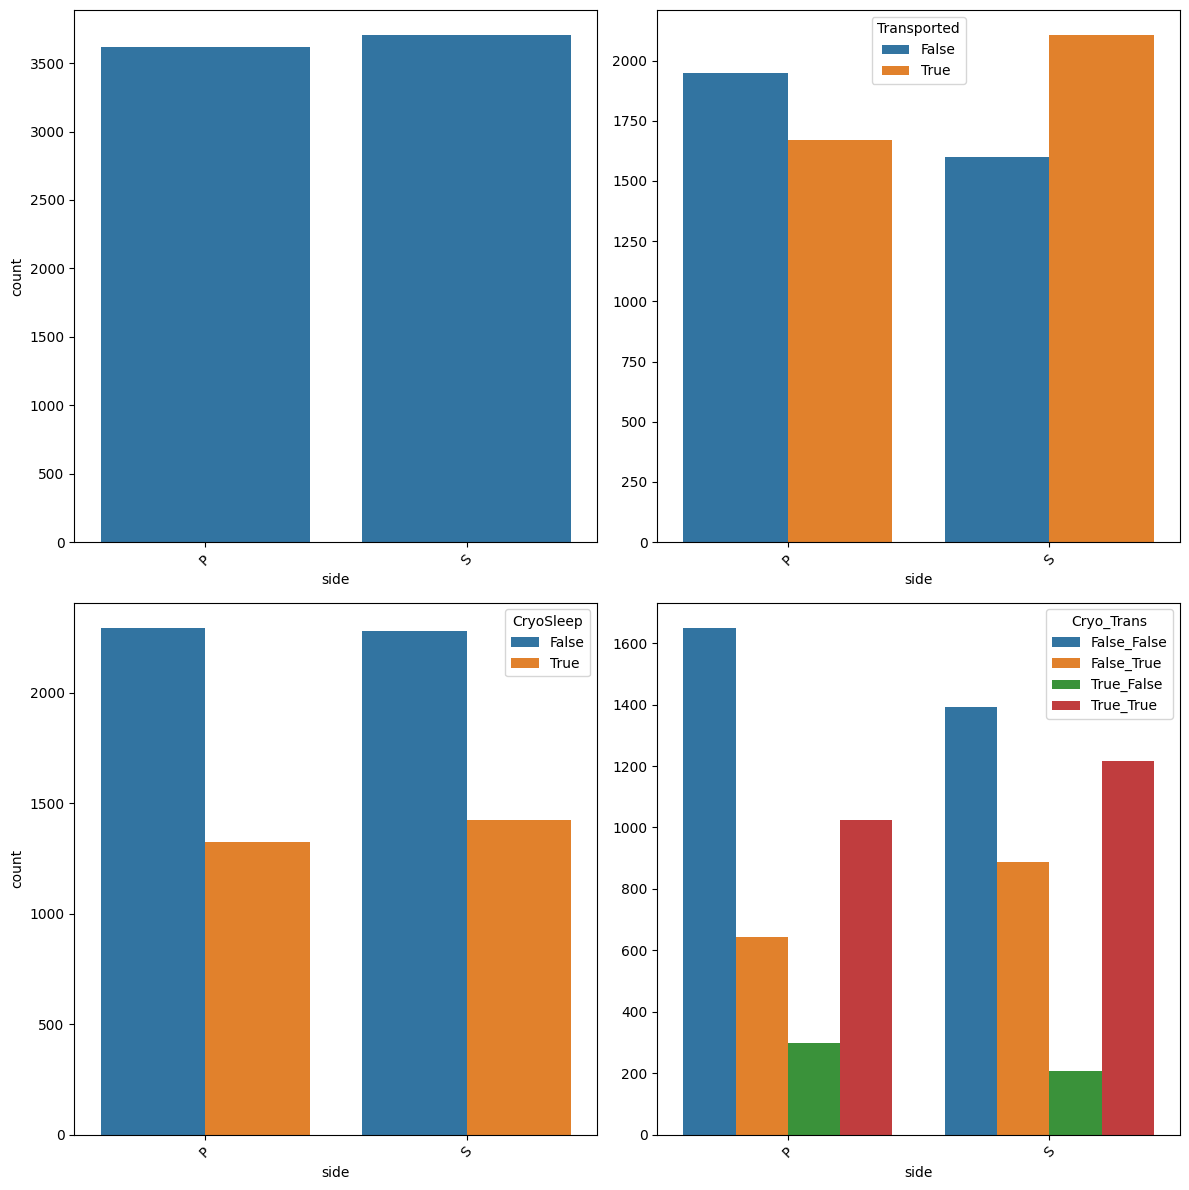

In [131]:
plot_CryoTrans_Counts(df0, 'side', ['P', 'S'])

<Axes: xlabel='VIP', ylabel='count'>

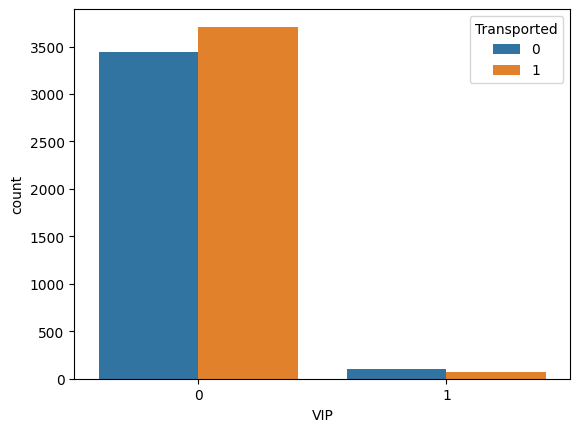

In [132]:
sns.countplot(x = 'VIP', hue = 'Transported', data = df0)

#### We can see that passengers in side S are more likely to be transported than passengers in side P even after accounting for cryosleep status. Since we only have two sides, including both of them as features would be redundant. The overwhelming majority of passengers are not VIP so this feature might not provide valuable predictive information.

In [133]:
df0['side_S'] = (df0.side == 'S').astype(int)

#### Effect on Performance

In [134]:
basic_list = ['CryoSleep', 'Under_13'] + Luxury_Features + HomePlanet_deck_Features2 + ['Region', 'Batch'] + Destination_Features
features_list = ['side_S', 'VIP']
Compare_Ordered_Feature_Lists(df0, 'Transported', basic_list, features_list, Kfold = 10)

List0:  ['CryoSleep', 'Under_13', 'Spa', 'RoomService', 'VRDeck', 'FoodCourt', 'ShoppingMall', 'HD_EuropaA', 'HD_EuropaB', 'HD_EuropaC', 'HD_EuropaD', 'HD_EuropaE', 'HD_MarsD', 'HD_MarsE', 'HD_MarsF', 'HD_EarthE', 'HD_EarthF', 'HD_EarthG', 'Region', 'Batch', 'Destination_55 Cancri e', 'Destination_PSO J318.5-22', 'Destination_TRAPPIST-1e']
List1:  ['CryoSleep', 'Under_13', 'Spa', 'RoomService', 'VRDeck', 'FoodCourt', 'ShoppingMall', 'HD_EuropaA', 'HD_EuropaB', 'HD_EuropaC', 'HD_EuropaD', 'HD_EuropaE', 'HD_MarsD', 'HD_MarsE', 'HD_MarsF', 'HD_EarthE', 'HD_EarthF', 'HD_EarthG', 'Region', 'Batch', 'Destination_55 Cancri e', 'Destination_PSO J318.5-22', 'Destination_TRAPPIST-1e', 'side_S']
List2:  ['CryoSleep', 'Under_13', 'Spa', 'RoomService', 'VRDeck', 'FoodCourt', 'ShoppingMall', 'HD_EuropaA', 'HD_EuropaB', 'HD_EuropaC', 'HD_EuropaD', 'HD_EuropaE', 'HD_MarsD', 'HD_MarsE', 'HD_MarsF', 'HD_EarthE', 'HD_EarthF', 'HD_EarthG', 'Region', 'Batch', 'Destination_55 Cancri e', 'Destination_PSO J31

,List0,List1,List2
Naive Bayes,0.7518,0.7522,0.7502
Logistic Regression,0.7833,0.7833,0.7833
LightGBM,0.8011,0.8009,0.8009
CatBoost,0.8098,0.8175,0.8185


In [135]:
basic_list = ['CryoSleep', 'Under_13'] + Luxury_Features + HomePlanet_deck_Features2 + Destination_Features + ['Region', 'Batch']
features_list = ['side_S', 'BigFamily', 'VIP']
Compare_Ordered_Feature_Lists(df0, 'Transported', basic_list, features_list, Kfold = 10)

List0:  ['CryoSleep', 'Under_13', 'Spa', 'RoomService', 'VRDeck', 'FoodCourt', 'ShoppingMall', 'HD_EuropaA', 'HD_EuropaB', 'HD_EuropaC', 'HD_EuropaD', 'HD_EuropaE', 'HD_MarsD', 'HD_MarsE', 'HD_MarsF', 'HD_EarthE', 'HD_EarthF', 'HD_EarthG', 'Destination_55 Cancri e', 'Destination_PSO J318.5-22', 'Destination_TRAPPIST-1e', 'Region', 'Batch']
List1:  ['CryoSleep', 'Under_13', 'Spa', 'RoomService', 'VRDeck', 'FoodCourt', 'ShoppingMall', 'HD_EuropaA', 'HD_EuropaB', 'HD_EuropaC', 'HD_EuropaD', 'HD_EuropaE', 'HD_MarsD', 'HD_MarsE', 'HD_MarsF', 'HD_EarthE', 'HD_EarthF', 'HD_EarthG', 'Destination_55 Cancri e', 'Destination_PSO J318.5-22', 'Destination_TRAPPIST-1e', 'Region', 'Batch', 'side_S']
List2:  ['CryoSleep', 'Under_13', 'Spa', 'RoomService', 'VRDeck', 'FoodCourt', 'ShoppingMall', 'HD_EuropaA', 'HD_EuropaB', 'HD_EuropaC', 'HD_EuropaD', 'HD_EuropaE', 'HD_MarsD', 'HD_MarsE', 'HD_MarsF', 'HD_EarthE', 'HD_EarthF', 'HD_EarthG', 'Destination_55 Cancri e', 'Destination_PSO J318.5-22', 'Destinati

,List0,List1,List2,List3
Naive Bayes,0.7518,0.7522,0.7509,0.7496
Logistic Regression,0.7833,0.7833,0.7840,0.7839
LightGBM,0.8011,0.8009,0.8009,0.8009
CatBoost,0.8098,0.8175,0.8184,0.8200


# Final Trials

In [136]:
basic_list = ['CryoSleep', 'Under_13'] + Luxury_Features + HomePlanet_deck_Features2 + Destination_Features + ['Region', 'Batch', 'side_S', 'BigFamily', 'VIP']
features_list = ['GroupSize', 'CabinSize']
Compare_Ordered_Feature_Lists(df0, 'Transported', basic_list, features_list, Kfold = 10)

List0:  ['CryoSleep', 'Under_13', 'Spa', 'RoomService', 'VRDeck', 'FoodCourt', 'ShoppingMall', 'HD_EuropaA', 'HD_EuropaB', 'HD_EuropaC', 'HD_EuropaD', 'HD_EuropaE', 'HD_MarsD', 'HD_MarsE', 'HD_MarsF', 'HD_EarthE', 'HD_EarthF', 'HD_EarthG', 'Destination_55 Cancri e', 'Destination_PSO J318.5-22', 'Destination_TRAPPIST-1e', 'Region', 'Batch', 'side_S', 'BigFamily', 'VIP']
List1:  ['CryoSleep', 'Under_13', 'Spa', 'RoomService', 'VRDeck', 'FoodCourt', 'ShoppingMall', 'HD_EuropaA', 'HD_EuropaB', 'HD_EuropaC', 'HD_EuropaD', 'HD_EuropaE', 'HD_MarsD', 'HD_MarsE', 'HD_MarsF', 'HD_EarthE', 'HD_EarthF', 'HD_EarthG', 'Destination_55 Cancri e', 'Destination_PSO J318.5-22', 'Destination_TRAPPIST-1e', 'Region', 'Batch', 'side_S', 'BigFamily', 'VIP', 'GroupSize']
List2:  ['CryoSleep', 'Under_13', 'Spa', 'RoomService', 'VRDeck', 'FoodCourt', 'ShoppingMall', 'HD_EuropaA', 'HD_EuropaB', 'HD_EuropaC', 'HD_EuropaD', 'HD_EuropaE', 'HD_MarsD', 'HD_MarsE', 'HD_MarsF', 'HD_EarthE', 'HD_EarthF', 'HD_EarthG', 'De

,List0,List1,List2
Naive Bayes,0.7496,0.7494,0.7473
Logistic Regression,0.7839,0.7842,0.7840
LightGBM,0.8009,0.8009,0.8009
CatBoost,0.8200,0.8182,0.8182


In [137]:
basic_list = ['CryoSleep', 'Under_13'] + Luxury_Features + HomePlanet_deck_Features2 + Destination_Features + ['Region', 'Batch', 'side_S', 'BigFamily', 'VIP']
features_list = ['FirstNameLength', 'LastNameLength']
Compare_Ordered_Feature_Lists(df0, 'Transported', basic_list, features_list, Kfold = 10)

List0:  ['CryoSleep', 'Under_13', 'Spa', 'RoomService', 'VRDeck', 'FoodCourt', 'ShoppingMall', 'HD_EuropaA', 'HD_EuropaB', 'HD_EuropaC', 'HD_EuropaD', 'HD_EuropaE', 'HD_MarsD', 'HD_MarsE', 'HD_MarsF', 'HD_EarthE', 'HD_EarthF', 'HD_EarthG', 'Destination_55 Cancri e', 'Destination_PSO J318.5-22', 'Destination_TRAPPIST-1e', 'Region', 'Batch', 'side_S', 'BigFamily', 'VIP']
List1:  ['CryoSleep', 'Under_13', 'Spa', 'RoomService', 'VRDeck', 'FoodCourt', 'ShoppingMall', 'HD_EuropaA', 'HD_EuropaB', 'HD_EuropaC', 'HD_EuropaD', 'HD_EuropaE', 'HD_MarsD', 'HD_MarsE', 'HD_MarsF', 'HD_EarthE', 'HD_EarthF', 'HD_EarthG', 'Destination_55 Cancri e', 'Destination_PSO J318.5-22', 'Destination_TRAPPIST-1e', 'Region', 'Batch', 'side_S', 'BigFamily', 'VIP', 'FirstNameLength']
List2:  ['CryoSleep', 'Under_13', 'Spa', 'RoomService', 'VRDeck', 'FoodCourt', 'ShoppingMall', 'HD_EuropaA', 'HD_EuropaB', 'HD_EuropaC', 'HD_EuropaD', 'HD_EuropaE', 'HD_MarsD', 'HD_MarsE', 'HD_MarsF', 'HD_EarthE', 'HD_EarthF', 'HD_EarthG

,List0,List1,List2
Naive Bayes,0.7496,0.7486,0.7486
Logistic Regression,0.7839,0.7839,0.7841
LightGBM,0.8009,0.8009,0.8010
CatBoost,0.8200,0.8196,0.8176


In [138]:
basic_list = ['CryoSleep', 'Under_13'] + Luxury_Features + HomePlanet_deck_Features2 + Destination_Features + ['Region', 'Batch', 'side_S', 'BigFamily', 'VIP']
features_list = ['CabinFamilySize', 'GroupFamilySize', 'CabinGroupSize']
Compare_Ordered_Feature_Lists(df0, 'Transported', basic_list, features_list, Kfold = 10)

List0:  ['CryoSleep', 'Under_13', 'Spa', 'RoomService', 'VRDeck', 'FoodCourt', 'ShoppingMall', 'HD_EuropaA', 'HD_EuropaB', 'HD_EuropaC', 'HD_EuropaD', 'HD_EuropaE', 'HD_MarsD', 'HD_MarsE', 'HD_MarsF', 'HD_EarthE', 'HD_EarthF', 'HD_EarthG', 'Destination_55 Cancri e', 'Destination_PSO J318.5-22', 'Destination_TRAPPIST-1e', 'Region', 'Batch', 'side_S', 'BigFamily', 'VIP']
List1:  ['CryoSleep', 'Under_13', 'Spa', 'RoomService', 'VRDeck', 'FoodCourt', 'ShoppingMall', 'HD_EuropaA', 'HD_EuropaB', 'HD_EuropaC', 'HD_EuropaD', 'HD_EuropaE', 'HD_MarsD', 'HD_MarsE', 'HD_MarsF', 'HD_EarthE', 'HD_EarthF', 'HD_EarthG', 'Destination_55 Cancri e', 'Destination_PSO J318.5-22', 'Destination_TRAPPIST-1e', 'Region', 'Batch', 'side_S', 'BigFamily', 'VIP', 'CabinFamilySize']
List2:  ['CryoSleep', 'Under_13', 'Spa', 'RoomService', 'VRDeck', 'FoodCourt', 'ShoppingMall', 'HD_EuropaA', 'HD_EuropaB', 'HD_EuropaC', 'HD_EuropaD', 'HD_EuropaE', 'HD_MarsD', 'HD_MarsE', 'HD_MarsF', 'HD_EarthE', 'HD_EarthF', 'HD_EarthG

,List0,List1,List2,List3
Naive Bayes,0.7496,0.7478,0.7468,0.7448
Logistic Regression,0.7839,0.7839,0.7839,0.7840
LightGBM,0.8009,0.8009,0.8009,0.8009
CatBoost,0.8200,0.8203,0.8177,0.8190


In [139]:
basic_list = ['CryoSleep', 'Under_13'] + Luxury_Features + HomePlanet_deck_Features2 + Destination_Features + ['Region', 'Batch', 'side_S', 'BigFamily', 'VIP']
features_list = ['CabinGroupSize', 'CabinFamilySize']
Compare_Ordered_Feature_Lists(df0, 'Transported', basic_list, features_list, Kfold = 10)

List0:  ['CryoSleep', 'Under_13', 'Spa', 'RoomService', 'VRDeck', 'FoodCourt', 'ShoppingMall', 'HD_EuropaA', 'HD_EuropaB', 'HD_EuropaC', 'HD_EuropaD', 'HD_EuropaE', 'HD_MarsD', 'HD_MarsE', 'HD_MarsF', 'HD_EarthE', 'HD_EarthF', 'HD_EarthG', 'Destination_55 Cancri e', 'Destination_PSO J318.5-22', 'Destination_TRAPPIST-1e', 'Region', 'Batch', 'side_S', 'BigFamily', 'VIP']
List1:  ['CryoSleep', 'Under_13', 'Spa', 'RoomService', 'VRDeck', 'FoodCourt', 'ShoppingMall', 'HD_EuropaA', 'HD_EuropaB', 'HD_EuropaC', 'HD_EuropaD', 'HD_EuropaE', 'HD_MarsD', 'HD_MarsE', 'HD_MarsF', 'HD_EarthE', 'HD_EarthF', 'HD_EarthG', 'Destination_55 Cancri e', 'Destination_PSO J318.5-22', 'Destination_TRAPPIST-1e', 'Region', 'Batch', 'side_S', 'BigFamily', 'VIP', 'CabinGroupSize']
List2:  ['CryoSleep', 'Under_13', 'Spa', 'RoomService', 'VRDeck', 'FoodCourt', 'ShoppingMall', 'HD_EuropaA', 'HD_EuropaB', 'HD_EuropaC', 'HD_EuropaD', 'HD_EuropaE', 'HD_MarsD', 'HD_MarsE', 'HD_MarsF', 'HD_EarthE', 'HD_EarthF', 'HD_EarthG'

,List0,List1,List2
Naive Bayes,0.7496,0.7479,0.7451
Logistic Regression,0.7839,0.7840,0.7838
LightGBM,0.8009,0.8009,0.8009
CatBoost,0.8200,0.8182,0.8184
